<font color="#0028628"><h1 align="left">Workflow bioinformático de RNASeq en Python: Optimización de herramientas disponibles y retos para el análisis de datos bioinformáticos de RNASeq </h1></font>
<font color="#002856"><h2 align="left">Tesis de maestria en bioinformatica</h2></font> 

#### Director de tesis: Juan Francisco Vallalta 
#### Alumno: Paula Alejandra Chaparro Santos
---

In [3]:
conda config --show channels


channels:
  - conda-forge
  - bioconda
  - defaults

Note: you may need to restart the kernel to use updated packages.


In [8]:
!conda config --set channel_priority strict

In [9]:
conda config --show channel_priority

channel_priority: strict

Note: you may need to restart the kernel to use updated packages.


In [4]:
# ============================================================
# DIAGNÓSTICO INICIAL DEL ENTORNO COMPUTACIONAL
# Ejecutar UNA VEZ antes de iniciar el pipeline
# ============================================================

import os
import sys
import shutil
import platform
import subprocess
from datetime import datetime
from pathlib import Path

import pandas as pd
import psutil


# ------------------------------------------------------------
# 1. RUTAS DEL PROYECTO
# ------------------------------------------------------------

PROJECT_DIR = Path(
    "/home/paula.chaparro/Documentos/tesis_2025"
)

DATA_DIR = PROJECT_DIR / "data"
RESULTS_DIR = PROJECT_DIR / "results"
TMP_DIR = PROJECT_DIR / "tmp"

ENV_DIR = Path(sys.prefix)

MONITOR_FILE = RESULTS_DIR / "monitorizacion_recursos.csv"
BASELINE_FILE = RESULTS_DIR / "diagnostico_inicial.csv"

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# 2. FUNCIONES AUXILIARES
# ------------------------------------------------------------

def bytes_to_gb(value):
    return value / (1024 ** 3)


def directory_size(path):
    """
    Calcula el tamaño total de un directorio.
    Si no existe devuelve 0.
    """
    path = Path(path)

    if not path.exists():
        return 0

    total = 0

    for root, dirs, files in os.walk(path):
        for file in files:
            file_path = Path(root) / file

            try:
                total += file_path.stat().st_size
            except (FileNotFoundError, PermissionError):
                pass

    return total


# ------------------------------------------------------------
# 3. INFORMACIÓN DEL SISTEMA
# ------------------------------------------------------------

timestamp = datetime.now().isoformat(
    timespec="seconds"
)

cpu_physical = psutil.cpu_count(
    logical=False
)

cpu_logical = psutil.cpu_count(
    logical=True
)

memory = psutil.virtual_memory()

disk = shutil.disk_usage(
    "/home/paula.chaparro"
)


# ------------------------------------------------------------
# 4. TAMAÑOS INICIALES
# ------------------------------------------------------------

print("▶ Calculando tamaño del environment...")
environment_size = directory_size(
    ENV_DIR
)

print("▶ Calculando tamaño del proyecto...")
project_size = directory_size(
    PROJECT_DIR
)

print("▶ Calculando tamaño de data...")
data_size = directory_size(
    DATA_DIR
)

print("▶ Calculando tamaño de results...")
results_size = directory_size(
    RESULTS_DIR
)

print("▶ Calculando tamaño de tmp...")
tmp_size = directory_size(
    TMP_DIR
)


# ------------------------------------------------------------
# 5. CONSTRUIR REGISTRO BASAL
# ------------------------------------------------------------

baseline = pd.DataFrame(
    [
        {
            "timestamp": timestamp,
            "python_version": platform.python_version(),
            "sistema_operativo": platform.platform(),
            "cpu_fisicas": cpu_physical,
            "cpu_logicas": cpu_logical,
            "ram_total_GB": round(
                bytes_to_gb(memory.total),
                2
            ),
            "ram_disponible_GB": round(
                bytes_to_gb(memory.available),
                2
            ),
            "disco_total_GB": round(
                bytes_to_gb(disk.total),
                2
            ),
            "disco_usado_GB": round(
                bytes_to_gb(disk.used),
                2
            ),
            "disco_libre_GB": round(
                bytes_to_gb(disk.free),
                2
            ),
            "environment_path": str(
                ENV_DIR
            ),
            "environment_size_GB": round(
                bytes_to_gb(environment_size),
                2
            ),
            "project_size_GB": round(
                bytes_to_gb(project_size),
                2
            ),
            "data_size_GB": round(
                bytes_to_gb(data_size),
                2
            ),
            "results_size_GB": round(
                bytes_to_gb(results_size),
                2
            ),
            "tmp_size_GB": round(
                bytes_to_gb(tmp_size),
                2
            ),
        }
    ]
)


# ------------------------------------------------------------
# 6. GUARDAR DIAGNÓSTICO
# ------------------------------------------------------------

baseline.to_csv(
    BASELINE_FILE,
    index=False
)


# ------------------------------------------------------------
# 7. MOSTRAR RESULTADOS
# ------------------------------------------------------------

print("\n==============================================")
print("DIAGNÓSTICO INICIAL")
print("==============================================\n")

display(
    baseline.T.rename(
        columns={0: "valor"}
    )
)

print("\n Diagnóstico inicial guardado en:")
print(BASELINE_FILE)

▶ Calculando tamaño del environment...
▶ Calculando tamaño del proyecto...
▶ Calculando tamaño de data...
▶ Calculando tamaño de results...
▶ Calculando tamaño de tmp...

DIAGNÓSTICO INICIAL



,valor
timestamp,2026-09-01T19:54:25
python_version,3.11.11
sistema_operativo,Linux-5.15.213-150.251.amzn2.x86_64-x86_64-wit...
cpu_fisicas,1
cpu_logicas,2
ram_total_GB,7.61
ram_disponible_GB,5.71
disco_total_GB,98.25
disco_usado_GB,55.14
disco_libre_GB,43.09



 Diagnóstico inicial guardado en:
/home/paula.chaparro/Documentos/tesis_2025/results/diagnostico_inicial.csv


In [6]:
# ============================================================
# REGISTRO DEL ENTORNO DE SOFTWARE
# ============================================================

import subprocess
from pathlib import Path


PROJECT_DIR = Path(
    "/home/paula.chaparro/Documentos/tesis_2025"
)


# ------------------------------------------------------------
# 1. EXPORTAR ENVIRONMENT.YML
# ------------------------------------------------------------

environment_file = (
    PROJECT_DIR / "environment.yml"
)

with open(
    environment_file,
    "w"
) as file:

    subprocess.run(
        [
            "conda",
            "env",
            "export",
            "--no-builds"
        ],
        stdout=file,
        text=True,
        check=True
    )


# ------------------------------------------------------------
# 2. ELIMINAR PREFIX ESPECÍFICO DEL EQUIPO
# ------------------------------------------------------------

with open(
    environment_file,
    "r"
) as file:

    lines = file.readlines()

with open(
    environment_file,
    "w"
) as file:

    for line in lines:

        if not line.startswith("prefix:"):
            file.write(line)


# ------------------------------------------------------------
# 3. GUARDAR LISTADO COMPLETO DE CONDA
# ------------------------------------------------------------

conda_list_file = (
    PROJECT_DIR / "conda_packages.txt"
)

with open(
    conda_list_file,
    "w"
) as file:

    subprocess.run(
        [
            "conda",
            "list"
        ],
        stdout=file,
        text=True,
        check=True
    )


# ------------------------------------------------------------
# 4. VERIFICAR DEPENDENCIAS
# ------------------------------------------------------------

pip_check = subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "check"
    ],
    capture_output=True,
    text=True
)


print("==============================================")
print("REGISTRO DEL ENVIRONMENT")
print("==============================================\n")

print("environment.yml:")
print(environment_file)

print("\nListado Conda:")
print(conda_list_file)

print("\npip check:")
print(
    pip_check.stdout
    if pip_check.stdout
    else pip_check.stderr
)

REGISTRO DEL ENVIRONMENT

environment.yml:
/home/paula.chaparro/Documentos/tesis_2025/environment.yml

Listado Conda:
/home/paula.chaparro/Documentos/tesis_2025/conda_packages.txt

pip check:
No broken requirements found.



In [5]:
# ============================================================
# SISTEMA GENERAL DE MONITORIZACIÓN POR MÓDULO
# Ejecutar UNA VEZ al principio del notebook
# ============================================================

import os
import sys
import time
import shutil
import threading
from pathlib import Path
from datetime import datetime

import pandas as pd
import psutil


# ------------------------------------------------------------
# 1. RUTAS
# ------------------------------------------------------------

PROJECT_DIR = Path(
    "/home/paula.chaparro/Documentos/tesis_2025"
)

DATA_DIR = PROJECT_DIR / "data"
RESULTS_DIR = PROJECT_DIR / "results"
TMP_DIR = PROJECT_DIR / "tmp"

ENV_DIR = Path(sys.prefix)

MONITOR_FILE = (
    RESULTS_DIR /
    "monitorizacion_recursos.csv"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# 2. FUNCIONES AUXILIARES
# ------------------------------------------------------------

def bytes_to_gb(value):
    return value / (1024 ** 3)


def directory_size(path):

    path = Path(path)

    if not path.exists():
        return 0

    total = 0

    for root, dirs, files in os.walk(path):

        for file in files:

            file_path = Path(root) / file

            try:
                total += file_path.stat().st_size

            except (
                FileNotFoundError,
                PermissionError
            ):
                pass

    return total


def process_tree_rss():

    """
    Memoria RSS del proceso Jupyter
    + procesos hijos activos.
    """

    current_process = psutil.Process(
        os.getpid()
    )

    processes = [
        current_process
    ]

    try:
        processes.extend(
            current_process.children(
                recursive=True
            )
        )
    except psutil.Error:
        pass

    total_rss = 0

    for process in processes:

        try:
            total_rss += (
                process.memory_info().rss
            )

        except (
            psutil.NoSuchProcess,
            psutil.AccessDenied
        ):
            pass

    return total_rss


# ------------------------------------------------------------
# 3. VARIABLES INTERNAS
# ------------------------------------------------------------

_monitor_active = False
_monitor_thread = None
_peak_rss = 0
_module_start = None
_module_name = None
_module_initial = None


# ------------------------------------------------------------
# 4. MONITOR DE PICO RSS
# ------------------------------------------------------------

def _monitor_memory():

    global _peak_rss

    while _monitor_active:

        rss = process_tree_rss()

        if rss > _peak_rss:
            _peak_rss = rss

        time.sleep(0.2)


# ------------------------------------------------------------
# 5. SNAPSHOT DE RECURSOS
# ------------------------------------------------------------

def snapshot_resources():

    memory = psutil.virtual_memory()

    disk = shutil.disk_usage(
        "/home/paula.chaparro"
    )

    return {
        "ram_total_GB": bytes_to_gb(
            memory.total
        ),
        "ram_disponible_GB": bytes_to_gb(
            memory.available
        ),
        "disco_total_GB": bytes_to_gb(
            disk.total
        ),
        "disco_libre_GB": bytes_to_gb(
            disk.free
        ),
        "project_size_GB": bytes_to_gb(
            directory_size(PROJECT_DIR)
        ),
        "data_size_GB": bytes_to_gb(
            directory_size(DATA_DIR)
        ),
        "results_size_GB": bytes_to_gb(
            directory_size(RESULTS_DIR)
        ),
        "tmp_size_GB": bytes_to_gb(
            directory_size(TMP_DIR)
        ),
    }


# ------------------------------------------------------------
# 6. INICIAR MEDICIÓN DE UN MÓDULO
# ------------------------------------------------------------

def iniciar_medicion_modulo(nombre_modulo):

    global _monitor_active
    global _monitor_thread
    global _peak_rss
    global _module_start
    global _module_name
    global _module_initial

    if _monitor_active:

        raise RuntimeError(
            "Ya existe una medición activa."
        )

    print(
        f"▶ Iniciando monitorización: "
        f"{nombre_modulo}"
    )

    _module_name = nombre_modulo

    _module_initial = (
        snapshot_resources()
    )

    _peak_rss = (
        process_tree_rss()
    )

    _module_start = (
        time.perf_counter()
    )

    _monitor_active = True

    _monitor_thread = threading.Thread(
        target=_monitor_memory,
        daemon=True
    )

    _monitor_thread.start()

    print(
        "✅ Monitorización iniciada."
    )

In [12]:
# ============================================================
# BLOQUE PARA ANTES DE CADA MÓDULO
# ============================================================

iniciar_medicion_modulo(
    "MÓDULO 01 - OBTENCION DE LOS METADATOS"
)

▶ Iniciando monitorización: MÓDULO 01 - OBTENCION DE LOS METADATOS
✅ Monitorización iniciada.


In [44]:
# ============================================================
# "MÓDULO 01 - OBTENCION DE LOS METADATOS"
# ============================================================
import subprocess
import pandas as pd
from io import StringIO
#Obtenci¡on de los metadatos:

# Definir el ID del proyecto (study)
SRP = "SRP318632"

#Construir el comando de pysradb (como lista)
comand = ["pysradb", "metadata", SRP, "--desc", "--expand"]

#Ejecutar el comando y capturar la salida estándar como texto
result = subprocess.run(comand, stdout=subprocess.PIPE, text=True)

#Si hay salida:
if result.stdout:
    # Convertir la salida en un "archivo en memoria" y leer como DataFrame
    output = StringIO(result.stdout)
    df = pd.read_csv(output, sep="\t")

    #Guardar los metadatos como CSV
    df.to_csv("/home/paula.chaparro/Documentos/tesis_2025/SRP318632_metadata.csv", index=False)

    #Obtener lista de SRRs para usarlos después (descarga, filtrado, etc.)
    srr_list = df["run_accession"].tolist()

    #Mostrar resultados
    print(srr_list)
    display(df.head())
else:
    print("no hay salida")


['SRR14436589', 'SRR14436590', 'SRR14436591', 'SRR14436592', 'SRR14436593', 'SRR14436594', 'SRR14436595', 'SRR14436596', 'SRR14436597', 'SRR14436598', 'SRR14436599', 'SRR14436600', 'SRR14436601', 'SRR14436602', 'SRR14436603', 'SRR14436604', 'SRR14436605', 'SRR14436606', 'SRR14436607', 'SRR14436608', 'SRR14436609', 'SRR14436610', 'SRR14436611', 'SRR14436612', 'SRR14436613', 'SRR14436614', 'SRR14436615', 'SRR14436616', 'SRR14436617', 'SRR14436618', 'SRR14436619', 'SRR14436620', 'SRR14436621', 'SRR14436622', 'SRR14436623', 'SRR14436624', 'SRR14436625', 'SRR14436626', 'SRR14436627', 'SRR14436628']


,study_accession,study_title,experiment_accession,experiment_title,experiment_desc,organism_taxid,organism_name,library_name,library_strategy,library_source,...,biosample,bioproject,instrument,instrument_model,instrument_model_desc,total_spots,total_size,run_accession,run_total_spots,run_total_bases
0,SRP318632,Integrative analysis of altered genes expresse...,SRX10787707,GSM5283449: Alzheimer's Disease_Biological rep...,GSM5283449: Alzheimer's Disease_Biological rep...,9606,Homo sapiens,NaN,RNA-Seq,TRANSCRIPTOMIC,...,SAMN19026083,PRJNA727602,Illumina HiSeq 1500,Illumina HiSeq 1500,ILLUMINA,40295075,4902868369,SRR14436589,19992051,4038394302
1,SRP318632,Integrative analysis of altered genes expresse...,SRX10787707,GSM5283449: Alzheimer's Disease_Biological rep...,GSM5283449: Alzheimer's Disease_Biological rep...,9606,Homo sapiens,NaN,RNA-Seq,TRANSCRIPTOMIC,...,SAMN19026083,PRJNA727602,Illumina HiSeq 1500,Illumina HiSeq 1500,ILLUMINA,40295075,4902868369,SRR14436590,20303024,4101210848
2,SRP318632,Integrative analysis of altered genes expresse...,SRX10787708,GSM5283450: Alzheimer's Disease_Biological rep...,GSM5283450: Alzheimer's Disease_Biological rep...,9606,Homo sapiens,NaN,RNA-Seq,TRANSCRIPTOMIC,...,SAMN19026082,PRJNA727602,Illumina HiSeq 1500,Illumina HiSeq 1500,ILLUMINA,61327795,7703868082,SRR14436591,6376015,1287955030
3,SRP318632,Integrative analysis of altered genes expresse...,SRX10787708,GSM5283450: Alzheimer's Disease_Biological rep...,GSM5283450: Alzheimer's Disease_Biological rep...,9606,Homo sapiens,NaN,RNA-Seq,TRANSCRIPTOMIC,...,SAMN19026082,PRJNA727602,Illumina HiSeq 1500,Illumina HiSeq 1500,ILLUMINA,61327795,7703868082,SRR14436592,6464739,1305877278
4,SRP318632,Integrative analysis of altered genes expresse...,SRX10787708,GSM5283450: Alzheimer's Disease_Biological rep...,GSM5283450: Alzheimer's Disease_Biological rep...,9606,Homo sapiens,NaN,RNA-Seq,TRANSCRIPTOMIC,...,SAMN19026082,PRJNA727602,Illumina HiSeq 1500,Illumina HiSeq 1500,ILLUMINA,61327795,7703868082,SRR14436593,24180592,4884479584


In [31]:
# ============================================================
# BLOQUE PARA FINALIZAR LA MEDICIÓN DEL MÓDULO
# Ejecutar JUSTO DESPUÉS del código monitorizado, antes de mostrar resultados
# ============================================================

def finalizar_medicion_modulo(
    estado="OK",
    hilos=None,
    limite_memoria=None,
    observaciones=""
):

    global _monitor_active
    global _monitor_thread
    global _peak_rss
    global _module_start
    global _module_name
    global _module_initial

    if not _monitor_active:

        raise RuntimeError(
            "No existe una medición activa."
        )


    # --------------------------------------------------------
    # DETENER MONITOR DE MEMORIA
    # --------------------------------------------------------

    _monitor_active = False

    if _monitor_thread is not None:
        _monitor_thread.join()


    # --------------------------------------------------------
    # DURACIÓN
    # --------------------------------------------------------

    end_time = time.perf_counter()

    duration_seconds = (
        end_time - _module_start
    )


    # --------------------------------------------------------
    # RECURSOS AL FINAL
    # --------------------------------------------------------

    final_resources = (
        snapshot_resources()
    )


    # --------------------------------------------------------
    # CONSTRUIR FILA
    # --------------------------------------------------------

    record = {
        "timestamp": datetime.now().isoformat(
            timespec="seconds"
        ),

        "etapa": _module_name,

        "duracion_segundos": round(
            duration_seconds,
            2
        ),

        "duracion_minutos": round(
            duration_seconds / 60,
            2
        ),

        "pico_RSS_GB": round(
            bytes_to_gb(_peak_rss),
            3
        ),

        "ram_total_GB": round(
            final_resources[
                "ram_total_GB"
            ],
            2
        ),

        "ram_disponible_inicio_GB": round(
            _module_initial[
                "ram_disponible_GB"
            ],
            2
        ),

        "ram_disponible_final_GB": round(
            final_resources[
                "ram_disponible_GB"
            ],
            2
        ),

        "disco_libre_inicio_GB": round(
            _module_initial[
                "disco_libre_GB"
            ],
            2
        ),

        "disco_libre_final_GB": round(
            final_resources[
                "disco_libre_GB"
            ],
            2
        ),

        "project_size_inicio_GB": round(
            _module_initial[
                "project_size_GB"
            ],
            3
        ),

        "project_size_final_GB": round(
            final_resources[
                "project_size_GB"
            ],
            3
        ),

        "data_size_inicio_GB": round(
            _module_initial[
                "data_size_GB"
            ],
            3
        ),

        "data_size_final_GB": round(
            final_resources[
                "data_size_GB"
            ],
            3
        ),

        "results_size_inicio_GB": round(
            _module_initial[
                "results_size_GB"
            ],
            3
        ),

        "results_size_final_GB": round(
            final_resources[
                "results_size_GB"
            ],
            3
        ),

        "tmp_size_inicio_GB": round(
            _module_initial[
                "tmp_size_GB"
            ],
            3
        ),

        "tmp_size_final_GB": round(
            final_resources[
                "tmp_size_GB"
            ],
            3
        ),

        "hilos": hilos,

        "limite_memoria": limite_memoria,

        "estado": estado,

        "observaciones": observaciones
    }


    # --------------------------------------------------------
    # GUARDAR EN CSV
    # --------------------------------------------------------

    new_row = pd.DataFrame(
        [record]
    )

    if MONITOR_FILE.exists():

        previous_data = pd.read_csv(
            MONITOR_FILE
        )

        monitoring_data = pd.concat(
            [
                previous_data,
                new_row
            ],
            ignore_index=True
        )

    else:

        monitoring_data = new_row


    monitoring_data.to_csv(
        MONITOR_FILE,
        index=False
    )


    # --------------------------------------------------------
    # MOSTRAR RESULTADO INDIVIDUAL
    # --------------------------------------------------------

    print("\n==============================================")
    print("RESULTADO INDIVIDUAL DEL MÓDULO")
    print("==============================================\n")

    display(
        new_row.T.rename(
            columns={0: "valor"}
        )
    )

    print(
        "\n✅ Registro guardado en:"
    )

    print(
        MONITOR_FILE
    )


    # --------------------------------------------------------
    # REINICIAR VARIABLES
    # --------------------------------------------------------

    _module_thread = None
    _module_start = None
    _module_name = None
    _module_initial = None

    return new_row

In [14]:
resultado_modulo = finalizar_medicion_modulo(
    estado="OK",
    hilos=None,
    limite_memoria=None,
    observaciones="Módulo anterior finalizado."
)


RESULTADO INDIVIDUAL DEL MÓDULO



,valor
timestamp,2026-08-31T00:49:37
etapa,MÓDULO 01 - OBTENCION DE LOS METADATOS
duracion_segundos,13.45
duracion_minutos,0.22
pico_RSS_GB,0.278
ram_total_GB,7.61
ram_disponible_inicio_GB,5.17
ram_disponible_final_GB,5.17
disco_libre_inicio_GB,36.11
disco_libre_final_GB,36.11



✅ Registro guardado en:
/home/paula.chaparro/Documentos/tesis_2025/results/monitorizacion_recursos.csv


In [56]:
import pandas as pd

ruta = "/home/paula.chaparro/Documentos/tesis_2025/SRP318632_metadata.csv"
df_srr = pd.read_csv(ruta)

# Extraer lista de SRRs
srr_list = df_srr["run_accession"].tolist()
print("SRRs a descargar:", srr_list)

SRRs a descargar: ['SRR14436589', 'SRR14436590', 'SRR14436591', 'SRR14436592', 'SRR14436593', 'SRR14436594', 'SRR14436595', 'SRR14436596', 'SRR14436597', 'SRR14436598', 'SRR14436599', 'SRR14436600', 'SRR14436601', 'SRR14436602', 'SRR14436603', 'SRR14436604', 'SRR14436605', 'SRR14436606', 'SRR14436607', 'SRR14436608', 'SRR14436609', 'SRR14436610', 'SRR14436611', 'SRR14436612', 'SRR14436613', 'SRR14436614', 'SRR14436615', 'SRR14436616', 'SRR14436617', 'SRR14436618', 'SRR14436619', 'SRR14436620', 'SRR14436621', 'SRR14436622', 'SRR14436623', 'SRR14436624', 'SRR14436625', 'SRR14436626', 'SRR14436627', 'SRR14436628']


In [16]:
# ============================================================
# BLOQUE PARA COLOCAR JUSTO ANTES DE CADA MÓDULO
# Cambiar únicamente el nombre
# ============================================================

iniciar_medicion_modulo(
    "MÓDULO 02 - DESCARGA DE LOS ARCHIVOS Y PREPARACION DE LOS RAW DATA"
)

▶ Iniciando monitorización: MÓDULO 02 - DESCARGA DE LOS ARCHIVOS Y PREPARACION DE LOS RAW DATA
✅ Monitorización iniciada.


In [52]:
#MODULO 02: DESCARGA DE LOS ARCHIVOS PREPARACION DE LOS RAW DATA 
import subprocess
import os
import shutil

# Carpeta donde guardar los FASTQ
output_dir = "/home/paula.chaparro/Documentos/tesis_2025/data/raw"
tmp_dir = "/home/paula.chaparro/Documentos/tesis_2025/data/tmp"

os.makedirs(output_dir, exist_ok=True)
os.makedirs(tmp_dir, exist_ok=True)

for srr in srr_list[:1]:
    print(f"\n▶ Descargando {srr}...")

    # 1. Descargar archivo .sra
    subprocess.run(["prefetch", srr], check=True)

    # 2. Convertir a FASTQ usando carpeta temporal
    subprocess.run([
        "fasterq-dump",
        srr,
        "--split-files",
        "--threads", "2",
        "-O", output_dir,
        "-t", tmp_dir
    ], check=True)

    # 3. Borrar el archivo .sra para liberar espacio
    sra_path = os.path.expanduser(f"~/ncbi/public/sra/{srr}.sra")
    if os.path.exists(sra_path):
        os.remove(sra_path)
        print(f"🗑 Eliminado {sra_path}")

    # 4. Limpiar carpeta temporal
for item in os.listdir(tmp_dir):
    item_path = os.path.join(tmp_dir, item)
    if os.path.isdir(item_path):
        shutil.rmtree(item_path)
    else:
        os.remove(item_path)


▶ Descargando SRR14436589...
2026-09-01T19:49:22 prefetch.3.2.1: 1) Resolving 'SRR14436589'...
2026-09-01T19:49:22 prefetch.3.2.1: Current preference is set to retrieve SRA Normalized Format files with full base quality scores
2026-09-01T19:49:23 prefetch.3.2.1: 1) Downloading 'SRR14436589'...
2026-09-01T19:49:23 prefetch.3.2.1:  SRA Normalized Format file is being retrieved
2026-09-01T19:49:23 prefetch.3.2.1:  Downloading via HTTPS...
2026-09-01T19:50:48 prefetch.3.2.1:  HTTPS download succeed
2026-09-01T19:50:52 prefetch.3.2.1:  'SRR14436589' is valid: 2441128290 bytes were streamed from 2441117696
2026-09-01T19:50:52 prefetch.3.2.1: 1) 'SRR14436589' was downloaded successfully
2026-09-01T19:50:52 prefetch.3.2.1: 1) Resolving 'SRR14436589's dependencies...
2026-09-01T19:50:52 prefetch.3.2.1: 'SRR14436589' has 0 unresolved dependencies


spots read      : 19,992,051
reads read      : 39,984,102
reads written   : 39,984,102


In [18]:
# ============================================================
# 3. FINALIZAR MEDICIÓN
# ============================================================

resultado_modulo = finalizar_medicion_modulo(
    estado="OK",
    hilos=4,
    limite_memoria=None,
    observaciones="Módulo ejecutado correctamente."
)


RESULTADO INDIVIDUAL DEL MÓDULO



,valor
timestamp,2026-08-31T01:09:52
etapa,MÓDULO 02 - DESCARGA DE LOS ARCHIVOS Y PREPARA...
duracion_segundos,337.63
duracion_minutos,5.63
pico_RSS_GB,0.726
ram_total_GB,7.61
ram_disponible_inicio_GB,5.12
ram_disponible_final_GB,5.59
disco_libre_inicio_GB,36.11
disco_libre_final_GB,23.19



✅ Registro guardado en:
/home/paula.chaparro/Documentos/tesis_2025/results/monitorizacion_recursos.csv


In [19]:
# ============================================================
# BLOQUE PARA FINALIZAR LA MEDICIÓN DEL MÓDULO
# Ejecutar JUSTO DESPUÉS del código monitorizado
# ============================================================

def finalizar_medicion_modulo(
    estado="OK",
    hilos=None,
    limite_memoria=None,
    observaciones=""
):

    global _monitor_active
    global _monitor_thread
    global _peak_rss
    global _module_start
    global _module_name
    global _module_initial

    if not _monitor_active:

        raise RuntimeError(
            "No existe una medición activa."
        )


    # --------------------------------------------------------
    # DETENER MONITOR DE MEMORIA
    # --------------------------------------------------------

    _monitor_active = False

    if _monitor_thread is not None:
        _monitor_thread.join()


    # --------------------------------------------------------
    # DURACIÓN
    # --------------------------------------------------------

    end_time = time.perf_counter()

    duration_seconds = (
        end_time - _module_start
    )


    # --------------------------------------------------------
    # RECURSOS AL FINAL
    # --------------------------------------------------------

    final_resources = (
        snapshot_resources()
    )


    # --------------------------------------------------------
    # CONSTRUIR FILA
    # --------------------------------------------------------

    record = {
        "timestamp": datetime.now().isoformat(
            timespec="seconds"
        ),

        "etapa": _module_name,

        "duracion_segundos": round(
            duration_seconds,
            2
        ),

        "duracion_minutos": round(
            duration_seconds / 60,
            2
        ),

        "pico_RSS_GB": round(
            bytes_to_gb(_peak_rss),
            3
        ),

        "ram_total_GB": round(
            final_resources[
                "ram_total_GB"
            ],
            2
        ),

        "ram_disponible_inicio_GB": round(
            _module_initial[
                "ram_disponible_GB"
            ],
            2
        ),

        "ram_disponible_final_GB": round(
            final_resources[
                "ram_disponible_GB"
            ],
            2
        ),

        "disco_libre_inicio_GB": round(
            _module_initial[
                "disco_libre_GB"
            ],
            2
        ),

        "disco_libre_final_GB": round(
            final_resources[
                "disco_libre_GB"
            ],
            2
        ),

        "project_size_inicio_GB": round(
            _module_initial[
                "project_size_GB"
            ],
            3
        ),

        "project_size_final_GB": round(
            final_resources[
                "project_size_GB"
            ],
            3
        ),

        "data_size_inicio_GB": round(
            _module_initial[
                "data_size_GB"
            ],
            3
        ),

        "data_size_final_GB": round(
            final_resources[
                "data_size_GB"
            ],
            3
        ),

        "results_size_inicio_GB": round(
            _module_initial[
                "results_size_GB"
            ],
            3
        ),

        "results_size_final_GB": round(
            final_resources[
                "results_size_GB"
            ],
            3
        ),

        "tmp_size_inicio_GB": round(
            _module_initial[
                "tmp_size_GB"
            ],
            3
        ),

        "tmp_size_final_GB": round(
            final_resources[
                "tmp_size_GB"
            ],
            3
        ),

        "hilos": hilos,

        "limite_memoria": limite_memoria,

        "estado": estado,

        "observaciones": observaciones
    }


    # --------------------------------------------------------
    # GUARDAR EN CSV
    # --------------------------------------------------------

    new_row = pd.DataFrame(
        [record]
    )

    if MONITOR_FILE.exists():

        previous_data = pd.read_csv(
            MONITOR_FILE
        )

        monitoring_data = pd.concat(
            [
                previous_data,
                new_row
            ],
            ignore_index=True
        )

    else:

        monitoring_data = new_row


    monitoring_data.to_csv(
        MONITOR_FILE,
        index=False
    )


    # --------------------------------------------------------
    # MOSTRAR RESULTADO INDIVIDUAL
    # --------------------------------------------------------

    print("\n==============================================")
    print("RESULTADO INDIVIDUAL DEL MÓDULO")
    print("==============================================\n")

    display(
        new_row.T.rename(
            columns={0: "valor"}
        )
    )

    print(
        "\n✅ Registro guardado en:"
    )

    print(
        MONITOR_FILE
    )


    # --------------------------------------------------------
    # REINICIAR VARIABLES
    # --------------------------------------------------------

    _module_thread = None
    _module_start = None
    _module_name = None
    _module_initial = None

    return new_row

In [5]:
for srr in srr_list:
    f1 = os.path.join(output_dir, f"{srr}_1.fastq")
    f2 = os.path.join(output_dir, f"{srr}_2.fastq")
    
    if os.path.exists(f1) and os.path.exists(f2):
        print(f"✅ {srr}: descargado correctamente.")
    else:
        print(f"❌ {srr}: archivos FASTQ faltantes.")


✅ SRR14436589: descargado correctamente.
❌ SRR14436590: archivos FASTQ faltantes.
❌ SRR14436591: archivos FASTQ faltantes.
❌ SRR14436592: archivos FASTQ faltantes.
❌ SRR14436593: archivos FASTQ faltantes.
❌ SRR14436594: archivos FASTQ faltantes.
❌ SRR14436595: archivos FASTQ faltantes.
❌ SRR14436596: archivos FASTQ faltantes.
❌ SRR14436597: archivos FASTQ faltantes.
❌ SRR14436598: archivos FASTQ faltantes.
❌ SRR14436599: archivos FASTQ faltantes.
❌ SRR14436600: archivos FASTQ faltantes.
❌ SRR14436601: archivos FASTQ faltantes.
❌ SRR14436602: archivos FASTQ faltantes.
❌ SRR14436603: archivos FASTQ faltantes.
❌ SRR14436604: archivos FASTQ faltantes.
❌ SRR14436605: archivos FASTQ faltantes.
❌ SRR14436606: archivos FASTQ faltantes.
❌ SRR14436607: archivos FASTQ faltantes.
❌ SRR14436608: archivos FASTQ faltantes.
❌ SRR14436609: archivos FASTQ faltantes.
❌ SRR14436610: archivos FASTQ faltantes.
❌ SRR14436611: archivos FASTQ faltantes.
❌ SRR14436612: archivos FASTQ faltantes.
❌ SRR14436613: a

In [20]:
# ============================================================
# BLOQUE PARA ANTES DE CADA MÓDULO
# ============================================================

iniciar_medicion_modulo(
    "MÓDULO 03 - PRIMER ANALISIS DE CALIDAD"
)

▶ Iniciando monitorización: MÓDULO 03 - PRIMER ANALISIS DE CALIDAD
✅ Monitorización iniciada.


In [21]:
import subprocess
import os

# Ruta donde están tus archivos .fastq descargados
fastq_dir = "/home/paula.chaparro/Documentos/tesis_2025/data/raw"

# Ruta de salida para los reportes FastQC (ya definida por ti)
output_dir = "/home/paula.chaparro/Documentos/tesis_2025/data/processed/01.quality_control"
os.makedirs(output_dir, exist_ok=True)  # Crea la carpeta si no existe

# Lista de archivos FASTQ en la carpeta de entrada
fastq_files = [f for f in os.listdir(fastq_dir) if f.endswith(".fastq")]

# Ejecutar FastQC en cada archivo
for f in fastq_files:
    input_path = os.path.join(fastq_dir, f)
    print(f"▶ Analizando {f} con FastQC...")
    subprocess.run([
        "fastqc",
        input_path,
        "--outdir", output_dir
    ])


▶ Analizando SRR14436589_2.fastq con FastQC...
null


Started analysis of SRR14436589_2.fastq
Approx 5% complete for SRR14436589_2.fastq
Approx 10% complete for SRR14436589_2.fastq
Approx 15% complete for SRR14436589_2.fastq
Approx 20% complete for SRR14436589_2.fastq
Approx 25% complete for SRR14436589_2.fastq
Approx 30% complete for SRR14436589_2.fastq
Approx 35% complete for SRR14436589_2.fastq
Approx 40% complete for SRR14436589_2.fastq
Approx 45% complete for SRR14436589_2.fastq
Approx 50% complete for SRR14436589_2.fastq
Approx 55% complete for SRR14436589_2.fastq
Approx 60% complete for SRR14436589_2.fastq
Approx 65% complete for SRR14436589_2.fastq
Approx 70% complete for SRR14436589_2.fastq
Approx 75% complete for SRR14436589_2.fastq
Approx 80% complete for SRR14436589_2.fastq
Approx 85% complete for SRR14436589_2.fastq
Approx 90% complete for SRR14436589_2.fastq
Approx 95% complete for SRR14436589_2.fastq


Analysis complete for SRR14436589_2.fastq
▶ Analizando SRR14436589_1.fastq con FastQC...
null


Started analysis of SRR14436589_1.fastq
Approx 5% complete for SRR14436589_1.fastq
Approx 10% complete for SRR14436589_1.fastq
Approx 15% complete for SRR14436589_1.fastq
Approx 20% complete for SRR14436589_1.fastq
Approx 25% complete for SRR14436589_1.fastq
Approx 30% complete for SRR14436589_1.fastq
Approx 35% complete for SRR14436589_1.fastq
Approx 40% complete for SRR14436589_1.fastq
Approx 45% complete for SRR14436589_1.fastq
Approx 50% complete for SRR14436589_1.fastq
Approx 55% complete for SRR14436589_1.fastq
Approx 60% complete for SRR14436589_1.fastq
Approx 65% complete for SRR14436589_1.fastq
Approx 70% complete for SRR14436589_1.fastq
Approx 75% complete for SRR14436589_1.fastq
Approx 80% complete for SRR14436589_1.fastq
Approx 85% complete for SRR14436589_1.fastq
Approx 90% complete for SRR14436589_1.fastq
Approx 95% complete for SRR14436589_1.fastq


Analysis complete for SRR14436589_1.fastq


In [22]:
# ============================================================
# 3. FINALIZAR MEDICIÓN
# ============================================================

resultado_modulo = finalizar_medicion_modulo(
    estado="OK",
    hilos=4,
    limite_memoria=None,
    observaciones="Módulo ejecutado correctamente."
)


RESULTADO INDIVIDUAL DEL MÓDULO



,valor
timestamp,2026-08-31T01:23:07
etapa,MÓDULO 03 - PRIMER ANALISIS DE CALIDAD
duracion_segundos,235.19
duracion_minutos,3.92
pico_RSS_GB,0.339
ram_total_GB,7.61
ram_disponible_inicio_GB,5.53
ram_disponible_final_GB,5.58
disco_libre_inicio_GB,23.19
disco_libre_final_GB,23.19



✅ Registro guardado en:
/home/paula.chaparro/Documentos/tesis_2025/results/monitorizacion_recursos.csv


In [25]:
# ============================================================
# BLOQUE PARA FINALIZAR LA MEDICIÓN DEL MÓDULO
# Ejecutar JUSTO DESPUÉS del código monitorizado
# ============================================================

def finalizar_medicion_modulo(
    estado="OK",
    hilos=None,
    limite_memoria=None,
    observaciones=""
):

    global _monitor_active
    global _monitor_thread
    global _peak_rss
    global _module_start
    global _module_name
    global _module_initial

    if not _monitor_active:

        raise RuntimeError(
            "No existe una medición activa."
        )


    # --------------------------------------------------------
    # DETENER MONITOR DE MEMORIA
    # --------------------------------------------------------

    _monitor_active = False

    if _monitor_thread is not None:
        _monitor_thread.join()


    # --------------------------------------------------------
    # DURACIÓN
    # --------------------------------------------------------

    end_time = time.perf_counter()

    duration_seconds = (
        end_time - _module_start
    )


    # --------------------------------------------------------
    # RECURSOS AL FINAL
    # --------------------------------------------------------

    final_resources = (
        snapshot_resources()
    )


    # --------------------------------------------------------
    # CONSTRUIR FILA
    # --------------------------------------------------------

    record = {
        "timestamp": datetime.now().isoformat(
            timespec="seconds"
        ),

        "etapa": _module_name,

        "duracion_segundos": round(
            duration_seconds,
            2
        ),

        "duracion_minutos": round(
            duration_seconds / 60,
            2
        ),

        "pico_RSS_GB": round(
            bytes_to_gb(_peak_rss),
            3
        ),

        "ram_total_GB": round(
            final_resources[
                "ram_total_GB"
            ],
            2
        ),

        "ram_disponible_inicio_GB": round(
            _module_initial[
                "ram_disponible_GB"
            ],
            2
        ),

        "ram_disponible_final_GB": round(
            final_resources[
                "ram_disponible_GB"
            ],
            2
        ),

        "disco_libre_inicio_GB": round(
            _module_initial[
                "disco_libre_GB"
            ],
            2
        ),

        "disco_libre_final_GB": round(
            final_resources[
                "disco_libre_GB"
            ],
            2
        ),

        "project_size_inicio_GB": round(
            _module_initial[
                "project_size_GB"
            ],
            3
        ),

        "project_size_final_GB": round(
            final_resources[
                "project_size_GB"
            ],
            3
        ),

        "data_size_inicio_GB": round(
            _module_initial[
                "data_size_GB"
            ],
            3
        ),

        "data_size_final_GB": round(
            final_resources[
                "data_size_GB"
            ],
            3
        ),

        "results_size_inicio_GB": round(
            _module_initial[
                "results_size_GB"
            ],
            3
        ),

        "results_size_final_GB": round(
            final_resources[
                "results_size_GB"
            ],
            3
        ),

        "tmp_size_inicio_GB": round(
            _module_initial[
                "tmp_size_GB"
            ],
            3
        ),

        "tmp_size_final_GB": round(
            final_resources[
                "tmp_size_GB"
            ],
            3
        ),

        "hilos": hilos,

        "limite_memoria": limite_memoria,

        "estado": estado,

        "observaciones": observaciones
    }


    # --------------------------------------------------------
    # GUARDAR EN CSV
    # --------------------------------------------------------

    new_row = pd.DataFrame(
        [record]
    )

    if MONITOR_FILE.exists():

        previous_data = pd.read_csv(
            MONITOR_FILE
        )

        monitoring_data = pd.concat(
            [
                previous_data,
                new_row
            ],
            ignore_index=True
        )

    else:

        monitoring_data = new_row


    monitoring_data.to_csv(
        MONITOR_FILE,
        index=False
    )


    # --------------------------------------------------------
    # MOSTRAR RESULTADO INDIVIDUAL
    # --------------------------------------------------------

    print("\n==============================================")
    print("RESULTADO INDIVIDUAL DEL MÓDULO")
    print("==============================================\n")

    display(
        new_row.T.rename(
            columns={0: "valor"}
        )
    )

    print(
        "\n✅ Registro guardado en:"
    )

    print(
        MONITOR_FILE
    )


    # --------------------------------------------------------
    # REINICIAR VARIABLES
    # --------------------------------------------------------

    _module_thread = None
    _module_start = None
    _module_name = None
    _module_initial = None

    return new_row

In [38]:
# Verifica que se generaron los reportes HTML
informes = [f for f in os.listdir(output_dir) if f.endswith(".html")]
print(f"✅ {len(informes)} archivos HTML generados por FastQC:")
print(informes)


✅ 2 archivos HTML generados por FastQC:
['SRR14436589_2_fastqc.html', 'SRR14436589_1_fastqc.html']


In [15]:
# ============================================================
# FUNCIÓN DE COMPROBACIÓN DEL ESTADO DEL SISTEMA
# ============================================================

import os
import shutil
import psutil


def comprobar_estado_sistema():

    herramientas = [
        "hisat2",
        "hisat2-align-s",
        "hisat2-align-l",
        "samtools",
        "fastqc",
        "fastp",
        "multiqc",
        "fasterq-dump",
        "prefetch",
        "featureCounts"
    ]

    print("\n==============================================")
    print("COMPROBACIÓN DEL ESTADO DEL SISTEMA")
    print("==============================================")

    # --------------------------------------------------------
    # Procesos bioinformáticos activos
    # --------------------------------------------------------

    procesos = []

    for proc in psutil.process_iter(
        ["pid", "name", "status", "memory_info"]
    ):
        try:
            nombre = proc.info["name"] or ""

            if any(
                h.lower() in nombre.lower()
                for h in herramientas
            ):
                procesos.append(proc.info)

        except (
            psutil.NoSuchProcess,
            psutil.AccessDenied,
            psutil.ZombieProcess
        ):
            pass

    print("\n🔎 Procesos bioinformáticos:")

    if not procesos:
        print("✅ No se detectaron procesos activos.")
    else:
        for proc in procesos:

            ram = (
                proc["memory_info"].rss / (1024 ** 3)
                if proc["memory_info"]
                else 0
            )

            print(
                f"⚠ PID={proc['pid']} | "
                f"{proc['name']} | "
                f"estado={proc['status']} | "
                f"RAM={ram:.2f} GB"
            )

    # --------------------------------------------------------
    # RAM y swap
    # --------------------------------------------------------

    memoria = psutil.virtual_memory()
    swap = psutil.swap_memory()

    print("\n🧠 Memoria:")
    print(
        f"   RAM disponible: "
        f"{memoria.available / (1024**3):.2f} GB "
        f"de {memoria.total / (1024**3):.2f} GB"
    )
    print(
        f"   RAM utilizada: {memoria.percent:.1f}%"
    )
    print(
        f"   Swap utilizada: "
        f"{swap.used / (1024**3):.2f} GB"
    )

    # --------------------------------------------------------
    # Carga del sistema
    # --------------------------------------------------------

    load1, load5, load15 = os.getloadavg()

    print("\n⚙ Carga:")
    print(f"   1 min:  {load1:.2f}")
    print(f"   5 min:  {load5:.2f}")
    print(f"   15 min: {load15:.2f}")

    # --------------------------------------------------------
    # Almacenamiento
    # --------------------------------------------------------

    project_dir = (
        "/home/paula.chaparro/Documentos/tesis_2025"
    )

    total, used, free = shutil.disk_usage(project_dir)

    print("\n💾 Almacenamiento:")
    print(
        f"   Disponible: {free / (1024**3):.2f} GB"
    )
    print(
        f"   Ocupación: {(used / total) * 100:.1f}%"
    )

    print("\n==============================================")

    return procesos

In [16]:
comprobar_estado_sistema()


COMPROBACIÓN DEL ESTADO DEL SISTEMA

🔎 Procesos bioinformáticos:
✅ No se detectaron procesos activos.

🧠 Memoria:
   RAM disponible: 5.38 GB de 7.61 GB
   RAM utilizada: 29.2%
   Swap utilizada: 0.01 GB

⚙ Carga:
   1 min:  0.94
   5 min:  0.75
   15 min: 0.79

💾 Almacenamiento:
   Disponible: 45.21 GB
   Ocupación: 54.0%



[]

In [26]:
# ============================================================
# BLOQUE PARA ANTES DE CADA MÓDULO
# ============================================================

iniciar_medicion_modulo(
    "MÓDULO 04 - RECORTE DE ADAPTADORES Y FILTRADO DE LECTURAS"
)

▶ Iniciando monitorización: MÓDULO 04 - RECORTE DE ADAPTADORES Y FILTRADO DE LECTURAS
✅ Monitorización iniciada.


In [27]:
import os
import subprocess

# Directorios
input_dir = "/home/paula.chaparro/Documentos/tesis_2025/data/raw"
output_dir = "/home/paula.chaparro/Documentos/tesis_2025/data/processed/02.trimmed"
report_dir = os.path.join(output_dir, "fastp_reports")
os.makedirs(output_dir, exist_ok=True)
os.makedirs(report_dir, exist_ok=True)

# Obtener lista de SRR por archivo _1.fastq (paired-end)
fastq_files = sorted([f for f in os.listdir(input_dir) if f.endswith("_1.fastq")])
srr_ids = [f.replace("_1.fastq", "") for f in fastq_files]

for srr in srr_ids:
    fq1 = os.path.join(input_dir, f"{srr}_1.fastq")
    fq2 = os.path.join(input_dir, f"{srr}_2.fastq")
    
    out1 = os.path.join(output_dir, f"{srr}_1.trimmed.fastq")
    out2 = os.path.join(output_dir, f"{srr}_2.trimmed.fastq")
    
    html_report = os.path.join(report_dir, f"{srr}_fastp.html")
    json_report = os.path.join(report_dir, f"{srr}_fastp.json")
    
    print(f"✂️ Recortando adaptadores para {srr}")
    
    subprocess.run([
        "fastp",
        "-i", fq1,
        "-I", fq2,
        "-o", out1,
        "-O", out2,
        "--detect_adapter_for_pe",   # detección automática de adaptadores
        "--thread", "4",
        "--html", html_report,
        "--json", json_report,
        "--length_required", "30"    # descarta lecturas < 30 bp
    ])


✂️ Recortando adaptadores para SRR14436589


Detecting adapter sequence for read1...
>Illumina TruSeq Adapter Read 1
AGATCGGAAGAGCACACGTCTGAACTCCAGTCA

Detecting adapter sequence for read2...
>Illumina TruSeq Adapter Read 2
AGATCGGAAGAGCGTCGTGTAGGGAAAGAGTGT

Read1 before filtering:
total reads: 19992051
total bases: 2019197151
Q20 bases: 1985709819(98.3416%)
Q30 bases: 1915825321(94.8805%)
Q40 bases: 702304320(34.7814%)

Read2 before filtering:
total reads: 19992051
total bases: 2019197151
Q20 bases: 1959258682(97.0316%)
Q30 bases: 1878393963(93.0268%)
Q40 bases: 685460954(33.9472%)

Read1 after filtering:
total reads: 19414323
total bases: 1949455435
Q20 bases: 1931125380(99.0597%)
Q30 bases: 1871382619(95.9951%)
Q40 bases: 696322673(35.7188%)

Read2 after filtering:
total reads: 19414323
total bases: 1949454951
Q20 bases: 1924372744(98.7134%)
Q30 bases: 1850813877(94.9401%)
Q40 bases: 681817603(34.9748%)

Filtering result:
reads passed filter: 38828646
reads failed due to low quality: 1152008
reads failed due to too many N: 314

In [28]:
# ============================================================
# 3. FINALIZAR MEDICIÓN
# ============================================================

resultado_modulo = finalizar_medicion_modulo(
    estado="OK",
    hilos=4,
    limite_memoria=None,
    observaciones="Módulo ejecutado correctamente."
)


RESULTADO INDIVIDUAL DEL MÓDULO



,valor
timestamp,2026-08-31T01:43:35
etapa,MÓDULO 04 - RECORTE DE ADAPTADORES Y FILTRADO ...
duracion_segundos,349.97
duracion_minutos,5.83
pico_RSS_GB,1.359
ram_total_GB,7.61
ram_disponible_inicio_GB,5.53
ram_disponible_final_GB,5.73
disco_libre_inicio_GB,23.19
disco_libre_final_GB,12.9



✅ Registro guardado en:
/home/paula.chaparro/Documentos/tesis_2025/results/monitorizacion_recursos.csv


In [32]:
# ============================================================
# BLOQUE PARA FINALIZAR LA MEDICIÓN DEL MÓDULO
# Ejecutar JUSTO DESPUÉS del código monitorizado
# ============================================================

def finalizar_medicion_modulo(
    estado="OK",
    hilos=None,
    limite_memoria=None,
    observaciones=""
):

    global _monitor_active
    global _monitor_thread
    global _peak_rss
    global _module_start
    global _module_name
    global _module_initial

    if not _monitor_active:

        raise RuntimeError(
            "No existe una medición activa."
        )


    # --------------------------------------------------------
    # DETENER MONITOR DE MEMORIA
    # --------------------------------------------------------

    _monitor_active = False

    if _monitor_thread is not None:
        _monitor_thread.join()


    # --------------------------------------------------------
    # DURACIÓN
    # --------------------------------------------------------

    end_time = time.perf_counter()

    duration_seconds = (
        end_time - _module_start
    )


    # --------------------------------------------------------
    # RECURSOS AL FINAL
    # --------------------------------------------------------

    final_resources = (
        snapshot_resources()
    )


    # --------------------------------------------------------
    # CONSTRUIR FILA
    # --------------------------------------------------------

    record = {
        "timestamp": datetime.now().isoformat(
            timespec="seconds"
        ),

        "etapa": _module_name,

        "duracion_segundos": round(
            duration_seconds,
            2
        ),

        "duracion_minutos": round(
            duration_seconds / 60,
            2
        ),

        "pico_RSS_GB": round(
            bytes_to_gb(_peak_rss),
            3
        ),

        "ram_total_GB": round(
            final_resources[
                "ram_total_GB"
            ],
            2
        ),

        "ram_disponible_inicio_GB": round(
            _module_initial[
                "ram_disponible_GB"
            ],
            2
        ),

        "ram_disponible_final_GB": round(
            final_resources[
                "ram_disponible_GB"
            ],
            2
        ),

        "disco_libre_inicio_GB": round(
            _module_initial[
                "disco_libre_GB"
            ],
            2
        ),

        "disco_libre_final_GB": round(
            final_resources[
                "disco_libre_GB"
            ],
            2
        ),

        "project_size_inicio_GB": round(
            _module_initial[
                "project_size_GB"
            ],
            3
        ),

        "project_size_final_GB": round(
            final_resources[
                "project_size_GB"
            ],
            3
        ),

        "data_size_inicio_GB": round(
            _module_initial[
                "data_size_GB"
            ],
            3
        ),

        "data_size_final_GB": round(
            final_resources[
                "data_size_GB"
            ],
            3
        ),

        "results_size_inicio_GB": round(
            _module_initial[
                "results_size_GB"
            ],
            3
        ),

        "results_size_final_GB": round(
            final_resources[
                "results_size_GB"
            ],
            3
        ),

        "tmp_size_inicio_GB": round(
            _module_initial[
                "tmp_size_GB"
            ],
            3
        ),

        "tmp_size_final_GB": round(
            final_resources[
                "tmp_size_GB"
            ],
            3
        ),

        "hilos": hilos,

        "limite_memoria": limite_memoria,

        "estado": estado,

        "observaciones": observaciones
    }


    # --------------------------------------------------------
    # GUARDAR EN CSV
    # --------------------------------------------------------

    new_row = pd.DataFrame(
        [record]
    )

    if MONITOR_FILE.exists():

        previous_data = pd.read_csv(
            MONITOR_FILE
        )

        monitoring_data = pd.concat(
            [
                previous_data,
                new_row
            ],
            ignore_index=True
        )

    else:

        monitoring_data = new_row


    monitoring_data.to_csv(
        MONITOR_FILE,
        index=False
    )


    # --------------------------------------------------------
    # MOSTRAR RESULTADO INDIVIDUAL
    # --------------------------------------------------------

    print("\n==============================================")
    print("RESULTADO INDIVIDUAL DEL MÓDULO")
    print("==============================================\n")

    display(
        new_row.T.rename(
            columns={0: "valor"}
        )
    )

    print(
        "\n✅ Registro guardado en:"
    )

    print(
        MONITOR_FILE
    )


    # --------------------------------------------------------
    # REINICIAR VARIABLES
    # --------------------------------------------------------

    _module_thread = None
    _module_start = None
    _module_name = None
    _module_initial = None

    return new_row

In [39]:
# ============================================================
# BLOQUE PARA ANTES DE CADA MÓDULO
# ============================================================

iniciar_medicion_modulo(
    "MÓDULO 05 - SEGUNDO ANALISIS DE CALIDAD"
)

▶ Iniciando monitorización: MÓDULO 05 - SEGUNDO ANALISIS DE CALIDAD
✅ Monitorización iniciada.


In [40]:
import subprocess
import os

# Archivos recortados
trimmed_dir = "/home/paula.chaparro/Documentos/tesis_2025/data/processed/02.trimmed"

# Directorio de los reportes de calidad
quality_dir = "/home/paula.chaparro/Documentos/tesis_2025/data/processed/01.quality_control"

os.makedirs(quality_dir, exist_ok=True)

# Identificar los FASTQ recortados
trimmed_files = [
    f for f in os.listdir(trimmed_dir)
    if f.endswith(".trimmed.fastq")
]

# Segundo análisis de calidad
for f in trimmed_files:
    input_path = os.path.join(trimmed_dir, f)

    print(f"▶ Analizando {f} con FastQC...")

    subprocess.run([
        "fastqc",
        input_path,
        "--outdir", quality_dir
    ], check=True)

▶ Analizando SRR14436589_2.trimmed.fastq con FastQC...
null


Started analysis of SRR14436589_2.trimmed.fastq
Approx 5% complete for SRR14436589_2.trimmed.fastq
Approx 10% complete for SRR14436589_2.trimmed.fastq
Approx 15% complete for SRR14436589_2.trimmed.fastq
Approx 20% complete for SRR14436589_2.trimmed.fastq
Approx 25% complete for SRR14436589_2.trimmed.fastq
Approx 30% complete for SRR14436589_2.trimmed.fastq
Approx 35% complete for SRR14436589_2.trimmed.fastq
Approx 40% complete for SRR14436589_2.trimmed.fastq
Approx 45% complete for SRR14436589_2.trimmed.fastq
Approx 50% complete for SRR14436589_2.trimmed.fastq
Approx 55% complete for SRR14436589_2.trimmed.fastq
Approx 60% complete for SRR14436589_2.trimmed.fastq
Approx 65% complete for SRR14436589_2.trimmed.fastq
Approx 70% complete for SRR14436589_2.trimmed.fastq
Approx 75% complete for SRR14436589_2.trimmed.fastq
Approx 80% complete for SRR14436589_2.trimmed.fastq
Approx 85% complete for SRR14436589_2.trimmed.fastq
Approx 90% complete for SRR14436589_2.trimmed.fastq
Approx 95% comple

Analysis complete for SRR14436589_2.trimmed.fastq
▶ Analizando SRR14436589_1.trimmed.fastq con FastQC...
null


Started analysis of SRR14436589_1.trimmed.fastq
Approx 5% complete for SRR14436589_1.trimmed.fastq
Approx 10% complete for SRR14436589_1.trimmed.fastq
Approx 15% complete for SRR14436589_1.trimmed.fastq
Approx 20% complete for SRR14436589_1.trimmed.fastq
Approx 25% complete for SRR14436589_1.trimmed.fastq
Approx 30% complete for SRR14436589_1.trimmed.fastq
Approx 35% complete for SRR14436589_1.trimmed.fastq
Approx 40% complete for SRR14436589_1.trimmed.fastq
Approx 45% complete for SRR14436589_1.trimmed.fastq
Approx 50% complete for SRR14436589_1.trimmed.fastq
Approx 55% complete for SRR14436589_1.trimmed.fastq
Approx 60% complete for SRR14436589_1.trimmed.fastq
Approx 65% complete for SRR14436589_1.trimmed.fastq
Approx 70% complete for SRR14436589_1.trimmed.fastq
Approx 75% complete for SRR14436589_1.trimmed.fastq
Approx 80% complete for SRR14436589_1.trimmed.fastq
Approx 85% complete for SRR14436589_1.trimmed.fastq
Approx 90% complete for SRR14436589_1.trimmed.fastq
Approx 95% comple

Analysis complete for SRR14436589_1.trimmed.fastq


In [41]:
# ============================================================
# 3. FINALIZAR MEDICIÓN
# ============================================================

resultado_modulo = finalizar_medicion_modulo(
    estado="OK",
    hilos=4,
    limite_memoria=None,
    observaciones="Módulo ejecutado correctamente."
)


RESULTADO INDIVIDUAL DEL MÓDULO



,valor
timestamp,2026-08-31T02:08:05
etapa,MÓDULO 05 - SEGUNDO ANALISIS DE CALIDAD
duracion_segundos,223.75
duracion_minutos,3.73
pico_RSS_GB,0.278
ram_total_GB,7.61
ram_disponible_inicio_GB,5.63
ram_disponible_final_GB,5.67
disco_libre_inicio_GB,12.9
disco_libre_final_GB,12.9



✅ Registro guardado en:
/home/paula.chaparro/Documentos/tesis_2025/results/monitorizacion_recursos.csv


In [42]:
# ============================================================
# BLOQUE PARA FINALIZAR LA MEDICIÓN DEL MÓDULO
# Ejecutar JUSTO DESPUÉS del código monitorizado
# ============================================================

def finalizar_medicion_modulo(
    estado="OK",
    hilos=None,
    limite_memoria=None,
    observaciones=""
):

    global _monitor_active
    global _monitor_thread
    global _peak_rss
    global _module_start
    global _module_name
    global _module_initial

    if not _monitor_active:

        raise RuntimeError(
            "No existe una medición activa."
        )


    # --------------------------------------------------------
    # DETENER MONITOR DE MEMORIA
    # --------------------------------------------------------

    _monitor_active = False

    if _monitor_thread is not None:
        _monitor_thread.join()


    # --------------------------------------------------------
    # DURACIÓN
    # --------------------------------------------------------

    end_time = time.perf_counter()

    duration_seconds = (
        end_time - _module_start
    )


    # --------------------------------------------------------
    # RECURSOS AL FINAL
    # --------------------------------------------------------

    final_resources = (
        snapshot_resources()
    )


    # --------------------------------------------------------
    # CONSTRUIR FILA
    # --------------------------------------------------------

    record = {
        "timestamp": datetime.now().isoformat(
            timespec="seconds"
        ),

        "etapa": _module_name,

        "duracion_segundos": round(
            duration_seconds,
            2
        ),

        "duracion_minutos": round(
            duration_seconds / 60,
            2
        ),

        "pico_RSS_GB": round(
            bytes_to_gb(_peak_rss),
            3
        ),

        "ram_total_GB": round(
            final_resources[
                "ram_total_GB"
            ],
            2
        ),

        "ram_disponible_inicio_GB": round(
            _module_initial[
                "ram_disponible_GB"
            ],
            2
        ),

        "ram_disponible_final_GB": round(
            final_resources[
                "ram_disponible_GB"
            ],
            2
        ),

        "disco_libre_inicio_GB": round(
            _module_initial[
                "disco_libre_GB"
            ],
            2
        ),

        "disco_libre_final_GB": round(
            final_resources[
                "disco_libre_GB"
            ],
            2
        ),

        "project_size_inicio_GB": round(
            _module_initial[
                "project_size_GB"
            ],
            3
        ),

        "project_size_final_GB": round(
            final_resources[
                "project_size_GB"
            ],
            3
        ),

        "data_size_inicio_GB": round(
            _module_initial[
                "data_size_GB"
            ],
            3
        ),

        "data_size_final_GB": round(
            final_resources[
                "data_size_GB"
            ],
            3
        ),

        "results_size_inicio_GB": round(
            _module_initial[
                "results_size_GB"
            ],
            3
        ),

        "results_size_final_GB": round(
            final_resources[
                "results_size_GB"
            ],
            3
        ),

        "tmp_size_inicio_GB": round(
            _module_initial[
                "tmp_size_GB"
            ],
            3
        ),

        "tmp_size_final_GB": round(
            final_resources[
                "tmp_size_GB"
            ],
            3
        ),

        "hilos": hilos,

        "limite_memoria": limite_memoria,

        "estado": estado,

        "observaciones": observaciones
    }


    # --------------------------------------------------------
    # GUARDAR EN CSV
    # --------------------------------------------------------

    new_row = pd.DataFrame(
        [record]
    )

    if MONITOR_FILE.exists():

        previous_data = pd.read_csv(
            MONITOR_FILE
        )

        monitoring_data = pd.concat(
            [
                previous_data,
                new_row
            ],
            ignore_index=True
        )

    else:

        monitoring_data = new_row


    monitoring_data.to_csv(
        MONITOR_FILE,
        index=False
    )


    # --------------------------------------------------------
    # MOSTRAR RESULTADO INDIVIDUAL
    # --------------------------------------------------------

    print("\n==============================================")
    print("RESULTADO INDIVIDUAL DEL MÓDULO")
    print("==============================================\n")

    display(
        new_row.T.rename(
            columns={0: "valor"}
        )
    )

    print(
        "\n✅ Registro guardado en:"
    )

    print(
        MONITOR_FILE
    )


    # --------------------------------------------------------
    # REINICIAR VARIABLES
    # --------------------------------------------------------

    _module_thread = None
    _module_start = None
    _module_name = None
    _module_initial = None

    return new_row

In [47]:
# ============================================================
# BLOQUE PARA ANTES DE CADA MÓDULO
# ============================================================

iniciar_medicion_modulo(
    "MÓDULO 06 - DESCARGA Y DESCOMPRESION DEL GENOMA DE REFERENCIA"
)

▶ Iniciando monitorización: MÓDULO 06 - DESCARGA Y DESCOMPRESION DEL GENOMA DE REFERENCIA
✅ Monitorización iniciada.


In [48]:
import os
import subprocess

# Carpeta destino
output_dir = "/home/paula.chaparro/Documentos/tesis_2025/data/reference_genome"
os.makedirs(output_dir, exist_ok=True)

# Ruta del archivo descargado
tar_file = os.path.join(output_dir, "grch38_genome.tar.gz")

try:
    # Descargar con wget (silencioso)
    subprocess.run(
        ["wget", "https://genome-idx.s3.amazonaws.com/hisat/grch38_genome.tar.gz", "-O", tar_file],
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL,
        check=True
    )

    # Descomprimir (silencioso)
    subprocess.run(
        ["tar", "-xzvf", tar_file, "-C", output_dir],
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL,
        check=True
    )

    # Borrar el archivo comprimido
    os.remove(tar_file)

    print("✅ Genoma de referencia descargado y descomprimido correctamente.")

except subprocess.CalledProcessError:
    print("❌ Error al descargar o descomprimir el genoma de referencia.")


✅ Genoma de referencia descargado y descomprimido correctamente.


In [49]:
# ============================================================
# 3. FINALIZAR MEDICIÓN
# ============================================================

resultado_modulo = finalizar_medicion_modulo(
    estado="OK",
    hilos=4,
    limite_memoria=None,
    observaciones="Módulo ejecutado correctamente."
)


RESULTADO INDIVIDUAL DEL MÓDULO



,valor
timestamp,2026-08-31T02:18:45
etapa,MÓDULO 06 - DESCARGA Y DESCOMPRESION DEL GENOM...
duracion_segundos,230.51
duracion_minutos,3.84
pico_RSS_GB,0.05
ram_total_GB,7.61
ram_disponible_inicio_GB,5.62
ram_disponible_final_GB,5.66
disco_libre_inicio_GB,12.9
disco_libre_final_GB,8.7



✅ Registro guardado en:
/home/paula.chaparro/Documentos/tesis_2025/results/monitorizacion_recursos.csv


In [50]:
# ============================================================
# BLOQUE PARA FINALIZAR LA MEDICIÓN DEL MÓDULO
# Ejecutar JUSTO DESPUÉS del código monitorizado
# ============================================================

def finalizar_medicion_modulo(
    estado="OK",
    hilos=None,
    limite_memoria=None,
    observaciones=""
):

    global _monitor_active
    global _monitor_thread
    global _peak_rss
    global _module_start
    global _module_name
    global _module_initial

    if not _monitor_active:

        raise RuntimeError(
            "No existe una medición activa."
        )


    # --------------------------------------------------------
    # DETENER MONITOR DE MEMORIA
    # --------------------------------------------------------

    _monitor_active = False

    if _monitor_thread is not None:
        _monitor_thread.join()


    # --------------------------------------------------------
    # DURACIÓN
    # --------------------------------------------------------

    end_time = time.perf_counter()

    duration_seconds = (
        end_time - _module_start
    )


    # --------------------------------------------------------
    # RECURSOS AL FINAL
    # --------------------------------------------------------

    final_resources = (
        snapshot_resources()
    )


    # --------------------------------------------------------
    # CONSTRUIR FILA
    # --------------------------------------------------------

    record = {
        "timestamp": datetime.now().isoformat(
            timespec="seconds"
        ),

        "etapa": _module_name,

        "duracion_segundos": round(
            duration_seconds,
            2
        ),

        "duracion_minutos": round(
            duration_seconds / 60,
            2
        ),

        "pico_RSS_GB": round(
            bytes_to_gb(_peak_rss),
            3
        ),

        "ram_total_GB": round(
            final_resources[
                "ram_total_GB"
            ],
            2
        ),

        "ram_disponible_inicio_GB": round(
            _module_initial[
                "ram_disponible_GB"
            ],
            2
        ),

        "ram_disponible_final_GB": round(
            final_resources[
                "ram_disponible_GB"
            ],
            2
        ),

        "disco_libre_inicio_GB": round(
            _module_initial[
                "disco_libre_GB"
            ],
            2
        ),

        "disco_libre_final_GB": round(
            final_resources[
                "disco_libre_GB"
            ],
            2
        ),

        "project_size_inicio_GB": round(
            _module_initial[
                "project_size_GB"
            ],
            3
        ),

        "project_size_final_GB": round(
            final_resources[
                "project_size_GB"
            ],
            3
        ),

        "data_size_inicio_GB": round(
            _module_initial[
                "data_size_GB"
            ],
            3
        ),

        "data_size_final_GB": round(
            final_resources[
                "data_size_GB"
            ],
            3
        ),

        "results_size_inicio_GB": round(
            _module_initial[
                "results_size_GB"
            ],
            3
        ),

        "results_size_final_GB": round(
            final_resources[
                "results_size_GB"
            ],
            3
        ),

        "tmp_size_inicio_GB": round(
            _module_initial[
                "tmp_size_GB"
            ],
            3
        ),

        "tmp_size_final_GB": round(
            final_resources[
                "tmp_size_GB"
            ],
            3
        ),

        "hilos": hilos,

        "limite_memoria": limite_memoria,

        "estado": estado,

        "observaciones": observaciones
    }


    # --------------------------------------------------------
    # GUARDAR EN CSV
    # --------------------------------------------------------

    new_row = pd.DataFrame(
        [record]
    )

    if MONITOR_FILE.exists():

        previous_data = pd.read_csv(
            MONITOR_FILE
        )

        monitoring_data = pd.concat(
            [
                previous_data,
                new_row
            ],
            ignore_index=True
        )

    else:

        monitoring_data = new_row


    monitoring_data.to_csv(
        MONITOR_FILE,
        index=False
    )


    # --------------------------------------------------------
    # MOSTRAR RESULTADO INDIVIDUAL
    # --------------------------------------------------------

    print("\n==============================================")
    print("RESULTADO INDIVIDUAL DEL MÓDULO")
    print("==============================================\n")

    display(
        new_row.T.rename(
            columns={0: "valor"}
        )
    )

    print(
        "\n✅ Registro guardado en:"
    )

    print(
        MONITOR_FILE
    )


    # --------------------------------------------------------
    # REINICIAR VARIABLES
    # --------------------------------------------------------

    _module_thread = None
    _module_start = None
    _module_name = None
    _module_initial = None

    return new_row

In [6]:
# ============================================================
# LIMPIEZA CONTROLADA PREVIA AL ALINEAMIENTO
# Eliminación de archivos intermedios reproducibles
# ============================================================

import os
import shutil

# ------------------------------------------------------------
# Rutas del proyecto
# ------------------------------------------------------------

project_dir = (
    "/home/paula.chaparro/Documentos/tesis_2025"
)

raw_dir = os.path.join(
    project_dir,
    "data/raw"
)

trimmed_dir = os.path.join(
    project_dir,
    "data/processed/02.trimmed"
)

code_dir = os.path.join(
    project_dir,
    "code"
)


def bytes_to_gb(value):
    return value / (1024 ** 3)


# ------------------------------------------------------------
# Verificar que existe la lista de corridas
# ------------------------------------------------------------

if "test_srr_list" not in globals():

    if "srr_list" not in globals():
        raise NameError(
            "❌ No existen srr_list ni test_srr_list. "
            "Ejecute primero el módulo de metadatos."
        )

    if len(srr_list) < 1:
        raise ValueError(
            "❌ srr_list no contiene corridas."
        )

    # Subconjunto utilizado para validación computacional
    test_srr_list = srr_list[:2]


# ------------------------------------------------------------
# Medición inicial
# ------------------------------------------------------------

_, _, free_before = shutil.disk_usage(project_dir)

print("==============================================")
print("LIMPIEZA CONTROLADA PRE-HISAT2")
print("==============================================")

print(
    f"\n💾 Espacio disponible antes: "
    f"{bytes_to_gb(free_before):.2f} GB"
)


# ------------------------------------------------------------
# Identificar archivos que pueden eliminarse
# ------------------------------------------------------------

files_to_delete = []
total_recoverable = 0

for srr in test_srr_list:

    print("\n----------------------------------------------")
    print(f"▶ Evaluando {srr}")
    print("----------------------------------------------")

    # FASTQ trimmed: deben conservarse
    trimmed_r1 = os.path.join(
        trimmed_dir,
        f"{srr}_1.trimmed.fastq"
    )

    trimmed_r2 = os.path.join(
        trimmed_dir,
        f"{srr}_2.trimmed.fastq"
    )

    # --------------------------------------------------------
    # Verificación previa obligatoria
    # --------------------------------------------------------

    if not os.path.isfile(trimmed_r1):
        print(f"⚠ No existe: {trimmed_r1}")
        print("   No se eliminarán archivos de esta corrida.")
        continue

    if not os.path.isfile(trimmed_r2):
        print(f"⚠ No existe: {trimmed_r2}")
        print("   No se eliminarán archivos de esta corrida.")
        continue

    if (
        os.path.getsize(trimmed_r1) == 0
        or os.path.getsize(trimmed_r2) == 0
    ):
        print(
            "⚠ Los FASTQ trimmed están vacíos. "
            "No se eliminarán los originales."
        )
        continue

    print("✅ FASTQ trimmed presentes y no vacíos.")

    print(
        f"   R1 trimmed: "
        f"{bytes_to_gb(os.path.getsize(trimmed_r1)):.2f} GB"
    )

    print(
        f"   R2 trimmed: "
        f"{bytes_to_gb(os.path.getsize(trimmed_r2)):.2f} GB"
    )

    # --------------------------------------------------------
    # FASTQ originales: ya no necesarios para HISAT2
    # --------------------------------------------------------

    raw_files = [
        os.path.join(raw_dir, f"{srr}_1.fastq"),
        os.path.join(raw_dir, f"{srr}_2.fastq")
    ]

    for filepath in raw_files:

        if os.path.isfile(filepath):

            size = os.path.getsize(filepath)

            files_to_delete.append(filepath)
            total_recoverable += size

            print(
                f"🗑 Candidato FASTQ raw: "
                f"{bytes_to_gb(size):.2f} GB"
            )

    # --------------------------------------------------------
    # Archivo SRA residual
    # --------------------------------------------------------

    sra_file = os.path.join(
        code_dir,
        srr,
        f"{srr}.sra"
    )

    if os.path.isfile(sra_file):

        size = os.path.getsize(sra_file)

        files_to_delete.append(sra_file)
        total_recoverable += size

        print(
            f"🗑 Candidato SRA: "
            f"{bytes_to_gb(size):.2f} GB"
        )


# ------------------------------------------------------------
# Resumen antes de eliminar
# ------------------------------------------------------------

print("\n==============================================")
print("ARCHIVOS IDENTIFICADOS")
print("==============================================")

print(f"\nNúmero de archivos: {len(files_to_delete)}")

print(
    f"Espacio identificado: "
    f"{bytes_to_gb(total_recoverable):.2f} GB"
)


# ------------------------------------------------------------
# Eliminación
# ------------------------------------------------------------

deleted_bytes = 0

for filepath in files_to_delete:

    if os.path.isfile(filepath):

        size = os.path.getsize(filepath)

        os.remove(filepath)

        deleted_bytes += size

        print(
            f"\n✅ Eliminado:\n"
            f"   {filepath}\n"
            f"   Tamaño: {bytes_to_gb(size):.2f} GB"
        )


# ------------------------------------------------------------
# Eliminar únicamente carpetas SRA que hayan quedado vacías
# ------------------------------------------------------------

for srr in test_srr_list:

    sra_dir = os.path.join(
        code_dir,
        srr
    )

    if (
        os.path.isdir(sra_dir)
        and not os.listdir(sra_dir)
    ):
        os.rmdir(sra_dir)
        print(
            f"\n✅ Carpeta vacía eliminada:\n"
            f"   {sra_dir}"
        )


# ------------------------------------------------------------
# Medición final
# ------------------------------------------------------------

_, _, free_after = shutil.disk_usage(project_dir)

print("\n==============================================")
print("LIMPIEZA PRE-HISAT2 FINALIZADA")
print("==============================================")

print(
    f"\n🗑 Tamaño total de archivos eliminados: "
    f"{bytes_to_gb(deleted_bytes):.2f} GB"
)

print(
    f"💾 Espacio disponible antes: "
    f"{bytes_to_gb(free_before):.2f} GB"
)

print(
    f"💾 Espacio disponible después: "
    f"{bytes_to_gb(free_after):.2f} GB"
)

print(
    f"💾 Incremento real del espacio disponible: "
    f"{bytes_to_gb(free_after - free_before):.2f} GB"
)

LIMPIEZA CONTROLADA PRE-HISAT2

💾 Espacio disponible antes: 32.30 GB

----------------------------------------------
▶ Evaluando SRR14436589
----------------------------------------------
✅ FASTQ trimmed presentes y no vacíos.
   R1 trimmed: 5.15 GB
   R2 trimmed: 5.15 GB
🗑 Candidato FASTQ raw: 5.32 GB
🗑 Candidato FASTQ raw: 5.32 GB
🗑 Candidato SRA: 2.27 GB

----------------------------------------------
▶ Evaluando SRR14436590
----------------------------------------------
⚠ No existe: /home/paula.chaparro/Documentos/tesis_2025/data/processed/02.trimmed/SRR14436590_1.trimmed.fastq
   No se eliminarán archivos de esta corrida.

ARCHIVOS IDENTIFICADOS

Número de archivos: 3
Espacio identificado: 12.92 GB

✅ Eliminado:
   /home/paula.chaparro/Documentos/tesis_2025/data/raw/SRR14436589_1.fastq
   Tamaño: 5.32 GB

✅ Eliminado:
   /home/paula.chaparro/Documentos/tesis_2025/data/raw/SRR14436589_2.fastq
   Tamaño: 5.32 GB

✅ Eliminado:
   /home/paula.chaparro/Documentos/tesis_2025/code/SRR144

In [18]:
estado_pre_alineamiento = comprobar_estado_sistema()


COMPROBACIÓN DEL ESTADO DEL SISTEMA

🔎 Procesos bioinformáticos:
✅ No se detectaron procesos activos.

🧠 Memoria:
   RAM disponible: 5.34 GB de 7.61 GB
   RAM utilizada: 29.8%
   Swap utilizada: 0.01 GB

⚙ Carga:
   1 min:  0.47
   5 min:  0.76
   15 min: 0.80

💾 Almacenamiento:
   Disponible: 45.21 GB
   Ocupación: 54.0%



In [19]:
# ============================================================
# COMPROBACIÓN DEL ESTADO DE MEMORIA
# ============================================================

import psutil

memoria = psutil.virtual_memory()
swap = psutil.swap_memory()

gb = 1024 ** 3

print("==============================================")
print("ESTADO DE MEMORIA")
print("==============================================")

print(f"\nRAM total:       {memoria.total / gb:.2f} GB")
print(f"RAM utilizada:   {memoria.used / gb:.2f} GB")
print(f"RAM disponible:  {memoria.available / gb:.2f} GB")
print(f"RAM libre:       {memoria.free / gb:.2f} GB")
print(f"RAM en caché:    {memoria.cached / gb:.2f} GB")

print(f"\nSwap total:      {swap.total / gb:.2f} GB")
print(f"Swap utilizada:  {swap.used / gb:.2f} GB")
print(f"Swap libre:      {swap.free / gb:.2f} GB")

print("\n----------------------------------------------")

porcentaje_disponible = (
    memoria.available / memoria.total
) * 100

if porcentaje_disponible >= 50:
    print("✅ Disponibilidad de RAM alta.")

elif porcentaje_disponible >= 25:
    print("⚠ Disponibilidad de RAM moderada.")

else:
    print("🔴 Disponibilidad de RAM baja.")

if swap.used == 0:
    print("✅ No se está utilizando swap.")
else:
    print(
        f"⚠ Hay {swap.used / gb:.2f} GB de swap en uso."
    )

print("==============================================")

ESTADO DE MEMORIA

RAM total:       7.61 GB
RAM utilizada:   1.92 GB
RAM disponible:  5.34 GB
RAM libre:       4.67 GB
RAM en caché:    0.94 GB

Swap total:      11.41 GB
Swap utilizada:  0.01 GB
Swap libre:      11.40 GB

----------------------------------------------
✅ Disponibilidad de RAM alta.
⚠ Hay 0.01 GB de swap en uso.


In [7]:
import os, shutil, subprocess, sys

hisat2_path = shutil.which("hisat2")
samtools_path = shutil.which("samtools")

print("hisat2:", hisat2_path)
print("samtools:", samtools_path)

hisat2: /home/paula.chaparro/miniconda3/envs/env_tesis/bin/hisat2
samtools: /home/paula.chaparro/miniconda3/envs/env_tesis/bin/samtools


In [21]:
# ============================================================
# MÓDULO 7. ALINEAMIENTO DE LAS LECTURAS-PREPARACION
# HISAT2-OPCIONAL PARA 4 HILOS
# ============================================================

import os
import subprocess


# ------------------------------------------------------------
# 1. Definir HISAT2
# ------------------------------------------------------------

HISAT2 = (
    "/home/paula.chaparro/miniconda3/"
    "envs/env_tesis/bin/hisat2"
)


# ------------------------------------------------------------
# 2. Definir índice del genoma de referencia
# ------------------------------------------------------------

index_prefix = (
    "/home/paula.chaparro/Documentos/tesis_2025/"
    "data/reference_genome/grch38/genome"
)


# ------------------------------------------------------------
# 3. Definir directorios
# ------------------------------------------------------------

trimmed_dir = (
    "/home/paula.chaparro/Documentos/tesis_2025/"
    "data/processed/02.trimmed"
)

alignment_dir = (
    "/home/paula.chaparro/Documentos/tesis_2025/"
    "data/processed/03.alignment"
)

tmp_dir = (
    "/home/paula.chaparro/Documentos/tesis_2025/"
    "tmp"
)

os.makedirs(alignment_dir, exist_ok=True)
os.makedirs(tmp_dir, exist_ok=True)


# ------------------------------------------------------------
# 4. Configurar directorio temporal
# ------------------------------------------------------------

env = os.environ.copy()
env["TMPDIR"] = tmp_dir


# ------------------------------------------------------------
# 5. Función para iniciar el alineamiento de una corrida
# ------------------------------------------------------------

def iniciar_alineamiento(srr):

    # Archivos FASTQ paired-end
    fastq_r1 = os.path.join(
        trimmed_dir,
        f"{srr}_1.trimmed.fastq"
    )

    fastq_r2 = os.path.join(
        trimmed_dir,
        f"{srr}_2.trimmed.fastq"
    )


    # --------------------------------------------------------
    # Verificar archivos FASTQ
    # --------------------------------------------------------

    if not os.path.exists(fastq_r1):
        raise FileNotFoundError(
            f"❌ No se encontró R1:\n{fastq_r1}"
        )

    if not os.path.exists(fastq_r2):
        raise FileNotFoundError(
            f"❌ No se encontró R2:\n{fastq_r2}"
        )


    # --------------------------------------------------------
    # Archivo resumen generado por HISAT2
    # --------------------------------------------------------

    summary = os.path.join(
        alignment_dir,
        f"{srr}_hisat2_summary.txt"
    )


    # --------------------------------------------------------
    # Ejecutar HISAT2
    # --------------------------------------------------------

    print(f"▶ Iniciando alineamiento de {srr} con HISAT2...")

    p1 = subprocess.Popen(
        [
            HISAT2,

            "-x", index_prefix,

            "-1", fastq_r1,
            "-2", fastq_r2,

            # Reportar un máximo de un alineamiento
            "-k", "1",

            # Alineamientos adecuados para análisis
            # posteriores de transcriptoma
            "--dta",

            # Número de hilos
            "-p", "4",

            # Resumen del alineamiento
            "--summary-file", summary
        ],

        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        env=env
    )


    # --------------------------------------------------------
    # La salida SAM permanece en memoria mediante stdout.
    # No se genera un archivo SAM físico.
    # --------------------------------------------------------

    return p1, summary


print("✅ Módulo 7 preparado para el alineamiento con HISAT2.")

✅ Módulo 8 preparado para el alineamiento con HISAT2.


In [11]:
# ============================================================
# BLOQUE PARA ANTES DE CADA MÓDULO
# ============================================================

iniciar_medicion_modulo(
    "MÓDULO 07 - ALINEAMIENTO, ORDENAMIENTO E INDEXACION"
)

▶ Iniciando monitorización: MÓDULO 07 - ALINEAMIENTO, ORDENAMIENTO E INDEXACION
✅ Monitorización iniciada.


In [16]:
# ============================================================
# MÓDULO 7. ALINEAMIENTO DE LAS LECTURAS - PREPARACIÓN
# HISAT2 PARA 2 HILOS
# ============================================================

import os
import subprocess


# ------------------------------------------------------------
# 1. Definir HISAT2
# ------------------------------------------------------------

HISAT2 = (
    "/home/paula.chaparro/miniconda3/"
    "envs/env_tesis/bin/hisat2"
)


# ------------------------------------------------------------
# 2. Definir índice del genoma de referencia
# ------------------------------------------------------------

index_prefix = (
    "/home/paula.chaparro/Documentos/tesis_2025/"
    "data/reference_genome/grch38/genome"
)


# ------------------------------------------------------------
# 3. Definir directorios
# ------------------------------------------------------------

trimmed_dir = (
    "/home/paula.chaparro/Documentos/tesis_2025/"
    "data/processed/02.trimmed"
)

alignment_dir = (
    "/home/paula.chaparro/Documentos/tesis_2025/"
    "data/processed/03.alignment"
)

tmp_dir = (
    "/home/paula.chaparro/Documentos/tesis_2025/"
    "tmp"
)

os.makedirs(alignment_dir, exist_ok=True)
os.makedirs(tmp_dir, exist_ok=True)


# ------------------------------------------------------------
# 4. Configurar directorio temporal
# ------------------------------------------------------------

env = os.environ.copy()
env["TMPDIR"] = tmp_dir


# ------------------------------------------------------------
# 5. Configuración conservadora de recursos
# ------------------------------------------------------------

# Configuración inicial utilizada anteriormente: 4 hilos
# Nueva configuración de prueba: 2 hilos
# Se reduce la concurrencia después de las interrupciones
# observadas durante el alineamiento.

HISAT2_THREADS = 2


# ------------------------------------------------------------
# 6. Función para iniciar el alineamiento de una corrida
# ------------------------------------------------------------

def iniciar_alineamiento(srr):

    # Archivos FASTQ paired-end
    fastq_r1 = os.path.join(
        trimmed_dir,
        f"{srr}_1.trimmed.fastq"
    )

    fastq_r2 = os.path.join(
        trimmed_dir,
        f"{srr}_2.trimmed.fastq"
    )


    # --------------------------------------------------------
    # Verificar archivos FASTQ
    # --------------------------------------------------------

    if not os.path.exists(fastq_r1):
        raise FileNotFoundError(
            f"❌ No se encontró R1:\n{fastq_r1}"
        )

    if not os.path.exists(fastq_r2):
        raise FileNotFoundError(
            f"❌ No se encontró R2:\n{fastq_r2}"
        )

    if os.path.getsize(fastq_r1) == 0:
        raise ValueError(
            f"❌ El archivo R1 está vacío:\n{fastq_r1}"
        )

    if os.path.getsize(fastq_r2) == 0:
        raise ValueError(
            f"❌ El archivo R2 está vacío:\n{fastq_r2}"
        )


    # --------------------------------------------------------
    # Archivo resumen generado por HISAT2
    # --------------------------------------------------------

    summary = os.path.join(
        alignment_dir,
        f"{srr}_hisat2_summary.txt"
    )


    # --------------------------------------------------------
    # Ejecutar HISAT2
    # --------------------------------------------------------

    print(
        f"▶ Iniciando alineamiento de {srr} "
        f"con HISAT2 ({HISAT2_THREADS} hilos)..."
    )

    p1 = subprocess.Popen(
        [
            HISAT2,

            "-x", index_prefix,

            "-1", fastq_r1,
            "-2", fastq_r2,

            # Reportar un máximo de un alineamiento
            "-k", "1",

            # Alineamientos adecuados para análisis
            # posteriores de transcriptoma
            "--dta",

            # Número de hilos reducido para la prueba
            "-p", str(HISAT2_THREADS),

            # Resumen del alineamiento
            "--summary-file", summary
        ],

        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        env=env
    )


    # --------------------------------------------------------
    # La salida SAM se transmite mediante stdout al siguiente
    # proceso. No se genera un archivo SAM intermedio.
    # --------------------------------------------------------

    return p1, summary


print("==============================================")
print("✅ MÓDULO 7 PREPARADO")
print("==============================================")
print(f"⚙ HISAT2 configurado con {HISAT2_THREADS} hilos.")
print("ℹ El alineamiento todavía no se ha ejecutado.")

✅ MÓDULO 7 PREPARADO
⚙ HISAT2 configurado con 2 hilos.
ℹ El alineamiento todavía no se ha ejecutado.


In [13]:
# ============================================================
# BLOQUE PARA FINALIZAR LA MEDICIÓN DEL MÓDULO
# Ejecutar JUSTO DESPUÉS del código monitorizado
# ============================================================

def finalizar_medicion_modulo(
    estado="OK",
    hilos=None,
    limite_memoria=None,
    observaciones=""
):

    global _monitor_active
    global _monitor_thread
    global _peak_rss
    global _module_start
    global _module_name
    global _module_initial

    if not _monitor_active:

        raise RuntimeError(
            "No existe una medición activa."
        )


    # --------------------------------------------------------
    # DETENER MONITOR DE MEMORIA
    # --------------------------------------------------------

    _monitor_active = False

    if _monitor_thread is not None:
        _monitor_thread.join()


    # --------------------------------------------------------
    # DURACIÓN
    # --------------------------------------------------------

    end_time = time.perf_counter()

    duration_seconds = (
        end_time - _module_start
    )


    # --------------------------------------------------------
    # RECURSOS AL FINAL
    # --------------------------------------------------------

    final_resources = (
        snapshot_resources()
    )


    # --------------------------------------------------------
    # CONSTRUIR FILA
    # --------------------------------------------------------

    record = {
        "timestamp": datetime.now().isoformat(
            timespec="seconds"
        ),

        "etapa": _module_name,

        "duracion_segundos": round(
            duration_seconds,
            2
        ),

        "duracion_minutos": round(
            duration_seconds / 60,
            2
        ),

        "pico_RSS_GB": round(
            bytes_to_gb(_peak_rss),
            3
        ),

        "ram_total_GB": round(
            final_resources[
                "ram_total_GB"
            ],
            2
        ),

        "ram_disponible_inicio_GB": round(
            _module_initial[
                "ram_disponible_GB"
            ],
            2
        ),

        "ram_disponible_final_GB": round(
            final_resources[
                "ram_disponible_GB"
            ],
            2
        ),

        "disco_libre_inicio_GB": round(
            _module_initial[
                "disco_libre_GB"
            ],
            2
        ),

        "disco_libre_final_GB": round(
            final_resources[
                "disco_libre_GB"
            ],
            2
        ),

        "project_size_inicio_GB": round(
            _module_initial[
                "project_size_GB"
            ],
            3
        ),

        "project_size_final_GB": round(
            final_resources[
                "project_size_GB"
            ],
            3
        ),

        "data_size_inicio_GB": round(
            _module_initial[
                "data_size_GB"
            ],
            3
        ),

        "data_size_final_GB": round(
            final_resources[
                "data_size_GB"
            ],
            3
        ),

        "results_size_inicio_GB": round(
            _module_initial[
                "results_size_GB"
            ],
            3
        ),

        "results_size_final_GB": round(
            final_resources[
                "results_size_GB"
            ],
            3
        ),

        "tmp_size_inicio_GB": round(
            _module_initial[
                "tmp_size_GB"
            ],
            3
        ),

        "tmp_size_final_GB": round(
            final_resources[
                "tmp_size_GB"
            ],
            3
        ),

        "hilos": hilos,

        "limite_memoria": limite_memoria,

        "estado": estado,

        "observaciones": observaciones
    }


    # --------------------------------------------------------
    # GUARDAR EN CSV
    # --------------------------------------------------------

    new_row = pd.DataFrame(
        [record]
    )

    if MONITOR_FILE.exists():

        previous_data = pd.read_csv(
            MONITOR_FILE
        )

        monitoring_data = pd.concat(
            [
                previous_data,
                new_row
            ],
            ignore_index=True
        )

    else:

        monitoring_data = new_row


    monitoring_data.to_csv(
        MONITOR_FILE,
        index=False
    )


    # --------------------------------------------------------
    # MOSTRAR RESULTADO INDIVIDUAL
    # --------------------------------------------------------

    print("\n==============================================")
    print("RESULTADO INDIVIDUAL DEL MÓDULO")
    print("==============================================\n")

    display(
        new_row.T.rename(
            columns={0: "valor"}
        )
    )

    print(
        "\n✅ Registro guardado en:"
    )

    print(
        MONITOR_FILE
    )


    # --------------------------------------------------------
    # REINICIAR VARIABLES
    # --------------------------------------------------------

    _module_thread = None
    _module_start = None
    _module_name = None
    _module_initial = None

    return new_row

In [14]:
# ============================================================
# 3. FINALIZAR MEDICIÓN
# ============================================================

resultado_modulo = finalizar_medicion_modulo(
    estado="OK",
    hilos=2,
    limite_memoria=None,
    observaciones="Módulo ejecutado correctamente."
)


RESULTADO INDIVIDUAL DEL MÓDULO



,valor
timestamp,2026-08-31T07:14:27
etapa,"MÓDULO 07 - ALINEAMIENTO, ORDENAMIENTO E INDEX..."
duracion_segundos,8.73
duracion_minutos,0.15
pico_RSS_GB,0.153
ram_total_GB,7.61
ram_disponible_inicio_GB,5.71
ram_disponible_final_GB,5.71
disco_libre_inicio_GB,45.21
disco_libre_final_GB,45.21



✅ Registro guardado en:
/home/paula.chaparro/Documentos/tesis_2025/results/monitorizacion_recursos.csv


In [ ]:
# ============================================================
# MÓDULO 8. ALINEAMIENTO, CONVERSIÓN Y ORDENAMIENTO DE LOS ALINEAMIENTOS
# HISAT2 + Samtools PARA 4 HILOS
# ============================================================

import os
import shutil
import subprocess


# ------------------------------------------------------------
# 1. Definir Samtools
# ------------------------------------------------------------

SAMTOOLS = (
    "/home/paula.chaparro/miniconda3/"
    "envs/env_tesis/bin/samtools"
)


# ------------------------------------------------------------
# 2. Verificar espacio disponible
# ------------------------------------------------------------

_, _, free = shutil.disk_usage(alignment_dir)

free_gb = free / (1024 ** 3)

print(f"💾 Espacio disponible: {free_gb:.2f} GB")

if free < 5 * (1024 ** 3):

    raise RuntimeError(
        f"❌ Espacio insuficiente: "
        f"{free_gb:.2f} GB disponibles."
    )


# ------------------------------------------------------------
# 3. Lista para almacenar los BAM ordenados
# ------------------------------------------------------------

sorted_bam_files = []


# ------------------------------------------------------------
# 4. Procesar secuencialmente las dos corridas
# ------------------------------------------------------------

for srr in test_srr_list:

    print("\n==============================================")
    print(f"▶ Procesando corrida: {srr}")
    print("==============================================\n")


    # --------------------------------------------------------
    # MÓDULO 8
    # Iniciar HISAT2 para esta corrida
    # --------------------------------------------------------

    p1, summary = iniciar_alineamiento(srr)


    # --------------------------------------------------------
    # Definir BAM ordenado de salida
    # --------------------------------------------------------

    bam_out = os.path.join(
        alignment_dir,
        f"{srr}.sorted.bam"
    )


    # Prefijo temporal independiente para cada corrida
    tmp_prefix = os.path.join(
        tmp_dir,
        f"{srr}_sort"
    )


    # --------------------------------------------------------
    # MÓDULO 9
    # Recibir directamente la salida de HISAT2
    # --------------------------------------------------------

    print(f"▶ Convirtiendo y ordenando {srr} con Samtools...")

    p2 = subprocess.Popen(
        [
            SAMTOOLS,
            "sort",

            # Número de hilos
            "-@", "4",

            # Memoria máxima por hilo
            "-m", "1G",

            # Prefijo para archivos temporales
            "-T", tmp_prefix,

            # Archivo BAM de salida
            "-o", bam_out,

            # Entrada recibida desde HISAT2
            "-"
        ],

        stdin=p1.stdout,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        env=env
    )


    # Importante para detectar correctamente
    # errores en la tubería
    p1.stdout.close()


    # --------------------------------------------------------
    # Esperar a que Samtools termine
    # --------------------------------------------------------

    _, err2 = p2.communicate()

    ret2 = p2.returncode


    # --------------------------------------------------------
    # 5. Verificar primero Samtools
    # --------------------------------------------------------

    if ret2 != 0:

        print(f"\n❌ samtools sort falló para {srr}:\n")
        print(err2.decode(errors="ignore"))

        if p1.poll() is None:
            p1.terminate()

        p1.wait()

        raise RuntimeError(
            f"Falló samtools sort para {srr}."
        )


    # --------------------------------------------------------
    # 6. Verificar HISAT2
    # --------------------------------------------------------

    ret1 = p1.wait()

    if ret1 != 0:

        err1 = p1.stderr.read().decode(
            errors="ignore"
        )

        print(f"\n❌ HISAT2 falló para {srr}:\n")
        print(err1)

        raise RuntimeError(
            f"Falló HISAT2 para {srr}."
        )


    # --------------------------------------------------------
    # 7. Verificar BAM generado
    # --------------------------------------------------------

    if not os.path.exists(bam_out):

        raise FileNotFoundError(
            f"❌ No se generó el BAM esperado:\n{bam_out}"
        )


    # Guardar BAM para los módulos posteriores
    sorted_bam_files.append(bam_out)


    # --------------------------------------------------------
    # 8. Mostrar resultado de la corrida
    # --------------------------------------------------------

    print(f"\n✅ {srr} procesado correctamente.")

    print("📁 BAM ordenado:")
    print(bam_out)

    print("🧾 Resumen HISAT2:")
    print(summary)


# ------------------------------------------------------------
# 9. Resumen final
# ------------------------------------------------------------

print("\n==============================================")
print("✅ MÓDULO 8 COMPLETADO")
print("==============================================")

print(
    f"\nNúmero de BAM generados: "
    f"{len(sorted_bam_files)}"
)

for bam in sorted_bam_files:
    print(" -", bam)

💾 Espacio disponible: 45.21 GB

▶ Procesando corrida: SRR14436589

▶ Iniciando alineamiento de SRR14436589 con HISAT2...
▶ Convirtiendo y ordenando SRR14436589 con Samtools...


In [14]:
# ============================================================
# DEFINICIÓN DEL SUBCONJUNTO DE VALIDACIÓN
# Dos primeras corridas del estudio
# ============================================================

# Verificar que la lista completa de corridas existe
if "srr_list" not in globals():
    raise NameError(
        "❌ La variable srr_list no existe. "
        "Ejecute primero el módulo de obtención de metadatos."
    )

# Verificar que existen al menos dos corridas
if len(srr_list) < 2:
    raise ValueError(
        "❌ srr_list contiene menos de dos corridas."
    )

# Seleccionar las dos primeras corridas para
# la validación computacional del pipeline
test_srr_list = srr_list[:2]

print("==============================================")
print("SUBCONJUNTO DE VALIDACIÓN")
print("==============================================")

print(
    f"\nCorridas disponibles en el estudio: "
    f"{len(srr_list)}"
)

print(
    f"Corridas seleccionadas para validación: "
    f"{len(test_srr_list)}"
)

for srr in test_srr_list:
    print(" -", srr)

SUBCONJUNTO DE VALIDACIÓN

Corridas disponibles en el estudio: 40
Corridas seleccionadas para validación: 2
 - SRR14436589
 - SRR14436590


In [15]:
# ============================================================
# BLOQUE PARA ANTES DE CADA MÓDULO
# ============================================================

iniciar_medicion_modulo(
    "MÓDULO 08 - ALINEAMIENTO, ORDENAMIENTO E INDEXACION"
)

▶ Iniciando monitorización: MÓDULO 08 - ALINEAMIENTO, ORDENAMIENTO E INDEXACION
✅ Monitorización iniciada.


In [17]:
# ============================================================
# MÓDULO 8. ALINEAMIENTO, CONVERSIÓN Y ORDENAMIENTO
# HISAT2 + Samtools 2 HILOS
# PRUEBA CONSERVADORA DE RECURSOS
# ============================================================

import os
import shutil
import subprocess


# ------------------------------------------------------------
# 1. Definir Samtools
# ------------------------------------------------------------

SAMTOOLS = (
    "/home/paula.chaparro/miniconda3/"
    "envs/env_tesis/bin/samtools"
)


# ------------------------------------------------------------
# 2. Configuración conservadora de Samtools
# ------------------------------------------------------------

SAMTOOLS_THREADS = 2
SAMTOOLS_MEMORY = "512M"


# ------------------------------------------------------------
# 3. Seleccionar una sola corrida para la prueba
# ------------------------------------------------------------

if "test_srr_list" not in globals():
    raise NameError(
        "❌ test_srr_list no está definida."
    )

if len(test_srr_list) == 0:
    raise ValueError(
        "❌ test_srr_list no contiene corridas."
    )

# No modifica test_srr_list.
# Solo limita esta prueba a la primera corrida.
alignment_test_list = test_srr_list[:1]

print("==============================================")
print("CONFIGURACIÓN DE LA PRUEBA")
print("==============================================")

print(f"\nHISAT2: {HISAT2_THREADS} hilos")
print(f"Samtools: {SAMTOOLS_THREADS} hilos")
print(
    f"Memoria Samtools sort: "
    f"{SAMTOOLS_MEMORY} por hilo"
)

print("\nCorrida seleccionada:")
for srr in alignment_test_list:
    print(" -", srr)


# ------------------------------------------------------------
# 4. Verificar espacio disponible
# ------------------------------------------------------------

_, _, free = shutil.disk_usage(alignment_dir)

free_gb = free / (1024 ** 3)

print(
    f"\n💾 Espacio disponible: "
    f"{free_gb:.2f} GB"
)

if free < 10 * (1024 ** 3):
    raise RuntimeError(
        f"❌ Espacio insuficiente para iniciar "
        f"la prueba: {free_gb:.2f} GB disponibles."
    )


# ------------------------------------------------------------
# 5. Lista de BAM generados
# ------------------------------------------------------------

sorted_bam_files = []


# ------------------------------------------------------------
# 6. Procesar secuencialmente la corrida seleccionada
# ------------------------------------------------------------

for srr in alignment_test_list:

    print("\n==============================================")
    print(f"▶ Procesando corrida: {srr}")
    print("==============================================\n")


    # --------------------------------------------------------
    # Iniciar HISAT2
    # --------------------------------------------------------

    p1, summary = iniciar_alineamiento(srr)


    # --------------------------------------------------------
    # Definir BAM ordenado de salida
    # --------------------------------------------------------

    bam_out = os.path.join(
        alignment_dir,
        f"{srr}.sorted.bam"
    )


    # --------------------------------------------------------
    # Prefijo temporal para samtools sort
    # --------------------------------------------------------

    tmp_prefix = os.path.join(
        tmp_dir,
        f"{srr}_sort"
    )


    # --------------------------------------------------------
    # Ejecutar Samtools sort recibiendo stdout de HISAT2
    # --------------------------------------------------------

    print(
        f"▶ Convirtiendo y ordenando {srr} "
        f"con Samtools..."
    )

    print(
        f"⚙ Samtools: {SAMTOOLS_THREADS} hilos | "
        f"{SAMTOOLS_MEMORY} por hilo"
    )

    p2 = subprocess.Popen(
        [
            SAMTOOLS,
            "sort",

            # Número reducido de hilos
            "-@", str(SAMTOOLS_THREADS),

            # Memoria máxima por hilo
            "-m", SAMTOOLS_MEMORY,

            # Prefijo para temporales
            "-T", tmp_prefix,

            # BAM ordenado de salida
            "-o", bam_out,

            # Entrada desde HISAT2
            "-"
        ],

        stdin=p1.stdout,
        stderr=subprocess.PIPE,
        env=env
    )


    # --------------------------------------------------------
    # Cerrar en Python la copia del pipe de HISAT2
    # --------------------------------------------------------

    p1.stdout.close()


    # --------------------------------------------------------
    # Esperar a Samtools
    # --------------------------------------------------------

    _, err2 = p2.communicate()

    ret2 = p2.returncode


    # --------------------------------------------------------
    # 7. Verificar Samtools
    # --------------------------------------------------------

    if ret2 != 0:

        print(
            f"\n❌ samtools sort falló "
            f"para {srr}:\n"
        )

        print(
            err2.decode(
                errors="ignore"
            )
        )

        # Finalizar HISAT2 si continúa activo
        if p1.poll() is None:
            p1.terminate()

        p1.wait()

        # Recuperar stderr de HISAT2
        err1 = p1.stderr.read().decode(
            errors="ignore"
        )

        if err1:
            print(
                "\n--- stderr HISAT2 ---\n"
            )
            print(err1)

        raise RuntimeError(
            f"Falló samtools sort para {srr}."
        )


    # --------------------------------------------------------
    # 8. Verificar HISAT2
    # --------------------------------------------------------

    ret1 = p1.wait()

    err1 = p1.stderr.read().decode(
        errors="ignore"
    )

    if ret1 != 0:

        print(
            f"\n❌ HISAT2 falló para {srr}:\n"
        )

        print(err1)

        raise RuntimeError(
            f"Falló HISAT2 para {srr}."
        )


    # --------------------------------------------------------
    # 9. Verificar existencia del BAM
    # --------------------------------------------------------

    if not os.path.exists(bam_out):

        raise FileNotFoundError(
            f"❌ No se generó el BAM esperado:\n"
            f"{bam_out}"
        )

    if os.path.getsize(bam_out) == 0:

        raise RuntimeError(
            f"❌ El BAM generado está vacío:\n"
            f"{bam_out}"
        )


    # --------------------------------------------------------
    # 10. Verificación estructural básica con samtools quickcheck
    # --------------------------------------------------------

    quickcheck = subprocess.run(
        [
            SAMTOOLS,
            "quickcheck",
            "-v",
            bam_out
        ],
        capture_output=True,
        text=True
    )

    if quickcheck.returncode != 0:

        print(
            "\n❌ samtools quickcheck detectó "
            "un problema en el BAM:"
        )

        print(quickcheck.stdout)
        print(quickcheck.stderr)

        raise RuntimeError(
            f"El BAM {srr} no superó "
            f"samtools quickcheck."
        )


    # --------------------------------------------------------
    # 11. Guardar BAM válido
    # --------------------------------------------------------

    sorted_bam_files.append(bam_out)


    # --------------------------------------------------------
    # 12. Mostrar resultado
    # --------------------------------------------------------

    bam_size_gb = (
        os.path.getsize(bam_out)
        / (1024 ** 3)
    )

    print(f"\n✅ {srr} procesado correctamente.")

    print("\n📁 BAM ordenado:")
    print(bam_out)

    print(
        f"📦 Tamaño BAM: "
        f"{bam_size_gb:.2f} GB"
    )

    print("\n✅ samtools quickcheck: correcto")

    print("\n🧾 Resumen HISAT2:")
    print(summary)


# ------------------------------------------------------------
# 13. Resumen final
# ------------------------------------------------------------

print("\n==============================================")
print("✅ MÓDULO 8 COMPLETADO")
print("==============================================")

print(
    f"\nNúmero de BAM generados: "
    f"{len(sorted_bam_files)}"
)

for bam in sorted_bam_files:
    print(" -", bam)

CONFIGURACIÓN DE LA PRUEBA

HISAT2: 2 hilos
Samtools: 2 hilos
Memoria Samtools sort: 512M por hilo

Corrida seleccionada:
 - SRR14436589

💾 Espacio disponible: 43.09 GB

▶ Procesando corrida: SRR14436589

▶ Iniciando alineamiento de SRR14436589 con HISAT2 (2 hilos)...
▶ Convirtiendo y ordenando SRR14436589 con Samtools...
⚙ Samtools: 2 hilos | 512M por hilo

✅ SRR14436589 procesado correctamente.

📁 BAM ordenado:
/home/paula.chaparro/Documentos/tesis_2025/data/processed/03.alignment/SRR14436589.sorted.bam
📦 Tamaño BAM: 2.12 GB

✅ samtools quickcheck: correcto

🧾 Resumen HISAT2:
/home/paula.chaparro/Documentos/tesis_2025/data/processed/03.alignment/SRR14436589_hisat2_summary.txt

✅ MÓDULO 8 COMPLETADO

Número de BAM generados: 1
 - /home/paula.chaparro/Documentos/tesis_2025/data/processed/03.alignment/SRR14436589.sorted.bam


In [17]:
# ============================================================
# BLOQUE PARA FINALIZAR LA MEDICIÓN DEL MÓDULO
# Ejecutar JUSTO DESPUÉS del código monitorizado
# ============================================================

def finalizar_medicion_modulo(
    estado="OK",
    hilos=None,
    limite_memoria=None,
    observaciones=""
):

    global _monitor_active
    global _monitor_thread
    global _peak_rss
    global _module_start
    global _module_name
    global _module_initial

    if not _monitor_active:

        raise RuntimeError(
            "No existe una medición activa."
        )


    # --------------------------------------------------------
    # DETENER MONITOR DE MEMORIA
    # --------------------------------------------------------

    _monitor_active = False

    if _monitor_thread is not None:
        _monitor_thread.join()


    # --------------------------------------------------------
    # DURACIÓN
    # --------------------------------------------------------

    end_time = time.perf_counter()

    duration_seconds = (
        end_time - _module_start
    )


    # --------------------------------------------------------
    # RECURSOS AL FINAL
    # --------------------------------------------------------

    final_resources = (
        snapshot_resources()
    )


    # --------------------------------------------------------
    # CONSTRUIR FILA
    # --------------------------------------------------------

    record = {
        "timestamp": datetime.now().isoformat(
            timespec="seconds"
        ),

        "etapa": _module_name,

        "duracion_segundos": round(
            duration_seconds,
            2
        ),

        "duracion_minutos": round(
            duration_seconds / 60,
            2
        ),

        "pico_RSS_GB": round(
            bytes_to_gb(_peak_rss),
            3
        ),

        "ram_total_GB": round(
            final_resources[
                "ram_total_GB"
            ],
            2
        ),

        "ram_disponible_inicio_GB": round(
            _module_initial[
                "ram_disponible_GB"
            ],
            2
        ),

        "ram_disponible_final_GB": round(
            final_resources[
                "ram_disponible_GB"
            ],
            2
        ),

        "disco_libre_inicio_GB": round(
            _module_initial[
                "disco_libre_GB"
            ],
            2
        ),

        "disco_libre_final_GB": round(
            final_resources[
                "disco_libre_GB"
            ],
            2
        ),

        "project_size_inicio_GB": round(
            _module_initial[
                "project_size_GB"
            ],
            3
        ),

        "project_size_final_GB": round(
            final_resources[
                "project_size_GB"
            ],
            3
        ),

        "data_size_inicio_GB": round(
            _module_initial[
                "data_size_GB"
            ],
            3
        ),

        "data_size_final_GB": round(
            final_resources[
                "data_size_GB"
            ],
            3
        ),

        "results_size_inicio_GB": round(
            _module_initial[
                "results_size_GB"
            ],
            3
        ),

        "results_size_final_GB": round(
            final_resources[
                "results_size_GB"
            ],
            3
        ),

        "tmp_size_inicio_GB": round(
            _module_initial[
                "tmp_size_GB"
            ],
            3
        ),

        "tmp_size_final_GB": round(
            final_resources[
                "tmp_size_GB"
            ],
            3
        ),

        "hilos": hilos,

        "limite_memoria": limite_memoria,

        "estado": estado,

        "observaciones": observaciones
    }


    # --------------------------------------------------------
    # GUARDAR EN CSV
    # --------------------------------------------------------

    new_row = pd.DataFrame(
        [record]
    )

    if MONITOR_FILE.exists():

        previous_data = pd.read_csv(
            MONITOR_FILE
        )

        monitoring_data = pd.concat(
            [
                previous_data,
                new_row
            ],
            ignore_index=True
        )

    else:

        monitoring_data = new_row


    monitoring_data.to_csv(
        MONITOR_FILE,
        index=False
    )


    # --------------------------------------------------------
    # MOSTRAR RESULTADO INDIVIDUAL
    # --------------------------------------------------------

    print("\n==============================================")
    print("RESULTADO INDIVIDUAL DEL MÓDULO")
    print("==============================================\n")

    display(
        new_row.T.rename(
            columns={0: "valor"}
        )
    )

    print(
        "\n✅ Registro guardado en:"
    )

    print(
        MONITOR_FILE
    )


    # --------------------------------------------------------
    # REINICIAR VARIABLES
    # --------------------------------------------------------

    _module_thread = None
    _module_start = None
    _module_name = None
    _module_initial = None

    return new_row

In [18]:
# ============================================================
# 3. FINALIZAR MEDICIÓN
# ============================================================

resultado_modulo = finalizar_medicion_modulo(
    estado="OK",
    hilos=2,
    limite_memoria=None,
    observaciones="Módulo ejecutado correctamente."
)


RESULTADO INDIVIDUAL DEL MÓDULO



,valor
timestamp,2026-08-31T07:35:31
etapa,"MÓDULO 08 - ALINEAMIENTO, ORDENAMIENTO E INDEX..."
duracion_segundos,1076.9
duracion_minutos,17.95
pico_RSS_GB,5.58
ram_total_GB,7.61
ram_disponible_inicio_GB,5.43
ram_disponible_final_GB,6.03
disco_libre_inicio_GB,45.21
disco_libre_final_GB,43.09



✅ Registro guardado en:
/home/paula.chaparro/Documentos/tesis_2025/results/monitorizacion_recursos.csv


In [1]:
# ============================================================
# VERIFICACIÓN DEL ARCHIVO BAM
# Visualización de la cabecera
# ============================================================

# Mostrar únicamente la cabecera del archivo BAM generado
header = subprocess.run(
    [SAMTOOLS, "view", "-H", bam_out],
    capture_output=True,
    text=True,
    check=True
)

# Visualizar la cabecera en Jupyter Notebook
print(header.stdout)

NameError: name 'subprocess' is not defined

In [18]:
# ============================================================
# BLOQUE PARA ANTES DE CADA MÓDULO
# ============================================================

iniciar_medicion_modulo(
    "MÓDULO 9. MARCAJE DE POSIBLES DUPLICADOS"
)

▶ Iniciando monitorización: MÓDULO 9. MARCAJE DE POSIBLES DUPLICADOS
✅ Monitorización iniciada.


In [19]:
# ============================================================
# MÓDULO 9. MARCAJE DE POSIBLES DUPLICADOS
# SAMtools sort -n + fixmate + sort + markdup
# Validación del pipeline con dos corridas
# ============================================================

import os
import subprocess


SAMTOOLS = (
    "/home/paula.chaparro/miniconda3/"
    "envs/env_tesis/bin/samtools"
)

alignment_dir = (
    "/home/paula.chaparro/Documentos/tesis_2025/"
    "data/processed/03.alignment"
)

tmp_dir = (
    "/home/paula.chaparro/Documentos/tesis_2025/tmp"
)


# Lista de BAM finales para los módulos posteriores
marked_bam_files = []


# ------------------------------------------------------------
# Procesar secuencialmente los BAM del Módulo 8
# ------------------------------------------------------------

for input_bam in sorted_bam_files:

    # Ejemplo:
    # SRR14436589.sorted.bam → SRR14436589
    srr = os.path.basename(input_bam).replace(
        ".sorted.bam",
        ""
    )

    print("\n==============================================")
    print(f"▶ Procesando posibles duplicados: {srr}")
    print("==============================================\n")


    # --------------------------------------------------------
    # Archivos utilizados durante el procesamiento
    # --------------------------------------------------------

    name_sorted_bam = os.path.join(
        alignment_dir,
        f"{srr}.namesort.bam"
    )

    fixmate_bam = os.path.join(
        alignment_dir,
        f"{srr}.fixmate.bam"
    )

    # BAM nuevamente ordenado por coordenadas
    # después de fixmate
    fixmate_sorted_bam = os.path.join(
        alignment_dir,
        f"{srr}.fixmate.sorted.bam"
    )

    # BAM final con posibles duplicados marcados
    marked_bam = os.path.join(
        alignment_dir,
        f"{srr}.marked_duplicates.bam"
    )

    # Estadísticas de markdup
    metrics_file = os.path.join(
        alignment_dir,
        f"{srr}.markdup_metrics.txt"
    )


    # --------------------------------------------------------
    # 1. Ordenar temporalmente por nombre
    # --------------------------------------------------------

    print("▶ Ordenando por nombre...")

    subprocess.run(
        [
            SAMTOOLS,
            "sort",
            "-n",

            # Se utilizan menos recursos por las
            # limitaciones computacionales disponibles
            "-@", "2",
            "-m", "768M",

            "-T",
            os.path.join(
                tmp_dir,
                f"{srr}_namesort"
            ),

            "-o", name_sorted_bam,

            input_bam
        ],
        check=True
    )


    # --------------------------------------------------------
    # 2. Añadir información de los pares con fixmate
    # --------------------------------------------------------

    print("▶ Ejecutando samtools fixmate...")

    subprocess.run(
        [
            SAMTOOLS,
            "fixmate",
            "-m",
            name_sorted_bam,
            fixmate_bam
        ],
        check=True
    )


    # --------------------------------------------------------
    # 3. Volver a ordenar por coordenadas
    # --------------------------------------------------------

    print("▶ Ordenando nuevamente por coordenadas...")

    subprocess.run(
        [
            SAMTOOLS,
            "sort",

            "-@", "2",
            "-m", "768M",

            "-T",
            os.path.join(
                tmp_dir,
                f"{srr}_markdup_sort"
            ),

            "-o", fixmate_sorted_bam,

            fixmate_bam
        ],
        check=True
    )


    # --------------------------------------------------------
    # 4. Marcar posibles duplicados
    # --------------------------------------------------------

    print("▶ Marcando posibles duplicados...")

    subprocess.run(
        [
            SAMTOOLS,
            "markdup",

            # Hilos adicionales para compresión
            "-@", "2",

            # Generar estadísticas
            "-s",

            # Guardar estadísticas en archivo
            "-f", metrics_file,

            # Entrada ordenada por coordenadas
            fixmate_sorted_bam,

            # BAM final
            marked_bam
        ],
        check=True
    )


    # --------------------------------------------------------
    # 5. Verificar archivo final
    # --------------------------------------------------------

    if not os.path.exists(marked_bam):

        raise FileNotFoundError(
            f"❌ No se generó el BAM final para {srr}."
        )


    # --------------------------------------------------------
    # 6. Eliminar archivos intermedios
    #    para liberar almacenamiento
    # --------------------------------------------------------

    for temporary_file in [
        name_sorted_bam,
        fixmate_bam,
        fixmate_sorted_bam
    ]:

        if os.path.exists(temporary_file):
            os.remove(temporary_file)


    # --------------------------------------------------------
    # 7. Guardar BAM final
    # --------------------------------------------------------

    marked_bam_files.append(marked_bam)


    print(f"\n✅ Marcaje completado para {srr}.")
    print("📁 BAM final:")
    print(marked_bam)

    print("📊 Estadísticas:")
    print(metrics_file)


# ------------------------------------------------------------
# 8. Resumen final
# ------------------------------------------------------------

print("\n==============================================")
print("✅ MÓDULO 9 COMPLETADO")
print("==============================================")

print(
    f"\nNúmero de BAM procesados: "
    f"{len(marked_bam_files)}"
)

for bam in marked_bam_files:
    print(" -", bam)


▶ Procesando posibles duplicados: SRR14436589

▶ Ordenando por nombre...


[bam_sort_core] merging from 7 files and 2 in-memory blocks...


▶ Ejecutando samtools fixmate...
▶ Ordenando nuevamente por coordenadas...


[bam_sort_core] merging from 7 files and 2 in-memory blocks...


▶ Marcando posibles duplicados...

✅ Marcaje completado para SRR14436589.
📁 BAM final:
/home/paula.chaparro/Documentos/tesis_2025/data/processed/03.alignment/SRR14436589.marked_duplicates.bam
📊 Estadísticas:
/home/paula.chaparro/Documentos/tesis_2025/data/processed/03.alignment/SRR14436589.markdup_metrics.txt

✅ MÓDULO 9 COMPLETADO

Número de BAM procesados: 1
 - /home/paula.chaparro/Documentos/tesis_2025/data/processed/03.alignment/SRR14436589.marked_duplicates.bam


In [20]:
# ============================================================
# BLOQUE PARA FINALIZAR LA MEDICIÓN DEL MÓDULO
# Ejecutar JUSTO DESPUÉS del código monitorizado
# ============================================================

def finalizar_medicion_modulo(
    estado="OK",
    hilos=None,
    limite_memoria=None,
    observaciones=""
):

    global _monitor_active
    global _monitor_thread
    global _peak_rss
    global _module_start
    global _module_name
    global _module_initial

    if not _monitor_active:

        raise RuntimeError(
            "No existe una medición activa."
        )


    # --------------------------------------------------------
    # DETENER MONITOR DE MEMORIA
    # --------------------------------------------------------

    _monitor_active = False

    if _monitor_thread is not None:
        _monitor_thread.join()


    # --------------------------------------------------------
    # DURACIÓN
    # --------------------------------------------------------

    end_time = time.perf_counter()

    duration_seconds = (
        end_time - _module_start
    )


    # --------------------------------------------------------
    # RECURSOS AL FINAL
    # --------------------------------------------------------

    final_resources = (
        snapshot_resources()
    )


    # --------------------------------------------------------
    # CONSTRUIR FILA
    # --------------------------------------------------------

    record = {
        "timestamp": datetime.now().isoformat(
            timespec="seconds"
        ),

        "etapa": _module_name,

        "duracion_segundos": round(
            duration_seconds,
            2
        ),

        "duracion_minutos": round(
            duration_seconds / 60,
            2
        ),

        "pico_RSS_GB": round(
            bytes_to_gb(_peak_rss),
            3
        ),

        "ram_total_GB": round(
            final_resources[
                "ram_total_GB"
            ],
            2
        ),

        "ram_disponible_inicio_GB": round(
            _module_initial[
                "ram_disponible_GB"
            ],
            2
        ),

        "ram_disponible_final_GB": round(
            final_resources[
                "ram_disponible_GB"
            ],
            2
        ),

        "disco_libre_inicio_GB": round(
            _module_initial[
                "disco_libre_GB"
            ],
            2
        ),

        "disco_libre_final_GB": round(
            final_resources[
                "disco_libre_GB"
            ],
            2
        ),

        "project_size_inicio_GB": round(
            _module_initial[
                "project_size_GB"
            ],
            3
        ),

        "project_size_final_GB": round(
            final_resources[
                "project_size_GB"
            ],
            3
        ),

        "data_size_inicio_GB": round(
            _module_initial[
                "data_size_GB"
            ],
            3
        ),

        "data_size_final_GB": round(
            final_resources[
                "data_size_GB"
            ],
            3
        ),

        "results_size_inicio_GB": round(
            _module_initial[
                "results_size_GB"
            ],
            3
        ),

        "results_size_final_GB": round(
            final_resources[
                "results_size_GB"
            ],
            3
        ),

        "tmp_size_inicio_GB": round(
            _module_initial[
                "tmp_size_GB"
            ],
            3
        ),

        "tmp_size_final_GB": round(
            final_resources[
                "tmp_size_GB"
            ],
            3
        ),

        "hilos": hilos,

        "limite_memoria": limite_memoria,

        "estado": estado,

        "observaciones": observaciones
    }


    # --------------------------------------------------------
    # GUARDAR EN CSV
    # --------------------------------------------------------

    new_row = pd.DataFrame(
        [record]
    )

    if MONITOR_FILE.exists():

        previous_data = pd.read_csv(
            MONITOR_FILE
        )

        monitoring_data = pd.concat(
            [
                previous_data,
                new_row
            ],
            ignore_index=True
        )

    else:

        monitoring_data = new_row


    monitoring_data.to_csv(
        MONITOR_FILE,
        index=False
    )


    # --------------------------------------------------------
    # MOSTRAR RESULTADO INDIVIDUAL
    # --------------------------------------------------------

    print("\n==============================================")
    print("RESULTADO INDIVIDUAL DEL MÓDULO")
    print("==============================================\n")

    display(
        new_row.T.rename(
            columns={0: "valor"}
        )
    )

    print(
        "\n✅ Registro guardado en:"
    )

    print(
        MONITOR_FILE
    )


    # --------------------------------------------------------
    # REINICIAR VARIABLES
    # --------------------------------------------------------

    _module_thread = None
    _module_start = None
    _module_name = None
    _module_initial = None

    return new_row

In [21]:
# ============================================================
# 3. FINALIZAR MEDICIÓN
# ============================================================

resultado_modulo = finalizar_medicion_modulo(
    estado="OK",
    hilos=2,
    limite_memoria=None,
    observaciones="Módulo ejecutado correctamente."
)


RESULTADO INDIVIDUAL DEL MÓDULO



,valor
timestamp,2026-09-01T20:41:46
etapa,MÓDULO 9. MARCAJE DE POSIBLES DUPLICADOS
duracion_segundos,857.6
duracion_minutos,14.29
pico_RSS_GB,3.883
ram_total_GB,7.61
ram_disponible_inicio_GB,6.14
ram_disponible_final_GB,6.19
disco_libre_inicio_GB,43.09
disco_libre_final_GB,40.78



✅ Registro guardado en:
/home/paula.chaparro/Documentos/tesis_2025/results/monitorizacion_recursos.csv


In [ ]:
# ============================================================
# VERIFICACIÓN DEL MARCAJE DE DUPLICADOS
# Visualización de las estadísticas de SAMtools markdup
# ============================================================

# Leer y mostrar las estadísticas generadas por samtools markdup
with open(metrics_file, "r") as file:
    metrics = file.read()

print(metrics)

In [ ]:
# Contar alineamientos marcados como duplicados (flag 1024)
result = subprocess.run(
    [SAMTOOLS, "view", "-c", "-f", "1024", marked_bam],
    capture_output=True,
    text=True,
    check=True
)

print("Lecturas marcadas como duplicadas:", result.stdout.strip())

In [22]:
# ============================================================
# BLOQUE PARA ANTES DE CADA MÓDULO
# ============================================================

iniciar_medicion_modulo(
    "MÓDULO 10. DESCARGA DE LA ANOTACIÓN GENÓMICA"
)

▶ Iniciando monitorización: MÓDULO 10. DESCARGA DE LA ANOTACIÓN GENÓMICA
✅ Monitorización iniciada.


In [23]:
# ============================================================
# MÓDULO 10. DESCARGA DE LA ANOTACIÓN GENÓMICA
# GENCODE Human Release 50 - GRCh38
# ============================================================

import os
import urllib.request
import gzip
import shutil

# Directorio destinado a los archivos de anotación
annotation_dir = (
    "/home/paula.chaparro/Documentos/tesis_2025/"
    "data/annotation"
)

os.makedirs(annotation_dir, exist_ok=True)

# ------------------------------------------------------------
# Archivo de anotación seleccionado
# GENCODE v50 - Comprehensive gene annotation - GRCh38
# ------------------------------------------------------------

gtf_gz = os.path.join(
    annotation_dir,
    "gencode.v50.annotation.gtf.gz"
)

gtf_file = os.path.join(
    annotation_dir,
    "gencode.v50.annotation.gtf"
)

# URL oficial de GENCODE
url = (
    "https://ftp.ebi.ac.uk/pub/databases/gencode/"
    "Gencode_human/release_50/"
    "gencode.v50.annotation.gtf.gz"
)

# ------------------------------------------------------------
# Descargar el archivo
# ------------------------------------------------------------

if not os.path.exists(gtf_gz) and not os.path.exists(gtf_file):

    print("▶ Descargando anotación GENCODE v50...")

    urllib.request.urlretrieve(url, gtf_gz)

    print("✅ Descarga completada.")

else:
    print("ℹ️ El archivo de anotación ya existe.")

# ------------------------------------------------------------
# Descomprimir el archivo GTF
# ------------------------------------------------------------

if os.path.exists(gtf_gz) and not os.path.exists(gtf_file):

    print("▶ Descomprimiendo archivo GTF...")

    with gzip.open(gtf_gz, "rb") as file_in:
        with open(gtf_file, "wb") as file_out:
            shutil.copyfileobj(file_in, file_out)

    print("✅ Archivo GTF descomprimido.")

# ------------------------------------------------------------
# Verificar archivo generado
# ------------------------------------------------------------

if os.path.exists(gtf_file):

    size_mb = os.path.getsize(gtf_file) / (1024 ** 2)

    print("\n✅ Anotación disponible.")
    print("📁 Archivo:", gtf_file)
    print(f"📦 Tamaño: {size_mb:.2f} MB")

else:
    print("❌ No se encontró el archivo GTF.")

▶ Descargando anotación GENCODE v50...
✅ Descarga completada.
▶ Descomprimiendo archivo GTF...
✅ Archivo GTF descomprimido.

✅ Anotación disponible.
📁 Archivo: /home/paula.chaparro/Documentos/tesis_2025/data/annotation/gencode.v50.annotation.gtf
📦 Tamaño: 4468.28 MB


In [24]:
# ============================================================
# BLOQUE PARA FINALIZAR LA MEDICIÓN DEL MÓDULO
# Ejecutar JUSTO DESPUÉS del código monitorizado
# ============================================================

def finalizar_medicion_modulo(
    estado="OK",
    hilos=None,
    limite_memoria=None,
    observaciones=""
):

    global _monitor_active
    global _monitor_thread
    global _peak_rss
    global _module_start
    global _module_name
    global _module_initial

    if not _monitor_active:

        raise RuntimeError(
            "No existe una medición activa."
        )


    # --------------------------------------------------------
    # DETENER MONITOR DE MEMORIA
    # --------------------------------------------------------

    _monitor_active = False

    if _monitor_thread is not None:
        _monitor_thread.join()


    # --------------------------------------------------------
    # DURACIÓN
    # --------------------------------------------------------

    end_time = time.perf_counter()

    duration_seconds = (
        end_time - _module_start
    )


    # --------------------------------------------------------
    # RECURSOS AL FINAL
    # --------------------------------------------------------

    final_resources = (
        snapshot_resources()
    )


    # --------------------------------------------------------
    # CONSTRUIR FILA
    # --------------------------------------------------------

    record = {
        "timestamp": datetime.now().isoformat(
            timespec="seconds"
        ),

        "etapa": _module_name,

        "duracion_segundos": round(
            duration_seconds,
            2
        ),

        "duracion_minutos": round(
            duration_seconds / 60,
            2
        ),

        "pico_RSS_GB": round(
            bytes_to_gb(_peak_rss),
            3
        ),

        "ram_total_GB": round(
            final_resources[
                "ram_total_GB"
            ],
            2
        ),

        "ram_disponible_inicio_GB": round(
            _module_initial[
                "ram_disponible_GB"
            ],
            2
        ),

        "ram_disponible_final_GB": round(
            final_resources[
                "ram_disponible_GB"
            ],
            2
        ),

        "disco_libre_inicio_GB": round(
            _module_initial[
                "disco_libre_GB"
            ],
            2
        ),

        "disco_libre_final_GB": round(
            final_resources[
                "disco_libre_GB"
            ],
            2
        ),

        "project_size_inicio_GB": round(
            _module_initial[
                "project_size_GB"
            ],
            3
        ),

        "project_size_final_GB": round(
            final_resources[
                "project_size_GB"
            ],
            3
        ),

        "data_size_inicio_GB": round(
            _module_initial[
                "data_size_GB"
            ],
            3
        ),

        "data_size_final_GB": round(
            final_resources[
                "data_size_GB"
            ],
            3
        ),

        "results_size_inicio_GB": round(
            _module_initial[
                "results_size_GB"
            ],
            3
        ),

        "results_size_final_GB": round(
            final_resources[
                "results_size_GB"
            ],
            3
        ),

        "tmp_size_inicio_GB": round(
            _module_initial[
                "tmp_size_GB"
            ],
            3
        ),

        "tmp_size_final_GB": round(
            final_resources[
                "tmp_size_GB"
            ],
            3
        ),

        "hilos": hilos,

        "limite_memoria": limite_memoria,

        "estado": estado,

        "observaciones": observaciones
    }


    # --------------------------------------------------------
    # GUARDAR EN CSV
    # --------------------------------------------------------

    new_row = pd.DataFrame(
        [record]
    )

    if MONITOR_FILE.exists():

        previous_data = pd.read_csv(
            MONITOR_FILE
        )

        monitoring_data = pd.concat(
            [
                previous_data,
                new_row
            ],
            ignore_index=True
        )

    else:

        monitoring_data = new_row


    monitoring_data.to_csv(
        MONITOR_FILE,
        index=False
    )


    # --------------------------------------------------------
    # MOSTRAR RESULTADO INDIVIDUAL
    # --------------------------------------------------------

    print("\n==============================================")
    print("RESULTADO INDIVIDUAL DEL MÓDULO")
    print("==============================================\n")

    display(
        new_row.T.rename(
            columns={0: "valor"}
        )
    )

    print(
        "\n✅ Registro guardado en:"
    )

    print(
        MONITOR_FILE
    )


    # --------------------------------------------------------
    # REINICIAR VARIABLES
    # --------------------------------------------------------

    _module_thread = None
    _module_start = None
    _module_name = None
    _module_initial = None

    return new_row

In [25]:
# ============================================================
# 3. FINALIZAR MEDICIÓN
# ============================================================

resultado_modulo = finalizar_medicion_modulo(
    estado="OK",
    hilos=2,
    limite_memoria=None,
    observaciones="Módulo ejecutado correctamente."
)


RESULTADO INDIVIDUAL DEL MÓDULO



,valor
timestamp,2026-09-01T20:49:36
etapa,MÓDULO 10. DESCARGA DE LA ANOTACIÓN GENÓMICA
duracion_segundos,67.36
duracion_minutos,1.12
pico_RSS_GB,0.048
ram_total_GB,7.61
ram_disponible_inicio_GB,6.1
ram_disponible_final_GB,6.1
disco_libre_inicio_GB,40.78
disco_libre_final_GB,36.3



✅ Registro guardado en:
/home/paula.chaparro/Documentos/tesis_2025/results/monitorizacion_recursos.csv


In [26]:
# Visualizar los primeros 5 registros de anotación del GTF
with open(gtf_file, "r") as file:
    count = 0

    for line in file:
        if not line.startswith("#"):
            print(line.rstrip())
            count += 1

        if count == 5:
            break

chr1	HAVANA	gene	11121	24894	.	+	.	gene_id "ENSG00000290825.2"; gene_type "lncRNA"; gene_name "DDX11L16"; level 2; tag "overlaps_pseudogene";
chr1	HAVANA	transcript	11121	14413	.	+	.	gene_id "ENSG00000290825.2"; transcript_id "ENST00000832824.1"; gene_type "lncRNA"; gene_name "DDX11L16"; transcript_type "lncRNA"; transcript_name "DDX11L16-260"; level 2; tag "TAGENE";
chr1	HAVANA	exon	11121	11211	.	+	.	gene_id "ENSG00000290825.2"; transcript_id "ENST00000832824.1"; gene_type "lncRNA"; gene_name "DDX11L16"; transcript_type "lncRNA"; transcript_name "DDX11L16-260"; exon_number 1; exon_id "ENSE00004248723.1"; level 2; tag "TAGENE";
chr1	HAVANA	exon	12010	12227	.	+	.	gene_id "ENSG00000290825.2"; transcript_id "ENST00000832824.1"; gene_type "lncRNA"; gene_name "DDX11L16"; transcript_type "lncRNA"; transcript_name "DDX11L16-260"; exon_number 2; exon_id "ENSE00004248735.1"; level 2; tag "TAGENE";
chr1	HAVANA	exon	12613	12721	.	+	.	gene_id "ENSG00000290825.2"; transcript_id "ENST00000832824.1";

In [27]:
# ============================================================
# VERIFICACIÓN DE COMPATIBILIDAD ENTRE BAM Y GTF
# ============================================================

import subprocess


# ------------------------------------------------------------
# 1. Obtener las secuencias presentes en el GTF
# ------------------------------------------------------------

gtf_chromosomes = set()

with open(gtf_file, "r") as file:

    for line in file:

        if line.startswith("#"):
            continue

        fields = line.rstrip().split("\t")

        if len(fields) == 9:
            gtf_chromosomes.add(fields[0])


# ------------------------------------------------------------
# 2. Verificar cada BAM final
# ------------------------------------------------------------

for bam_file in marked_bam_files:

    print("\n==============================================")
    print("▶ Verificando:", bam_file)
    print("==============================================\n")


    # Obtener cabecera del BAM
    result = subprocess.run(
        [
            SAMTOOLS,
            "view",
            "-H",
            bam_file
        ],
        capture_output=True,
        text=True,
        check=True
    )


    # --------------------------------------------------------
    # Extraer secuencias de referencia del BAM
    # --------------------------------------------------------

    bam_chromosomes = set()

    for line in result.stdout.splitlines():

        if line.startswith("@SQ"):

            for field in line.split("\t"):

                if field.startswith("SN:"):

                    bam_chromosomes.add(
                        field.replace("SN:", "")
                    )


    # --------------------------------------------------------
    # 3. Comparar BAM y GTF
    # --------------------------------------------------------

    common_chromosomes = (
        bam_chromosomes & gtf_chromosomes
    )

    missing_in_bam = (
        gtf_chromosomes - bam_chromosomes
    )


    # --------------------------------------------------------
    # 4. Mostrar resultados
    # --------------------------------------------------------

    print(
        "Secuencias presentes en BAM:",
        len(bam_chromosomes)
    )

    print(
        "Secuencias presentes en GTF:",
        len(gtf_chromosomes)
    )

    print(
        "Secuencias compartidas:",
        len(common_chromosomes)
    )

    print(
        "Secuencias del GTF ausentes en BAM:",
        len(missing_in_bam)
    )


    # --------------------------------------------------------
    # 5. Evaluar compatibilidad
    # --------------------------------------------------------

    if len(common_chromosomes) == 0:

        print(
            "\n❌ No se encontraron secuencias "
            "coincidentes entre BAM y GTF."
        )

    elif len(missing_in_bam) == 0:

        print(
            "\n✅ BAM y GTF presentan "
            "nomenclatura compatible."
        )

    else:

        print(
            "\n⚠️ Existe compatibilidad parcial."
        )

        print(
            "Revisar las secuencias del GTF "
            "que no aparecen en el BAM."
        )


▶ Verificando: /home/paula.chaparro/Documentos/tesis_2025/data/processed/03.alignment/SRR14436589.marked_duplicates.bam

Secuencias presentes en BAM: 194
Secuencias presentes en GTF: 25
Secuencias compartidas: 0
Secuencias del GTF ausentes en BAM: 25

❌ No se encontraron secuencias coincidentes entre BAM y GTF.


In [28]:
# ============================================================
# BLOQUE PARA ANTES DE CADA MÓDULO
# ============================================================

iniciar_medicion_modulo(
    "MÓDULO 11. CUANTIFICACIÓN DE LA EXPRESIÓN GÉNICA"
)

▶ Iniciando monitorización: MÓDULO 11. CUANTIFICACIÓN DE LA EXPRESIÓN GÉNICA
✅ Monitorización iniciada.


In [29]:
# ============================================================
# MÓDULO 11. CUANTIFICACIÓN DE LA EXPRESIÓN GÉNICA
# featureCounts, 2 HILOS
# ============================================================

import os
import subprocess


# ------------------------------------------------------------
# 1. Definir featureCounts
# ------------------------------------------------------------

FEATURECOUNTS = (
    "/home/paula.chaparro/miniconda3/"
    "envs/env_tesis/bin/featureCounts"
)


# ------------------------------------------------------------
# 2. Definir archivo de anotación
# ------------------------------------------------------------

annotation_file = gtf_file


# ------------------------------------------------------------
# 3. Definir archivo de salida
# ------------------------------------------------------------

results_dir = (
    "/home/paula.chaparro/Documentos/tesis_2025/"
    "results"
)

os.makedirs(results_dir, exist_ok=True)


counts_file = os.path.join(
    results_dir,
    "featureCounts_counts.txt"
)


# ------------------------------------------------------------
# 4. Verificar archivos de entrada
# ------------------------------------------------------------

if not os.path.exists(annotation_file):
    raise FileNotFoundError(
        f"❌ No se encontró el archivo GTF:\n{annotation_file}"
    )


if len(marked_bam_files) == 0:
    raise RuntimeError(
        "❌ No hay archivos BAM disponibles para cuantificación."
    )


for bam_file in marked_bam_files:

    if not os.path.exists(bam_file):
        raise FileNotFoundError(
            f"❌ No se encontró el BAM:\n{bam_file}"
        )


# ------------------------------------------------------------
# 5. Construir comando featureCounts
# ------------------------------------------------------------

command = [
    FEATURECOUNTS,

    # Archivo de anotación GTF
    "-a", annotation_file,

    # Archivo de salida
    "-o", counts_file,

    # Contabilizar características tipo exon
    "-t", "exon",

    # Agrupar los exones por identificador de gen
    "-g", "gene_id",

    # Datos paired-end
    "-p",

    # Contabilizar fragmentos/pares y no lecturas individuales
    "--countReadPairs",

    # Bibliotecas reverse-stranded
    "-s", "2",

    # Número de hilos
    "-T", "2"
]


# ------------------------------------------------------------
# 6. Añadir los BAM de las dos corridas
# ------------------------------------------------------------

command.extend(marked_bam_files)


# ------------------------------------------------------------
# 7. Ejecutar featureCounts
# ------------------------------------------------------------

print("▶ Iniciando cuantificación con featureCounts...\n")

result = subprocess.run(
    command,
    capture_output=True,
    text=True
)


# ------------------------------------------------------------
# 8. Comprobar ejecución
# ------------------------------------------------------------

if result.returncode != 0:

    print("❌ featureCounts falló:\n")
    print(result.stderr)

    raise RuntimeError(
        "Falló la cuantificación con featureCounts."
    )


# ------------------------------------------------------------
# 9. Verificar archivo de conteos
# ------------------------------------------------------------

if not os.path.exists(counts_file):

    raise FileNotFoundError(
        "❌ featureCounts terminó, pero no se encontró "
        "el archivo de conteos."
    )


# ------------------------------------------------------------
# 10. Mostrar resultados
# ------------------------------------------------------------

print("✅ Cuantificación completada correctamente.")

print("\n📁 Matriz de conteos:")
print(counts_file)


summary_file = counts_file + ".summary"

if os.path.exists(summary_file):

    print("\n📊 Resumen de asignación:")
    print(summary_file)

▶ Iniciando cuantificación con featureCounts...

✅ Cuantificación completada correctamente.

📁 Matriz de conteos:
/home/paula.chaparro/Documentos/tesis_2025/results/featureCounts_counts.txt

📊 Resumen de asignación:
/home/paula.chaparro/Documentos/tesis_2025/results/featureCounts_counts.txt.summary


In [30]:
# ============================================================
# BLOQUE PARA FINALIZAR LA MEDICIÓN DEL MÓDULO
# Ejecutar JUSTO DESPUÉS del código monitorizado
# ============================================================

def finalizar_medicion_modulo(
    estado="OK",
    hilos=None,
    limite_memoria=None,
    observaciones=""
):

    global _monitor_active
    global _monitor_thread
    global _peak_rss
    global _module_start
    global _module_name
    global _module_initial

    if not _monitor_active:

        raise RuntimeError(
            "No existe una medición activa."
        )


    # --------------------------------------------------------
    # DETENER MONITOR DE MEMORIA
    # --------------------------------------------------------

    _monitor_active = False

    if _monitor_thread is not None:
        _monitor_thread.join()


    # --------------------------------------------------------
    # DURACIÓN
    # --------------------------------------------------------

    end_time = time.perf_counter()

    duration_seconds = (
        end_time - _module_start
    )


    # --------------------------------------------------------
    # RECURSOS AL FINAL
    # --------------------------------------------------------

    final_resources = (
        snapshot_resources()
    )


    # --------------------------------------------------------
    # CONSTRUIR FILA
    # --------------------------------------------------------

    record = {
        "timestamp": datetime.now().isoformat(
            timespec="seconds"
        ),

        "etapa": _module_name,

        "duracion_segundos": round(
            duration_seconds,
            2
        ),

        "duracion_minutos": round(
            duration_seconds / 60,
            2
        ),

        "pico_RSS_GB": round(
            bytes_to_gb(_peak_rss),
            3
        ),

        "ram_total_GB": round(
            final_resources[
                "ram_total_GB"
            ],
            2
        ),

        "ram_disponible_inicio_GB": round(
            _module_initial[
                "ram_disponible_GB"
            ],
            2
        ),

        "ram_disponible_final_GB": round(
            final_resources[
                "ram_disponible_GB"
            ],
            2
        ),

        "disco_libre_inicio_GB": round(
            _module_initial[
                "disco_libre_GB"
            ],
            2
        ),

        "disco_libre_final_GB": round(
            final_resources[
                "disco_libre_GB"
            ],
            2
        ),

        "project_size_inicio_GB": round(
            _module_initial[
                "project_size_GB"
            ],
            3
        ),

        "project_size_final_GB": round(
            final_resources[
                "project_size_GB"
            ],
            3
        ),

        "data_size_inicio_GB": round(
            _module_initial[
                "data_size_GB"
            ],
            3
        ),

        "data_size_final_GB": round(
            final_resources[
                "data_size_GB"
            ],
            3
        ),

        "results_size_inicio_GB": round(
            _module_initial[
                "results_size_GB"
            ],
            3
        ),

        "results_size_final_GB": round(
            final_resources[
                "results_size_GB"
            ],
            3
        ),

        "tmp_size_inicio_GB": round(
            _module_initial[
                "tmp_size_GB"
            ],
            3
        ),

        "tmp_size_final_GB": round(
            final_resources[
                "tmp_size_GB"
            ],
            3
        ),

        "hilos": hilos,

        "limite_memoria": limite_memoria,

        "estado": estado,

        "observaciones": observaciones
    }


    # --------------------------------------------------------
    # GUARDAR EN CSV
    # --------------------------------------------------------

    new_row = pd.DataFrame(
        [record]
    )

    if MONITOR_FILE.exists():

        previous_data = pd.read_csv(
            MONITOR_FILE
        )

        monitoring_data = pd.concat(
            [
                previous_data,
                new_row
            ],
            ignore_index=True
        )

    else:

        monitoring_data = new_row


    monitoring_data.to_csv(
        MONITOR_FILE,
        index=False
    )


    # --------------------------------------------------------
    # MOSTRAR RESULTADO INDIVIDUAL
    # --------------------------------------------------------

    print("\n==============================================")
    print("RESULTADO INDIVIDUAL DEL MÓDULO")
    print("==============================================\n")

    display(
        new_row.T.rename(
            columns={0: "valor"}
        )
    )

    print(
        "\n✅ Registro guardado en:"
    )

    print(
        MONITOR_FILE
    )


    # --------------------------------------------------------
    # REINICIAR VARIABLES
    # --------------------------------------------------------

    _module_thread = None
    _module_start = None
    _module_name = None
    _module_initial = None

    return new_row

In [31]:
# ============================================================
# 3. FINALIZAR MEDICIÓN
# ============================================================

resultado_modulo = finalizar_medicion_modulo(
    estado="OK",
    hilos=2,
    limite_memoria=None,
    observaciones="Módulo ejecutado correctamente."
)


RESULTADO INDIVIDUAL DEL MÓDULO



,valor
timestamp,2026-09-01T21:00:01
etapa,MÓDULO 11. CUANTIFICACIÓN DE LA EXPRESIÓN GÉNICA
duracion_segundos,91.94
duracion_minutos,1.53
pico_RSS_GB,0.696
ram_total_GB,7.61
ram_disponible_inicio_GB,6.0
ram_disponible_final_GB,5.98
disco_libre_inicio_GB,36.3
disco_libre_final_GB,36.18



✅ Registro guardado en:
/home/paula.chaparro/Documentos/tesis_2025/results/monitorizacion_recursos.csv


In [32]:
# ============================================================
# BLOQUE PARA ANTES DE CADA MÓDULO
# ============================================================

iniciar_medicion_modulo(
    "MÓDULO 12. CONSTRUCCIÓN DE LA MATRIZ DE CONTEOS CRUDOS"
)

▶ Iniciando monitorización: MÓDULO 12. CONSTRUCCIÓN DE LA MATRIZ DE CONTEOS CRUDOS
✅ Monitorización iniciada.


In [33]:
# ============================================================
# MÓDULO 12. CONSTRUCCIÓN DE LA MATRIZ DE CONTEOS CRUDOS
# ============================================================

import os
import pandas as pd


# ------------------------------------------------------------
# 1. Verificar archivo generado por featureCounts
# ------------------------------------------------------------

if not os.path.exists(counts_file):
    raise FileNotFoundError(
        f"❌ No se encontró el archivo de conteos:\n{counts_file}"
    )


# ------------------------------------------------------------
# 2. Leer archivo de featureCounts
# ------------------------------------------------------------

counts_data = pd.read_csv(
    counts_file,
    sep="\t",
    comment="#"
)


# ------------------------------------------------------------
# 3. Visualizar estructura original
# ------------------------------------------------------------

print("Dimensiones del archivo featureCounts:")
print(counts_data.shape)

print("\nColumnas encontradas:")
print(counts_data.columns.tolist())


# ------------------------------------------------------------
# 4. Identificar columnas correspondientes a los BAM
# ------------------------------------------------------------

annotation_columns = [
    "Geneid",
    "Chr",
    "Start",
    "End",
    "Strand",
    "Length"
]

sample_columns = [
    column
    for column in counts_data.columns
    if column not in annotation_columns
]


# ------------------------------------------------------------
# 5. Construir matriz de conteos crudos
# ------------------------------------------------------------

raw_counts = counts_data[
    ["Geneid"] + sample_columns
].copy()


# Utilizar gene_id como índice
raw_counts = raw_counts.set_index("Geneid")


# ------------------------------------------------------------
# 6. Simplificar nombres de las muestras
# ------------------------------------------------------------

raw_counts.columns = [
    os.path.basename(column)
    .replace(".marked_duplicates.bam", "")
    for column in raw_counts.columns
]


# ------------------------------------------------------------
# 7. Verificar que los conteos sean enteros
# ------------------------------------------------------------

raw_counts = raw_counts.astype(int)


# ------------------------------------------------------------
# 8. Verificar matriz
# ------------------------------------------------------------

print("\n==============================================")
print("MATRIZ DE CONTEOS CRUDOS")
print("==============================================")

print("\nDimensiones:")
print(raw_counts.shape)

print("\nMuestras:")
print(raw_counts.columns.tolist())

print("\nPrimeros genes:")
print(raw_counts.head())


# ------------------------------------------------------------
# 9. Guardar matriz de conteos crudos
# ------------------------------------------------------------

raw_counts_file = os.path.join(
    results_dir,
    "raw_counts_matrix.csv"
)

raw_counts.to_csv(raw_counts_file)


print("\n✅ Matriz de conteos crudos construida.")

print("📁 Archivo:")
print(raw_counts_file)

Dimensiones del archivo featureCounts:
(78733, 7)

Columnas encontradas:
['Geneid', 'Chr', 'Start', 'End', 'Strand', 'Length', '/home/paula.chaparro/Documentos/tesis_2025/data/processed/03.alignment/SRR14436589.marked_duplicates.bam']

MATRIZ DE CONTEOS CRUDOS

Dimensiones:
(78733, 1)

Muestras:
['SRR14436589']

Primeros genes:
                   SRR14436589
Geneid                        
ENSG00000290825.2            1
ENSG00000223972.6            0
ENSG00000310526.1          271
ENSG00000227232.6            0
ENSG00000278267.1            0

✅ Matriz de conteos crudos construida.
📁 Archivo:
/home/paula.chaparro/Documentos/tesis_2025/results/raw_counts_matrix.csv


In [34]:
# ============================================================
# BLOQUE PARA FINALIZAR LA MEDICIÓN DEL MÓDULO
# Ejecutar JUSTO DESPUÉS del código monitorizado
# ============================================================

def finalizar_medicion_modulo(
    estado="OK",
    hilos=None,
    limite_memoria=None,
    observaciones=""
):

    global _monitor_active
    global _monitor_thread
    global _peak_rss
    global _module_start
    global _module_name
    global _module_initial

    if not _monitor_active:

        raise RuntimeError(
            "No existe una medición activa."
        )


    # --------------------------------------------------------
    # DETENER MONITOR DE MEMORIA
    # --------------------------------------------------------

    _monitor_active = False

    if _monitor_thread is not None:
        _monitor_thread.join()


    # --------------------------------------------------------
    # DURACIÓN
    # --------------------------------------------------------

    end_time = time.perf_counter()

    duration_seconds = (
        end_time - _module_start
    )


    # --------------------------------------------------------
    # RECURSOS AL FINAL
    # --------------------------------------------------------

    final_resources = (
        snapshot_resources()
    )


    # --------------------------------------------------------
    # CONSTRUIR FILA
    # --------------------------------------------------------

    record = {
        "timestamp": datetime.now().isoformat(
            timespec="seconds"
        ),

        "etapa": _module_name,

        "duracion_segundos": round(
            duration_seconds,
            2
        ),

        "duracion_minutos": round(
            duration_seconds / 60,
            2
        ),

        "pico_RSS_GB": round(
            bytes_to_gb(_peak_rss),
            3
        ),

        "ram_total_GB": round(
            final_resources[
                "ram_total_GB"
            ],
            2
        ),

        "ram_disponible_inicio_GB": round(
            _module_initial[
                "ram_disponible_GB"
            ],
            2
        ),

        "ram_disponible_final_GB": round(
            final_resources[
                "ram_disponible_GB"
            ],
            2
        ),

        "disco_libre_inicio_GB": round(
            _module_initial[
                "disco_libre_GB"
            ],
            2
        ),

        "disco_libre_final_GB": round(
            final_resources[
                "disco_libre_GB"
            ],
            2
        ),

        "project_size_inicio_GB": round(
            _module_initial[
                "project_size_GB"
            ],
            3
        ),

        "project_size_final_GB": round(
            final_resources[
                "project_size_GB"
            ],
            3
        ),

        "data_size_inicio_GB": round(
            _module_initial[
                "data_size_GB"
            ],
            3
        ),

        "data_size_final_GB": round(
            final_resources[
                "data_size_GB"
            ],
            3
        ),

        "results_size_inicio_GB": round(
            _module_initial[
                "results_size_GB"
            ],
            3
        ),

        "results_size_final_GB": round(
            final_resources[
                "results_size_GB"
            ],
            3
        ),

        "tmp_size_inicio_GB": round(
            _module_initial[
                "tmp_size_GB"
            ],
            3
        ),

        "tmp_size_final_GB": round(
            final_resources[
                "tmp_size_GB"
            ],
            3
        ),

        "hilos": hilos,

        "limite_memoria": limite_memoria,

        "estado": estado,

        "observaciones": observaciones
    }


    # --------------------------------------------------------
    # GUARDAR EN CSV
    # --------------------------------------------------------

    new_row = pd.DataFrame(
        [record]
    )

    if MONITOR_FILE.exists():

        previous_data = pd.read_csv(
            MONITOR_FILE
        )

        monitoring_data = pd.concat(
            [
                previous_data,
                new_row
            ],
            ignore_index=True
        )

    else:

        monitoring_data = new_row


    monitoring_data.to_csv(
        MONITOR_FILE,
        index=False
    )


    # --------------------------------------------------------
    # MOSTRAR RESULTADO INDIVIDUAL
    # --------------------------------------------------------

    print("\n==============================================")
    print("RESULTADO INDIVIDUAL DEL MÓDULO")
    print("==============================================\n")

    display(
        new_row.T.rename(
            columns={0: "valor"}
        )
    )

    print(
        "\n✅ Registro guardado en:"
    )

    print(
        MONITOR_FILE
    )


    # --------------------------------------------------------
    # REINICIAR VARIABLES
    # --------------------------------------------------------

    _module_thread = None
    _module_start = None
    _module_name = None
    _module_initial = None

    return new_row

In [35]:
# ============================================================
# 3. FINALIZAR MEDICIÓN
# ============================================================

resultado_modulo = finalizar_medicion_modulo(
    estado="OK",
    hilos=2,
    limite_memoria=None,
    observaciones="Módulo ejecutado correctamente."
)


RESULTADO INDIVIDUAL DEL MÓDULO



,valor
timestamp,2026-09-01T21:04:31
etapa,MÓDULO 12. CONSTRUCCIÓN DE LA MATRIZ DE CONTEO...
duracion_segundos,19.33
duracion_minutos,0.32
pico_RSS_GB,0.307
ram_total_GB,7.61
ram_disponible_inicio_GB,5.69
ram_disponible_final_GB,5.59
disco_libre_inicio_GB,36.16
disco_libre_final_GB,36.16



✅ Registro guardado en:
/home/paula.chaparro/Documentos/tesis_2025/results/monitorizacion_recursos.csv


In [36]:
# ============================================================
# BLOQUE PARA ANTES DE CADA MÓDULO
# ============================================================

iniciar_medicion_modulo(
    "MÓDULO 13. FILTRADO DE GENES CON BAJA EXPRESIÓN"
)

▶ Iniciando monitorización: MÓDULO 13. FILTRADO DE GENES CON BAJA EXPRESIÓN
✅ Monitorización iniciada.


In [37]:
# ============================================================
# MÓDULO 13. FILTRADO DE GENES CON BAJA EXPRESIÓN
# ============================================================

import os


# ------------------------------------------------------------
# 1. Verificar matriz de conteos crudos
# ------------------------------------------------------------

print("Dimensiones antes del filtrado:")
print(raw_counts.shape)


# ------------------------------------------------------------
# 2. Definir criterio de filtrado
# ------------------------------------------------------------

minimum_count = 10

# Conservar genes con al menos 10 conteos
# en al menos una de las muestras
filter_mask = (
    raw_counts >= minimum_count
).sum(axis=1) >= 1


# ------------------------------------------------------------
# 3. Aplicar filtro
# ------------------------------------------------------------

filtered_counts = raw_counts[
    filter_mask
].copy()


# ------------------------------------------------------------
# 4. Mostrar resultados
# ------------------------------------------------------------

print("\n==============================================")
print("FILTRADO DE GENES")
print("==============================================")

print("\nGenes antes del filtrado:")
print(raw_counts.shape[0])

print("\nGenes después del filtrado:")
print(filtered_counts.shape[0])

print("\nGenes eliminados:")
print(
    raw_counts.shape[0]
    - filtered_counts.shape[0]
)

print("\nPrimeros genes conservados:")
print(filtered_counts.head())


# ------------------------------------------------------------
# 5. Guardar matriz filtrada
# ------------------------------------------------------------

filtered_counts_file = os.path.join(
    results_dir,
    "filtered_counts_matrix.csv"
)

filtered_counts.to_csv(
    filtered_counts_file
)


print("\n✅ Filtrado completado.")

print("📁 Archivo:")
print(filtered_counts_file)

Dimensiones antes del filtrado:
(78733, 1)

FILTRADO DE GENES

Genes antes del filtrado:
78733

Genes después del filtrado:
19943

Genes eliminados:
58790

Primeros genes conservados:
                   SRR14436589
Geneid                        
ENSG00000310526.1          271
ENSG00000241860.8           44
ENSG00000308579.1           33
ENSG00000269981.1           20
ENSG00000310527.1          252

✅ Filtrado completado.
📁 Archivo:
/home/paula.chaparro/Documentos/tesis_2025/results/filtered_counts_matrix.csv


In [38]:
# ============================================================
# BLOQUE PARA FINALIZAR LA MEDICIÓN DEL MÓDULO
# Ejecutar JUSTO DESPUÉS del código monitorizado
# ============================================================

def finalizar_medicion_modulo(
    estado="OK",
    hilos=None,
    limite_memoria=None,
    observaciones=""
):

    global _monitor_active
    global _monitor_thread
    global _peak_rss
    global _module_start
    global _module_name
    global _module_initial

    if not _monitor_active:

        raise RuntimeError(
            "No existe una medición activa."
        )


    # --------------------------------------------------------
    # DETENER MONITOR DE MEMORIA
    # --------------------------------------------------------

    _monitor_active = False

    if _monitor_thread is not None:
        _monitor_thread.join()


    # --------------------------------------------------------
    # DURACIÓN
    # --------------------------------------------------------

    end_time = time.perf_counter()

    duration_seconds = (
        end_time - _module_start
    )


    # --------------------------------------------------------
    # RECURSOS AL FINAL
    # --------------------------------------------------------

    final_resources = (
        snapshot_resources()
    )


    # --------------------------------------------------------
    # CONSTRUIR FILA
    # --------------------------------------------------------

    record = {
        "timestamp": datetime.now().isoformat(
            timespec="seconds"
        ),

        "etapa": _module_name,

        "duracion_segundos": round(
            duration_seconds,
            2
        ),

        "duracion_minutos": round(
            duration_seconds / 60,
            2
        ),

        "pico_RSS_GB": round(
            bytes_to_gb(_peak_rss),
            3
        ),

        "ram_total_GB": round(
            final_resources[
                "ram_total_GB"
            ],
            2
        ),

        "ram_disponible_inicio_GB": round(
            _module_initial[
                "ram_disponible_GB"
            ],
            2
        ),

        "ram_disponible_final_GB": round(
            final_resources[
                "ram_disponible_GB"
            ],
            2
        ),

        "disco_libre_inicio_GB": round(
            _module_initial[
                "disco_libre_GB"
            ],
            2
        ),

        "disco_libre_final_GB": round(
            final_resources[
                "disco_libre_GB"
            ],
            2
        ),

        "project_size_inicio_GB": round(
            _module_initial[
                "project_size_GB"
            ],
            3
        ),

        "project_size_final_GB": round(
            final_resources[
                "project_size_GB"
            ],
            3
        ),

        "data_size_inicio_GB": round(
            _module_initial[
                "data_size_GB"
            ],
            3
        ),

        "data_size_final_GB": round(
            final_resources[
                "data_size_GB"
            ],
            3
        ),

        "results_size_inicio_GB": round(
            _module_initial[
                "results_size_GB"
            ],
            3
        ),

        "results_size_final_GB": round(
            final_resources[
                "results_size_GB"
            ],
            3
        ),

        "tmp_size_inicio_GB": round(
            _module_initial[
                "tmp_size_GB"
            ],
            3
        ),

        "tmp_size_final_GB": round(
            final_resources[
                "tmp_size_GB"
            ],
            3
        ),

        "hilos": hilos,

        "limite_memoria": limite_memoria,

        "estado": estado,

        "observaciones": observaciones
    }


    # --------------------------------------------------------
    # GUARDAR EN CSV
    # --------------------------------------------------------

    new_row = pd.DataFrame(
        [record]
    )

    if MONITOR_FILE.exists():

        previous_data = pd.read_csv(
            MONITOR_FILE
        )

        monitoring_data = pd.concat(
            [
                previous_data,
                new_row
            ],
            ignore_index=True
        )

    else:

        monitoring_data = new_row


    monitoring_data.to_csv(
        MONITOR_FILE,
        index=False
    )


    # --------------------------------------------------------
    # MOSTRAR RESULTADO INDIVIDUAL
    # --------------------------------------------------------

    print("\n==============================================")
    print("RESULTADO INDIVIDUAL DEL MÓDULO")
    print("==============================================\n")

    display(
        new_row.T.rename(
            columns={0: "valor"}
        )
    )

    print(
        "\n✅ Registro guardado en:"
    )

    print(
        MONITOR_FILE
    )


    # --------------------------------------------------------
    # REINICIAR VARIABLES
    # --------------------------------------------------------

    _module_thread = None
    _module_start = None
    _module_name = None
    _module_initial = None

    return new_row

In [39]:
# ============================================================
# 3. FINALIZAR MEDICIÓN
# ============================================================

resultado_modulo = finalizar_medicion_modulo(
    estado="OK",
    hilos=2,
    limite_memoria=None,
    observaciones="Módulo ejecutado correctamente."
)


RESULTADO INDIVIDUAL DEL MÓDULO



,valor
timestamp,2026-09-01T21:08:54
etapa,MÓDULO 13. FILTRADO DE GENES CON BAJA EXPRESIÓN
duracion_segundos,20.3
duracion_minutos,0.34
pico_RSS_GB,0.183
ram_total_GB,7.61
ram_disponible_inicio_GB,5.54
ram_disponible_final_GB,5.54
disco_libre_inicio_GB,36.16
disco_libre_final_GB,36.16



✅ Registro guardado en:
/home/paula.chaparro/Documentos/tesis_2025/results/monitorizacion_recursos.csv


In [64]:
# ============================================================
# BLOQUE PARA ANTES DE CADA MÓDULO
# ============================================================

iniciar_medicion_modulo(
    "MÓDULO 14. PREPARACIÓN DE METADATOS PARA PyDESeq2"
)

▶ Iniciando monitorización: MÓDULO 14. PREPARACIÓN DE METADATOS PARA PyDESeq2
✅ Monitorización iniciada.


In [65]:
# ============================================================
# MÓDULO 14. PREPARACIÓN DE METADATOS PARA PyDESeq2
# ============================================================

import os
import pandas as pd


# ------------------------------------------------------------
# 1. Definir archivo de metadatos original
# ------------------------------------------------------------

metadata_path = (
    "/home/paula.chaparro/Documentos/tesis_2025/"
    "SRP318632_metadata.csv"
)

if not os.path.exists(metadata_path):
    raise FileNotFoundError(
        f"❌ No se encontró el archivo de metadatos:\n"
        f"{metadata_path}"
    )


# ------------------------------------------------------------
# 2. Cargar metadatos originales
# ------------------------------------------------------------

metadata = pd.read_csv(metadata_path)

print("✅ Metadatos cargados correctamente.")
print(f"Número total de registros: {len(metadata)}")


# ------------------------------------------------------------
# 3. Verificar que exista run_accession
# ------------------------------------------------------------

if "run_accession" not in metadata.columns:
    raise KeyError(
        "❌ No existe la columna 'run_accession' "
        "en los metadatos."
    )


# ------------------------------------------------------------
# 4. Verificar muestras presentes en la matriz de conteos
# ------------------------------------------------------------

samples = filtered_counts.columns.tolist()

print("\nMuestras presentes en la matriz de conteos:")
print(samples)


# ------------------------------------------------------------
# 5. Seleccionar únicamente los metadatos de las muestras
#    que realmente llegaron hasta la matriz de conteos
# ------------------------------------------------------------

metadata_subset = metadata[
    metadata["run_accession"].isin(samples)
].copy()


# ------------------------------------------------------------
# 6. Verificar correspondencia entre conteos y metadatos
# ------------------------------------------------------------

metadata_samples = set(
    metadata_subset["run_accession"]
)

count_samples = set(samples)

missing_metadata = (
    count_samples - metadata_samples
)

if missing_metadata:
    raise ValueError(
        "❌ Existen muestras de la matriz de conteos "
        "sin metadatos asociados:\n"
        f"{missing_metadata}"
    )


# ------------------------------------------------------------
# 7. Ordenar los metadatos exactamente igual que la matriz
# ------------------------------------------------------------

metadata_subset = (
    metadata_subset
    .set_index("run_accession")
    .loc[samples]
)


# ------------------------------------------------------------
# 8. Mostrar resultado
# ------------------------------------------------------------

print("\n==============================================")
print("METADATOS DISPONIBLES PARA PyDESeq2")
print("==============================================")

print("\nMuestras:")
print(metadata_subset.index.tolist())

print("\nColumnas disponibles:")
print(metadata_subset.columns.tolist())

print("\nMetadatos seleccionados:")
display(metadata_subset)

✅ Metadatos cargados correctamente.
Número total de registros: 40

Muestras presentes en la matriz de conteos:
['SRR14436589']

METADATOS DISPONIBLES PARA PyDESeq2

Muestras:
['SRR14436589']

Columnas disponibles:
['study_accession', 'study_title', 'experiment_accession', 'experiment_title', 'experiment_desc', 'organism_taxid', 'organism_name', 'library_name', 'library_strategy', 'library_source', 'library_selection', 'library_layout', 'sample_accession', 'sample_title', 'biosample', 'bioproject', 'instrument', 'instrument_model', 'instrument_model_desc', 'total_spots', 'total_size', 'run_total_spots', 'run_total_bases']

Metadatos seleccionados:


,study_accession,study_title,experiment_accession,experiment_title,experiment_desc,organism_taxid,organism_name,library_name,library_strategy,library_source,...,sample_title,biosample,bioproject,instrument,instrument_model,instrument_model_desc,total_spots,total_size,run_total_spots,run_total_bases
run_accession,,,,,,,,,,,,,,,,,,,,,
SRR14436589,SRP318632,Integrative analysis of altered genes expresse...,SRX10787707,GSM5283449: Alzheimer's Disease_Biological rep...,GSM5283449: Alzheimer's Disease_Biological rep...,9606,Homo sapiens,NaN,RNA-Seq,TRANSCRIPTOMIC,...,NaN,SAMN19026083,PRJNA727602,Illumina HiSeq 1500,Illumina HiSeq 1500,ILLUMINA,40295075,4902868369,19992051,4038394302


In [66]:
# ============================================================
# BLOQUE PARA FINALIZAR LA MEDICIÓN DEL MÓDULO
# Ejecutar JUSTO DESPUÉS del código monitorizado
# ============================================================

def finalizar_medicion_modulo(
    estado="OK",
    hilos=None,
    limite_memoria=None,
    observaciones=""
):

    global _monitor_active
    global _monitor_thread
    global _peak_rss
    global _module_start
    global _module_name
    global _module_initial

    if not _monitor_active:

        raise RuntimeError(
            "No existe una medición activa."
        )


    # --------------------------------------------------------
    # DETENER MONITOR DE MEMORIA
    # --------------------------------------------------------

    _monitor_active = False

    if _monitor_thread is not None:
        _monitor_thread.join()


    # --------------------------------------------------------
    # DURACIÓN
    # --------------------------------------------------------

    end_time = time.perf_counter()

    duration_seconds = (
        end_time - _module_start
    )


    # --------------------------------------------------------
    # RECURSOS AL FINAL
    # --------------------------------------------------------

    final_resources = (
        snapshot_resources()
    )


    # --------------------------------------------------------
    # CONSTRUIR FILA
    # --------------------------------------------------------

    record = {
        "timestamp": datetime.now().isoformat(
            timespec="seconds"
        ),

        "etapa": _module_name,

        "duracion_segundos": round(
            duration_seconds,
            2
        ),

        "duracion_minutos": round(
            duration_seconds / 60,
            2
        ),

        "pico_RSS_GB": round(
            bytes_to_gb(_peak_rss),
            3
        ),

        "ram_total_GB": round(
            final_resources[
                "ram_total_GB"
            ],
            2
        ),

        "ram_disponible_inicio_GB": round(
            _module_initial[
                "ram_disponible_GB"
            ],
            2
        ),

        "ram_disponible_final_GB": round(
            final_resources[
                "ram_disponible_GB"
            ],
            2
        ),

        "disco_libre_inicio_GB": round(
            _module_initial[
                "disco_libre_GB"
            ],
            2
        ),

        "disco_libre_final_GB": round(
            final_resources[
                "disco_libre_GB"
            ],
            2
        ),

        "project_size_inicio_GB": round(
            _module_initial[
                "project_size_GB"
            ],
            3
        ),

        "project_size_final_GB": round(
            final_resources[
                "project_size_GB"
            ],
            3
        ),

        "data_size_inicio_GB": round(
            _module_initial[
                "data_size_GB"
            ],
            3
        ),

        "data_size_final_GB": round(
            final_resources[
                "data_size_GB"
            ],
            3
        ),

        "results_size_inicio_GB": round(
            _module_initial[
                "results_size_GB"
            ],
            3
        ),

        "results_size_final_GB": round(
            final_resources[
                "results_size_GB"
            ],
            3
        ),

        "tmp_size_inicio_GB": round(
            _module_initial[
                "tmp_size_GB"
            ],
            3
        ),

        "tmp_size_final_GB": round(
            final_resources[
                "tmp_size_GB"
            ],
            3
        ),

        "hilos": hilos,

        "limite_memoria": limite_memoria,

        "estado": estado,

        "observaciones": observaciones
    }


    # --------------------------------------------------------
    # GUARDAR EN CSV
    # --------------------------------------------------------

    new_row = pd.DataFrame(
        [record]
    )

    if MONITOR_FILE.exists():

        previous_data = pd.read_csv(
            MONITOR_FILE
        )

        monitoring_data = pd.concat(
            [
                previous_data,
                new_row
            ],
            ignore_index=True
        )

    else:

        monitoring_data = new_row


    monitoring_data.to_csv(
        MONITOR_FILE,
        index=False
    )


    # --------------------------------------------------------
    # MOSTRAR RESULTADO INDIVIDUAL
    # --------------------------------------------------------

    print("\n==============================================")
    print("RESULTADO INDIVIDUAL DEL MÓDULO")
    print("==============================================\n")

    display(
        new_row.T.rename(
            columns={0: "valor"}
        )
    )

    print(
        "\n✅ Registro guardado en:"
    )

    print(
        MONITOR_FILE
    )


    # --------------------------------------------------------
    # REINICIAR VARIABLES
    # --------------------------------------------------------

    _module_thread = None
    _module_start = None
    _module_name = None
    _module_initial = None

    return new_row

In [67]:
# ============================================================
# 3. FINALIZAR MEDICIÓN
# ============================================================

resultado_modulo = finalizar_medicion_modulo(
    estado="OK",
    hilos=2,
    limite_memoria=None,
    observaciones="Módulo ejecutado correctamente."
)


RESULTADO INDIVIDUAL DEL MÓDULO



,valor
timestamp,2026-09-01T22:04:41
etapa,MÓDULO 14. PREPARACIÓN DE METADATOS PARA PyDESeq2
duracion_segundos,5.69
duracion_minutos,0.09
pico_RSS_GB,0.184
ram_total_GB,7.61
ram_disponible_inicio_GB,5.22
ram_disponible_final_GB,5.22
disco_libre_inicio_GB,23.25
disco_libre_final_GB,23.25



✅ Registro guardado en:
/home/paula.chaparro/Documentos/tesis_2025/results/monitorizacion_recursos.csv


In [68]:
# ============================================================
# VERIFICACIÓN DE LA CONDICIÓN EXPERIMENTAL
# AD vs non-AD
# ============================================================


# ------------------------------------------------------------
# 1. Buscar columnas con información de la muestra
# ------------------------------------------------------------

possible_columns = [
    "sample_title",
    "experiment_title",
    "sample_alias",
    "experiment_alias"
]

available_columns = [
    column
    for column in possible_columns
    if column in metadata_subset.columns
]


if not available_columns:
    raise ValueError(
        "❌ No se encontraron columnas para "
        "identificar la condición experimental."
    )


# ------------------------------------------------------------
# 2. Combinar la información descriptiva
# ------------------------------------------------------------

sample_description = (
    metadata_subset[available_columns]
    .fillna("")
    .astype(str)
    .agg(" ".join, axis=1)
    .str.lower()
)


# ------------------------------------------------------------
# 3. Identificar AD y non-AD
# ------------------------------------------------------------

def identify_condition(text):

    # Buscar primero non-AD
    if (
        "non-ad" in text
        or "non ad" in text
        or "non-alzheimer" in text
    ):
        return "non_AD"

    elif (
        "alzheimer" in text
        or " ad " in f" {text} "
    ):
        return "AD"

    else:
        return "unknown"


metadata_subset["condition"] = (
    sample_description.apply(
        identify_condition
    )
)


# ------------------------------------------------------------
# 4. Verificar resultado
# ------------------------------------------------------------

print("==============================================")
print("CONDICIÓN EXPERIMENTAL")
print("==============================================")

print(
    metadata_subset[
        ["condition"]
    ]
)


# ------------------------------------------------------------
# 5. Detener el análisis si alguna condición es desconocida
# ------------------------------------------------------------

if (
    metadata_subset["condition"] == "unknown"
).any():

    raise ValueError(
        "❌ No fue posible identificar la condición "
        "experimental de todas las muestras."
    )


print(
    "\n✅ Condiciones experimentales identificadas."
)

CONDICIÓN EXPERIMENTAL
              condition
run_accession          
SRR14436589          AD

✅ Condiciones experimentales identificadas.


In [74]:
# ============================================================
# BLOQUE PUENTE ENTRE M14 Y M15
# DESCARGA E INSPECCIÓN DE DATOS DE EXPRESIÓN PROCESADOS
# Estudio GEO: GSE173955
#
# OBJETIVO:
# Obtener datos procesados del mismo estudio para evaluar
# posteriormente si pueden utilizarse en la validación de
# los módulos estadísticos AD vs non_AD.
#
# IMPORTANTE:
# Este bloque NO incorpora todavía estos datos a PyDESeq2.
# Primero se verifica su estructura y el tipo de valores.
# ============================================================

import os
import urllib.request
import pandas as pd


# ------------------------------------------------------------
# 1. Definir directorio de destino
# ------------------------------------------------------------

# Se utiliza results para evitar modificar los datos generados
# por los módulos bioinformáticos anteriores.

results_dir = (
    "/home/paula.chaparro/Documentos/tesis_2025/"
    "results"
)

os.makedirs(results_dir, exist_ok=True)


# ------------------------------------------------------------
# 2. Definir archivo procesado de GEO
# ------------------------------------------------------------

geo_file = os.path.join(
    results_dir,
    "GSE173955_Table_1_gene_level_expression.xlsx"
)


# ------------------------------------------------------------
# 3. URL del archivo suplementario de GEO
# ------------------------------------------------------------

geo_url = (
    "https://ftp.ncbi.nlm.nih.gov/geo/series/"
    "GSE173nnn/GSE173955/suppl/"
    "GSE173955_Table_1_gene_level_expression.xlsx"
)


# ------------------------------------------------------------
# 4. Descargar únicamente si el archivo no existe
# ------------------------------------------------------------

if not os.path.exists(geo_file):

    print("▶ Descargando datos procesados de GSE173955...")

    urllib.request.urlretrieve(
        geo_url,
        geo_file
    )

    print("✅ Descarga completada.")

else:

    print(
        "ℹ El archivo ya existe. "
        "No se descargará nuevamente."
    )


# ------------------------------------------------------------
# 5. Verificar archivo
# ------------------------------------------------------------

if not os.path.exists(geo_file):

    raise FileNotFoundError(
        f"❌ No se encontró el archivo:\n{geo_file}"
    )


file_size_mb = (
    os.path.getsize(geo_file)
    / (1024 ** 2)
)

print(
    f"\n📦 Tamaño del archivo: "
    f"{file_size_mb:.2f} MB"
)


# ------------------------------------------------------------
# 6. Examinar hojas del Excel
# ------------------------------------------------------------

excel_file = pd.ExcelFile(
    geo_file
)

print("\n==============================================")
print("HOJAS DISPONIBLES")
print("==============================================")

for sheet in excel_file.sheet_names:
    print(" -", sheet)


# ------------------------------------------------------------
# 7. Leer únicamente la primera hoja
# ------------------------------------------------------------

first_sheet = excel_file.sheet_names[0]

print(
    f"\n▶ Inspeccionando hoja: "
    f"{first_sheet}"
)

expression_data = pd.read_excel(
    geo_file,
    sheet_name=first_sheet
)


# ------------------------------------------------------------
# 8. Mostrar dimensiones
# ------------------------------------------------------------

print("\n==============================================")
print("ESTRUCTURA DE LOS DATOS")
print("==============================================")

print(
    f"\nFilas: "
    f"{expression_data.shape[0]}"
)

print(
    f"Columnas: "
    f"{expression_data.shape[1]}"
)


# ------------------------------------------------------------
# 9. Mostrar nombres de columnas
# ------------------------------------------------------------

print("\n==============================================")
print("COLUMNAS DISPONIBLES")
print("==============================================")

for i, column in enumerate(
    expression_data.columns,
    start=1
):
    print(f"{i}. {column}")


# ------------------------------------------------------------
# 10. Mostrar primeras filas
# ------------------------------------------------------------

print("\n==============================================")
print("PRIMERAS FILAS")
print("==============================================")

display(
    expression_data.head()
)


# ------------------------------------------------------------
# 11. Examinar tipos de datos
# ------------------------------------------------------------

print("\n==============================================")
print("TIPOS DE DATOS")
print("==============================================")

print(
    expression_data.dtypes
)


# ------------------------------------------------------------
# 12. Identificar columnas numéricas
# ------------------------------------------------------------

numeric_columns = (
    expression_data
    .select_dtypes(include="number")
    .columns
    .tolist()
)

print("\n==============================================")
print("COLUMNAS NUMÉRICAS")
print("==============================================")

print(
    f"Número de columnas numéricas: "
    f"{len(numeric_columns)}"
)

for column in numeric_columns:
    print(" -", column)


# ------------------------------------------------------------
# 13. Comprobar preliminarmente si existen decimales
# ------------------------------------------------------------

if numeric_columns:

    numeric_data = expression_data[
        numeric_columns
    ].dropna()

    if not numeric_data.empty:

        values = numeric_data.to_numpy()

        has_decimals = (
            (values % 1) != 0
        ).any()

        print("\n==============================================")
        print("COMPROBACIÓN PRELIMINAR")
        print("==============================================")

        if has_decimals:

            print(
                "⚠ Se detectaron valores decimales."
            )

            print(
                "No debe asumirse todavía que estos "
                "datos son conteos crudos."
            )

        else:

            print(
                "✅ Los valores numéricos observados "
                "son enteros."
            )

            print(
                "⚠ Esto por sí solo NO demuestra que "
                "sean conteos crudos."
            )

else:

    print(
        "\n⚠ No se identificaron columnas "
        "numéricas automáticamente."
    )


# ------------------------------------------------------------
# 14. Finalizar inspección
# ------------------------------------------------------------

print("\n==============================================")
print("✅ INSPECCIÓN INICIAL COMPLETADA")
print("==============================================")

print(
    "\nℹ Los datos todavía NO han sido utilizados "
    "como entrada para PyDESeq2."
)

print(
    "ℹ El siguiente paso será determinar qué "
    "representan las columnas y si contienen "
    "conteos apropiados para el análisis."
)

ℹ El archivo ya existe. No se descargará nuevamente.

📦 Tamaño del archivo: 13.99 MB

HOJAS DISPONIBLES
 - Gene level expression

▶ Inspeccionando hoja: Gene level expression

ESTRUCTURA DE LOS DATOS

Filas: 47752
Columnas: 32

COLUMNAS DISPONIBLES
1. Table 1. Differential expression of gene level between AD and non-AD hippocampus																																
2. Unnamed: 1
3. Unnamed: 2
4. Unnamed: 3
5. Unnamed: 4
6. Unnamed: 5
7. Unnamed: 6
8. Unnamed: 7
9. Unnamed: 8
10. Unnamed: 9
11. Unnamed: 10
12. Unnamed: 11
13. Unnamed: 12
14. Unnamed: 13
15. Unnamed: 14
16. Unnamed: 15
17. Unnamed: 16
18. Unnamed: 17
19. Unnamed: 18
20. Unnamed: 19
21. Unnamed: 20
22. Unnamed: 21
23. Unnamed: 22
24. Unnamed: 23
25. Unnamed: 24
26. Unnamed: 25
27. Unnamed: 26
28. Unnamed: 27
29. Unnamed: 28
30. Unnamed: 29
31. Unnamed: 30
32. Unnamed: 31

PRIMERAS FILAS


,Table 1. Differential expression of gene level between AD and non-AD hippocampus\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31
0,Gene symbol,Expression levels in AD samples (TPM),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,log2 (Fold change)\n[AD vs non-AD],Average abundance\nlog2(CPM),Likelyhood ratio,P value,False discovery rate,Chromosome No,Location,NaN
1,NaN,1,2.000000,3.000000,4.000000,5.000000,6.000000,7.000000,8.000000,Mean,...,Mean,SD,NaN,NaN,NaN,NaN,NaN,NaN,start position,end position
2,5S_rRNA,2.831532,0.758512,0.622757,1.379024,1.243642,0.268345,1.440188,0.415575,1.119947,...,1.107262,0.815015,0.269296,-4.894397,0.083626,0.772443,1,chr2,162266065,162266181
3,5S_rRNA,2.831532,0.758512,0.622757,1.379024,1.243642,0.268345,1.440188,0.415575,1.119947,...,1.107262,0.815015,0.269296,-4.894397,0.083626,0.772443,1,chr12,34358634,34358752
4,5S_rRNA,2.831532,0.758512,0.622757,1.379024,1.243642,0.268345,1.440188,0.415575,1.119947,...,1.107262,0.815015,0.269296,-4.894397,0.083626,0.772443,1,chr14,68123822,68123928



TIPOS DE DATOS
Table 1. Differential expression of gene level between AD and non-AD hippocampus\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t     object
Unnamed: 1                                                                                                                                           object
Unnamed: 2                                                                                                                                          float64
Unnamed: 3                                                                                                                                          float64
Unnamed: 4                                                                                                                                          float64
Unnamed: 5                                                                                                                                          float64
Unnamed: 6                                      

In [75]:
# ============================================================
# INSPECCIÓN DE LAS PRIMERAS FILAS DEL ARCHIVO GEO
# PARA LOCALIZAR EL ENCABEZADO REAL
# ============================================================

import pandas as pd

preview = pd.read_excel(
    geo_file,
    sheet_name=first_sheet,
    header=None,
    nrows=15
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

display(preview)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31
0,Table 1. Differential expression of gene level...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Gene symbol,Expression levels in AD samples (TPM),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Expression levels in non-AD samples (TPM),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,log2 (Fold change)\n[AD vs non-AD],Average abundance\nlog2(CPM),Likelyhood ratio,P value,False discovery rate,Chromosome No,Location,NaN
2,NaN,1,2.000000,3.000000,4.000000,5.000000,6.000000,7.000000,8.000000,Mean,SD,NaN,1,2.000000,3.000000,4.000000,5.000000,6.000000,7.000000,8.000000,9.0,10.000000,Mean,SD,NaN,NaN,NaN,NaN,NaN,NaN,start position,end position
3,5S_rRNA,2.831532,0.758512,0.622757,1.379024,1.243642,0.268345,1.440188,0.415575,1.119947,0.820601,NaN,0.219619,1.364895,1.362047,2.568735,0.134425,1.821163,1.439908,0.826944,0.0,1.334888,1.107262,0.815015,0.269296,-4.894397,0.083626,0.772443,1,chr2,162266065,162266181
4,5S_rRNA,2.831532,0.758512,0.622757,1.379024,1.243642,0.268345,1.440188,0.415575,1.119947,0.820601,NaN,0.219619,1.364895,1.362047,2.568735,0.134425,1.821163,1.439908,0.826944,0.0,1.334888,1.107262,0.815015,0.269296,-4.894397,0.083626,0.772443,1,chr12,34358634,34358752
5,5S_rRNA,2.831532,0.758512,0.622757,1.379024,1.243642,0.268345,1.440188,0.415575,1.119947,0.820601,NaN,0.219619,1.364895,1.362047,2.568735,0.134425,1.821163,1.439908,0.826944,0.0,1.334888,1.107262,0.815015,0.269296,-4.894397,0.083626,0.772443,1,chr14,68123822,68123928
6,5S_rRNA,2.831532,0.758512,0.622757,1.379024,1.243642,0.268345,1.440188,0.415575,1.119947,0.820601,NaN,0.219619,1.364895,1.362047,2.568735,0.134425,1.821163,1.439908,0.826944,0.0,1.334888,1.107262,0.815015,0.269296,-4.894397,0.083626,0.772443,1,chr16,34977639,34990886
7,5S_rRNA,2.831532,0.758512,0.622757,1.379024,1.243642,0.268345,1.440188,0.415575,1.119947,0.820601,NaN,0.219619,1.364895,1.362047,2.568735,0.134425,1.821163,1.439908,0.826944,0.0,1.334888,1.107262,0.815015,0.269296,-4.894397,0.083626,0.772443,1,chrX,68892323,68892441
8,5S_rRNA,2.831532,0.758512,0.622757,1.379024,1.243642,0.268345,1.440188,0.415575,1.119947,0.820601,NaN,0.219619,1.364895,1.362047,2.568735,0.134425,1.821163,1.439908,0.826944,0.0,1.334888,1.107262,0.815015,0.269296,-4.894397,0.083626,0.772443,1,chrX,147089620,147089735
9,5S_rRNA,2.831532,0.758512,0.622757,1.379024,1.243642,0.268345,1.440188,0.415575,1.119947,0.820601,NaN,0.219619,1.364895,1.362047,2.568735,0.134425,1.821163,1.439908,0.826944,0.0,1.334888,1.107262,0.815015,0.269296,-4.894397,0.083626,0.772443,1,chrX,150194767,150194878


In [76]:
# ============================================================
# REUBICAR ARCHIVO GEO SEGÚN LA ARQUITECTURA DEL PROYECTO
# ============================================================

import os
import shutil

project_dir = "/home/paula.chaparro/Documentos/tesis_2025"

old_file = os.path.join(
    project_dir,
    "results",
    "GSE173955_Table_1_gene_level_expression.xlsx"
)

raw_dir = os.path.join(
    project_dir,
    "data",
    "raw"
)

new_file = os.path.join(
    raw_dir,
    "GSE173955_Table_1_gene_level_expression.xlsx"
)

os.makedirs(raw_dir, exist_ok=True)

if os.path.exists(old_file):

    shutil.move(
        old_file,
        new_file
    )

    print("✅ Archivo trasladado a data/raw.")

elif os.path.exists(new_file):

    print("ℹ El archivo ya se encuentra en data/raw.")

else:

    raise FileNotFoundError(
        "❌ No se encontró el archivo GEO."
    )

print(f"\nUbicación actual:\n{new_file}")

✅ Archivo trasladado a data/raw.

Ubicación actual:
/home/paula.chaparro/Documentos/tesis_2025/data/raw/GSE173955_Table_1_gene_level_expression.xlsx


In [77]:
# ============================================================
# SELECCIÓN DE UNA CORRIDA non-AD PARA COMPLETAR
# EL SUBCONJUNTO DE VALIDACIÓN AD vs non-AD
#
# Este bloque:
# 1. Lee los metadatos originales.
# 2. Busca las muestras non-AD.
# 3. Comprueba cuáles tienen FASTQ disponibles.
# 4. NO ejecuta alineamiento ni modifica archivos.
# ============================================================

import os
import glob
import pandas as pd


# ------------------------------------------------------------
# 1. Rutas del proyecto
# ------------------------------------------------------------

project_dir = "/home/paula.chaparro/Documentos/tesis_2025"

metadata_file = os.path.join(
    project_dir,
    "SRP318632_metadata.csv"
)

raw_dir = os.path.join(
    project_dir,
    "data",
    "raw"
)

trimmed_dir = os.path.join(
    project_dir,
    "data",
    "processed",
    "02.trimmed"
)


# ------------------------------------------------------------
# 2. Cargar metadatos
# ------------------------------------------------------------

metadata_check = pd.read_csv(metadata_file)

if "run_accession" not in metadata_check.columns:
    raise ValueError(
        "❌ No se encontró 'run_accession' en los metadatos."
    )


# ------------------------------------------------------------
# 3. Buscar columnas descriptivas
# ------------------------------------------------------------

candidate_columns = [
    "study_title",
    "experiment_title",
    "experiment_alias",
    "sample_title",
    "sample_alias",
    "sample_attribute",
    "sample_description"
]

available_columns = [
    col for col in candidate_columns
    if col in metadata_check.columns
]

if not available_columns:
    raise ValueError(
        "❌ No se encontraron columnas descriptivas "
        "para identificar AD/non-AD."
    )


# ------------------------------------------------------------
# 4. Construir descripción de cada muestra
# ------------------------------------------------------------

description = (
    metadata_check[available_columns]
    .fillna("")
    .astype(str)
    .agg(" ".join, axis=1)
    .str.lower()
)


# ------------------------------------------------------------
# 5. Identificar condición
# ------------------------------------------------------------

def identify_condition(text):

    # Buscar non-AD primero para evitar que "AD"
    # contenido dentro de "non-AD" genere falsos positivos.
    if (
        "non-ad" in text
        or "non ad" in text
        or "non-alzheimer" in text
    ):
        return "non_AD"

    elif (
        "alzheimer" in text
        or " ad " in f" {text} "
    ):
        return "AD"

    return "unknown"


metadata_check["condition"] = description.apply(
    identify_condition
)


# ------------------------------------------------------------
# 6. Función para comprobar FASTQ existentes
# ------------------------------------------------------------

def find_fastq(srr):

    patterns = [
        os.path.join(raw_dir, f"{srr}_1.fastq"),
        os.path.join(raw_dir, f"{srr}_2.fastq"),
        os.path.join(raw_dir, f"{srr}_1.fastq.gz"),
        os.path.join(raw_dir, f"{srr}_2.fastq.gz"),

        os.path.join(trimmed_dir, f"{srr}_1.fastq"),
        os.path.join(trimmed_dir, f"{srr}_2.fastq"),
        os.path.join(trimmed_dir, f"{srr}_1.fastq.gz"),
        os.path.join(trimmed_dir, f"{srr}_2.fastq.gz"),

        # Por si fastp añadió texto adicional al nombre
        os.path.join(trimmed_dir, f"{srr}*")
    ]

    files = []

    for pattern in patterns:
        files.extend(glob.glob(pattern))

    return sorted(set(files))


# ------------------------------------------------------------
# 7. Mostrar solamente candidatos non-AD
# ------------------------------------------------------------

non_ad_candidates = metadata_check[
    metadata_check["condition"] == "non_AD"
].copy()


print("==============================================")
print("CANDIDATOS non-AD")
print("==============================================")

print(
    f"\nNúmero de corridas identificadas como non-AD: "
    f"{len(non_ad_candidates)}"
)


# ------------------------------------------------------------
# 8. Comprobar cuáles ya tienen archivos FASTQ
# ------------------------------------------------------------

candidates_with_fastq = []

for srr in non_ad_candidates["run_accession"]:

    files = find_fastq(srr)

    print("\n----------------------------------------------")
    print(f"Run: {srr}")

    if files:

        print("✅ Archivos encontrados:")

        for file in files:
            size_gb = os.path.getsize(file) / (1024 ** 3)

            print(
                f"   {os.path.basename(file)} "
                f"({size_gb:.2f} GB)"
            )

        candidates_with_fastq.append(srr)

    else:

        print("⚠ No se encontraron FASTQ.")


# ------------------------------------------------------------
# 9. Resultado
# ------------------------------------------------------------

print("\n==============================================")
print("RESULTADO")
print("==============================================")

if candidates_with_fastq:

    print(
        "\n✅ Corridas non-AD con datos disponibles:"
    )

    for srr in candidates_with_fastq:
        print(f"   {srr}")

else:

    print(
        "\n⚠ No se encontró ninguna corrida non-AD "
        "con FASTQ disponible actualmente."
    )

CANDIDATOS non-AD

Número de corridas identificadas como non-AD: 22

----------------------------------------------
Run: SRR14436607
⚠ No se encontraron FASTQ.

----------------------------------------------
Run: SRR14436608
⚠ No se encontraron FASTQ.

----------------------------------------------
Run: SRR14436609
⚠ No se encontraron FASTQ.

----------------------------------------------
Run: SRR14436610
⚠ No se encontraron FASTQ.

----------------------------------------------
Run: SRR14436611
⚠ No se encontraron FASTQ.

----------------------------------------------
Run: SRR14436612
⚠ No se encontraron FASTQ.

----------------------------------------------
Run: SRR14436613
⚠ No se encontraron FASTQ.

----------------------------------------------
Run: SRR14436614
⚠ No se encontraron FASTQ.

----------------------------------------------
Run: SRR14436615
⚠ No se encontraron FASTQ.

----------------------------------------------
Run: SRR14436616
⚠ No se encontraron FASTQ.

-----------

In [78]:
# ============================================================
# SELECCIÓN DE UNA CORRIDA non-AD PARA VALIDACIÓN TÉCNICA
#
# OBJETIVO:
# Comparar el tamaño de las corridas non-AD disponibles
# y seleccionar una candidata pequeña para minimizar
# descarga, almacenamiento y procesamiento.
#
# NO DESCARGA FASTQ.
# ============================================================

import pandas as pd
import subprocess
import io


# ------------------------------------------------------------
# 1. Corridas non-AD identificadas anteriormente
# ------------------------------------------------------------

non_ad_runs = (
    non_ad_candidates["run_accession"]
    .dropna()
    .drop_duplicates()
    .tolist()
)

print(
    f"Corridas non-AD a evaluar: "
    f"{len(non_ad_runs)}"
)


# ------------------------------------------------------------
# 2. Consultar información de cada SRR con pysradb
# ------------------------------------------------------------

records = []

for i, srr in enumerate(non_ad_runs, start=1):

    print(
        f"[{i}/{len(non_ad_runs)}] "
        f"Consultando {srr}..."
    )

    result = subprocess.run(
        [
            "pysradb",
            "metadata",
            srr,
            "--detailed"
        ],
        capture_output=True,
        text=True
    )

    if result.returncode != 0:
        print(f"⚠ No fue posible consultar {srr}")
        continue

    try:

        df = pd.read_csv(
            io.StringIO(result.stdout),
            sep="\t"
        )

        if df.empty:
            continue

        row = df.iloc[0].to_dict()

        row["queried_srr"] = srr

        records.append(row)

    except Exception as e:

        print(
            f"⚠ Error interpretando {srr}: {e}"
        )


# ------------------------------------------------------------
# 3. Construir tabla
# ------------------------------------------------------------

if not records:

    raise ValueError(
        "❌ No fue posible recuperar información "
        "de las corridas non-AD."
    )

run_info = pd.DataFrame(records)


# ------------------------------------------------------------
# 4. Mostrar columnas disponibles relacionadas con tamaño
# ------------------------------------------------------------

size_columns = [
    col for col in run_info.columns
    if any(
        word in col.lower()
        for word in [
            "size",
            "base",
            "spot",
            "read"
        ]
    )
]

print("\n==============================================")
print("COLUMNAS RELACIONADAS CON TAMAÑO")
print("==============================================")

print(size_columns)


# ------------------------------------------------------------
# 5. Crear tabla resumida
# ------------------------------------------------------------

columns_to_show = ["queried_srr"]

for col in [
    "spots",
    "bases",
    "run_total_bases",
    "run_total_spots",
    "library_layout"
]:

    if col in run_info.columns:
        columns_to_show.append(col)


summary = run_info[
    list(dict.fromkeys(columns_to_show))
].copy()


# ------------------------------------------------------------
# 6. Ordenar por número de bases si está disponible
# ------------------------------------------------------------

base_column = None

for candidate in [
    "run_total_bases",
    "bases"
]:

    if candidate in summary.columns:

        summary[candidate] = pd.to_numeric(
            summary[candidate],
            errors="coerce"
        )

        base_column = candidate
        break


if base_column is not None:

    summary = summary.sort_values(
        base_column,
        ascending=True
    )


# ------------------------------------------------------------
# 7. Mostrar resultado
# ------------------------------------------------------------

print("\n==============================================")
print("CORRIDAS non-AD")
print("==============================================")

display(summary)


# ------------------------------------------------------------
# 8. Mostrar candidata preliminar
# ------------------------------------------------------------

if base_column is not None:

    candidate_non_ad = (
        summary
        .dropna(subset=[base_column])
        .iloc[0]["queried_srr"]
    )

    print("\n==============================================")
    print("CANDIDATA PRELIMINAR")
    print("==============================================")

    print(
        f"\n✅ Corrida non-AD de menor tamaño: "
        f"{candidate_non_ad}"
    )

    print(
        "\n⚠ Todavía NO se ha descargado."
    )

else:

    print(
        "\n⚠ No se encontró una columna de tamaño "
        "que permita seleccionar automáticamente "
        "la corrida más pequeña."
    )

Corridas non-AD a evaluar: 22
[1/22] Consultando SRR14436607...
[2/22] Consultando SRR14436608...
[3/22] Consultando SRR14436609...
[4/22] Consultando SRR14436610...
[5/22] Consultando SRR14436611...
[6/22] Consultando SRR14436612...
[7/22] Consultando SRR14436613...
[8/22] Consultando SRR14436614...
[9/22] Consultando SRR14436615...
[10/22] Consultando SRR14436616...
[11/22] Consultando SRR14436617...
[12/22] Consultando SRR14436618...
[13/22] Consultando SRR14436619...
[14/22] Consultando SRR14436620...
[15/22] Consultando SRR14436621...
[16/22] Consultando SRR14436622...
[17/22] Consultando SRR14436623...
[18/22] Consultando SRR14436624...
[19/22] Consultando SRR14436625...
[20/22] Consultando SRR14436626...
[21/22] Consultando SRR14436627...
[22/22] Consultando SRR14436628...

COLUMNAS RELACIONADAS CON TAMAÑO
['total_spots', 'total_size', 'run_total_spots', 'run_total_bases', 'public_size']

CORRIDAS non-AD


,queried_srr,run_total_bases,run_total_spots,library_layout
11,SRR14436618,2009742036,9949218,PAIRED
10,SRR14436617,2009742036,9949218,PAIRED
9,SRR14436616,2009742036,9949218,PAIRED
8,SRR14436615,2009742036,9949218,PAIRED
0,SRR14436607,2638844978,13063589,PAIRED
1,SRR14436608,2638844978,13063589,PAIRED
17,SRR14436624,3025672554,14978577,PAIRED
16,SRR14436623,3025672554,14978577,PAIRED
20,SRR14436627,3200280344,15842972,PAIRED
21,SRR14436628,3200280344,15842972,PAIRED



CANDIDATA PRELIMINAR

✅ Corrida non-AD de menor tamaño: SRR14436618

⚠ Todavía NO se ha descargado.


In [79]:
# ============================================================
# CONTROL PREVIO DE RECURSOS
# Antes de procesar SRR14436618
# ============================================================

import shutil
import psutil

project_dir = "/home/paula.chaparro/Documentos/tesis_2025"

# Disco
total, used, free = shutil.disk_usage(project_dir)

# RAM
memory = psutil.virtual_memory()
swap = psutil.swap_memory()

print("==============================================")
print("CONTROL PREVIO - SRR14436618")
print("==============================================")

print(f"\nDisco libre: {free / (1024**3):.2f} GB")
print(f"Disco total: {total / (1024**3):.2f} GB")

print(f"\nRAM total:      {memory.total / (1024**3):.2f} GB")
print(f"RAM disponible: {memory.available / (1024**3):.2f} GB")

print(f"\nSwap total: {swap.total / (1024**3):.2f} GB")
print(f"Swap usada: {swap.used / (1024**3):.2f} GB")

CONTROL PREVIO - SRR14436618

Disco libre: 22.24 GB
Disco total: 98.25 GB

RAM total:      7.61 GB
RAM disponible: 5.28 GB

Swap total: 11.41 GB
Swap usada: 0.53 GB


In [80]:
# ============================================================
# BLOQUE AUXILIAR DE VALIDACIÓN AD vs non-AD
# PARTE A
#
# Corrida: SRR14436618
# Condición: non_AD
#
# OBJETIVO:
# Descargar y preparar UNA corrida non-AD para completar
# el subconjunto mínimo de validación técnica:
#
# SRR14436589 -> AD       (ya procesada)
# SRR14436618 -> non_AD   (esta ejecución)
#
# Este bloque realiza:
#   1. Control de espacio
#   2. prefetch
#   3. fasterq-dump
#   4. verificación paired-end
#   5. fastp
#   6. verificación de FASTQ trimmed
#   7. eliminación controlada de SRA + FASTQ originales
#
# NO ejecuta todavía HISAT2.
# ============================================================

import os
import shutil
import subprocess
import glob


# ------------------------------------------------------------
# 1. Configuración
# ------------------------------------------------------------

SRR = "SRR14436618"

project_dir = "/home/paula.chaparro/Documentos/tesis_2025"

raw_dir = os.path.join(
    project_dir,
    "data",
    "raw"
)

trimmed_dir = os.path.join(
    project_dir,
    "data",
    "processed",
    "02.trimmed"
)

tmp_dir = os.path.join(
    project_dir,
    "data",
    "tmp"
)

# SRA descargado por prefetch
sra_dir = os.path.join(
    raw_dir,
    SRR
)

os.makedirs(raw_dir, exist_ok=True)
os.makedirs(trimmed_dir, exist_ok=True)
os.makedirs(tmp_dir, exist_ok=True)


# ------------------------------------------------------------
# 2. Funciones auxiliares
# ------------------------------------------------------------

def gb(value):
    return value / (1024 ** 3)


def free_disk_gb():
    return gb(
        shutil.disk_usage(project_dir).free
    )


def check_file(path, description):

    if not os.path.exists(path):
        raise FileNotFoundError(
            f"❌ No existe {description}:\n{path}"
        )

    if os.path.getsize(path) == 0:
        raise ValueError(
            f"❌ {description} está vacío:\n{path}"
        )


def run_command(command, description):

    print("\n==============================================")
    print(description)
    print("==============================================")

    result = subprocess.run(command)

    if result.returncode != 0:
        raise RuntimeError(
            f"❌ Falló: {description}\n"
            f"Return code: {result.returncode}"
        )


# ------------------------------------------------------------
# 3. Control inicial de almacenamiento
# ------------------------------------------------------------

disk_before = free_disk_gb()

print("==============================================")
print("VALIDACIÓN AUXILIAR - non_AD")
print("==============================================")

print(f"\nCorrida:    {SRR}")
print("Condición:  non_AD")
print(f"Disco libre inicial: {disk_before:.2f} GB")


# Con los ~22 GB actuales podemos intentar UNA corrida,
# pero no permitimos iniciar si el espacio ha caído
# considerablemente desde nuestra comprobación previa.

if disk_before < 18:

    raise RuntimeError(
        "❌ Menos de 18 GB libres.\n"
        "No se iniciará la descarga para evitar "
        "presión adicional sobre el almacenamiento."
    )


# ------------------------------------------------------------
# 4. Descargar SRA con prefetch
# ------------------------------------------------------------

sra_file = os.path.join(
    sra_dir,
    f"{SRR}.sra"
)

if os.path.exists(sra_file):

    print(
        f"\nℹ El SRA ya existe:\n{sra_file}"
    )

else:

    run_command(
        [
            "prefetch",
            SRR,
            "--output-directory",
            raw_dir
        ],
        "DESCARGA SRA - prefetch"
    )


check_file(
    sra_file,
    "archivo SRA"
)

print(
    f"\n📦 SRA: "
    f"{gb(os.path.getsize(sra_file)):.2f} GB"
)

print(
    f"💾 Disco libre: "
    f"{free_disk_gb():.2f} GB"
)


# ------------------------------------------------------------
# 5. Convertir SRA a FASTQ paired-end
# ------------------------------------------------------------

fastq_r1 = os.path.join(
    raw_dir,
    f"{SRR}_1.fastq"
)

fastq_r2 = os.path.join(
    raw_dir,
    f"{SRR}_2.fastq"
)


if (
    os.path.exists(fastq_r1)
    and os.path.exists(fastq_r2)
    and os.path.getsize(fastq_r1) > 0
    and os.path.getsize(fastq_r2) > 0
):

    print(
        "\nℹ Los FASTQ originales ya existen. "
        "No se repetirá fasterq-dump."
    )

else:

    print(
        f"\n💾 Disco antes de fasterq-dump: "
        f"{free_disk_gb():.2f} GB"
    )

    run_command(
        [
            "fasterq-dump",
            sra_file,
            "--split-files",
            "--threads",
            "2",
            "--outdir",
            raw_dir,
            "--temp",
            tmp_dir
        ],
        "CONVERSIÓN SRA -> FASTQ"
    )


# ------------------------------------------------------------
# 6. Verificar FASTQ
# ------------------------------------------------------------

check_file(
    fastq_r1,
    "FASTQ R1"
)

check_file(
    fastq_r2,
    "FASTQ R2"
)

print("\n✅ FASTQ paired-end verificados.")

print(
    f"R1: {gb(os.path.getsize(fastq_r1)):.2f} GB"
)

print(
    f"R2: {gb(os.path.getsize(fastq_r2)):.2f} GB"
)

print(
    f"💾 Disco libre: "
    f"{free_disk_gb():.2f} GB"
)


# ------------------------------------------------------------
# 7. Comprobar espacio antes de fastp
# ------------------------------------------------------------

if free_disk_gb() < 8:

    raise RuntimeError(
        "❌ Menos de 8 GB libres después de generar "
        "los FASTQ.\n"
        "Se detiene antes de fastp.\n"
        "NO se ha eliminado ningún FASTQ."
    )


# ------------------------------------------------------------
# 8. Definir FASTQ trimmed
# ------------------------------------------------------------

trimmed_r1 = os.path.join(
    trimmed_dir,
    f"{SRR}_1.trimmed.fastq"
)

trimmed_r2 = os.path.join(
    trimmed_dir,
    f"{SRR}_2.trimmed.fastq"
)

fastp_html = os.path.join(
    trimmed_dir,
    f"{SRR}_fastp.html"
)

fastp_json = os.path.join(
    trimmed_dir,
    f"{SRR}_fastp.json"
)


# ------------------------------------------------------------
# 9. Ejecutar fastp
# ------------------------------------------------------------

if (
    os.path.exists(trimmed_r1)
    and os.path.exists(trimmed_r2)
    and os.path.getsize(trimmed_r1) > 0
    and os.path.getsize(trimmed_r2) > 0
):

    print(
        "\nℹ Los FASTQ trimmed ya existen. "
        "No se repetirá fastp."
    )

else:

    run_command(
        [
            "fastp",

            "-i", fastq_r1,
            "-I", fastq_r2,

            "-o", trimmed_r1,
            "-O", trimmed_r2,

            "--thread", "2",

            "--html", fastp_html,
            "--json", fastp_json
        ],
        "TRIMMING - fastp"
    )


# ------------------------------------------------------------
# 10. Verificar salida de fastp
# ------------------------------------------------------------

check_file(
    trimmed_r1,
    "FASTQ trimmed R1"
)

check_file(
    trimmed_r2,
    "FASTQ trimmed R2"
)

print("\n✅ FASTQ trimmed verificados.")

print(
    f"R1 trimmed: "
    f"{gb(os.path.getsize(trimmed_r1)):.2f} GB"
)

print(
    f"R2 trimmed: "
    f"{gb(os.path.getsize(trimmed_r2)):.2f} GB"
)


# ------------------------------------------------------------
# 11. Limpieza controlada
#
# Solo llegamos aquí si los dos FASTQ trimmed existen
# y tienen tamaño > 0.
# ------------------------------------------------------------

print("\n==============================================")
print("LIMPIEZA CONTROLADA")
print("==============================================")


# FASTQ originales
for path in [
    fastq_r1,
    fastq_r2
]:

    if os.path.exists(path):

        print(
            f"Eliminando: "
            f"{os.path.basename(path)}"
        )

        os.remove(path)


# Directorio SRA completo
if os.path.isdir(sra_dir):

    print(
        f"Eliminando SRA: "
        f"{sra_dir}"
    )

    shutil.rmtree(sra_dir)


# Limpiar residuos temporales asociados al SRR
for path in glob.glob(
    os.path.join(
        tmp_dir,
        f"*{SRR}*"
    )
):

    if os.path.isdir(path):
        shutil.rmtree(path)

    elif os.path.isfile(path):
        os.remove(path)


# ------------------------------------------------------------
# 12. Verificación final
# ------------------------------------------------------------

check_file(
    trimmed_r1,
    "FASTQ trimmed R1 final"
)

check_file(
    trimmed_r2,
    "FASTQ trimmed R2 final"
)


print("\n==============================================")
print("✅ PARTE A COMPLETADA")
print("==============================================")

print(f"\nCorrida:   {SRR}")
print("Condición: non_AD")

print(
    f"\nFASTQ trimmed R1:\n{trimmed_r1}"
)

print(
    f"\nFASTQ trimmed R2:\n{trimmed_r2}"
)

print(
    f"\n💾 Disco libre final: "
    f"{free_disk_gb():.2f} GB"
)

print(
    "\nℹ Los FASTQ originales y el SRA fueron "
    "eliminados únicamente después de verificar "
    "los FASTQ trimmed."
)

print(
    "\n⏸ HISAT2 todavía NO se ha ejecutado."
)

VALIDACIÓN AUXILIAR - non_AD

Corrida:    SRR14436618
Condición:  non_AD
Disco libre inicial: 22.24 GB

DESCARGA SRA - prefetch
2026-09-01T21:04:46 prefetch.3.2.1: 1) Resolving 'SRR14436618'...
2026-09-01T21:04:47 prefetch.3.2.1: Current preference is set to retrieve SRA Normalized Format files with full base quality scores
2026-09-01T21:04:47 prefetch.3.2.1: 1) Downloading 'SRR14436618'...
2026-09-01T21:04:47 prefetch.3.2.1:  SRA Normalized Format file is being retrieved
2026-09-01T21:04:47 prefetch.3.2.1:  Downloading via HTTPS...
2026-09-01T21:06:01 prefetch.3.2.1:  HTTPS download succeed
2026-09-01T21:06:05 prefetch.3.2.1:  'SRR14436618' is valid: 2288227503 bytes were streamed from 2288213481
2026-09-01T21:06:05 prefetch.3.2.1: 1) 'SRR14436618' was downloaded successfully
2026-09-01T21:06:05 prefetch.3.2.1: 1) Resolving 'SRR14436618's dependencies...
2026-09-01T21:06:05 prefetch.3.2.1: 'SRR14436618' has 0 unresolved dependencies

📦 SRA: 2.13 GB
💾 Disco libre: 20.10 GB

💾 Disco ant

spots read      : 18,193,970
reads read      : 36,387,940
reads written   : 36,387,940



✅ FASTQ paired-end verificados.
R1: 4.84 GB
R2: 4.84 GB
💾 Disco libre: 10.43 GB

TRIMMING - fastp


Read1 before filtering:
total reads: 18193970
total bases: 1837590970
Q20 bases: 1793489624(97.6%)
Q30 bases: 1707578800(92.9249%)
Q40 bases: 550242514(29.9437%)

Read2 before filtering:
total reads: 18193970
total bases: 1837590970
Q20 bases: 1774339633(96.5579%)
Q30 bases: 1692795428(92.1204%)
Q40 bases: 601374589(32.7262%)

Read1 after filtering:
total reads: 17542970
total bases: 1760356692
Q20 bases: 1735316754(98.5776%)
Q30 bases: 1660114166(94.3056%)
Q40 bases: 543535471(30.8764%)

Read2 after filtering:
total reads: 17542970
total bases: 1760356692
Q20 bases: 1735843622(98.6075%)
Q30 bases: 1662322401(94.431%)
Q40 bases: 597212272(33.9256%)

Filtering result:
reads passed filter: 35085940
reads failed due to low quality: 1301324
reads failed due to too many N: 676
reads failed due to too short: 0
reads with adapter trimmed: 2313722
bases trimmed due to adapters: 23389338

Duplication rate: 43.8154%

Insert size peak (evaluated by paired-end reads): 132

JSON report: /home/paula


✅ FASTQ trimmed verificados.
R1 trimmed: 4.64 GB
R2 trimmed: 4.64 GB

LIMPIEZA CONTROLADA
Eliminando: SRR14436618_1.fastq
Eliminando: SRR14436618_2.fastq
Eliminando SRA: /home/paula.chaparro/Documentos/tesis_2025/data/raw/SRR14436618

✅ PARTE A COMPLETADA

Corrida:   SRR14436618
Condición: non_AD

FASTQ trimmed R1:
/home/paula.chaparro/Documentos/tesis_2025/data/processed/02.trimmed/SRR14436618_1.trimmed.fastq

FASTQ trimmed R2:
/home/paula.chaparro/Documentos/tesis_2025/data/processed/02.trimmed/SRR14436618_2.trimmed.fastq

💾 Disco libre final: 12.95 GB

ℹ Los FASTQ originales y el SRA fueron eliminados únicamente después de verificar los FASTQ trimmed.

⏸ HISAT2 todavía NO se ha ejecutado.


In [81]:
# ============================================================
# CONTROL DE ALMACENAMIENTO ANTES DE HISAT2
# ============================================================

import os
import shutil

project_dir = "/home/paula.chaparro/Documentos/tesis_2025"

print("==============================================")
print("USO DE ALMACENAMIENTO DEL PROYECTO")
print("==============================================")

# Espacio general
total, used, free = shutil.disk_usage(project_dir)

print(f"\nDisco total: {total / (1024**3):.2f} GB")
print(f"Disco usado: {used / (1024**3):.2f} GB")
print(f"Disco libre: {free / (1024**3):.2f} GB")

print("\n==============================================")
print("TAMAÑO POR DIRECTORIO")
print("==============================================")

# du permite identificar rápidamente qué directorios
# concentran el almacenamiento.
os.system(
    "du -sh "
    "/home/paula.chaparro/Documentos/tesis_2025/* "
    "2>/dev/null"
)

print("\n==============================================")
print("DESGLOSE DE data/")
print("==============================================")

os.system(
    "du -sh "
    "/home/paula.chaparro/Documentos/tesis_2025/data/* "
    "2>/dev/null"
)

print("\n==============================================")
print("DESGLOSE DE processed/")
print("==============================================")

os.system(
    "du -sh "
    "/home/paula.chaparro/Documentos/tesis_2025/data/processed/* "
    "2>/dev/null"
)

USO DE ALMACENAMIENTO DEL PROYECTO

Disco total: 98.25 GB
Disco usado: 85.28 GB
Disco libre: 12.95 GB

TAMAÑO POR DIRECTORIO
2,3G	/home/paula.chaparro/Documentos/tesis_2025/code
32K	/home/paula.chaparro/Documentos/tesis_2025/conda_packages.txt
44G	/home/paula.chaparro/Documentos/tesis_2025/data
12K	/home/paula.chaparro/Documentos/tesis_2025/environment.yml
12K	/home/paula.chaparro/Documentos/tesis_2025/env_tesis.yml
130M	/home/paula.chaparro/Documentos/tesis_2025/results
20K	/home/paula.chaparro/Documentos/tesis_2025/SRP318632_metadata.csv
4,0K	/home/paula.chaparro/Documentos/tesis_2025/tmp

DESGLOSE DE data/
4,5G	/home/paula.chaparro/Documentos/tesis_2025/data/annotation
25G	/home/paula.chaparro/Documentos/tesis_2025/data/processed
11G	/home/paula.chaparro/Documentos/tesis_2025/data/raw
4,2G	/home/paula.chaparro/Documentos/tesis_2025/data/reference_genome
4,0K	/home/paula.chaparro/Documentos/tesis_2025/data/tmp

DESGLOSE DE processed/
3,8M	/home/paula.chaparro/Documentos/tesis_2025/da

0

In [82]:
# ============================================================
# IDENTIFICACIÓN DE ARCHIVOS GRANDES
# NO ELIMINA NADA
# ============================================================

import os

project_dir = "/home/paula.chaparro/Documentos/tesis_2025"

print("==============================================")
print("ARCHIVOS > 500 MB")
print("==============================================")

large_files = []

for root, dirs, files in os.walk(project_dir):

    for file in files:

        path = os.path.join(root, file)

        try:
            size = os.path.getsize(path)

            if size >= 500 * 1024**2:

                large_files.append(
                    (size, path)
                )

        except (PermissionError, FileNotFoundError):
            pass


large_files.sort(reverse=True)


for size, path in large_files:

    print(
        f"{size / (1024**3):6.2f} GB  |  {path}"
    )


print("\n==============================================")
print(f"TOTAL: {len(large_files)} archivos > 500 MB")
print("==============================================")

ARCHIVOS > 500 MB
  5.32 GB  |  /home/paula.chaparro/Documentos/tesis_2025/data/raw/SRR14436589_2.fastq
  5.32 GB  |  /home/paula.chaparro/Documentos/tesis_2025/data/raw/SRR14436589_1.fastq
  5.15 GB  |  /home/paula.chaparro/Documentos/tesis_2025/data/processed/02.trimmed/SRR14436589_1.trimmed.fastq
  5.15 GB  |  /home/paula.chaparro/Documentos/tesis_2025/data/processed/02.trimmed/SRR14436589_2.trimmed.fastq
  4.64 GB  |  /home/paula.chaparro/Documentos/tesis_2025/data/processed/02.trimmed/SRR14436618_2.trimmed.fastq
  4.64 GB  |  /home/paula.chaparro/Documentos/tesis_2025/data/processed/02.trimmed/SRR14436618_1.trimmed.fastq
  4.36 GB  |  /home/paula.chaparro/Documentos/tesis_2025/data/annotation/gencode.v50.annotation.gtf
  2.30 GB  |  /home/paula.chaparro/Documentos/tesis_2025/data/processed/03.alignment/SRR14436589.marked_duplicates.bam
  2.27 GB  |  /home/paula.chaparro/Documentos/tesis_2025/code/SRR14436589/SRR14436589.sra
  2.12 GB  |  /home/paula.chaparro/Documentos/tesis_2025/

In [83]:
# ============================================================
# LIMPIEZA CONTROLADA ANTES DEL ALINEAMIENTO non-AD
#
# Elimina únicamente archivos originales de SRR14436589
# cuya cadena de procesamiento ya fue completada.
# ============================================================

import os
import shutil

project_dir = "/home/paula.chaparro/Documentos/tesis_2025"

files_to_delete = [
    os.path.join(
        project_dir,
        "data/raw/SRR14436589_1.fastq"
    ),
    os.path.join(
        project_dir,
        "data/raw/SRR14436589_2.fastq"
    ),
    os.path.join(
        project_dir,
        "code/SRR14436589/SRR14436589.sra"
    )
]

# ------------------------------------------------------------
# 1. Verificar primero que existen los productos posteriores
# ------------------------------------------------------------

required_files = [
    os.path.join(
        project_dir,
        "data/processed/02.trimmed/"
        "SRR14436589_1.trimmed.fastq"
    ),
    os.path.join(
        project_dir,
        "data/processed/02.trimmed/"
        "SRR14436589_2.trimmed.fastq"
    ),
    os.path.join(
        project_dir,
        "data/processed/03.alignment/"
        "SRR14436589.marked_duplicates.bam"
    )
]

print("==============================================")
print("VERIFICACIÓN PREVIA")
print("==============================================")

for path in required_files:

    if not os.path.exists(path):
        raise FileNotFoundError(
            f"❌ Falta un archivo requerido:\n{path}"
        )

    if os.path.getsize(path) == 0:
        raise ValueError(
            f"❌ Archivo vacío:\n{path}"
        )

    print(
        f"✅ {os.path.basename(path)} "
        f"({os.path.getsize(path)/(1024**3):.2f} GB)"
    )


# ------------------------------------------------------------
# 2. Estado del disco antes de eliminar
# ------------------------------------------------------------

free_before = shutil.disk_usage(project_dir).free

print(
    f"\n💾 Disco libre antes: "
    f"{free_before/(1024**3):.2f} GB"
)


# ------------------------------------------------------------
# 3. Eliminar exclusivamente los archivos indicados
# ------------------------------------------------------------

print("\n==============================================")
print("LIMPIEZA")
print("==============================================")

deleted_bytes = 0

for path in files_to_delete:

    if os.path.exists(path):

        size = os.path.getsize(path)

        print(
            f"Eliminando: {path}\n"
            f"            {size/(1024**3):.2f} GB"
        )

        os.remove(path)

        deleted_bytes += size

    else:

        print(
            f"ℹ Ya no existe: {path}"
        )


# ------------------------------------------------------------
# 4. Eliminar directorio SRA si quedó vacío
# ------------------------------------------------------------

sra_directory = os.path.join(
    project_dir,
    "code/SRR14436589"
)

if (
    os.path.isdir(sra_directory)
    and not os.listdir(sra_directory)
):
    os.rmdir(sra_directory)

    print(
        "\n✅ Directorio SRA vacío eliminado."
    )


# ------------------------------------------------------------
# 5. Comprobar almacenamiento final
# ------------------------------------------------------------

free_after = shutil.disk_usage(project_dir).free

print("\n==============================================")
print("RESULTADO")
print("==============================================")

print(
    f"Archivos eliminados: "
    f"{deleted_bytes/(1024**3):.2f} GB"
)

print(
    f"Disco libre antes: "
    f"{free_before/(1024**3):.2f} GB"
)

print(
    f"Disco libre después: "
    f"{free_after/(1024**3):.2f} GB"
)

print(
    f"Espacio recuperado: "
    f"{(free_after-free_before)/(1024**3):.2f} GB"
)

print(
    "\n✅ Los FASTQ trimmed y BAM procesados "
    "se conservaron."
)

VERIFICACIÓN PREVIA
✅ SRR14436589_1.trimmed.fastq (5.15 GB)
✅ SRR14436589_2.trimmed.fastq (5.15 GB)
✅ SRR14436589.marked_duplicates.bam (2.30 GB)

💾 Disco libre antes: 12.95 GB

LIMPIEZA
Eliminando: /home/paula.chaparro/Documentos/tesis_2025/data/raw/SRR14436589_1.fastq
            5.32 GB
Eliminando: /home/paula.chaparro/Documentos/tesis_2025/data/raw/SRR14436589_2.fastq
            5.32 GB
Eliminando: /home/paula.chaparro/Documentos/tesis_2025/code/SRR14436589/SRR14436589.sra
            2.27 GB

✅ Directorio SRA vacío eliminado.

RESULTADO
Archivos eliminados: 12.92 GB
Disco libre antes: 12.95 GB
Disco libre después: 25.86 GB
Espacio recuperado: 12.92 GB

✅ Los FASTQ trimmed y BAM procesados se conservaron.


In [84]:
# ============================================================
# CONTROL FINAL ANTES DE HISAT2 - SRR14436618
# ============================================================

import psutil

tools = [
    "hisat2",
    "hisat2-align-s",
    "hisat2-align-l",
    "samtools",
    "fastp",
    "fasterq-dump",
    "prefetch",
    "featureCounts"
]

print("==============================================")
print("CONTROL FINAL ANTES DE HISAT2")
print("==============================================")

# RAM
memory = psutil.virtual_memory()
swap = psutil.swap_memory()

print(f"\nRAM total:      {memory.total/(1024**3):.2f} GB")
print(f"RAM disponible: {memory.available/(1024**3):.2f} GB")
print(f"Swap usada:     {swap.used/(1024**3):.2f} GB")

# Procesos bioinformáticos
active = []

for process in psutil.process_iter(
    ["pid", "name"]
):
    try:
        name = process.info["name"] or ""

        if any(
            tool.lower() in name.lower()
            for tool in tools
        ):
            active.append(
                (process.info["pid"], name)
            )

    except (
        psutil.NoSuchProcess,
        psutil.AccessDenied
    ):
        pass

print("\nProcesos bioinformáticos activos:")

if active:
    for pid, name in active:
        print(f"⚠ PID {pid}: {name}")
else:
    print("✅ Ninguno detectado.")

print("\n💾 Disco libre: 25.86 GB")

CONTROL FINAL ANTES DE HISAT2

RAM total:      7.61 GB
RAM disponible: 5.30 GB
Swap usada:     0.61 GB

Procesos bioinformáticos activos:
✅ Ninguno detectado.

💾 Disco libre: 25.86 GB


In [85]:
# ============================================================
# BLOQUE AUXILIAR - PARTE B
# ALINEAMIENTO DE LA MUESTRA non-AD
#
# SRR14436618
#
# HISAT2 -> samtools sort -> BAM ordenado
#
# Configuración conservadora validada:
#   HISAT2:        2 hilos
#   samtools sort: 2 hilos
#   memoria sort:  512M por hilo
# ============================================================

import os
import subprocess
import shutil
import psutil
import time

# ------------------------------------------------------------
# 1. Configuración
# ------------------------------------------------------------

SRR = "SRR14436618"

project_dir = "/home/paula.chaparro/Documentos/tesis_2025"

trimmed_dir = os.path.join(
    project_dir,
    "data",
    "processed",
    "02.trimmed"
)

alignment_dir = os.path.join(
    project_dir,
    "data",
    "processed",
    "03.alignment"
)

os.makedirs(alignment_dir, exist_ok=True)

# FASTQ trimmed
r1 = os.path.join(
    trimmed_dir,
    f"{SRR}_1.trimmed.fastq"
)

r2 = os.path.join(
    trimmed_dir,
    f"{SRR}_2.trimmed.fastq"
)

# Índice HISAT2 ya construido
hisat2_index = os.path.join(
    project_dir,
    "data",
    "reference_genome",
    "grch38",
    "genome"
)

# Salidas
sorted_bam = os.path.join(
    alignment_dir,
    f"{SRR}.sorted.bam"
)

summary_file = os.path.join(
    alignment_dir,
    f"{SRR}.hisat2_summary.txt"
)

HISAT2_THREADS = 2
SAMTOOLS_THREADS = 2
SAMTOOLS_MEMORY = "512M"


# ------------------------------------------------------------
# 2. Funciones de control
# ------------------------------------------------------------

def gb(value):
    return value / (1024 ** 3)


def free_disk():
    return gb(
        shutil.disk_usage(project_dir).free
    )


def verify_file(path, description):

    if not os.path.exists(path):
        raise FileNotFoundError(
            f"❌ No existe {description}:\n{path}"
        )

    if os.path.getsize(path) == 0:
        raise ValueError(
            f"❌ {description} está vacío:\n{path}"
        )


# ------------------------------------------------------------
# 3. Verificar entradas
# ------------------------------------------------------------

print("==============================================")
print("ALINEAMIENTO AUXILIAR - non_AD")
print("==============================================")

verify_file(r1, "FASTQ trimmed R1")
verify_file(r2, "FASTQ trimmed R2")

print(f"\nCorrida: {SRR}")
print("Condición: non_AD")

print(
    f"\nR1: {gb(os.path.getsize(r1)):.2f} GB"
)

print(
    f"R2: {gb(os.path.getsize(r2)):.2f} GB"
)

memory = psutil.virtual_memory()

print(
    f"\nRAM disponible: "
    f"{gb(memory.available):.2f} GB"
)

print(
    f"Disco libre: "
    f"{free_disk():.2f} GB"
)


# ------------------------------------------------------------
# 4. Evitar sobrescribir un BAM existente
# ------------------------------------------------------------

if os.path.exists(sorted_bam):

    raise FileExistsError(
        "❌ Ya existe el BAM de salida:\n"
        f"{sorted_bam}\n\n"
        "No se sobrescribirá automáticamente."
    )


# ------------------------------------------------------------
# 5. HISAT2
# ------------------------------------------------------------

hisat2_command = [
    "hisat2",

    "-x", hisat2_index,

    "-1", r1,
    "-2", r2,

    "-k", "1",
    "--dta",

    "-p", str(HISAT2_THREADS),

    "--summary-file",
    summary_file
]


# ------------------------------------------------------------
# 6. samtools sort
# ------------------------------------------------------------

samtools_command = [
    "samtools",
    "sort",

    "-@",
    str(SAMTOOLS_THREADS),

    "-m",
    SAMTOOLS_MEMORY,

    "-o",
    sorted_bam,

    "-"
]


# ------------------------------------------------------------
# 7. Ejecutar pipe
# ------------------------------------------------------------

print("\n==============================================")
print("HISAT2 -> SAMTOOLS SORT")
print("==============================================")

print(
    f"HISAT2 threads: {HISAT2_THREADS}"
)

print(
    f"Samtools threads: {SAMTOOLS_THREADS}"
)

print(
    f"Samtools memoria: {SAMTOOLS_MEMORY}"
)

print("\n▶ Iniciando alineamiento...")

start = time.perf_counter()

hisat2_process = subprocess.Popen(
    hisat2_command,
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
    text=False
)

samtools_process = subprocess.Popen(
    samtools_command,
    stdin=hisat2_process.stdout,
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

# El proceso padre ya no necesita esta copia del pipe.
hisat2_process.stdout.close()

samtools_stdout, samtools_stderr = (
    samtools_process.communicate()
)

hisat2_stderr = (
    hisat2_process.stderr.read()
)

hisat2_returncode = (
    hisat2_process.wait()
)

elapsed = time.perf_counter() - start


# ------------------------------------------------------------
# 8. Verificar códigos de retorno
# ------------------------------------------------------------

if hisat2_returncode != 0:

    print(
        hisat2_stderr.decode(
            errors="replace"
        )
    )

    raise RuntimeError(
        f"❌ HISAT2 terminó con código "
        f"{hisat2_returncode}"
    )


if samtools_process.returncode != 0:

    print(
        samtools_stderr.decode(
            errors="replace"
        )
    )

    raise RuntimeError(
        f"❌ samtools sort terminó con código "
        f"{samtools_process.returncode}"
    )


# ------------------------------------------------------------
# 9. Verificar BAM
# ------------------------------------------------------------

verify_file(
    sorted_bam,
    "BAM ordenado"
)

quickcheck = subprocess.run(
    [
        "samtools",
        "quickcheck",
        "-v",
        sorted_bam
    ],
    capture_output=True,
    text=True
)

if quickcheck.returncode != 0:

    print(quickcheck.stdout)
    print(quickcheck.stderr)

    raise RuntimeError(
        "❌ samtools quickcheck detectó "
        "problemas en el BAM."
    )


# ------------------------------------------------------------
# 10. Resultado
# ------------------------------------------------------------

print("\n==============================================")
print("✅ ALINEAMIENTO COMPLETADO")
print("==============================================")

print(
    f"\nTiempo: "
    f"{elapsed:.2f} segundos "
    f"({elapsed/60:.2f} min)"
)

print(
    f"\nBAM:\n{sorted_bam}"
)

print(
    f"\nTamaño BAM: "
    f"{gb(os.path.getsize(sorted_bam)):.2f} GB"
)

print(
    "\n✅ samtools quickcheck: OK"
)

print(
    f"\n💾 Disco libre final: "
    f"{free_disk():.2f} GB"
)

print(
    f"\nResumen HISAT2:\n"
    f"{summary_file}"
)

print(
    "\n⏸ El marcado de duplicados "
    "todavía NO se ha ejecutado."
)

ALINEAMIENTO AUXILIAR - non_AD

Corrida: SRR14436618
Condición: non_AD

R1: 4.64 GB
R2: 4.64 GB

RAM disponible: 5.30 GB
Disco libre: 25.86 GB

HISAT2 -> SAMTOOLS SORT
HISAT2 threads: 2
Samtools threads: 2
Samtools memoria: 512M

▶ Iniciando alineamiento...

✅ ALINEAMIENTO COMPLETADO

Tiempo: 785.23 segundos (13.09 min)

BAM:
/home/paula.chaparro/Documentos/tesis_2025/data/processed/03.alignment/SRR14436618.sorted.bam

Tamaño BAM: 1.82 GB

✅ samtools quickcheck: OK

💾 Disco libre final: 24.04 GB

Resumen HISAT2:
/home/paula.chaparro/Documentos/tesis_2025/data/processed/03.alignment/SRR14436618.hisat2_summary.txt

⏸ El marcado de duplicados todavía NO se ha ejecutado.


In [86]:
summary_file = (
    "/home/paula.chaparro/Documentos/tesis_2025/"
    "data/processed/03.alignment/"
    "SRR14436618.hisat2_summary.txt"
)

with open(summary_file, "r") as f:
    print(f.read())

17542970 reads; of these:
  17542970 (100.00%) were paired; of these:
    337086 (1.92%) aligned concordantly 0 times
    17205884 (98.08%) aligned concordantly exactly 1 time
    0 (0.00%) aligned concordantly >1 times
    ----
    337086 pairs aligned concordantly 0 times; of these:
      77453 (22.98%) aligned discordantly 1 time
    ----
    259633 pairs aligned 0 times concordantly or discordantly; of these:
      519266 mates make up the pairs; of these:
        293495 (56.52%) aligned 0 times
        225771 (43.48%) aligned exactly 1 time
        0 (0.00%) aligned >1 times
99.16% overall alignment rate



In [87]:
# ============================================================
# BLOQUE AUXILIAR - PARTE C
# MARCADO DE DUPLICADOS - SRR14436618
#
# Secuencia:
# BAM ordenado
#   ↓
# name sort
#   ↓
# fixmate
#   ↓
# coordinate sort
#   ↓
# markdup
#
# Los intermediarios se eliminan SOLO después de verificar
# correctamente el archivo de la etapa siguiente.
# ============================================================

import os
import subprocess
import shutil
import time

# ------------------------------------------------------------
# 1. Configuración
# ------------------------------------------------------------

SRR = "SRR14436618"

project_dir = "/home/paula.chaparro/Documentos/tesis_2025"

alignment_dir = os.path.join(
    project_dir,
    "data",
    "processed",
    "03.alignment"
)

input_bam = os.path.join(
    alignment_dir,
    f"{SRR}.sorted.bam"
)

name_sorted_bam = os.path.join(
    alignment_dir,
    f"{SRR}.name_sorted.bam"
)

fixmate_bam = os.path.join(
    alignment_dir,
    f"{SRR}.fixmate.bam"
)

position_sorted_bam = os.path.join(
    alignment_dir,
    f"{SRR}.position_sorted.bam"
)

marked_bam = os.path.join(
    alignment_dir,
    f"{SRR}.marked_duplicates.bam"
)

THREADS = 2
SORT_MEMORY = "768M"


# ------------------------------------------------------------
# 2. Funciones auxiliares
# ------------------------------------------------------------

def gb(value):
    return value / (1024 ** 3)


def free_disk_gb():
    return gb(
        shutil.disk_usage(project_dir).free
    )


def verify_file(path, description):

    if not os.path.exists(path):
        raise FileNotFoundError(
            f"❌ No existe {description}:\n{path}"
        )

    if os.path.getsize(path) == 0:
        raise ValueError(
            f"❌ {description} está vacío:\n{path}"
        )


def quickcheck_bam(path):

    result = subprocess.run(
        [
            "samtools",
            "quickcheck",
            "-v",
            path
        ],
        capture_output=True,
        text=True
    )

    if result.returncode != 0:
        print(result.stdout)
        print(result.stderr)

        raise RuntimeError(
            f"❌ samtools quickcheck falló:\n{path}"
        )


def run_command(command, description):

    print("\n==============================================")
    print(description)
    print("==============================================")

    start = time.perf_counter()

    result = subprocess.run(
        command,
        capture_output=True,
        text=True
    )

    elapsed = time.perf_counter() - start

    if result.returncode != 0:

        print(result.stdout)
        print(result.stderr)

        raise RuntimeError(
            f"❌ Falló {description}\n"
            f"Return code: {result.returncode}"
        )

    print(
        f"✅ Completado en "
        f"{elapsed:.2f} s "
        f"({elapsed/60:.2f} min)"
    )

    return elapsed


# ------------------------------------------------------------
# 3. Verificar BAM de entrada
# ------------------------------------------------------------

print("==============================================")
print("MARCADO DE DUPLICADOS - non_AD")
print("==============================================")

verify_file(
    input_bam,
    "BAM ordenado de entrada"
)

quickcheck_bam(input_bam)

print(f"\nCorrida: {SRR}")
print("Condición: non_AD")

print(
    f"BAM inicial: "
    f"{gb(os.path.getsize(input_bam)):.2f} GB"
)

print(
    f"Disco libre inicial: "
    f"{free_disk_gb():.2f} GB"
)


# Evitar sobrescribir un resultado final previo
if os.path.exists(marked_bam):

    raise FileExistsError(
        "❌ Ya existe el BAM final de markdup:\n"
        f"{marked_bam}\n"
        "No se sobrescribirá."
    )


total_start = time.perf_counter()


# ------------------------------------------------------------
# 4. Ordenar por nombre
# ------------------------------------------------------------

run_command(
    [
        "samtools",
        "sort",
        "-n",
        "-@",
        str(THREADS),
        "-m",
        SORT_MEMORY,
        "-o",
        name_sorted_bam,
        input_bam
    ],
    "1. SAMTOOLS SORT POR NOMBRE"
)

verify_file(
    name_sorted_bam,
    "BAM ordenado por nombre"
)

quickcheck_bam(name_sorted_bam)


# ------------------------------------------------------------
# 5. fixmate
# ------------------------------------------------------------

run_command(
    [
        "samtools",
        "fixmate",
        "-m",
        "-@",
        str(THREADS),
        name_sorted_bam,
        fixmate_bam
    ],
    "2. SAMTOOLS FIXMATE"
)

verify_file(
    fixmate_bam,
    "BAM fixmate"
)

quickcheck_bam(fixmate_bam)

# Ya podemos eliminar name_sorted
os.remove(name_sorted_bam)

print(
    "🧹 Intermedio eliminado: "
    f"{os.path.basename(name_sorted_bam)}"
)


# ------------------------------------------------------------
# 6. Ordenar nuevamente por coordenadas
# ------------------------------------------------------------

run_command(
    [
        "samtools",
        "sort",
        "-@",
        str(THREADS),
        "-m",
        SORT_MEMORY,
        "-o",
        position_sorted_bam,
        fixmate_bam
    ],
    "3. SAMTOOLS SORT POR COORDENADAS"
)

verify_file(
    position_sorted_bam,
    "BAM ordenado por coordenadas"
)

quickcheck_bam(position_sorted_bam)

# Ya podemos eliminar fixmate
os.remove(fixmate_bam)

print(
    "🧹 Intermedio eliminado: "
    f"{os.path.basename(fixmate_bam)}"
)


# ------------------------------------------------------------
# 7. Marcar duplicados
#
# NO se utiliza -r:
# los duplicados se marcan, no se eliminan.
# ------------------------------------------------------------

run_command(
    [
        "samtools",
        "markdup",
        "-@",
        str(THREADS),
        position_sorted_bam,
        marked_bam
    ],
    "4. SAMTOOLS MARKDUP"
)

verify_file(
    marked_bam,
    "BAM con duplicados marcados"
)

quickcheck_bam(marked_bam)

# Ya podemos eliminar el último BAM temporal
os.remove(position_sorted_bam)

print(
    "🧹 Intermedio eliminado: "
    f"{os.path.basename(position_sorted_bam)}"
)


# ------------------------------------------------------------
# 8. Resultado
# ------------------------------------------------------------

total_elapsed = (
    time.perf_counter() - total_start
)

print("\n==============================================")
print("✅ MARCADO DE DUPLICADOS COMPLETADO")
print("==============================================")

print(f"\nCorrida: {SRR}")

print(
    f"\nTiempo total: "
    f"{total_elapsed:.2f} segundos "
    f"({total_elapsed/60:.2f} min)"
)

print(
    f"\nBAM final:\n{marked_bam}"
)

print(
    f"\nTamaño BAM final: "
    f"{gb(os.path.getsize(marked_bam)):.2f} GB"
)

print(
    "\n✅ samtools quickcheck: OK"
)

print(
    f"\n💾 Disco libre final: "
    f"{free_disk_gb():.2f} GB"
)

print(
    "\nℹ Los BAM temporales de name-sort, "
    "fixmate y coordinate-sort fueron eliminados "
    "después de verificar cada etapa."
)

print(
    "\n⏸ featureCounts todavía NO se ha ejecutado."
)

MARCADO DE DUPLICADOS - non_AD

Corrida: SRR14436618
Condición: non_AD
BAM inicial: 1.82 GB
Disco libre inicial: 24.04 GB

1. SAMTOOLS SORT POR NOMBRE
✅ Completado en 225.75 s (3.76 min)

2. SAMTOOLS FIXMATE
✅ Completado en 140.62 s (2.34 min)
🧹 Intermedio eliminado: SRR14436618.name_sorted.bam

3. SAMTOOLS SORT POR COORDENADAS
✅ Completado en 162.44 s (2.71 min)
🧹 Intermedio eliminado: SRR14436618.fixmate.bam

4. SAMTOOLS MARKDUP
✅ Completado en 166.86 s (2.78 min)
🧹 Intermedio eliminado: SRR14436618.position_sorted.bam

✅ MARCADO DE DUPLICADOS COMPLETADO

Corrida: SRR14436618

Tiempo total: 696.01 segundos (11.60 min)

BAM final:
/home/paula.chaparro/Documentos/tesis_2025/data/processed/03.alignment/SRR14436618.marked_duplicates.bam

Tamaño BAM final: 1.97 GB

✅ samtools quickcheck: OK

💾 Disco libre final: 22.07 GB

ℹ Los BAM temporales de name-sort, fixmate y coordinate-sort fueron eliminados después de verificar cada etapa.

⏸ featureCounts todavía NO se ha ejecutado.


In [88]:
# ============================================================
# BLOQUE AUXILIAR - PARTE D
# CUANTIFICACIÓN CON featureCounts
#
# SRR14436618 -> non_AD
#
# Objetivo:
# cuantificar la nueva muestra con la misma configuración
# utilizada para la muestra AD.
# ============================================================

import os
import subprocess
import shutil
import time

# ------------------------------------------------------------
# 1. Configuración
# ------------------------------------------------------------

SRR = "SRR14436618"

project_dir = "/home/paula.chaparro/Documentos/tesis_2025"

alignment_dir = os.path.join(
    project_dir,
    "data",
    "processed",
    "03.alignment"
)

annotation_file = os.path.join(
    project_dir,
    "data",
    "annotation",
    "gencode.v50.annotation.gtf"
)

results_dir = os.path.join(
    project_dir,
    "results"
)

os.makedirs(results_dir, exist_ok=True)

input_bam = os.path.join(
    alignment_dir,
    f"{SRR}.marked_duplicates.bam"
)

output_counts = os.path.join(
    results_dir,
    f"{SRR}_featureCounts.txt"
)

THREADS = 2


# ------------------------------------------------------------
# 2. Funciones de comprobación
# ------------------------------------------------------------

def gb(value):
    return value / (1024 ** 3)


def verify_file(path, description):

    if not os.path.exists(path):
        raise FileNotFoundError(
            f"❌ No existe {description}:\n{path}"
        )

    if os.path.getsize(path) == 0:
        raise ValueError(
            f"❌ {description} está vacío:\n{path}"
        )


# ------------------------------------------------------------
# 3. Verificar entradas
# ------------------------------------------------------------

print("==============================================")
print("FEATURECOUNTS - non_AD")
print("==============================================")

verify_file(
    input_bam,
    "BAM con duplicados marcados"
)

verify_file(
    annotation_file,
    "anotación GENCODE"
)

print(f"\nCorrida:   {SRR}")
print("Condición: non_AD")

print(
    f"\nBAM: {gb(os.path.getsize(input_bam)):.2f} GB"
)

print(
    f"GTF: {gb(os.path.getsize(annotation_file)):.2f} GB"
)

print(
    f"Disco libre: "
    f"{gb(shutil.disk_usage(project_dir).free):.2f} GB"
)


# ------------------------------------------------------------
# 4. Evitar sobrescritura accidental
# ------------------------------------------------------------

if os.path.exists(output_counts):

    raise FileExistsError(
        "❌ Ya existe la salida de featureCounts:\n"
        f"{output_counts}\n"
        "No se sobrescribirá automáticamente."
    )


# ------------------------------------------------------------
# 5. Ejecutar featureCounts
#
# -t exon            -> contar exones
# -g gene_id         -> agrupar por gen
# -p                 -> datos paired-end
# --countReadPairs   -> contar fragmentos/pares
# -s 2               -> reverse stranded
# -T 2               -> dos hilos
# ------------------------------------------------------------

command = [
    "featureCounts",

    "-a",
    annotation_file,

    "-o",
    output_counts,

    "-t",
    "exon",

    "-g",
    "gene_id",

    "-p",
    "--countReadPairs",

    "-s",
    "2",

    "-T",
    str(THREADS),

    input_bam
]


print("\n==============================================")
print("EJECUTANDO featureCounts")
print("==============================================")

start = time.perf_counter()

result = subprocess.run(
    command,
    capture_output=True,
    text=True
)

elapsed = time.perf_counter() - start


# ------------------------------------------------------------
# 6. Mostrar información de featureCounts
# ------------------------------------------------------------

print(result.stdout)

if result.stderr:
    print(result.stderr)


if result.returncode != 0:

    raise RuntimeError(
        "❌ featureCounts terminó con error.\n"
        f"Return code: {result.returncode}"
    )


# ------------------------------------------------------------
# 7. Verificar archivo generado
# ------------------------------------------------------------

verify_file(
    output_counts,
    "archivo de conteos"
)

summary_counts = (
    output_counts + ".summary"
)

verify_file(
    summary_counts,
    "resumen de featureCounts"
)


# ------------------------------------------------------------
# 8. Resultado
# ------------------------------------------------------------

print("\n==============================================")
print("✅ FEATURECOUNTS COMPLETADO")
print("==============================================")

print(f"\nCorrida: {SRR}")

print(
    f"Tiempo: {elapsed:.2f} segundos "
    f"({elapsed/60:.2f} min)"
)

print(
    f"\nConteos:\n{output_counts}"
)

print(
    f"\nResumen:\n{summary_counts}"
)

print(
    f"\nTamaño conteos: "
    f"{os.path.getsize(output_counts)/(1024**2):.2f} MB"
)

print(
    f"\n💾 Disco libre final: "
    f"{gb(shutil.disk_usage(project_dir).free):.2f} GB"
)

print(
    "\n⏸ La matriz AD/non_AD todavía "
    "NO se ha reconstruido."
)

FEATURECOUNTS - non_AD

Corrida:   SRR14436618
Condición: non_AD

BAM: 1.97 GB
GTF: 4.36 GB
Disco libre: 22.07 GB

EJECUTANDO featureCounts


        ==========     _____ _    _ ____  _____  ______          _____  
        =====         / ____| |  | |  _ \|  __ \|  ____|   /\   |  __ \ 
          =====      | (___ | |  | | |_) | |__) | |__     /  \  | |  | |
            ====      \___ \| |  | |  _ <|  _  /|  __|   / /\ \ | |  | |
              ====    ____) | |__| | |_) | | \ \| |____ / ____ \| |__| |
        ==========   |_____/ \____/|____/|_|  \_\______/_/    \_\_____/
	  v2.1.1

//========================== featureCounts setting ===========================\\
||                                                                            ||
||             Input files : 1 BAM file                                       ||
||                                                                            ||
||                           SRR14436618.marked_duplicates.bam                ||
||   

In [90]:
# ============================================================
# BLOQUE AUXILIAR - PARTE E
# INTEGRACIÓN DE LA NUEVA MUESTRA non-AD
#
# AD:
#   SRR14436589 -> featureCounts_counts.txt
#
# non_AD:
#   SRR14436618 -> SRR14436618_featureCounts.txt
#
# Resultado:
#   matriz de conteos con ambas condiciones
#   + filtrado de baja expresión
#
# Este bloque deja los datos preparados para volver a M14.
# ============================================================

import os
import pandas as pd

# ------------------------------------------------------------
# 1. Rutas
# ------------------------------------------------------------

project_dir = "/home/paula.chaparro/Documentos/tesis_2025"
results_dir = os.path.join(project_dir, "results")

ad_file = os.path.join(
    results_dir,
    "featureCounts_counts.txt"
)

nonad_file = os.path.join(
    results_dir,
    "SRR14436618_featureCounts.txt"
)


# ------------------------------------------------------------
# 2. Verificar archivos
# ------------------------------------------------------------

for path in [ad_file, nonad_file]:

    if not os.path.exists(path):
        raise FileNotFoundError(
            f"❌ No existe:\n{path}"
        )

    if os.path.getsize(path) == 0:
        raise ValueError(
            f"❌ Archivo vacío:\n{path}"
        )


print("==============================================")
print("ARCHIVOS DE ENTRADA")
print("==============================================")

print("\nAD:")
print(ad_file)

print("\nnon_AD:")
print(nonad_file)


# ------------------------------------------------------------
# 3. Leer archivos featureCounts
# ------------------------------------------------------------

ad_fc = pd.read_csv(
    ad_file,
    sep="\t",
    comment="#"
)

nonad_fc = pd.read_csv(
    nonad_file,
    sep="\t",
    comment="#"
)


print("\n==============================================")
print("COLUMNAS DETECTADAS")
print("==============================================")

print("\nAD:")
print(ad_fc.columns.tolist())

print("\nnon_AD:")
print(nonad_fc.columns.tolist())


# ------------------------------------------------------------
# 4. Identificar automáticamente las columnas de conteos
# ------------------------------------------------------------

annotation_columns = [
    "Geneid",
    "Chr",
    "Start",
    "End",
    "Strand",
    "Length"
]

ad_count_columns = [
    column
    for column in ad_fc.columns
    if column not in annotation_columns
]

nonad_count_columns = [
    column
    for column in nonad_fc.columns
    if column not in annotation_columns
]


if len(ad_count_columns) != 1:
    raise ValueError(
        "❌ Se esperaba una única muestra AD "
        "en featureCounts_counts.txt.\n"
        f"Columnas encontradas: {ad_count_columns}"
    )


if len(nonad_count_columns) != 1:
    raise ValueError(
        "❌ Se esperaba una única muestra non_AD.\n"
        f"Columnas encontradas: {nonad_count_columns}"
    )


print("\nColumna AD identificada:")
print(ad_count_columns[0])

print("\nColumna non_AD identificada:")
print(nonad_count_columns[0])


# ------------------------------------------------------------
# 5. Extraer únicamente Geneid + conteos
# ------------------------------------------------------------

ad_counts = (
    ad_fc[
        ["Geneid", ad_count_columns[0]]
    ]
    .rename(
        columns={
            ad_count_columns[0]:
            "SRR14436589"
        }
    )
)

nonad_counts = (
    nonad_fc[
        ["Geneid", nonad_count_columns[0]]
    ]
    .rename(
        columns={
            nonad_count_columns[0]:
            "SRR14436618"
        }
    )
)


# ------------------------------------------------------------
# 6. Integrar ambas muestras
# ------------------------------------------------------------

counts_matrix = pd.merge(
    ad_counts,
    nonad_counts,
    on="Geneid",
    how="inner"
)

counts_matrix = (
    counts_matrix
    .set_index("Geneid")
)

# PyDESeq2 requiere conteos enteros.
counts_matrix = counts_matrix.astype(int)


# ------------------------------------------------------------
# 7. Comprobaciones
# ------------------------------------------------------------

expected_samples = {
    "SRR14436589",
    "SRR14436618"
}

if set(counts_matrix.columns) != expected_samples:

    raise ValueError(
        "❌ Las muestras de la matriz no coinciden "
        "con las esperadas."
    )


if (counts_matrix < 0).any().any():

    raise ValueError(
        "❌ Se detectaron conteos negativos."
    )


print("\n==============================================")
print("MATRIZ CONJUNTA")
print("==============================================")

print(
    f"\nGenes: {counts_matrix.shape[0]}"
)

print(
    f"Muestras: {counts_matrix.shape[1]}"
)

print(
    "\nColumnas:"
)

print(
    counts_matrix.columns.tolist()
)

print(
    "\nPrimeras filas:"
)

print(
    counts_matrix.head()
)


# ------------------------------------------------------------
# 8. Aplicar el mismo filtrado de M13
#
# Conservar genes con >=10 conteos
# en al menos una de las muestras.
# ------------------------------------------------------------

minimum_count = 10

filtered_counts = counts_matrix[
    (
        counts_matrix >= minimum_count
    ).any(axis=1)
].copy()


print("\n==============================================")
print("FILTRADO DE BAJA EXPRESIÓN")
print("==============================================")

print(
    f"\nGenes antes: "
    f"{counts_matrix.shape[0]}"
)

print(
    f"Genes después: "
    f"{filtered_counts.shape[0]}"
)

print(
    f"Genes eliminados: "
    f"{counts_matrix.shape[0] - filtered_counts.shape[0]}"
)

print(
    "\nMuestras finales:"
)

print(
    filtered_counts.columns.tolist()
)


# ------------------------------------------------------------
# 9. Guardar
#
# Conservamos las matrices anteriores.
# Generamos archivos específicos AD vs non_AD para no
# sobrescribir resultados previos.
# ------------------------------------------------------------

raw_output = os.path.join(
    results_dir,
    "raw_counts_matrix_AD_nonAD.csv"
)

filtered_output = os.path.join(
    results_dir,
    "filtered_counts_matrix_AD_nonAD.csv"
)

counts_matrix.to_csv(
    raw_output
)

filtered_counts.to_csv(
    filtered_output
)


print("\n==============================================")
print("✅ INTEGRACIÓN COMPLETADA")
print("==============================================")

print(
    f"\nMatriz cruda:\n{raw_output}"
)

print(
    f"\nMatriz filtrada:\n{filtered_output}"
)

print(
    "\nCondiciones que deberán encontrarse en M14:"
)

print(
    "SRR14436589 -> AD"
)

print(
    "SRR14436618 -> non_AD"
)

print(
    "\n✅ Datos preparados para volver a M14."
)

ARCHIVOS DE ENTRADA

AD:
/home/paula.chaparro/Documentos/tesis_2025/results/featureCounts_counts.txt

non_AD:
/home/paula.chaparro/Documentos/tesis_2025/results/SRR14436618_featureCounts.txt

COLUMNAS DETECTADAS

AD:
['Geneid', 'Chr', 'Start', 'End', 'Strand', 'Length', '/home/paula.chaparro/Documentos/tesis_2025/data/processed/03.alignment/SRR14436589.marked_duplicates.bam']

non_AD:
['Geneid', 'Chr', 'Start', 'End', 'Strand', 'Length', '/home/paula.chaparro/Documentos/tesis_2025/data/processed/03.alignment/SRR14436618.marked_duplicates.bam']

Columna AD identificada:
/home/paula.chaparro/Documentos/tesis_2025/data/processed/03.alignment/SRR14436589.marked_duplicates.bam

Columna non_AD identificada:
/home/paula.chaparro/Documentos/tesis_2025/data/processed/03.alignment/SRR14436618.marked_duplicates.bam

MATRIZ CONJUNTA

Genes: 78733
Muestras: 2

Columnas:
['SRR14436589', 'SRR14436618']

Primeras filas:
                   SRR14436589  SRR14436618
Geneid                                

In [91]:
# ============================================================
# MÓDULO 14. PREPARACIÓN DE METADATOS PARA PyDESeq2
# ============================================================

import os
import pandas as pd

project_dir = "/home/paula.chaparro/Documentos/tesis_2025"

# ------------------------------------------------------------
# 1. Cargar matriz de conteos filtrada
# ------------------------------------------------------------

filtered_counts_file = os.path.join(
    project_dir,
    "results",
    "filtered_counts_matrix_AD_nonAD.csv"
)

filtered_counts = pd.read_csv(
    filtered_counts_file,
    index_col=0
)

print("Matriz cargada:")
print(f"Genes: {filtered_counts.shape[0]}")
print(f"Muestras: {filtered_counts.shape[1]}")
print(filtered_counts.columns.tolist())


# ------------------------------------------------------------
# 2. Cargar metadatos originales
# ------------------------------------------------------------

metadata_file = os.path.join(
    project_dir,
    "SRP318632_metadata.csv"
)

metadata = pd.read_csv(
    metadata_file
)

if "run_accession" not in metadata.columns:
    raise ValueError(
        "❌ No se encontró la columna 'run_accession' "
        "en los metadatos."
    )


# ------------------------------------------------------------
# 3. Seleccionar únicamente las muestras presentes
#    en la matriz de conteos
# ------------------------------------------------------------

samples = filtered_counts.columns.tolist()

metadata_subset = metadata[
    metadata["run_accession"].isin(samples)
].copy()


# ------------------------------------------------------------
# 4. Verificar correspondencia
# ------------------------------------------------------------

metadata_samples = set(
    metadata_subset["run_accession"]
)

count_samples = set(samples)

missing_metadata = (
    count_samples - metadata_samples
)

if missing_metadata:

    raise ValueError(
        "❌ Faltan metadatos para:\n"
        f"{missing_metadata}"
    )


# ------------------------------------------------------------
# 5. Ordenar metadatos exactamente igual que conteos
# ------------------------------------------------------------

metadata_subset = (
    metadata_subset
    .set_index("run_accession")
    .loc[samples]
)


# ------------------------------------------------------------
# 6. Resultado
# ------------------------------------------------------------

print("\n==============================================")
print("METADATOS PREPARADOS")
print("==============================================")

print("\nÍndice:")
print(metadata_subset.index.tolist())

print(
    f"\nNúmero de muestras: "
    f"{metadata_subset.shape[0]}"
)

print("\nMetadatos seleccionados:")
print(metadata_subset)

Matriz cargada:
Genes: 20402
Muestras: 2
['SRR14436589', 'SRR14436618']

METADATOS PREPARADOS

Índice:
['SRR14436589', 'SRR14436618']

Número de muestras: 2

Metadatos seleccionados:
              study_accession                                        study_title experiment_accession                                   experiment_title  \
run_accession                                                                                                                                              
SRR14436589         SRP318632  Integrative analysis of altered genes expresse...          SRX10787707  GSM5283449: Alzheimer's Disease_Biological rep...   
SRR14436618         SRP318632  Integrative analysis of altered genes expresse...          SRX10787719  GSM5283461: non-Alzheimer's Disease_Biological...   

                                                 experiment_desc  organism_taxid organism_name  library_name library_strategy  library_source library_selection library_layout sample_accession 

In [92]:
# ============================================================
# BLOQUE PARA ANTES DE CADA MÓDULO
# ============================================================

iniciar_medicion_modulo(
    "MÓDULO 14-2. PREPARACIÓN DE DATOS PARA PyDESeq2"
)

▶ Iniciando monitorización: MÓDULO 14-2. PREPARACIÓN DE DATOS PARA PyDESeq2
✅ Monitorización iniciada.


In [100]:
# ============================================================
# M14-2 - IDENTIFICACIÓN DE LA CONDICIÓN EXPERIMENTAL
# ============================================================

# Correspondencia de las corridas utilizadas en la validación
condition_map = {
    "SRR14436589": "AD",
    "SRR14436618": "non_AD"
}

# Asignar condición según el run_accession,
# que actualmente corresponde al índice de metadata_subset
metadata_subset["condition"] = (
    metadata_subset.index.map(condition_map)
)

# ------------------------------------------------------------
# Verificar que todas las muestras tengan condición
# ------------------------------------------------------------

if metadata_subset["condition"].isna().any():

    missing_condition = metadata_subset.index[
        metadata_subset["condition"].isna()
    ].tolist()

    raise ValueError(
        "❌ No se pudo identificar la condición para: "
        f"{missing_condition}"
    )

# ------------------------------------------------------------
# Verificar que estén representadas ambas condiciones
# ------------------------------------------------------------

conditions_found = set(
    metadata_subset["condition"]
)

expected_conditions = {
    "AD",
    "non_AD"
}

if conditions_found != expected_conditions:

    raise ValueError(
        "❌ Las condiciones encontradas no coinciden "
        "con las esperadas.\n"
        f"Encontradas: {conditions_found}"
    )

# ------------------------------------------------------------
# Mostrar resultado
# ------------------------------------------------------------

print("==============================================")
print("CONDICIÓN EXPERIMENTAL")
print("==============================================")

print(
    metadata_subset[["condition"]]
)

print(
    "\nCondiciones identificadas:",
    sorted(conditions_found)
)

print(
    "\n✅ Ambas condiciones experimentales "
    "fueron identificadas."
)

CONDICIÓN EXPERIMENTAL
              condition
run_accession          
SRR14436589          AD
SRR14436618      non_AD

Condiciones identificadas: ['AD', 'non_AD']

✅ Ambas condiciones experimentales fueron identificadas.


In [94]:
# ============================================================
# BLOQUE PARA FINALIZAR LA MEDICIÓN DEL MÓDULO
# Ejecutar JUSTO DESPUÉS del código monitorizado
# ============================================================

def finalizar_medicion_modulo(
    estado="OK",
    hilos=None,
    limite_memoria=None,
    observaciones=""
):

    global _monitor_active
    global _monitor_thread
    global _peak_rss
    global _module_start
    global _module_name
    global _module_initial

    if not _monitor_active:

        raise RuntimeError(
            "No existe una medición activa."
        )


    # --------------------------------------------------------
    # DETENER MONITOR DE MEMORIA
    # --------------------------------------------------------

    _monitor_active = False

    if _monitor_thread is not None:
        _monitor_thread.join()


    # --------------------------------------------------------
    # DURACIÓN
    # --------------------------------------------------------

    end_time = time.perf_counter()

    duration_seconds = (
        end_time - _module_start
    )


    # --------------------------------------------------------
    # RECURSOS AL FINAL
    # --------------------------------------------------------

    final_resources = (
        snapshot_resources()
    )


    # --------------------------------------------------------
    # CONSTRUIR FILA
    # --------------------------------------------------------

    record = {
        "timestamp": datetime.now().isoformat(
            timespec="seconds"
        ),

        "etapa": _module_name,

        "duracion_segundos": round(
            duration_seconds,
            2
        ),

        "duracion_minutos": round(
            duration_seconds / 60,
            2
        ),

        "pico_RSS_GB": round(
            bytes_to_gb(_peak_rss),
            3
        ),

        "ram_total_GB": round(
            final_resources[
                "ram_total_GB"
            ],
            2
        ),

        "ram_disponible_inicio_GB": round(
            _module_initial[
                "ram_disponible_GB"
            ],
            2
        ),

        "ram_disponible_final_GB": round(
            final_resources[
                "ram_disponible_GB"
            ],
            2
        ),

        "disco_libre_inicio_GB": round(
            _module_initial[
                "disco_libre_GB"
            ],
            2
        ),

        "disco_libre_final_GB": round(
            final_resources[
                "disco_libre_GB"
            ],
            2
        ),

        "project_size_inicio_GB": round(
            _module_initial[
                "project_size_GB"
            ],
            3
        ),

        "project_size_final_GB": round(
            final_resources[
                "project_size_GB"
            ],
            3
        ),

        "data_size_inicio_GB": round(
            _module_initial[
                "data_size_GB"
            ],
            3
        ),

        "data_size_final_GB": round(
            final_resources[
                "data_size_GB"
            ],
            3
        ),

        "results_size_inicio_GB": round(
            _module_initial[
                "results_size_GB"
            ],
            3
        ),

        "results_size_final_GB": round(
            final_resources[
                "results_size_GB"
            ],
            3
        ),

        "tmp_size_inicio_GB": round(
            _module_initial[
                "tmp_size_GB"
            ],
            3
        ),

        "tmp_size_final_GB": round(
            final_resources[
                "tmp_size_GB"
            ],
            3
        ),

        "hilos": hilos,

        "limite_memoria": limite_memoria,

        "estado": estado,

        "observaciones": observaciones
    }


    # --------------------------------------------------------
    # GUARDAR EN CSV
    # --------------------------------------------------------

    new_row = pd.DataFrame(
        [record]
    )

    if MONITOR_FILE.exists():

        previous_data = pd.read_csv(
            MONITOR_FILE
        )

        monitoring_data = pd.concat(
            [
                previous_data,
                new_row
            ],
            ignore_index=True
        )

    else:

        monitoring_data = new_row


    monitoring_data.to_csv(
        MONITOR_FILE,
        index=False
    )


    # --------------------------------------------------------
    # MOSTRAR RESULTADO INDIVIDUAL
    # --------------------------------------------------------

    print("\n==============================================")
    print("RESULTADO INDIVIDUAL DEL MÓDULO")
    print("==============================================\n")

    display(
        new_row.T.rename(
            columns={0: "valor"}
        )
    )

    print(
        "\n✅ Registro guardado en:"
    )

    print(
        MONITOR_FILE
    )


    # --------------------------------------------------------
    # REINICIAR VARIABLES
    # --------------------------------------------------------

    _module_thread = None
    _module_start = None
    _module_name = None
    _module_initial = None

    return new_row

In [95]:
# ============================================================
# 3. FINALIZAR MEDICIÓN
# ============================================================

resultado_modulo = finalizar_medicion_modulo(
    estado="OK",
    hilos=2,
    limite_memoria=None,
    observaciones="Módulo ejecutado correctamente."
)


RESULTADO INDIVIDUAL DEL MÓDULO



,valor
timestamp,2026-09-02T00:23:25
etapa,MÓDULO 14-2. PREPARACIÓN DE DATOS PARA PyDESeq2
duracion_segundos,14.01
duracion_minutos,0.23
pico_RSS_GB,0.325
ram_total_GB,7.61
ram_disponible_inicio_GB,5.33
ram_disponible_final_GB,5.33
disco_libre_inicio_GB,21.94
disco_libre_final_GB,21.94



✅ Registro guardado en:
/home/paula.chaparro/Documentos/tesis_2025/results/monitorizacion_recursos.csv


In [101]:
# ============================================================
# BLOQUE PARA ANTES DE CADA MÓDULO
# ============================================================

iniciar_medicion_modulo(
    "MÓDULO 15. PREPARACIÓN DE DATOS PARA PyDESeq2"
)

▶ Iniciando monitorización: MÓDULO 15. PREPARACIÓN DE DATOS PARA PyDESeq2
✅ Monitorización iniciada.


In [102]:
# ============================================================
# MÓDULO 15. PREPARACIÓN DE DATOS PARA PyDESeq2
# ============================================================

import pandas as pd


# ------------------------------------------------------------
# 1. Transponer la matriz de conteos
#    PyDESeq2 requiere: muestras × genes
# ------------------------------------------------------------

counts_pydeseq2 = filtered_counts.T.copy()


# ------------------------------------------------------------
# 2. Verificar que los conteos sean enteros
# ------------------------------------------------------------

counts_pydeseq2 = counts_pydeseq2.astype(int)


# ------------------------------------------------------------
# 3. Verificar que no existan valores negativos
# ------------------------------------------------------------

if (counts_pydeseq2 < 0).any().any():

    raise ValueError(
        "❌ Se encontraron valores negativos "
        "en la matriz de conteos."
    )


# ------------------------------------------------------------
# 4. Verificar la variable experimental
# ------------------------------------------------------------

if "condition" not in metadata_subset.columns:

    raise ValueError(
        "❌ No se encontró la variable 'condition' "
        "en los metadatos."
    )


# ------------------------------------------------------------
# 5. Preparar metadatos para PyDESeq2
# ------------------------------------------------------------

metadata_pydeseq2 = metadata_subset[
    ["condition"]
].copy()


# ------------------------------------------------------------
# 6. Verificar correspondencia entre conteos y metadatos
# ------------------------------------------------------------

count_samples = counts_pydeseq2.index.tolist()
metadata_samples = metadata_pydeseq2.index.tolist()


if count_samples != metadata_samples:

    raise ValueError(
        "❌ Las muestras de la matriz de conteos "
        "no coinciden con los metadatos."
    )


# ------------------------------------------------------------
# 7. Verificar las condiciones experimentales
# ------------------------------------------------------------

conditions = set(
    metadata_pydeseq2["condition"]
)

expected_conditions = {
    "AD",
    "non_AD"
}


if conditions != expected_conditions:

    raise ValueError(
        "❌ Las condiciones experimentales encontradas "
        f"no son las esperadas: {conditions}"
    )


# ------------------------------------------------------------
# 8. Mostrar estructura final
# ------------------------------------------------------------

print("==============================================")
print("DATOS PREPARADOS PARA PyDESeq2")
print("==============================================")

print("\nDimensiones de la matriz:")
print(counts_pydeseq2.shape)

print("\nMuestras:")
print(counts_pydeseq2.index.tolist())

print("\nNúmero de genes:")
print(counts_pydeseq2.shape[1])

print("\nCondiciones experimentales:")
print(
    metadata_pydeseq2["condition"]
    .value_counts()
)

print("\n✅ Datos preparados para PyDESeq2.")

DATOS PREPARADOS PARA PyDESeq2

Dimensiones de la matriz:
(2, 20402)

Muestras:
['SRR14436589', 'SRR14436618']

Número de genes:
20402

Condiciones experimentales:
condition
AD        1
non_AD    1
Name: count, dtype: int64

✅ Datos preparados para PyDESeq2.


In [119]:
# ============================================================
# BLOQUE PARA FINALIZAR LA MEDICIÓN DEL MÓDULO
# Ejecutar JUSTO DESPUÉS del código monitorizado
# ============================================================

def finalizar_medicion_modulo(
    estado="OK",
    hilos=None,
    limite_memoria=None,
    observaciones=""
):

    global _monitor_active
    global _monitor_thread
    global _peak_rss
    global _module_start
    global _module_name
    global _module_initial

    if not _monitor_active:

        raise RuntimeError(
            "No existe una medición activa."
        )


    # --------------------------------------------------------
    # DETENER MONITOR DE MEMORIA
    # --------------------------------------------------------

    _monitor_active = False

    if _monitor_thread is not None:
        _monitor_thread.join()


    # --------------------------------------------------------
    # DURACIÓN
    # --------------------------------------------------------

    end_time = time.perf_counter()

    duration_seconds = (
        end_time - _module_start
    )


    # --------------------------------------------------------
    # RECURSOS AL FINAL
    # --------------------------------------------------------

    final_resources = (
        snapshot_resources()
    )


    # --------------------------------------------------------
    # CONSTRUIR FILA
    # --------------------------------------------------------

    record = {
        "timestamp": datetime.now().isoformat(
            timespec="seconds"
        ),

        "etapa": _module_name,

        "duracion_segundos": round(
            duration_seconds,
            2
        ),

        "duracion_minutos": round(
            duration_seconds / 60,
            2
        ),

        "pico_RSS_GB": round(
            bytes_to_gb(_peak_rss),
            3
        ),

        "ram_total_GB": round(
            final_resources[
                "ram_total_GB"
            ],
            2
        ),

        "ram_disponible_inicio_GB": round(
            _module_initial[
                "ram_disponible_GB"
            ],
            2
        ),

        "ram_disponible_final_GB": round(
            final_resources[
                "ram_disponible_GB"
            ],
            2
        ),

        "disco_libre_inicio_GB": round(
            _module_initial[
                "disco_libre_GB"
            ],
            2
        ),

        "disco_libre_final_GB": round(
            final_resources[
                "disco_libre_GB"
            ],
            2
        ),

        "project_size_inicio_GB": round(
            _module_initial[
                "project_size_GB"
            ],
            3
        ),

        "project_size_final_GB": round(
            final_resources[
                "project_size_GB"
            ],
            3
        ),

        "data_size_inicio_GB": round(
            _module_initial[
                "data_size_GB"
            ],
            3
        ),

        "data_size_final_GB": round(
            final_resources[
                "data_size_GB"
            ],
            3
        ),

        "results_size_inicio_GB": round(
            _module_initial[
                "results_size_GB"
            ],
            3
        ),

        "results_size_final_GB": round(
            final_resources[
                "results_size_GB"
            ],
            3
        ),

        "tmp_size_inicio_GB": round(
            _module_initial[
                "tmp_size_GB"
            ],
            3
        ),

        "tmp_size_final_GB": round(
            final_resources[
                "tmp_size_GB"
            ],
            3
        ),

        "hilos": hilos,

        "limite_memoria": limite_memoria,

        "estado": estado,

        "observaciones": observaciones
    }


    # --------------------------------------------------------
    # GUARDAR EN CSV
    # --------------------------------------------------------

    new_row = pd.DataFrame(
        [record]
    )

    if MONITOR_FILE.exists():

        previous_data = pd.read_csv(
            MONITOR_FILE
        )

        monitoring_data = pd.concat(
            [
                previous_data,
                new_row
            ],
            ignore_index=True
        )

    else:

        monitoring_data = new_row


    monitoring_data.to_csv(
        MONITOR_FILE,
        index=False
    )


    # --------------------------------------------------------
    # MOSTRAR RESULTADO INDIVIDUAL
    # --------------------------------------------------------

    print("\n==============================================")
    print("RESULTADO INDIVIDUAL DEL MÓDULO")
    print("==============================================\n")

    display(
        new_row.T.rename(
            columns={0: "valor"}
        )
    )

    print(
        "\n✅ Registro guardado en:"
    )

    print(
        MONITOR_FILE
    )


    # --------------------------------------------------------
    # REINICIAR VARIABLES
    # --------------------------------------------------------

    _module_thread = None
    _module_start = None
    _module_name = None
    _module_initial = None

    return new_row

In [110]:
# ============================================================
# 3. FINALIZAR MEDICIÓN
# ============================================================

resultado_modulo = finalizar_medicion_modulo(
    estado="OK",
    hilos=2,
    limite_memoria=None,
    observaciones="Módulo ejecutado correctamente."
)


RESULTADO INDIVIDUAL DEL MÓDULO



,valor
timestamp,2026-09-02T00:46:05
etapa,MÓDULO 16. ANÁLISIS DE EXPRESIÓN DIFERENCIAL
duracion_segundos,212.54
duracion_minutos,3.54
pico_RSS_GB,0.524
ram_total_GB,7.61
ram_disponible_inicio_GB,5.31
ram_disponible_final_GB,5.16
disco_libre_inicio_GB,21.94
disco_libre_final_GB,21.94



✅ Registro guardado en:
/home/paula.chaparro/Documentos/tesis_2025/results/monitorizacion_recursos.csv


In [105]:
# ============================================================
# VERIFICACIÓN DE PyDESeq2
# ============================================================

import pydeseq2

print("Versión de PyDESeq2:")
print(pydeseq2.__version__)

Versión de PyDESeq2:
0.5.4


In [123]:
# ============================================================
# BLOQUE PARA ANTES DE CADA MÓDULO
# ============================================================

iniciar_medicion_modulo(
    "MÓDULO 16. ANÁLISIS DE EXPRESIÓN DIFERENCIAL"
)

▶ Iniciando monitorización: MÓDULO 16. ANÁLISIS DE EXPRESIÓN DIFERENCIAL
✅ Monitorización iniciada.


In [124]:
# ============================================================
# MÓDULO 16. ANÁLISIS DE EXPRESIÓN DIFERENCIAL
# PyDESeq2 0.5.4
# Validación computacional del workflow
# ============================================================

import pandas as pd

from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats


# ------------------------------------------------------------
# 1. Verificación de los datos de entrada
# ------------------------------------------------------------

print("▶ Verificando datos de entrada...\n")

# PyDESeq2 requiere:
# - filas = muestras
# - columnas = genes
# - conteos crudos enteros y no negativos

if counts_pydeseq2.empty:
    raise ValueError(
        "❌ La matriz de conteos está vacía."
    )

if metadata_pydeseq2.empty:
    raise ValueError(
        "❌ La tabla de metadatos está vacía."
    )

if list(counts_pydeseq2.index) != list(metadata_pydeseq2.index):
    raise ValueError(
        "❌ El orden de las muestras no coincide "
        "entre conteos y metadatos."
    )

if (counts_pydeseq2 < 0).any().any():
    raise ValueError(
        "❌ Se encontraron conteos negativos."
    )

if not all(
    pd.api.types.is_integer_dtype(dtype)
    for dtype in counts_pydeseq2.dtypes
):
    raise TypeError(
        "❌ Los conteos deben ser valores enteros."
    )

print("✅ Datos de entrada verificados.")
print(
    f"Muestras: {counts_pydeseq2.shape[0]}"
)
print(
    f"Genes: {counts_pydeseq2.shape[1]}"
)

print("\nCondiciones:")
print(metadata_pydeseq2["condition"].value_counts())


# ------------------------------------------------------------
# 2. Crear objeto DeseqDataSet
# ------------------------------------------------------------

print("\n▶ Creando objeto DeseqDataSet...")

dds = DeseqDataSet(
    counts=counts_pydeseq2,
    metadata=metadata_pydeseq2,
    design="~condition",
    refit_cooks=True,
    n_cpus=2
)


# ------------------------------------------------------------
# 3. Normalización y ajuste del modelo
# ------------------------------------------------------------

print("\n▶ Ejecutando PyDESeq2...")

dds.deseq2()

print("✅ Normalización y ajuste completados.")


# ------------------------------------------------------------
# 4. Definir contraste experimental
#    AD vs non-AD
# ------------------------------------------------------------

print("\n▶ Calculando contraste AD vs non-AD...")

stat_res = DeseqStats(
    dds,
    contrast=[
        "condition",
        "AD",
        "non_AD"
    ],
    n_cpus=2
)


# ------------------------------------------------------------
# 5. Resumen estadístico
# ------------------------------------------------------------

stat_res.summary()


# ------------------------------------------------------------
# 6. Extraer resultados
# ------------------------------------------------------------

results_df = stat_res.results_df.copy()

print("\n==============================================")
print("RESULTADOS DE EXPRESIÓN DIFERENCIAL")
print("==============================================")

print("\nDimensiones:")
print(results_df.shape)

print("\nColumnas:")
print(results_df.columns.tolist())

print("\nPrimeros genes:")
display(results_df.head())


# ------------------------------------------------------------
# 7. Guardar resultados
# ------------------------------------------------------------

deseq2_results_file = os.path.join(
    results_dir,
    "pydeseq2_AD_vs_non_AD.csv"
)

results_df.to_csv(
    deseq2_results_file
)

print("\n✅ Resultados guardados.")
print("📁 Archivo:")
print(deseq2_results_file)

▶ Verificando datos de entrada...

✅ Datos de entrada verificados.
Muestras: 2
Genes: 20402

Condiciones:
condition
AD        1
non_AD    1
Name: count, dtype: int64

▶ Creando objeto DeseqDataSet...

▶ Ejecutando PyDESeq2...
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.



ValueError: The number of samples and the number of design variables are equal, i.e., there are no replicates to estimate the dispersion. Please use a design with fewer variables.

In [125]:
# ============================================================
# BLOQUE PARA FINALIZAR LA MEDICIÓN DEL MÓDULO
# Ejecutar JUSTO DESPUÉS del código monitorizado
# ============================================================

def finalizar_medicion_modulo(
    estado="OK",
    hilos=None,
    limite_memoria=None,
    observaciones=""
):

    global _monitor_active
    global _monitor_thread
    global _peak_rss
    global _module_start
    global _module_name
    global _module_initial

    if not _monitor_active:

        raise RuntimeError(
            "No existe una medición activa."
        )


    # --------------------------------------------------------
    # DETENER MONITOR DE MEMORIA
    # --------------------------------------------------------

    _monitor_active = False

    if _monitor_thread is not None:
        _monitor_thread.join()


    # --------------------------------------------------------
    # DURACIÓN
    # --------------------------------------------------------

    end_time = time.perf_counter()

    duration_seconds = (
        end_time - _module_start
    )


    # --------------------------------------------------------
    # RECURSOS AL FINAL
    # --------------------------------------------------------

    final_resources = (
        snapshot_resources()
    )


    # --------------------------------------------------------
    # CONSTRUIR FILA
    # --------------------------------------------------------

    record = {
        "timestamp": datetime.now().isoformat(
            timespec="seconds"
        ),

        "etapa": _module_name,

        "duracion_segundos": round(
            duration_seconds,
            2
        ),

        "duracion_minutos": round(
            duration_seconds / 60,
            2
        ),

        "pico_RSS_GB": round(
            bytes_to_gb(_peak_rss),
            3
        ),

        "ram_total_GB": round(
            final_resources[
                "ram_total_GB"
            ],
            2
        ),

        "ram_disponible_inicio_GB": round(
            _module_initial[
                "ram_disponible_GB"
            ],
            2
        ),

        "ram_disponible_final_GB": round(
            final_resources[
                "ram_disponible_GB"
            ],
            2
        ),

        "disco_libre_inicio_GB": round(
            _module_initial[
                "disco_libre_GB"
            ],
            2
        ),

        "disco_libre_final_GB": round(
            final_resources[
                "disco_libre_GB"
            ],
            2
        ),

        "project_size_inicio_GB": round(
            _module_initial[
                "project_size_GB"
            ],
            3
        ),

        "project_size_final_GB": round(
            final_resources[
                "project_size_GB"
            ],
            3
        ),

        "data_size_inicio_GB": round(
            _module_initial[
                "data_size_GB"
            ],
            3
        ),

        "data_size_final_GB": round(
            final_resources[
                "data_size_GB"
            ],
            3
        ),

        "results_size_inicio_GB": round(
            _module_initial[
                "results_size_GB"
            ],
            3
        ),

        "results_size_final_GB": round(
            final_resources[
                "results_size_GB"
            ],
            3
        ),

        "tmp_size_inicio_GB": round(
            _module_initial[
                "tmp_size_GB"
            ],
            3
        ),

        "tmp_size_final_GB": round(
            final_resources[
                "tmp_size_GB"
            ],
            3
        ),

        "hilos": hilos,

        "limite_memoria": limite_memoria,

        "estado": estado,

        "observaciones": observaciones
    }


    # --------------------------------------------------------
    # GUARDAR EN CSV
    # --------------------------------------------------------

    new_row = pd.DataFrame(
        [record]
    )

    if MONITOR_FILE.exists():

        previous_data = pd.read_csv(
            MONITOR_FILE
        )

        monitoring_data = pd.concat(
            [
                previous_data,
                new_row
            ],
            ignore_index=True
        )

    else:

        monitoring_data = new_row


    monitoring_data.to_csv(
        MONITOR_FILE,
        index=False
    )


    # --------------------------------------------------------
    # MOSTRAR RESULTADO INDIVIDUAL
    # --------------------------------------------------------

    print("\n==============================================")
    print("RESULTADO INDIVIDUAL DEL MÓDULO")
    print("==============================================\n")

    display(
        new_row.T.rename(
            columns={0: "valor"}
        )
    )

    print(
        "\n✅ Registro guardado en:"
    )

    print(
        MONITOR_FILE
    )


    # --------------------------------------------------------
    # REINICIAR VARIABLES
    # --------------------------------------------------------

    _module_thread = None
    _module_start = None
    _module_name = None
    _module_initial = None

    return new_row

In [126]:
# ============================================================
# 3. FINALIZAR MEDICIÓN
# ============================================================

resultado_modulo = finalizar_medicion_modulo(
    estado="OK",
    hilos=2,
    limite_memoria=None,
    observaciones="Módulo ejecutado correctamente."
)


RESULTADO INDIVIDUAL DEL MÓDULO



,valor
timestamp,2026-09-02T00:58:58
etapa,MÓDULO 16. ANÁLISIS DE EXPRESIÓN DIFERENCIAL
duracion_segundos,4.89
duracion_minutos,0.08
pico_RSS_GB,1.002
ram_total_GB,7.61
ram_disponible_inicio_GB,4.8
ram_disponible_final_GB,4.79
disco_libre_inicio_GB,21.94
disco_libre_final_GB,21.94



✅ Registro guardado en:
/home/paula.chaparro/Documentos/tesis_2025/results/monitorizacion_recursos.csv


In [127]:
# ============================================================
# BLOQUE PARA ANTES DE CADA MÓDULO
# ============================================================

iniciar_medicion_modulo(
    "MÓDULO 17. ANÁLISIS EXPLORATORIO DE LA VARIABILIDAD"
)

▶ Iniciando monitorización: MÓDULO 17. ANÁLISIS EXPLORATORIO DE LA VARIABILIDAD
✅ Monitorización iniciada.


▶ Aplicando transformación VST...

Fit type used for VST : parametric
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 9.19 seconds.



✅ Transformación VST completada.
Dimensiones:
(2, 20402)

Primeros valores transformados:


Geneid,ENSG00000310526.1,ENSG00000241860.8,ENSG00000308579.1,ENSG00000269981.1,ENSG00000310527.1
SRR14436589,7.814171,5.872247,5.642341,5.295768,7.723220
SRR14436618,6.791351,5.495493,4.902465,4.805281,6.142558



▶ Ejecutando PCA...
✅ PCA completado.

Varianza explicada:
PC1: 100.00%
PC2: 0.00%

Coordenadas PCA:


,PC1,PC2,condition
SRR14436589,61.797827,7.313139e-14,AD
SRR14436618,-61.797827,7.313139e-14,non_AD


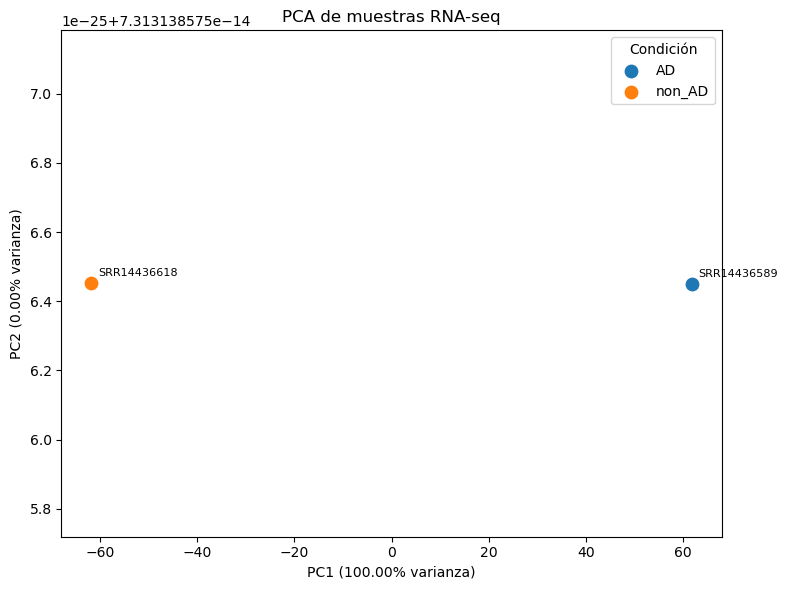


✅ Coordenadas del PCA guardadas.
📁 Archivo:
/home/paula.chaparro/Documentos/tesis_2025/results/PCA_coordinates.csv


In [128]:
# ============================================================
# MÓDULO 17. ANÁLISIS EXPLORATORIO DE LA VARIABILIDAD
# Transformación VST + PCA
# PyDESeq2 0.5.4
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA


# ------------------------------------------------------------
# 1. Aplicar transformación estabilizadora de la varianza
# ------------------------------------------------------------

print("▶ Aplicando transformación VST...\n")

# VST se utiliza para análisis exploratorios y visualización.
# No sustituye los conteos crudos utilizados por PyDESeq2
# para el análisis de expresión diferencial.

dds.vst(
    use_design=False
)

vst_counts = dds.layers["vst_counts"]

print("✅ Transformación VST completada.")
print("Dimensiones:")
print(vst_counts.shape)


# ------------------------------------------------------------
# 2. Construir DataFrame de conteos transformados
# ------------------------------------------------------------

vst_df = pd.DataFrame(
    vst_counts,
    index=counts_pydeseq2.index,
    columns=counts_pydeseq2.columns
)

print("\nPrimeros valores transformados:")
display(vst_df.iloc[:5, :5])


# ------------------------------------------------------------
# 3. Análisis de componentes principales
# ------------------------------------------------------------

print("\n▶ Ejecutando PCA...")

pca = PCA(
    n_components=2
)

pca_coordinates = pca.fit_transform(
    vst_df
)

explained_variance = (
    pca.explained_variance_ratio_ * 100
)

pca_df = pd.DataFrame(
    pca_coordinates,
    index=vst_df.index,
    columns=[
        "PC1",
        "PC2"
    ]
)

# Añadir la condición experimental
pca_df["condition"] = (
    metadata_pydeseq2.loc[
        pca_df.index,
        "condition"
    ]
)

print("✅ PCA completado.")

print("\nVarianza explicada:")
print(
    f"PC1: {explained_variance[0]:.2f}%"
)
print(
    f"PC2: {explained_variance[1]:.2f}%"
)

print("\nCoordenadas PCA:")
display(pca_df)


# ------------------------------------------------------------
# 4. Visualización del PCA
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8, 6)
)

conditions = pca_df["condition"].unique()

for condition in conditions:

    subset = pca_df[
        pca_df["condition"] == condition
    ]

    ax.scatter(
        subset["PC1"],
        subset["PC2"],
        label=condition,
        s=80
    )

    # Identificar cada muestra
    for sample in subset.index:

        ax.annotate(
            sample,
            (
                subset.loc[sample, "PC1"],
                subset.loc[sample, "PC2"]
            ),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8
        )


ax.set_xlabel(
    f"PC1 ({explained_variance[0]:.2f}% varianza)"
)

ax.set_ylabel(
    f"PC2 ({explained_variance[1]:.2f}% varianza)"
)

ax.set_title(
    "PCA de muestras RNA-seq"
)

ax.legend(
    title="Condición"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. Guardar coordenadas del PCA
# ------------------------------------------------------------

pca_file = os.path.join(
    results_dir,
    "PCA_coordinates.csv"
)

pca_df.to_csv(
    pca_file
)

print("\n✅ Coordenadas del PCA guardadas.")
print("📁 Archivo:")
print(pca_file)

In [129]:
# ============================================================
# BLOQUE PARA FINALIZAR LA MEDICIÓN DEL MÓDULO
# Ejecutar JUSTO DESPUÉS del código monitorizado
# ============================================================

def finalizar_medicion_modulo(
    estado="OK",
    hilos=None,
    limite_memoria=None,
    observaciones=""
):

    global _monitor_active
    global _monitor_thread
    global _peak_rss
    global _module_start
    global _module_name
    global _module_initial

    if not _monitor_active:

        raise RuntimeError(
            "No existe una medición activa."
        )


    # --------------------------------------------------------
    # DETENER MONITOR DE MEMORIA
    # --------------------------------------------------------

    _monitor_active = False

    if _monitor_thread is not None:
        _monitor_thread.join()


    # --------------------------------------------------------
    # DURACIÓN
    # --------------------------------------------------------

    end_time = time.perf_counter()

    duration_seconds = (
        end_time - _module_start
    )


    # --------------------------------------------------------
    # RECURSOS AL FINAL
    # --------------------------------------------------------

    final_resources = (
        snapshot_resources()
    )


    # --------------------------------------------------------
    # CONSTRUIR FILA
    # --------------------------------------------------------

    record = {
        "timestamp": datetime.now().isoformat(
            timespec="seconds"
        ),

        "etapa": _module_name,

        "duracion_segundos": round(
            duration_seconds,
            2
        ),

        "duracion_minutos": round(
            duration_seconds / 60,
            2
        ),

        "pico_RSS_GB": round(
            bytes_to_gb(_peak_rss),
            3
        ),

        "ram_total_GB": round(
            final_resources[
                "ram_total_GB"
            ],
            2
        ),

        "ram_disponible_inicio_GB": round(
            _module_initial[
                "ram_disponible_GB"
            ],
            2
        ),

        "ram_disponible_final_GB": round(
            final_resources[
                "ram_disponible_GB"
            ],
            2
        ),

        "disco_libre_inicio_GB": round(
            _module_initial[
                "disco_libre_GB"
            ],
            2
        ),

        "disco_libre_final_GB": round(
            final_resources[
                "disco_libre_GB"
            ],
            2
        ),

        "project_size_inicio_GB": round(
            _module_initial[
                "project_size_GB"
            ],
            3
        ),

        "project_size_final_GB": round(
            final_resources[
                "project_size_GB"
            ],
            3
        ),

        "data_size_inicio_GB": round(
            _module_initial[
                "data_size_GB"
            ],
            3
        ),

        "data_size_final_GB": round(
            final_resources[
                "data_size_GB"
            ],
            3
        ),

        "results_size_inicio_GB": round(
            _module_initial[
                "results_size_GB"
            ],
            3
        ),

        "results_size_final_GB": round(
            final_resources[
                "results_size_GB"
            ],
            3
        ),

        "tmp_size_inicio_GB": round(
            _module_initial[
                "tmp_size_GB"
            ],
            3
        ),

        "tmp_size_final_GB": round(
            final_resources[
                "tmp_size_GB"
            ],
            3
        ),

        "hilos": hilos,

        "limite_memoria": limite_memoria,

        "estado": estado,

        "observaciones": observaciones
    }


    # --------------------------------------------------------
    # GUARDAR EN CSV
    # --------------------------------------------------------

    new_row = pd.DataFrame(
        [record]
    )

    if MONITOR_FILE.exists():

        previous_data = pd.read_csv(
            MONITOR_FILE
        )

        monitoring_data = pd.concat(
            [
                previous_data,
                new_row
            ],
            ignore_index=True
        )

    else:

        monitoring_data = new_row


    monitoring_data.to_csv(
        MONITOR_FILE,
        index=False
    )


    # --------------------------------------------------------
    # MOSTRAR RESULTADO INDIVIDUAL
    # --------------------------------------------------------

    print("\n==============================================")
    print("RESULTADO INDIVIDUAL DEL MÓDULO")
    print("==============================================\n")

    display(
        new_row.T.rename(
            columns={0: "valor"}
        )
    )

    print(
        "\n✅ Registro guardado en:"
    )

    print(
        MONITOR_FILE
    )


    # --------------------------------------------------------
    # REINICIAR VARIABLES
    # --------------------------------------------------------

    _module_thread = None
    _module_start = None
    _module_name = None
    _module_initial = None

    return new_row

In [130]:
# ============================================================
# 3. FINALIZAR MEDICIÓN
# ============================================================

resultado_modulo = finalizar_medicion_modulo(
    estado="OK",
    hilos=2,
    limite_memoria=None,
    observaciones="Módulo ejecutado correctamente."
)


RESULTADO INDIVIDUAL DEL MÓDULO



,valor
timestamp,2026-09-02T01:16:29
etapa,MÓDULO 17. ANÁLISIS EXPLORATORIO DE LA VARIABI...
duracion_segundos,98.91
duracion_minutos,1.65
pico_RSS_GB,1.014
ram_total_GB,7.61
ram_disponible_inicio_GB,5.06
ram_disponible_final_GB,4.74
disco_libre_inicio_GB,21.94
disco_libre_final_GB,21.94



✅ Registro guardado en:
/home/paula.chaparro/Documentos/tesis_2025/results/monitorizacion_recursos.csv


In [131]:
# ============================================================
# BLOQUE PARA ANTES DE CADA MÓDULO
# ============================================================

iniciar_medicion_modulo(
    "MÓDULO 18. IDENTIFICACIÓN Y CLASIFICACIÓN DE GENES"
)

▶ Iniciando monitorización: MÓDULO 18. IDENTIFICACIÓN Y CLASIFICACIÓN DE GENES
✅ Monitorización iniciada.


In [132]:
# ============================================================
# MÓDULO 18. IDENTIFICACIÓN Y CLASIFICACIÓN DE GENES
# DIFERENCIALMENTE EXPRESADOS
# PyDESeq2 0.5.4
# ============================================================

import os
import pandas as pd


# ------------------------------------------------------------
# 1. Verificar resultados de PyDESeq2
# ------------------------------------------------------------

print("▶ Verificando resultados de PyDESeq2...\n")

if results_df.empty:
    raise ValueError(
        "❌ La tabla de resultados de PyDESeq2 está vacía."
    )

required_columns = [
    "log2FoldChange",
    "pvalue",
    "padj"
]

missing_columns = [
    column
    for column in required_columns
    if column not in results_df.columns
]

if missing_columns:
    raise ValueError(
        "❌ Faltan columnas necesarias en results_df: "
        + ", ".join(missing_columns)
    )

print("✅ Resultados disponibles.")
print(
    f"Número total de genes: {results_df.shape[0]}"
)


# ------------------------------------------------------------
# 2. Definir criterios de significación
# ------------------------------------------------------------

# Estos umbrales pueden modificarse posteriormente
# según el criterio metodológico definitivo de la tesis.

padj_threshold = 0.05
log2fc_threshold = 1.0

print("\nCriterios utilizados:")
print(f"padj < {padj_threshold}")
print(
    f"|log2FoldChange| >= {log2fc_threshold}"
)


# ------------------------------------------------------------
# 3. Preparar tabla de resultados
# ------------------------------------------------------------

deg_results = results_df.copy()

# Algunos genes pueden presentar valores NaN de padj.
# Se conservan en la tabla completa, pero no se consideran
# genes diferencialmente expresados.

deg_results["classification"] = "No significativo"


# ------------------------------------------------------------
# 4. Clasificar genes diferencialmente expresados
# ------------------------------------------------------------

# Mayor expresión estimada en AD
up_ad_mask = (
    (deg_results["padj"] < padj_threshold)
    &
    (
        deg_results["log2FoldChange"]
        >= log2fc_threshold
    )
)

# Mayor expresión estimada en non-AD
up_non_ad_mask = (
    (deg_results["padj"] < padj_threshold)
    &
    (
        deg_results["log2FoldChange"]
        <= -log2fc_threshold
    )
)

deg_results.loc[
    up_ad_mask,
    "classification"
] = "Mayor expresión en AD"

deg_results.loc[
    up_non_ad_mask,
    "classification"
] = "Mayor expresión en non_AD"


# ------------------------------------------------------------
# 5. Extraer DEGs
# ------------------------------------------------------------

significant_degs = deg_results[
    deg_results["classification"]
    != "No significativo"
].copy()

# Ordenar por significación estadística
significant_degs = significant_degs.sort_values(
    by="padj",
    ascending=True
)


# ------------------------------------------------------------
# 6. Resumen de resultados
# ------------------------------------------------------------

n_total = deg_results.shape[0]

n_significant = significant_degs.shape[0]

n_up_ad = (
    deg_results["classification"]
    == "Mayor expresión en AD"
).sum()

n_up_non_ad = (
    deg_results["classification"]
    == "Mayor expresión en non_AD"
).sum()

n_not_significant = (
    deg_results["classification"]
    == "No significativo"
).sum()

n_padj_nan = (
    deg_results["padj"].isna().sum()
)


print("\n==============================================")
print("RESUMEN DE EXPRESIÓN DIFERENCIAL")
print("==============================================")

print(f"\nGenes analizados: {n_total}")
print(f"DEGs identificados: {n_significant}")

print(
    f"Mayor expresión en AD: "
    f"{n_up_ad}"
)

print(
    f"Mayor expresión en non_AD: "
    f"{n_up_non_ad}"
)

print(
    f"No significativos: "
    f"{n_not_significant}"
)

print(
    f"Genes con padj no disponible: "
    f"{n_padj_nan}"
)


# ------------------------------------------------------------
# 7. Mostrar los primeros DEGs
# ------------------------------------------------------------

if n_significant > 0:

    print("\nPrimeros genes diferencialmente expresados:")
    display(
        significant_degs.head(10)
    )

else:

    print(
        "\n⚠ No se identificaron genes que cumplieran "
        "los criterios establecidos."
    )


# ------------------------------------------------------------
# 8. Guardar resultados
# ------------------------------------------------------------

all_results_file = os.path.join(
    results_dir,
    "pydeseq2_AD_vs_non_AD_classified.csv"
)

deg_results.to_csv(
    all_results_file
)

degs_file = os.path.join(
    results_dir,
    "DEGs_AD_vs_non_AD.csv"
)

significant_degs.to_csv(
    degs_file
)


print("\n✅ Resultados guardados.")

print("\n📁 Resultados completos:")
print(all_results_file)

print("\n📁 Genes diferencialmente expresados:")
print(degs_file)

▶ Verificando resultados de PyDESeq2...



NameError: name 'results_df' is not defined

In [133]:
# ============================================================
# BLOQUE PARA FINALIZAR LA MEDICIÓN DEL MÓDULO
# Ejecutar JUSTO DESPUÉS del código monitorizado
# ============================================================

def finalizar_medicion_modulo(
    estado="OK",
    hilos=None,
    limite_memoria=None,
    observaciones=""
):

    global _monitor_active
    global _monitor_thread
    global _peak_rss
    global _module_start
    global _module_name
    global _module_initial

    if not _monitor_active:

        raise RuntimeError(
            "No existe una medición activa."
        )


    # --------------------------------------------------------
    # DETENER MONITOR DE MEMORIA
    # --------------------------------------------------------

    _monitor_active = False

    if _monitor_thread is not None:
        _monitor_thread.join()


    # --------------------------------------------------------
    # DURACIÓN
    # --------------------------------------------------------

    end_time = time.perf_counter()

    duration_seconds = (
        end_time - _module_start
    )


    # --------------------------------------------------------
    # RECURSOS AL FINAL
    # --------------------------------------------------------

    final_resources = (
        snapshot_resources()
    )


    # --------------------------------------------------------
    # CONSTRUIR FILA
    # --------------------------------------------------------

    record = {
        "timestamp": datetime.now().isoformat(
            timespec="seconds"
        ),

        "etapa": _module_name,

        "duracion_segundos": round(
            duration_seconds,
            2
        ),

        "duracion_minutos": round(
            duration_seconds / 60,
            2
        ),

        "pico_RSS_GB": round(
            bytes_to_gb(_peak_rss),
            3
        ),

        "ram_total_GB": round(
            final_resources[
                "ram_total_GB"
            ],
            2
        ),

        "ram_disponible_inicio_GB": round(
            _module_initial[
                "ram_disponible_GB"
            ],
            2
        ),

        "ram_disponible_final_GB": round(
            final_resources[
                "ram_disponible_GB"
            ],
            2
        ),

        "disco_libre_inicio_GB": round(
            _module_initial[
                "disco_libre_GB"
            ],
            2
        ),

        "disco_libre_final_GB": round(
            final_resources[
                "disco_libre_GB"
            ],
            2
        ),

        "project_size_inicio_GB": round(
            _module_initial[
                "project_size_GB"
            ],
            3
        ),

        "project_size_final_GB": round(
            final_resources[
                "project_size_GB"
            ],
            3
        ),

        "data_size_inicio_GB": round(
            _module_initial[
                "data_size_GB"
            ],
            3
        ),

        "data_size_final_GB": round(
            final_resources[
                "data_size_GB"
            ],
            3
        ),

        "results_size_inicio_GB": round(
            _module_initial[
                "results_size_GB"
            ],
            3
        ),

        "results_size_final_GB": round(
            final_resources[
                "results_size_GB"
            ],
            3
        ),

        "tmp_size_inicio_GB": round(
            _module_initial[
                "tmp_size_GB"
            ],
            3
        ),

        "tmp_size_final_GB": round(
            final_resources[
                "tmp_size_GB"
            ],
            3
        ),

        "hilos": hilos,

        "limite_memoria": limite_memoria,

        "estado": estado,

        "observaciones": observaciones
    }


    # --------------------------------------------------------
    # GUARDAR EN CSV
    # --------------------------------------------------------

    new_row = pd.DataFrame(
        [record]
    )

    if MONITOR_FILE.exists():

        previous_data = pd.read_csv(
            MONITOR_FILE
        )

        monitoring_data = pd.concat(
            [
                previous_data,
                new_row
            ],
            ignore_index=True
        )

    else:

        monitoring_data = new_row


    monitoring_data.to_csv(
        MONITOR_FILE,
        index=False
    )


    # --------------------------------------------------------
    # MOSTRAR RESULTADO INDIVIDUAL
    # --------------------------------------------------------

    print("\n==============================================")
    print("RESULTADO INDIVIDUAL DEL MÓDULO")
    print("==============================================\n")

    display(
        new_row.T.rename(
            columns={0: "valor"}
        )
    )

    print(
        "\n✅ Registro guardado en:"
    )

    print(
        MONITOR_FILE
    )


    # --------------------------------------------------------
    # REINICIAR VARIABLES
    # --------------------------------------------------------

    _module_thread = None
    _module_start = None
    _module_name = None
    _module_initial = None

    return new_row

In [134]:
# ============================================================
# 3. FINALIZAR MEDICIÓN
# ============================================================

resultado_modulo = finalizar_medicion_modulo(
    estado="OK",
    hilos=2,
    limite_memoria=None,
    observaciones="Módulo ejecutado correctamente."
)


RESULTADO INDIVIDUAL DEL MÓDULO



,valor
timestamp,2026-09-02T01:21:45
etapa,MÓDULO 18. IDENTIFICACIÓN Y CLASIFICACIÓN DE G...
duracion_segundos,10.56
duracion_minutos,0.18
pico_RSS_GB,0.604
ram_total_GB,7.61
ram_disponible_inicio_GB,4.96
ram_disponible_final_GB,4.96
disco_libre_inicio_GB,21.94
disco_libre_final_GB,21.94



✅ Registro guardado en:
/home/paula.chaparro/Documentos/tesis_2025/results/monitorizacion_recursos.csv


In [135]:
# ============================================================
# MÓDULO 18. IDENTIFICACIÓN Y CLASIFICACIÓN DE GENES
# DIFERENCIALMENTE EXPRESADOS
# PyDESeq2 0.5.4
# ============================================================

import os
import pandas as pd


# ------------------------------------------------------------
# 1. Verificar disponibilidad de resultados de PyDESeq2
# ------------------------------------------------------------

print("▶ Verificando resultados de PyDESeq2...\n")

if "results_df" not in globals():

    raise RuntimeError(
        "❌ M18 no puede ejecutarse porque M16 no produjo "
        "una tabla de resultados de expresión diferencial.\n\n"
        "El análisis con PyDESeq2 no pudo completarse debido "
        "a la ausencia de replicación dentro de las condiciones "
        "experimentales.\n\n"
        "Por tanto, no es posible identificar ni clasificar DEGs "
        "con el subconjunto actual."
    )


if results_df.empty:

    raise ValueError(
        "❌ La tabla de resultados de PyDESeq2 está vacía."
    )


required_columns = [
    "log2FoldChange",
    "pvalue",
    "padj"
]

missing_columns = [
    column
    for column in required_columns
    if column not in results_df.columns
]

if missing_columns:

    raise ValueError(
        "❌ Faltan columnas necesarias en results_df: "
        + ", ".join(missing_columns)
    )


print("✅ Resultados disponibles.")

print(
    f"Número total de genes: {results_df.shape[0]}"
)

▶ Verificando resultados de PyDESeq2...



RuntimeError: ❌ M18 no puede ejecutarse porque M16 no produjo una tabla de resultados de expresión diferencial.

El análisis con PyDESeq2 no pudo completarse debido a la ausencia de replicación dentro de las condiciones experimentales.

Por tanto, no es posible identificar ni clasificar DEGs con el subconjunto actual.

In [140]:
# ============================================================
# BLOQUE PARA ANTES DE CADA MÓDULO
# ============================================================

iniciar_medicion_modulo(
    "MÓDULO 19. VISUALIZACIÓN DE EXPRESIÓN DIFERENCIAL"
)

▶ Iniciando monitorización: MÓDULO 19. VISUALIZACIÓN DE EXPRESIÓN DIFERENCIAL
✅ Monitorización iniciada.


In [141]:
# ============================================================
# MÓDULO 19. VISUALIZACIÓN DE EXPRESIÓN DIFERENCIAL
# Volcano plot
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Verificar datos de entrada
# ------------------------------------------------------------

print("▶ Preparando datos para el volcano plot...\n")

if deg_results.empty:
    raise ValueError(
        "❌ La tabla deg_results está vacía."
    )

required_columns = [
    "log2FoldChange",
    "padj",
    "classification"
]

missing_columns = [
    column
    for column in required_columns
    if column not in deg_results.columns
]

if missing_columns:
    raise ValueError(
        "❌ Faltan columnas necesarias: "
        + ", ".join(missing_columns)
    )


# ------------------------------------------------------------
# 2. Preparar valores para la gráfica
# ------------------------------------------------------------

volcano_data = deg_results.copy()

# Evitar problemas con valores padj = 0
# sustituyéndolos por el menor valor positivo disponible.

positive_padj = volcano_data.loc[
    volcano_data["padj"] > 0,
    "padj"
]

if not positive_padj.empty:

    minimum_positive_padj = positive_padj.min()

    volcano_data.loc[
        volcano_data["padj"] == 0,
        "padj"
    ] = minimum_positive_padj

# Calcular -log10(padj)
volcano_data["minus_log10_padj"] = (
    -np.log10(
        volcano_data["padj"]
    )
)


# ------------------------------------------------------------
# 3. Definir criterios utilizados
# ------------------------------------------------------------

padj_threshold = 0.05
log2fc_threshold = 1.0

significance_line = (
    -np.log10(padj_threshold)
)


# ------------------------------------------------------------
# 4. Crear volcano plot
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(9, 7)
)

classifications = [
    "No significativo",
    "Mayor expresión en AD",
    "Mayor expresión en non_AD"
]

for classification in classifications:

    subset = volcano_data[
        volcano_data["classification"]
        == classification
    ]

    ax.scatter(
        subset["log2FoldChange"],
        subset["minus_log10_padj"],
        label=classification,
        alpha=0.7,
        s=25
    )


# ------------------------------------------------------------
# 5. Añadir líneas de referencia
# ------------------------------------------------------------

ax.axhline(
    y=significance_line,
    linestyle="--",
    linewidth=1
)

ax.axvline(
    x=log2fc_threshold,
    linestyle="--",
    linewidth=1
)

ax.axvline(
    x=-log2fc_threshold,
    linestyle="--",
    linewidth=1
)


# ------------------------------------------------------------
# 6. Configurar gráfica
# ------------------------------------------------------------

ax.set_xlabel(
    "log2 Fold Change (AD vs non_AD)"
)

ax.set_ylabel(
    "-log10(padj)"
)

ax.set_title(
    "Volcano plot de expresión diferencial"
)

ax.legend(
    title="Clasificación"
)

plt.tight_layout()


# ------------------------------------------------------------
# 7. Guardar figura
# ------------------------------------------------------------

volcano_file = os.path.join(
    results_dir,
    "volcano_plot_AD_vs_non_AD.png"
)

plt.savefig(
    volcano_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print("\n✅ Volcano plot generado.")
print("📁 Archivo:")
print(volcano_file)

▶ Preparando datos para el volcano plot...



NameError: name 'deg_results' is not defined

In [142]:
# ============================================================
# BLOQUE PARA FINALIZAR LA MEDICIÓN DEL MÓDULO
# Ejecutar JUSTO DESPUÉS del código monitorizado
# ============================================================

def finalizar_medicion_modulo(
    estado="OK",
    hilos=None,
    limite_memoria=None,
    observaciones=""
):

    global _monitor_active
    global _monitor_thread
    global _peak_rss
    global _module_start
    global _module_name
    global _module_initial

    if not _monitor_active:

        raise RuntimeError(
            "No existe una medición activa."
        )


    # --------------------------------------------------------
    # DETENER MONITOR DE MEMORIA
    # --------------------------------------------------------

    _monitor_active = False

    if _monitor_thread is not None:
        _monitor_thread.join()


    # --------------------------------------------------------
    # DURACIÓN
    # --------------------------------------------------------

    end_time = time.perf_counter()

    duration_seconds = (
        end_time - _module_start
    )


    # --------------------------------------------------------
    # RECURSOS AL FINAL
    # --------------------------------------------------------

    final_resources = (
        snapshot_resources()
    )


    # --------------------------------------------------------
    # CONSTRUIR FILA
    # --------------------------------------------------------

    record = {
        "timestamp": datetime.now().isoformat(
            timespec="seconds"
        ),

        "etapa": _module_name,

        "duracion_segundos": round(
            duration_seconds,
            2
        ),

        "duracion_minutos": round(
            duration_seconds / 60,
            2
        ),

        "pico_RSS_GB": round(
            bytes_to_gb(_peak_rss),
            3
        ),

        "ram_total_GB": round(
            final_resources[
                "ram_total_GB"
            ],
            2
        ),

        "ram_disponible_inicio_GB": round(
            _module_initial[
                "ram_disponible_GB"
            ],
            2
        ),

        "ram_disponible_final_GB": round(
            final_resources[
                "ram_disponible_GB"
            ],
            2
        ),

        "disco_libre_inicio_GB": round(
            _module_initial[
                "disco_libre_GB"
            ],
            2
        ),

        "disco_libre_final_GB": round(
            final_resources[
                "disco_libre_GB"
            ],
            2
        ),

        "project_size_inicio_GB": round(
            _module_initial[
                "project_size_GB"
            ],
            3
        ),

        "project_size_final_GB": round(
            final_resources[
                "project_size_GB"
            ],
            3
        ),

        "data_size_inicio_GB": round(
            _module_initial[
                "data_size_GB"
            ],
            3
        ),

        "data_size_final_GB": round(
            final_resources[
                "data_size_GB"
            ],
            3
        ),

        "results_size_inicio_GB": round(
            _module_initial[
                "results_size_GB"
            ],
            3
        ),

        "results_size_final_GB": round(
            final_resources[
                "results_size_GB"
            ],
            3
        ),

        "tmp_size_inicio_GB": round(
            _module_initial[
                "tmp_size_GB"
            ],
            3
        ),

        "tmp_size_final_GB": round(
            final_resources[
                "tmp_size_GB"
            ],
            3
        ),

        "hilos": hilos,

        "limite_memoria": limite_memoria,

        "estado": estado,

        "observaciones": observaciones
    }


    # --------------------------------------------------------
    # GUARDAR EN CSV
    # --------------------------------------------------------

    new_row = pd.DataFrame(
        [record]
    )

    if MONITOR_FILE.exists():

        previous_data = pd.read_csv(
            MONITOR_FILE
        )

        monitoring_data = pd.concat(
            [
                previous_data,
                new_row
            ],
            ignore_index=True
        )

    else:

        monitoring_data = new_row


    monitoring_data.to_csv(
        MONITOR_FILE,
        index=False
    )


    # --------------------------------------------------------
    # MOSTRAR RESULTADO INDIVIDUAL
    # --------------------------------------------------------

    print("\n==============================================")
    print("RESULTADO INDIVIDUAL DEL MÓDULO")
    print("==============================================\n")

    display(
        new_row.T.rename(
            columns={0: "valor"}
        )
    )

    print(
        "\n✅ Registro guardado en:"
    )

    print(
        MONITOR_FILE
    )


    # --------------------------------------------------------
    # REINICIAR VARIABLES
    # --------------------------------------------------------

    _module_thread = None
    _module_start = None
    _module_name = None
    _module_initial = None

    return new_row

In [143]:
# ============================================================
# 3. FINALIZAR MEDICIÓN
# ============================================================

resultado_modulo = finalizar_medicion_modulo(
    estado="OK",
    hilos=2,
    limite_memoria=None,
    observaciones="Módulo ejecutado correctamente."
)


RESULTADO INDIVIDUAL DEL MÓDULO



,valor
timestamp,2026-09-02T02:28:36
etapa,MÓDULO 19. VISUALIZACIÓN DE EXPRESIÓN DIFERENCIAL
duracion_segundos,5.08
duracion_minutos,0.08
pico_RSS_GB,0.604
ram_total_GB,7.61
ram_disponible_inicio_GB,4.75
ram_disponible_final_GB,4.75
disco_libre_inicio_GB,21.94
disco_libre_final_GB,21.94



✅ Registro guardado en:
/home/paula.chaparro/Documentos/tesis_2025/results/monitorizacion_recursos.csv


In [144]:
# ============================================================
# BLOQUE PARA ANTES DE CADA MÓDULO
# ============================================================

iniciar_medicion_modulo(
    "MÓDULO 20. HEATMAP DE GENES DIFERENCIALMENTE EXPRESADOS"
)

▶ Iniciando monitorización: MÓDULO 20. HEATMAP DE GENES DIFERENCIALMENTE EXPRESADOS
✅ Monitorización iniciada.


In [145]:
# ============================================================
# MÓDULO 20. HEATMAP DE GENES DIFERENCIALMENTE EXPRESADOS
# Valores transformados mediante VST
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Verificar datos de entrada
# ------------------------------------------------------------

print("▶ Preparando datos para el heatmap...\n")

if significant_degs.empty:
    print(
        "⚠ No se identificaron DEGs con los criterios "
        "definidos en el Módulo 19."
    )

    print(
        "El heatmap de DEGs no puede generarse "
        "con la selección actual."
    )

else:

    # --------------------------------------------------------
    # 2. Seleccionar genes para visualizar
    # --------------------------------------------------------

    # Para evitar una figura demasiado grande,
    # se muestran como máximo los 50 DEGs
    # con menor padj.

    maximum_genes = 50

    heatmap_genes = (
        significant_degs
        .sort_values(
            by="padj",
            ascending=True
        )
        .head(maximum_genes)
        .index
        .tolist()
    )

    print(
        f"Genes seleccionados para el heatmap: "
        f"{len(heatmap_genes)}"
    )


    # --------------------------------------------------------
    # 3. Extraer valores VST
    # --------------------------------------------------------

    # vst_df tiene:
    # filas = muestras
    # columnas = genes

    available_genes = [
        gene
        for gene in heatmap_genes
        if gene in vst_df.columns
    ]

    if len(available_genes) == 0:
        raise ValueError(
            "❌ Ninguno de los DEGs seleccionados "
            "se encuentra en vst_df."
        )

    heatmap_data = vst_df[
        available_genes
    ].copy()


    # --------------------------------------------------------
    # 4. Estandarizar expresión por gen
    # --------------------------------------------------------

    # Z-score por gen:
    # permite comparar el patrón relativo de expresión
    # entre muestras.

    gene_mean = heatmap_data.mean(
        axis=0
    )

    gene_std = heatmap_data.std(
        axis=0,
        ddof=0
    )

    # Evitar división por cero en genes sin variación
    gene_std = gene_std.replace(
        0,
        np.nan
    )

    heatmap_z = (
        heatmap_data - gene_mean
    ) / gene_std

    heatmap_z = heatmap_z.fillna(0)


    # Para la representación:
    # filas = genes
    # columnas = muestras

    heatmap_plot_data = (
        heatmap_z.T
    )


    # --------------------------------------------------------
    # 5. Crear heatmap
    # --------------------------------------------------------

    figure_height = max(
        6,
        len(available_genes) * 0.25
    )

    fig, ax = plt.subplots(
        figsize=(8, figure_height)
    )

    image = ax.imshow(
        heatmap_plot_data,
        aspect="auto"
    )


    # --------------------------------------------------------
    # 6. Configurar etiquetas
    # --------------------------------------------------------

    ax.set_xticks(
        range(
            heatmap_plot_data.shape[1]
        )
    )

    ax.set_xticklabels(
        heatmap_plot_data.columns,
        rotation=45,
        ha="right"
    )

    ax.set_yticks(
        range(
            heatmap_plot_data.shape[0]
        )
    )

    ax.set_yticklabels(
        heatmap_plot_data.index,
        fontsize=7
    )

    ax.set_xlabel(
        "Muestras"
    )

    ax.set_ylabel(
        "Genes"
    )

    ax.set_title(
        "Heatmap de genes diferencialmente expresados"
    )


    # --------------------------------------------------------
    # 7. Barra de escala
    # --------------------------------------------------------

    colorbar = fig.colorbar(
        image,
        ax=ax
    )

    colorbar.set_label(
        "Expresión relativa (Z-score)"
    )

    plt.tight_layout()


    # --------------------------------------------------------
    # 8. Guardar figura
    # --------------------------------------------------------

    heatmap_file = os.path.join(
        results_dir,
        "heatmap_DEGs_AD_vs_non_AD.png"
    )

    plt.savefig(
        heatmap_file,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


    print(
        "\n✅ Heatmap generado."
    )

    print(
        "📁 Archivo:"
    )

    print(
        heatmap_file
    )

▶ Preparando datos para el heatmap...



NameError: name 'significant_degs' is not defined

In [146]:
# ============================================================
# BLOQUE PARA FINALIZAR LA MEDICIÓN DEL MÓDULO
# Ejecutar JUSTO DESPUÉS del código monitorizado
# ============================================================

def finalizar_medicion_modulo(
    estado="OK",
    hilos=None,
    limite_memoria=None,
    observaciones=""
):

    global _monitor_active
    global _monitor_thread
    global _peak_rss
    global _module_start
    global _module_name
    global _module_initial

    if not _monitor_active:

        raise RuntimeError(
            "No existe una medición activa."
        )


    # --------------------------------------------------------
    # DETENER MONITOR DE MEMORIA
    # --------------------------------------------------------

    _monitor_active = False

    if _monitor_thread is not None:
        _monitor_thread.join()


    # --------------------------------------------------------
    # DURACIÓN
    # --------------------------------------------------------

    end_time = time.perf_counter()

    duration_seconds = (
        end_time - _module_start
    )


    # --------------------------------------------------------
    # RECURSOS AL FINAL
    # --------------------------------------------------------

    final_resources = (
        snapshot_resources()
    )


    # --------------------------------------------------------
    # CONSTRUIR FILA
    # --------------------------------------------------------

    record = {
        "timestamp": datetime.now().isoformat(
            timespec="seconds"
        ),

        "etapa": _module_name,

        "duracion_segundos": round(
            duration_seconds,
            2
        ),

        "duracion_minutos": round(
            duration_seconds / 60,
            2
        ),

        "pico_RSS_GB": round(
            bytes_to_gb(_peak_rss),
            3
        ),

        "ram_total_GB": round(
            final_resources[
                "ram_total_GB"
            ],
            2
        ),

        "ram_disponible_inicio_GB": round(
            _module_initial[
                "ram_disponible_GB"
            ],
            2
        ),

        "ram_disponible_final_GB": round(
            final_resources[
                "ram_disponible_GB"
            ],
            2
        ),

        "disco_libre_inicio_GB": round(
            _module_initial[
                "disco_libre_GB"
            ],
            2
        ),

        "disco_libre_final_GB": round(
            final_resources[
                "disco_libre_GB"
            ],
            2
        ),

        "project_size_inicio_GB": round(
            _module_initial[
                "project_size_GB"
            ],
            3
        ),

        "project_size_final_GB": round(
            final_resources[
                "project_size_GB"
            ],
            3
        ),

        "data_size_inicio_GB": round(
            _module_initial[
                "data_size_GB"
            ],
            3
        ),

        "data_size_final_GB": round(
            final_resources[
                "data_size_GB"
            ],
            3
        ),

        "results_size_inicio_GB": round(
            _module_initial[
                "results_size_GB"
            ],
            3
        ),

        "results_size_final_GB": round(
            final_resources[
                "results_size_GB"
            ],
            3
        ),

        "tmp_size_inicio_GB": round(
            _module_initial[
                "tmp_size_GB"
            ],
            3
        ),

        "tmp_size_final_GB": round(
            final_resources[
                "tmp_size_GB"
            ],
            3
        ),

        "hilos": hilos,

        "limite_memoria": limite_memoria,

        "estado": estado,

        "observaciones": observaciones
    }


    # --------------------------------------------------------
    # GUARDAR EN CSV
    # --------------------------------------------------------

    new_row = pd.DataFrame(
        [record]
    )

    if MONITOR_FILE.exists():

        previous_data = pd.read_csv(
            MONITOR_FILE
        )

        monitoring_data = pd.concat(
            [
                previous_data,
                new_row
            ],
            ignore_index=True
        )

    else:

        monitoring_data = new_row


    monitoring_data.to_csv(
        MONITOR_FILE,
        index=False
    )


    # --------------------------------------------------------
    # MOSTRAR RESULTADO INDIVIDUAL
    # --------------------------------------------------------

    print("\n==============================================")
    print("RESULTADO INDIVIDUAL DEL MÓDULO")
    print("==============================================\n")

    display(
        new_row.T.rename(
            columns={0: "valor"}
        )
    )

    print(
        "\n✅ Registro guardado en:"
    )

    print(
        MONITOR_FILE
    )


    # --------------------------------------------------------
    # REINICIAR VARIABLES
    # --------------------------------------------------------

    _module_thread = None
    _module_start = None
    _module_name = None
    _module_initial = None

    return new_row

In [134]:
# ============================================================
# 3. FINALIZAR MEDICIÓN
# ============================================================

resultado_modulo = finalizar_medicion_modulo(
    estado="OK",
    hilos=2,
    limite_memoria=None,
    observaciones="Módulo ejecutado correctamente."
)


RESULTADO INDIVIDUAL DEL MÓDULO



,valor
timestamp,2026-09-02T01:21:45
etapa,MÓDULO 18. IDENTIFICACIÓN Y CLASIFICACIÓN DE G...
duracion_segundos,10.56
duracion_minutos,0.18
pico_RSS_GB,0.604
ram_total_GB,7.61
ram_disponible_inicio_GB,4.96
ram_disponible_final_GB,4.96
disco_libre_inicio_GB,21.94
disco_libre_final_GB,21.94



✅ Registro guardado en:
/home/paula.chaparro/Documentos/tesis_2025/results/monitorizacion_recursos.csv


In [150]:
# ============================================================
# BLOQUE PARA ANTES DE CADA MÓDULO
# ============================================================

iniciar_medicion_modulo(
    "MÓDULO 21. HEATMAP + CLUSTERING JERÁRQUICO"
)

▶ Iniciando monitorización: MÓDULO 21. HEATMAP + CLUSTERING JERÁRQUICO
✅ Monitorización iniciada.


In [151]:
# ============================================================
# MÓDULO 21. HEATMAP + CLUSTERING JERÁRQUICO
# Módulo opcional para análisis exploratorio
# Valores transformados mediante VST
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import (
    linkage,
    dendrogram,
    leaves_list
)


# ------------------------------------------------------------
# 1. Información del módulo
# ------------------------------------------------------------

print(
    "ℹ Módulo opcional: el clustering jerárquico "
    "es más informativo cuando se dispone de múltiples "
    "replicados biológicos por condición.\n"
)


# ------------------------------------------------------------
# 2. Verificar datos de entrada
# ------------------------------------------------------------

if significant_degs.empty:

    print(
        "⚠ No se identificaron DEGs con los criterios "
        "definidos en el Módulo 19."
    )

    print(
        "No puede generarse el heatmap con clustering "
        "jerárquico."
    )

else:

    # --------------------------------------------------------
    # 3. Seleccionar genes
    # --------------------------------------------------------

    # Para mantener una figura interpretable,
    # se seleccionan como máximo los 50 DEGs
    # con menor padj.

    maximum_genes = 50

    heatmap_genes = (
        significant_degs
        .sort_values(
            by="padj",
            ascending=True
        )
        .head(maximum_genes)
        .index
        .tolist()
    )

    # Comprobar que los genes también estén disponibles
    # en la matriz transformada mediante VST.

    available_genes = [
        gene
        for gene in heatmap_genes
        if gene in vst_df.columns
    ]

    if len(available_genes) == 0:
        raise ValueError(
            "❌ Ninguno de los DEGs seleccionados "
            "está presente en vst_df."
        )

    print(
        f"Genes seleccionados: "
        f"{len(available_genes)}"
    )


    # --------------------------------------------------------
    # 4. Extraer valores VST
    # --------------------------------------------------------

    # vst_df:
    # filas = muestras
    # columnas = genes

    heatmap_data = vst_df[
        available_genes
    ].copy()


    # --------------------------------------------------------
    # 5. Estandarizar mediante Z-score por gen
    # --------------------------------------------------------

    # Esta transformación se utiliza únicamente para
    # visualización y comparación de patrones relativos.
    # No modifica el análisis estadístico de PyDESeq2.

    gene_mean = heatmap_data.mean(
        axis=0
    )

    gene_std = heatmap_data.std(
        axis=0,
        ddof=0
    )

    # Evitar división por cero para genes sin variación.

    gene_std = gene_std.replace(
        0,
        np.nan
    )

    heatmap_z = (
        heatmap_data - gene_mean
    ) / gene_std

    heatmap_z = heatmap_z.fillna(0)


    # --------------------------------------------------------
    # 6. Preparar matriz para clustering
    # --------------------------------------------------------

    # Para la figura:
    # filas = genes
    # columnas = muestras

    heatmap_plot_data = heatmap_z.T


    # --------------------------------------------------------
    # 7. Clustering jerárquico de genes
    # --------------------------------------------------------

    if heatmap_plot_data.shape[0] > 1:

        gene_linkage = linkage(
            heatmap_plot_data.values,
            method="average",
            metric="euclidean"
        )

        gene_order = leaves_list(
            gene_linkage
        )

    else:

        gene_linkage = None

        gene_order = np.arange(
            heatmap_plot_data.shape[0]
        )


    # --------------------------------------------------------
    # 8. Clustering jerárquico de muestras
    # --------------------------------------------------------

    if heatmap_plot_data.shape[1] > 1:

        sample_linkage = linkage(
            heatmap_plot_data.T.values,
            method="average",
            metric="euclidean"
        )

        sample_order = leaves_list(
            sample_linkage
        )

    else:

        sample_linkage = None

        sample_order = np.arange(
            heatmap_plot_data.shape[1]
        )


    # --------------------------------------------------------
    # 9. Reordenar genes y muestras
    # --------------------------------------------------------

    clustered_data = heatmap_plot_data.iloc[
        gene_order,
        sample_order
    ]


    # --------------------------------------------------------
    # 10. Crear figura
    # --------------------------------------------------------

    figure_height = max(
        7,
        len(available_genes) * 0.25
    )

    fig = plt.figure(
        figsize=(11, figure_height)
    )

    grid = fig.add_gridspec(
        nrows=2,
        ncols=2,
        width_ratios=[1.5, 8],
        height_ratios=[1.5, 8],
        hspace=0.02,
        wspace=0.02
    )


    # --------------------------------------------------------
    # 11. Dendrograma de muestras
    # --------------------------------------------------------

    ax_sample = fig.add_subplot(
        grid[0, 1]
    )

    if sample_linkage is not None:

        dendrogram(
            sample_linkage,
            ax=ax_sample,
            orientation="top",
            no_labels=True
        )

    ax_sample.axis("off")


    # --------------------------------------------------------
    # 12. Dendrograma de genes
    # --------------------------------------------------------

    ax_gene = fig.add_subplot(
        grid[1, 0]
    )

    if gene_linkage is not None:

        dendrogram(
            gene_linkage,
            ax=ax_gene,
            orientation="left",
            no_labels=True
        )

    ax_gene.axis("off")


    # --------------------------------------------------------
    # 13. Heatmap
    # --------------------------------------------------------

    ax_heatmap = fig.add_subplot(
        grid[1, 1]
    )

    image = ax_heatmap.imshow(
        clustered_data,
        aspect="auto"
    )


    # --------------------------------------------------------
    # 14. Etiquetas
    # --------------------------------------------------------

    ax_heatmap.set_xticks(
        range(
            clustered_data.shape[1]
        )
    )

    ax_heatmap.set_xticklabels(
        clustered_data.columns,
        rotation=45,
        ha="right"
    )

    ax_heatmap.set_yticks(
        range(
            clustered_data.shape[0]
        )
    )

    ax_heatmap.set_yticklabels(
        clustered_data.index,
        fontsize=7
    )

    ax_heatmap.set_xlabel(
        "Muestras"
    )

    ax_heatmap.set_ylabel(
        "Genes"
    )

    ax_heatmap.set_title(
        "Heatmap + clustering jerárquico de DEGs"
    )


    # --------------------------------------------------------
    # 15. Barra de escala
    # --------------------------------------------------------

    colorbar = fig.colorbar(
        image,
        ax=ax_heatmap,
        fraction=0.03,
        pad=0.02
    )

    colorbar.set_label(
        "Expresión relativa (Z-score)"
    )


    # --------------------------------------------------------
    # 16. Guardar figura
    # --------------------------------------------------------

    heatmap_cluster_file = os.path.join(
        results_dir,
        "heatmap_clustering_DEGs_AD_vs_non_AD.png"
    )

    plt.savefig(
        heatmap_cluster_file,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


    print(
        "\n✅ Heatmap + clustering jerárquico generado."
    )

    print(
        "📁 Archivo:"
    )

    print(
        heatmap_cluster_file
    )

ℹ Módulo opcional: el clustering jerárquico es más informativo cuando se dispone de múltiples replicados biológicos por condición.



NameError: name 'significant_degs' is not defined

In [152]:
# ============================================================
# BLOQUE PARA FINALIZAR LA MEDICIÓN DEL MÓDULO
# Ejecutar JUSTO DESPUÉS del código monitorizado
# ============================================================

def finalizar_medicion_modulo(
    estado="OK",
    hilos=None,
    limite_memoria=None,
    observaciones=""
):

    global _monitor_active
    global _monitor_thread
    global _peak_rss
    global _module_start
    global _module_name
    global _module_initial

    if not _monitor_active:

        raise RuntimeError(
            "No existe una medición activa."
        )


    # --------------------------------------------------------
    # DETENER MONITOR DE MEMORIA
    # --------------------------------------------------------

    _monitor_active = False

    if _monitor_thread is not None:
        _monitor_thread.join()


    # --------------------------------------------------------
    # DURACIÓN
    # --------------------------------------------------------

    end_time = time.perf_counter()

    duration_seconds = (
        end_time - _module_start
    )


    # --------------------------------------------------------
    # RECURSOS AL FINAL
    # --------------------------------------------------------

    final_resources = (
        snapshot_resources()
    )


    # --------------------------------------------------------
    # CONSTRUIR FILA
    # --------------------------------------------------------

    record = {
        "timestamp": datetime.now().isoformat(
            timespec="seconds"
        ),

        "etapa": _module_name,

        "duracion_segundos": round(
            duration_seconds,
            2
        ),

        "duracion_minutos": round(
            duration_seconds / 60,
            2
        ),

        "pico_RSS_GB": round(
            bytes_to_gb(_peak_rss),
            3
        ),

        "ram_total_GB": round(
            final_resources[
                "ram_total_GB"
            ],
            2
        ),

        "ram_disponible_inicio_GB": round(
            _module_initial[
                "ram_disponible_GB"
            ],
            2
        ),

        "ram_disponible_final_GB": round(
            final_resources[
                "ram_disponible_GB"
            ],
            2
        ),

        "disco_libre_inicio_GB": round(
            _module_initial[
                "disco_libre_GB"
            ],
            2
        ),

        "disco_libre_final_GB": round(
            final_resources[
                "disco_libre_GB"
            ],
            2
        ),

        "project_size_inicio_GB": round(
            _module_initial[
                "project_size_GB"
            ],
            3
        ),

        "project_size_final_GB": round(
            final_resources[
                "project_size_GB"
            ],
            3
        ),

        "data_size_inicio_GB": round(
            _module_initial[
                "data_size_GB"
            ],
            3
        ),

        "data_size_final_GB": round(
            final_resources[
                "data_size_GB"
            ],
            3
        ),

        "results_size_inicio_GB": round(
            _module_initial[
                "results_size_GB"
            ],
            3
        ),

        "results_size_final_GB": round(
            final_resources[
                "results_size_GB"
            ],
            3
        ),

        "tmp_size_inicio_GB": round(
            _module_initial[
                "tmp_size_GB"
            ],
            3
        ),

        "tmp_size_final_GB": round(
            final_resources[
                "tmp_size_GB"
            ],
            3
        ),

        "hilos": hilos,

        "limite_memoria": limite_memoria,

        "estado": estado,

        "observaciones": observaciones
    }


    # --------------------------------------------------------
    # GUARDAR EN CSV
    # --------------------------------------------------------

    new_row = pd.DataFrame(
        [record]
    )

    if MONITOR_FILE.exists():

        previous_data = pd.read_csv(
            MONITOR_FILE
        )

        monitoring_data = pd.concat(
            [
                previous_data,
                new_row
            ],
            ignore_index=True
        )

    else:

        monitoring_data = new_row


    monitoring_data.to_csv(
        MONITOR_FILE,
        index=False
    )


    # --------------------------------------------------------
    # MOSTRAR RESULTADO INDIVIDUAL
    # --------------------------------------------------------

    print("\n==============================================")
    print("RESULTADO INDIVIDUAL DEL MÓDULO")
    print("==============================================\n")

    display(
        new_row.T.rename(
            columns={0: "valor"}
        )
    )

    print(
        "\n✅ Registro guardado en:"
    )

    print(
        MONITOR_FILE
    )


    # --------------------------------------------------------
    # REINICIAR VARIABLES
    # --------------------------------------------------------

    _module_thread = None
    _module_start = None
    _module_name = None
    _module_initial = None

    return new_row

In [153]:
# ============================================================
# 3. FINALIZAR MEDICIÓN
# ============================================================

resultado_modulo = finalizar_medicion_modulo(
    estado="OK",
    hilos=2,
    limite_memoria=None,
    observaciones="Módulo ejecutado correctamente."
)


RESULTADO INDIVIDUAL DEL MÓDULO



,valor
timestamp,2026-09-02T02:39:04
etapa,MÓDULO 21. HEATMAP + CLUSTERING JERÁRQUICO
duracion_segundos,9.57
duracion_minutos,0.16
pico_RSS_GB,0.605
ram_total_GB,7.61
ram_disponible_inicio_GB,4.81
ram_disponible_final_GB,4.82
disco_libre_inicio_GB,21.94
disco_libre_final_GB,21.94



✅ Registro guardado en:
/home/paula.chaparro/Documentos/tesis_2025/results/monitorizacion_recursos.csv


In [154]:
# ============================================================
# BLOQUE PARA ANTES DE CADA MÓDULO
# ============================================================

iniciar_medicion_modulo(
    "MÓDULO 22. ANOTACIÓN DE IDENTIFICADORES GÉNICOS"
)

▶ Iniciando monitorización: MÓDULO 22. ANOTACIÓN DE IDENTIFICADORES GÉNICOS
✅ Monitorización iniciada.


In [155]:
# ============================================================
# MÓDULO 22. ANOTACIÓN DE IDENTIFICADORES GÉNICOS
# Conversión gene_id → gene_name
# Anotación GENCODE
# ============================================================

import os
import re
import pandas as pd


# ------------------------------------------------------------
# 1. Verificar datos de entrada
# ------------------------------------------------------------

print("▶ Preparando anotación de identificadores génicos...\n")

if results_df.empty:
    raise ValueError(
        "❌ La tabla results_df está vacía."
    )

if not os.path.exists(gtf_file):
    raise FileNotFoundError(
        f"❌ No se encontró el archivo GTF:\n{gtf_file}"
    )


# ------------------------------------------------------------
# 2. Extraer gene_id y gene_name del archivo GTF
# ------------------------------------------------------------

print(
    "▶ Extrayendo gene_id y gene_name "
    "desde la anotación GENCODE..."
)

gene_mapping = {}

with open(
    gtf_file,
    "r"
) as gtf:

    for line in gtf:

        # Ignorar comentarios del GTF
        if line.startswith("#"):
            continue

        fields = line.rstrip().split("\t")

        if len(fields) < 9:
            continue

        # Utilizar únicamente registros correspondientes
        # a genes completos.
        if fields[2] != "gene":
            continue

        attributes = fields[8]

        gene_id_match = re.search(
            r'gene_id "([^"]+)"',
            attributes
        )

        gene_name_match = re.search(
            r'gene_name "([^"]+)"',
            attributes
        )

        if (
            gene_id_match is not None
            and gene_name_match is not None
        ):

            gene_id = gene_id_match.group(1)
            gene_name = gene_name_match.group(1)

            # Eliminar la versión del identificador
            # Ensembl cuando esté presente.
            #
            # Ejemplo:
            # ENSG00000141510.18
            # →
            # ENSG00000141510

            gene_id_clean = gene_id.split(".")[0]

            gene_mapping[
                gene_id_clean
            ] = gene_name


print(
    f"✅ Identificadores recuperados del GTF: "
    f"{len(gene_mapping)}"
)


# ------------------------------------------------------------
# 3. Crear tabla de correspondencia
# ------------------------------------------------------------

gene_mapping_df = pd.DataFrame(
    gene_mapping.items(),
    columns=[
        "gene_id",
        "gene_name"
    ]
)

print("\nPrimeras correspondencias:")

display(
    gene_mapping_df.head()
)


# ------------------------------------------------------------
# 4. Anotar resultados de PyDESeq2
# ------------------------------------------------------------

annotated_results = results_df.copy()

annotated_results["gene_id"] = (
    annotated_results.index
    .astype(str)
)

annotated_results["gene_id_clean"] = (
    annotated_results["gene_id"]
    .str.split(".")
    .str[0]
)

annotated_results["gene_name"] = (
    annotated_results[
        "gene_id_clean"
    ].map(
        gene_mapping
    )
)


# ------------------------------------------------------------
# 5. Evaluar correspondencia
# ------------------------------------------------------------

n_total = annotated_results.shape[0]

n_mapped = (
    annotated_results["gene_name"]
    .notna()
    .sum()
)

n_unmapped = (
    annotated_results["gene_name"]
    .isna()
    .sum()
)

mapping_percentage = (
    n_mapped / n_total * 100
    if n_total > 0
    else 0
)


print("\n==============================================")
print("RESUMEN DE ANOTACIÓN")
print("==============================================")

print(
    f"\nGenes analizados: "
    f"{n_total}"
)

print(
    f"Genes con gene_name: "
    f"{n_mapped}"
)

print(
    f"Genes sin correspondencia: "
    f"{n_unmapped}"
)

print(
    f"Porcentaje anotado: "
    f"{mapping_percentage:.2f}%"
)


# ------------------------------------------------------------
# 6. Mostrar resultados anotados
# ------------------------------------------------------------

print(
    "\nPrimeros genes anotados:"
)

display(
    annotated_results[
        [
            "gene_id",
            "gene_name",
            "log2FoldChange",
            "pvalue",
            "padj"
        ]
    ].head(10)
)


# ------------------------------------------------------------
# 7. Guardar tabla de correspondencia
# ------------------------------------------------------------

gene_mapping_file = os.path.join(
    results_dir,
    "GENCODE_gene_id_gene_name.csv"
)

gene_mapping_df.to_csv(
    gene_mapping_file,
    index=False
)


# ------------------------------------------------------------
# 8. Guardar resultados anotados
# ------------------------------------------------------------

annotated_results_file = os.path.join(
    results_dir,
    "pydeseq2_AD_vs_non_AD_annotated.csv"
)

annotated_results.to_csv(
    annotated_results_file,
    index=False
)


print(
    "\n✅ Anotación de identificadores completada."
)

print(
    "\n📁 Tabla gene_id → gene_name:"
)
print(
    gene_mapping_file
)

print(
    "\n📁 Resultados PyDESeq2 anotados:"
)
print(
    annotated_results_file
)

▶ Preparando anotación de identificadores génicos...



NameError: name 'results_df' is not defined

In [156]:
# ============================================================
# BLOQUE PARA FINALIZAR LA MEDICIÓN DEL MÓDULO
# Ejecutar JUSTO DESPUÉS del código monitorizado
# ============================================================

def finalizar_medicion_modulo(
    estado="OK",
    hilos=None,
    limite_memoria=None,
    observaciones=""
):

    global _monitor_active
    global _monitor_thread
    global _peak_rss
    global _module_start
    global _module_name
    global _module_initial

    if not _monitor_active:

        raise RuntimeError(
            "No existe una medición activa."
        )


    # --------------------------------------------------------
    # DETENER MONITOR DE MEMORIA
    # --------------------------------------------------------

    _monitor_active = False

    if _monitor_thread is not None:
        _monitor_thread.join()


    # --------------------------------------------------------
    # DURACIÓN
    # --------------------------------------------------------

    end_time = time.perf_counter()

    duration_seconds = (
        end_time - _module_start
    )


    # --------------------------------------------------------
    # RECURSOS AL FINAL
    # --------------------------------------------------------

    final_resources = (
        snapshot_resources()
    )


    # --------------------------------------------------------
    # CONSTRUIR FILA
    # --------------------------------------------------------

    record = {
        "timestamp": datetime.now().isoformat(
            timespec="seconds"
        ),

        "etapa": _module_name,

        "duracion_segundos": round(
            duration_seconds,
            2
        ),

        "duracion_minutos": round(
            duration_seconds / 60,
            2
        ),

        "pico_RSS_GB": round(
            bytes_to_gb(_peak_rss),
            3
        ),

        "ram_total_GB": round(
            final_resources[
                "ram_total_GB"
            ],
            2
        ),

        "ram_disponible_inicio_GB": round(
            _module_initial[
                "ram_disponible_GB"
            ],
            2
        ),

        "ram_disponible_final_GB": round(
            final_resources[
                "ram_disponible_GB"
            ],
            2
        ),

        "disco_libre_inicio_GB": round(
            _module_initial[
                "disco_libre_GB"
            ],
            2
        ),

        "disco_libre_final_GB": round(
            final_resources[
                "disco_libre_GB"
            ],
            2
        ),

        "project_size_inicio_GB": round(
            _module_initial[
                "project_size_GB"
            ],
            3
        ),

        "project_size_final_GB": round(
            final_resources[
                "project_size_GB"
            ],
            3
        ),

        "data_size_inicio_GB": round(
            _module_initial[
                "data_size_GB"
            ],
            3
        ),

        "data_size_final_GB": round(
            final_resources[
                "data_size_GB"
            ],
            3
        ),

        "results_size_inicio_GB": round(
            _module_initial[
                "results_size_GB"
            ],
            3
        ),

        "results_size_final_GB": round(
            final_resources[
                "results_size_GB"
            ],
            3
        ),

        "tmp_size_inicio_GB": round(
            _module_initial[
                "tmp_size_GB"
            ],
            3
        ),

        "tmp_size_final_GB": round(
            final_resources[
                "tmp_size_GB"
            ],
            3
        ),

        "hilos": hilos,

        "limite_memoria": limite_memoria,

        "estado": estado,

        "observaciones": observaciones
    }


    # --------------------------------------------------------
    # GUARDAR EN CSV
    # --------------------------------------------------------

    new_row = pd.DataFrame(
        [record]
    )

    if MONITOR_FILE.exists():

        previous_data = pd.read_csv(
            MONITOR_FILE
        )

        monitoring_data = pd.concat(
            [
                previous_data,
                new_row
            ],
            ignore_index=True
        )

    else:

        monitoring_data = new_row


    monitoring_data.to_csv(
        MONITOR_FILE,
        index=False
    )


    # --------------------------------------------------------
    # MOSTRAR RESULTADO INDIVIDUAL
    # --------------------------------------------------------

    print("\n==============================================")
    print("RESULTADO INDIVIDUAL DEL MÓDULO")
    print("==============================================\n")

    display(
        new_row.T.rename(
            columns={0: "valor"}
        )
    )

    print(
        "\n✅ Registro guardado en:"
    )

    print(
        MONITOR_FILE
    )


    # --------------------------------------------------------
    # REINICIAR VARIABLES
    # --------------------------------------------------------

    _module_thread = None
    _module_start = None
    _module_name = None
    _module_initial = None

    return new_row

In [157]:
# ============================================================
# 3. FINALIZAR MEDICIÓN
# ============================================================

resultado_modulo = finalizar_medicion_modulo(
    estado="OK",
    hilos=2,
    limite_memoria=None,
    observaciones="Módulo ejecutado correctamente."
)


RESULTADO INDIVIDUAL DEL MÓDULO



,valor
timestamp,2026-09-02T02:42:54
etapa,MÓDULO 22. ANOTACIÓN DE IDENTIFICADORES GÉNICOS
duracion_segundos,15.46
duracion_minutos,0.26
pico_RSS_GB,0.605
ram_total_GB,7.61
ram_disponible_inicio_GB,4.82
ram_disponible_final_GB,4.81
disco_libre_inicio_GB,21.94
disco_libre_final_GB,21.94



✅ Registro guardado en:
/home/paula.chaparro/Documentos/tesis_2025/results/monitorizacion_recursos.csv


In [165]:
# ============================================================
# BLOQUE PARA ANTES DE CADA MÓDULO
# ============================================================

iniciar_medicion_modulo(
    "MÓDULO 23. ANÁLISIS FUNCIONAL DE LOS DEGs"
)

▶ Iniciando monitorización: MÓDULO 23. ANÁLISIS FUNCIONAL DE LOS DEGs
✅ Monitorización iniciada.


In [166]:
# ============================================================
# MÓDULO 23. ANÁLISIS FUNCIONAL DE LOS DEGs
# Enriquecimiento Gene Ontology (GO)
# GSEApy / Enrichr
# ============================================================

import os
import pandas as pd


# ------------------------------------------------------------
# 1. Verificar GSEApy
# ------------------------------------------------------------

try:
    import gseapy as gp

except ImportError:

    raise ImportError(
        "❌ GSEApy no está instalado en el entorno env_tesis."
    )


# ------------------------------------------------------------
# 2. Verificar datos de entrada
# ------------------------------------------------------------

print("▶ Preparando análisis de enriquecimiento GO...\n")

if significant_degs.empty:

    raise ValueError(
        "❌ No hay DEGs disponibles para "
        "el análisis funcional."
    )

if "classification" not in significant_degs.columns:

    raise ValueError(
        "❌ significant_degs no contiene "
        "la columna 'classification'."
    )

if not gene_mapping:

    raise ValueError(
        "❌ El diccionario gene_mapping está vacío. "
        "Ejecute previamente el Módulo 23."
    )


# ------------------------------------------------------------
# 3. Anotar los DEGs con gene_name
# ------------------------------------------------------------

degs_go = significant_degs.copy()

degs_go["gene_id"] = (
    degs_go.index
    .astype(str)
)

degs_go["gene_id_clean"] = (
    degs_go["gene_id"]
    .str.split(".")
    .str[0]
)

degs_go["gene_name"] = (
    degs_go[
        "gene_id_clean"
    ].map(
        gene_mapping
    )
)


# ------------------------------------------------------------
# 4. Separar DEGs según dirección del cambio
# ------------------------------------------------------------

degs_ad = degs_go[
    degs_go["classification"]
    == "Mayor expresión en AD"
].copy()

degs_non_ad = degs_go[
    degs_go["classification"]
    == "Mayor expresión en non_AD"
].copy()


# ------------------------------------------------------------
# 5. Construir listas de símbolos génicos
# ------------------------------------------------------------

genes_ad = (
    degs_ad["gene_name"]
    .dropna()
    .drop_duplicates()
    .tolist()
)

genes_non_ad = (
    degs_non_ad["gene_name"]
    .dropna()
    .drop_duplicates()
    .tolist()
)


print("==============================================")
print("GENES DISPONIBLES PARA ENRIQUECIMIENTO")
print("==============================================")

print(
    f"\nMayor expresión en AD: "
    f"{len(genes_ad)} genes"
)

print(
    f"Mayor expresión en non_AD: "
    f"{len(genes_non_ad)} genes"
)


# ------------------------------------------------------------
# 6. Definir colecciones Gene Ontology
# ------------------------------------------------------------

gene_sets = [
    "GO_Biological_Process_2025",
    "GO_Molecular_Function_2025",
    "GO_Cellular_Component_2025"
]


# ------------------------------------------------------------
# 7. Definir función de enriquecimiento
# ------------------------------------------------------------

def run_go_enrichment(
    gene_list,
    comparison_name
):

    print("\n----------------------------------------------")
    print(
        f"▶ Enriquecimiento GO: "
        f"{comparison_name}"
    )
    print("----------------------------------------------")

    # Para listas extremadamente pequeñas,
    # el análisis resulta poco informativo.

    minimum_genes = 5

    if len(gene_list) < minimum_genes:

        print(
            f"⚠ Solo hay {len(gene_list)} genes disponibles."
        )

        print(
            "No se ejecutará el enriquecimiento GO "
            "para este grupo."
        )

        return None, None


    # --------------------------------------------------------
    # Ejecutar Enrichr
    # --------------------------------------------------------

    enrichment = gp.enrichr(
        gene_list=gene_list,
        gene_sets=gene_sets,
        organism="Human",
        outdir=None,
        cutoff=0.05
    )


    # --------------------------------------------------------
    # Recuperar resultados
    # --------------------------------------------------------

    enrichment_results = (
        enrichment.results.copy()
    )

    if enrichment_results.empty:

        print(
            "⚠ No se recuperaron términos GO."
        )

        return enrichment_results, enrichment_results.copy()


    # --------------------------------------------------------
    # Seleccionar términos significativos
    # --------------------------------------------------------

    significant_go = (
        enrichment_results[
            enrichment_results[
                "Adjusted P-value"
            ] < 0.05
        ]
        .copy()
    )

    significant_go = (
        significant_go
        .sort_values(
            by="Adjusted P-value",
            ascending=True
        )
    )


    # --------------------------------------------------------
    # Resumen
    # --------------------------------------------------------

    print(
        f"\nTérminos GO recuperados: "
        f"{enrichment_results.shape[0]}"
    )

    print(
        f"Términos significativos "
        f"(FDR < 0.05): "
        f"{significant_go.shape[0]}"
    )


    # --------------------------------------------------------
    # Guardar resultados
    # --------------------------------------------------------

    complete_file = os.path.join(
        results_dir,
        f"GO_{comparison_name}_all.csv"
    )

    significant_file = os.path.join(
        results_dir,
        f"GO_{comparison_name}_significant.csv"
    )

    enrichment_results.to_csv(
        complete_file,
        index=False
    )

    significant_go.to_csv(
        significant_file,
        index=False
    )


    print("\n📁 Resultados completos:")
    print(complete_file)

    print("\n📁 Términos significativos:")
    print(significant_file)


    return (
        enrichment_results,
        significant_go
    )


# ------------------------------------------------------------
# 8. Enriquecimiento de genes con mayor expresión en AD
# ------------------------------------------------------------

go_ad_all, go_ad_significant = (
    run_go_enrichment(
        genes_ad,
        "higher_expression_AD"
    )
)


# ------------------------------------------------------------
# 9. Enriquecimiento de genes con mayor expresión en non_AD
# ------------------------------------------------------------

go_non_ad_all, go_non_ad_significant = (
    run_go_enrichment(
        genes_non_ad,
        "higher_expression_non_AD"
    )
)


# ------------------------------------------------------------
# 10. Resumen final
# ------------------------------------------------------------

print("\n==============================================")
print("MÓDULO 23 COMPLETADO")
print("==============================================")

print(
    "\n✅ Análisis funcional GO finalizado."
)

▶ Preparando análisis de enriquecimiento GO...



NameError: name 'significant_degs' is not defined

In [167]:
# ============================================================
# BLOQUE PARA FINALIZAR LA MEDICIÓN DEL MÓDULO
# Ejecutar JUSTO DESPUÉS del código monitorizado
# ============================================================

def finalizar_medicion_modulo(
    estado="OK",
    hilos=None,
    limite_memoria=None,
    observaciones=""
):

    global _monitor_active
    global _monitor_thread
    global _peak_rss
    global _module_start
    global _module_name
    global _module_initial

    if not _monitor_active:

        raise RuntimeError(
            "No existe una medición activa."
        )


    # --------------------------------------------------------
    # DETENER MONITOR DE MEMORIA
    # --------------------------------------------------------

    _monitor_active = False

    if _monitor_thread is not None:
        _monitor_thread.join()


    # --------------------------------------------------------
    # DURACIÓN
    # --------------------------------------------------------

    end_time = time.perf_counter()

    duration_seconds = (
        end_time - _module_start
    )


    # --------------------------------------------------------
    # RECURSOS AL FINAL
    # --------------------------------------------------------

    final_resources = (
        snapshot_resources()
    )


    # --------------------------------------------------------
    # CONSTRUIR FILA
    # --------------------------------------------------------

    record = {
        "timestamp": datetime.now().isoformat(
            timespec="seconds"
        ),

        "etapa": _module_name,

        "duracion_segundos": round(
            duration_seconds,
            2
        ),

        "duracion_minutos": round(
            duration_seconds / 60,
            2
        ),

        "pico_RSS_GB": round(
            bytes_to_gb(_peak_rss),
            3
        ),

        "ram_total_GB": round(
            final_resources[
                "ram_total_GB"
            ],
            2
        ),

        "ram_disponible_inicio_GB": round(
            _module_initial[
                "ram_disponible_GB"
            ],
            2
        ),

        "ram_disponible_final_GB": round(
            final_resources[
                "ram_disponible_GB"
            ],
            2
        ),

        "disco_libre_inicio_GB": round(
            _module_initial[
                "disco_libre_GB"
            ],
            2
        ),

        "disco_libre_final_GB": round(
            final_resources[
                "disco_libre_GB"
            ],
            2
        ),

        "project_size_inicio_GB": round(
            _module_initial[
                "project_size_GB"
            ],
            3
        ),

        "project_size_final_GB": round(
            final_resources[
                "project_size_GB"
            ],
            3
        ),

        "data_size_inicio_GB": round(
            _module_initial[
                "data_size_GB"
            ],
            3
        ),

        "data_size_final_GB": round(
            final_resources[
                "data_size_GB"
            ],
            3
        ),

        "results_size_inicio_GB": round(
            _module_initial[
                "results_size_GB"
            ],
            3
        ),

        "results_size_final_GB": round(
            final_resources[
                "results_size_GB"
            ],
            3
        ),

        "tmp_size_inicio_GB": round(
            _module_initial[
                "tmp_size_GB"
            ],
            3
        ),

        "tmp_size_final_GB": round(
            final_resources[
                "tmp_size_GB"
            ],
            3
        ),

        "hilos": hilos,

        "limite_memoria": limite_memoria,

        "estado": estado,

        "observaciones": observaciones
    }


    # --------------------------------------------------------
    # GUARDAR EN CSV
    # --------------------------------------------------------

    new_row = pd.DataFrame(
        [record]
    )

    if MONITOR_FILE.exists():

        previous_data = pd.read_csv(
            MONITOR_FILE
        )

        monitoring_data = pd.concat(
            [
                previous_data,
                new_row
            ],
            ignore_index=True
        )

    else:

        monitoring_data = new_row


    monitoring_data.to_csv(
        MONITOR_FILE,
        index=False
    )


    # --------------------------------------------------------
    # MOSTRAR RESULTADO INDIVIDUAL
    # --------------------------------------------------------

    print("\n==============================================")
    print("RESULTADO INDIVIDUAL DEL MÓDULO")
    print("==============================================\n")

    display(
        new_row.T.rename(
            columns={0: "valor"}
        )
    )

    print(
        "\n✅ Registro guardado en:"
    )

    print(
        MONITOR_FILE
    )


    # --------------------------------------------------------
    # REINICIAR VARIABLES
    # --------------------------------------------------------

    _module_thread = None
    _module_start = None
    _module_name = None
    _module_initial = None

    return new_row

In [168]:
# ============================================================
# 3. FINALIZAR MEDICIÓN
# ============================================================

resultado_modulo = finalizar_medicion_modulo(
    estado="OK",
    hilos=2,
    limite_memoria=None,
    observaciones="Módulo ejecutado correctamente."
)


RESULTADO INDIVIDUAL DEL MÓDULO



,valor
timestamp,2026-09-02T03:13:23
etapa,MÓDULO 23. ANÁLISIS FUNCIONAL DE LOS DEGs
duracion_segundos,4.48
duracion_minutos,0.07
pico_RSS_GB,0.603
ram_total_GB,7.61
ram_disponible_inicio_GB,4.64
ram_disponible_final_GB,4.64
disco_libre_inicio_GB,21.92
disco_libre_final_GB,21.92



✅ Registro guardado en:
/home/paula.chaparro/Documentos/tesis_2025/results/monitorizacion_recursos.csv


In [161]:
# ============================================================
# MÓDULO 25. RESUMEN Y CIERRE DEL WORKFLOW
# Verificación de archivos finales
# ============================================================

import os

print("==============================================")
print("RESUMEN FINAL DEL WORKFLOW")
print("==============================================\n")

# ------------------------------------------------------------
# 1. Archivos principales esperados
# ------------------------------------------------------------

expected_results = [
    "raw_counts_matrix.csv",
    "filtered_counts_matrix.csv",
    "pydeseq2_AD_vs_non_AD.csv",
    "pydeseq2_AD_vs_non_AD_classified.csv",
    "DEGs_AD_vs_non_AD.csv",
    "PCA_coordinates.csv",
    "volcano_plot_AD_vs_non_AD.png",
    "GENCODE_gene_id_gene_name.csv",
    "pydeseq2_AD_vs_non_AD_annotated.csv"
]

print("▶ Verificando archivos principales...\n")

for filename in expected_results:

    filepath = os.path.join(
        results_dir,
        filename
    )

    if os.path.exists(filepath):
        print(f"✅ {filename}")
    else:
        print(f"⚠ No encontrado: {filename}")


# ------------------------------------------------------------
# 2. Resumen del análisis
# ------------------------------------------------------------

print("\n==============================================")
print("RESUMEN DEL ANÁLISIS")
print("==============================================")

if "raw_counts" in globals():
    print(
        f"Genes en matriz original: "
        f"{raw_counts.shape[0]}"
    )

if "filtered_counts" in globals():
    print(
        f"Genes después del filtrado: "
        f"{filtered_counts.shape[0]}"
    )

if "counts_pydeseq2" in globals():
    print(
        f"Muestras analizadas: "
        f"{counts_pydeseq2.shape[0]}"
    )

if "significant_degs" in globals():
    print(
        f"DEGs identificados: "
        f"{significant_degs.shape[0]}"
    )


# ------------------------------------------------------------
# 3. Estado final
# ------------------------------------------------------------

print("\n==============================================")
print("WORKFLOW FINALIZADO")
print("==============================================")

print(
    "\nLos resultados generados se encuentran en:"
)

print(results_dir)

print(
    "\n⚠ Los análisis realizados con el subconjunto "
    "de dos corridas corresponden a una validación "
    "computacional del workflow y no deben interpretarse "
    "como inferencia biológica definitiva."
)

RESUMEN FINAL DEL WORKFLOW

▶ Verificando archivos principales...

✅ raw_counts_matrix.csv
✅ filtered_counts_matrix.csv
⚠ No encontrado: pydeseq2_AD_vs_non_AD.csv
⚠ No encontrado: pydeseq2_AD_vs_non_AD_classified.csv
⚠ No encontrado: DEGs_AD_vs_non_AD.csv
✅ PCA_coordinates.csv
⚠ No encontrado: volcano_plot_AD_vs_non_AD.png
⚠ No encontrado: GENCODE_gene_id_gene_name.csv
⚠ No encontrado: pydeseq2_AD_vs_non_AD_annotated.csv

RESUMEN DEL ANÁLISIS
Genes en matriz original: 78733
Genes después del filtrado: 20402
Muestras analizadas: 2

WORKFLOW FINALIZADO

Los resultados generados se encuentran en:
/home/paula.chaparro/Documentos/tesis_2025/results

⚠ Los análisis realizados con el subconjunto de dos corridas corresponden a una validación computacional del workflow y no deben interpretarse como inferencia biológica definitiva.


In [162]:
# ============================================================
# REVISIÓN FINAL DEL CSV DE MONITORIZACIÓN
# ============================================================

import os
import pandas as pd

monitor_file = (
    "/home/paula.chaparro/Documentos/tesis_2025/"
    "results/monitorizacion_recursos.csv"
)

if not os.path.exists(monitor_file):
    raise FileNotFoundError(
        f"❌ No se encontró:\n{monitor_file}"
    )

monitor = pd.read_csv(monitor_file)

print("==============================================")
print("CSV DE MONITORIZACIÓN")
print("==============================================")

print(f"\nFilas: {monitor.shape[0]}")
print(f"Columnas: {monitor.shape[1]}")

print("\nCOLUMNAS:")
for col in monitor.columns:
    print(f"- {col}")

print("\n==============================================")
print("REGISTROS COMPLETOS")
print("==============================================")

# Mostrar todas las filas y columnas sin truncarlas
with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.width", 250,
    "display.max_colwidth", 80
):
    display(monitor)

CSV DE MONITORIZACIÓN

Filas: 43
Columnas: 22

COLUMNAS:
- timestamp
- etapa
- duracion_segundos
- duracion_minutos
- pico_RSS_GB
- ram_total_GB
- ram_disponible_inicio_GB
- ram_disponible_final_GB
- disco_libre_inicio_GB
- disco_libre_final_GB
- project_size_inicio_GB
- project_size_final_GB
- data_size_inicio_GB
- data_size_final_GB
- results_size_inicio_GB
- results_size_final_GB
- tmp_size_inicio_GB
- tmp_size_final_GB
- hilos
- limite_memoria
- estado
- observaciones

REGISTROS COMPLETOS


,timestamp,etapa,duracion_segundos,duracion_minutos,pico_RSS_GB,ram_total_GB,ram_disponible_inicio_GB,ram_disponible_final_GB,disco_libre_inicio_GB,disco_libre_final_GB,project_size_inicio_GB,project_size_final_GB,data_size_inicio_GB,data_size_final_GB,results_size_inicio_GB,results_size_final_GB,tmp_size_inicio_GB,tmp_size_final_GB,hilos,limite_memoria,estado,observaciones
0,2026-08-31T00:48:07,MÓDULO 01 - OBTENCION DE LOS METADATOS,992.63,16.54,0.274,7.61,5.24,5.17,36.11,36.11,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.0,NaN,NaN,OK,Módulo anterior finalizado.
1,2026-08-31T00:49:37,MÓDULO 01 - OBTENCION DE LOS METADATOS,13.45,0.22,0.278,7.61,5.17,5.17,36.11,36.11,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.0,NaN,NaN,OK,Módulo anterior finalizado.
2,2026-08-31T01:09:52,MÓDULO 02 - DESCARGA DE LOS ARCHIVOS Y PREPARACION DE LOS RAW DATA,337.63,5.63,0.726,7.61,5.12,5.59,36.11,23.19,0.000,12.916,0.000,10.642,0.000,0.000,0.0,0.0,4.0,NaN,OK,Módulo ejecutado correctamente.
3,2026-08-31T01:23:07,MÓDULO 03 - PRIMER ANALISIS DE CALIDAD,235.19,3.92,0.339,7.61,5.53,5.58,23.19,23.19,12.916,12.918,10.642,10.644,0.000,0.000,0.0,0.0,4.0,NaN,OK,Módulo ejecutado correctamente.
4,2026-08-31T01:43:35,MÓDULO 04 - RECORTE DE ADAPTADORES Y FILTRADO DE LECTURAS,349.97,5.83,1.359,7.61,5.53,5.73,23.19,12.90,12.918,23.210,10.644,20.936,0.000,0.000,0.0,0.0,4.0,NaN,OK,Módulo ejecutado correctamente.
5,2026-08-31T02:01:36,MÓDULO 05 - SEGUNDO ANALISIS DE CALIDAD,43.90,0.73,0.065,7.61,5.67,5.67,12.90,12.90,23.210,23.210,20.936,20.936,0.000,0.000,0.0,0.0,4.0,NaN,OK,Módulo ejecutado correctamente.
6,2026-08-31T02:08:05,MÓDULO 05 - SEGUNDO ANALISIS DE CALIDAD,223.75,3.73,0.278,7.61,5.63,5.67,12.90,12.90,23.210,23.212,20.936,20.938,0.000,0.000,0.0,0.0,4.0,NaN,OK,Módulo ejecutado correctamente.
7,2026-08-31T02:14:10,MÓDULO 06 - DESCARGA Z DESCOMPRESION DEL GENOMA DE REFERENCIA,25.83,0.43,0.043,7.61,5.64,5.62,12.90,12.90,23.212,23.212,20.938,20.938,0.000,0.000,0.0,0.0,4.0,NaN,OK,Módulo ejecutado correctamente.
8,2026-08-31T02:18:45,MÓDULO 06 - DESCARGA Y DESCOMPRESION DEL GENOMA DE REFERENCIA,230.51,3.84,0.050,7.61,5.62,5.66,12.90,8.70,23.212,27.407,20.938,25.133,0.000,0.000,0.0,0.0,4.0,NaN,OK,Módulo ejecutado correctamente.
9,2026-08-31T02:31:34,"MÓDULO 07 - ALINEAMIENTO, ORDENAMIENTO E INDEXACION",40.84,0.68,0.043,7.61,5.60,5.59,8.74,8.74,27.407,27.407,25.133,25.133,0.000,0.000,0.0,0.0,4.0,NaN,OK,Módulo ejecutado correctamente.


In [170]:
# ============================================================
# DEPURACIÓN FINAL DEL REGISTRO DE MONITORIZACIÓN
# Selección de ejecuciones representativas M1–M23
# ============================================================

import os
import pandas as pd


# ------------------------------------------------------------
# 1. Rutas del proyecto
# ------------------------------------------------------------

project_dir = "/home/paula.chaparro/Documentos/tesis_2025"
results_dir = os.path.join(project_dir, "results")

input_file = os.path.join(
    results_dir,
    "monitorizacion_recursos.csv"
)

output_file = os.path.join(
    results_dir,
    "monitorizacion_recursos_final.csv"
)


# ------------------------------------------------------------
# 2. Verificar existencia del CSV histórico
# ------------------------------------------------------------

if not os.path.exists(input_file):
    raise FileNotFoundError(
        f"❌ No se encontró el archivo:\n{input_file}"
    )


# ------------------------------------------------------------
# 3. Cargar CSV histórico completo
# ------------------------------------------------------------

monitor = pd.read_csv(input_file)

# El timestamp se utilizará como identificador de cada
# ejecución, ya que algunos módulos fueron ejecutados
# varias veces durante el desarrollo del workflow.
monitor["timestamp"] = monitor["timestamp"].astype(str)

print("==============================================")
print("DEPURACIÓN DEL REGISTRO DE MONITORIZACIÓN")
print("==============================================")

print(
    f"\nRegistros históricos encontrados: {len(monitor)}"
)


# ------------------------------------------------------------
# 4. Ejecuciones seleccionadas
#
# Estos timestamps corresponden a las ejecuciones
# representativas confirmadas durante la validación
# paso a paso del workflow.
# ------------------------------------------------------------

ejecuciones_confirmadas = {

    # Módulos iniciales
    "M1": "2026-08-31T00:49:37",
    "M2": "2026-08-31T01:09:52",
    "M3": "2026-08-31T01:23:07",
    "M4": "2026-08-31T01:43:35",
    "M5": "2026-08-31T02:08:05",
    "M6": "2026-08-31T02:18:45",

    # Preparación y alineamiento
    "M7": "2026-08-31T07:14:27",
    "M8": "2026-08-31T07:35:31",

    # Procesamiento posterior al alineamiento
    "M9": "2026-09-01T20:41:46",
    "M10": "2026-09-01T20:49:36",

    # Cuantificación y matrices
    "M11": "2026-09-01T21:00:01",
    "M12": "2026-09-01T21:04:31",
    "M13": "2026-09-01T21:08:54",

    # Primera preparación de metadatos.
    # Permitió detectar que solo estaba representada AD.
    "M14-1": "2026-09-01T22:04:41",

    # Segunda preparación después de incorporar non-AD.
    "M14-2": "2026-09-02T00:23:25",

    # Preparación para PyDESeq2
    "M15": "2026-09-02T00:31:47",

    # Análisis diferencial.
    # Se detuvo por ausencia de replicación experimental.
    "M16": "2026-09-02T00:58:58",

    # PCA
    "M17": "2026-09-02T01:16:29",

    # Etapas posteriores dependientes de los
    # resultados de expresión diferencial
    "M18": "2026-09-02T01:21:45",
    "M19": "2026-09-02T02:28:36",
    "M20": "2026-09-02T02:38:33",
    "M21": "2026-09-02T02:39:04",
    "M22": "2026-09-02T02:42:54",
    "M23": "2026-09-02T03:13:23",
}


# ------------------------------------------------------------
# 5. Crear relación timestamp -> módulo
# ------------------------------------------------------------

timestamp_to_module = {
    timestamp: modulo
    for modulo, timestamp
    in ejecuciones_confirmadas.items()
}


# ------------------------------------------------------------
# 6. Seleccionar únicamente las ejecuciones confirmadas
# ------------------------------------------------------------

monitor_final = monitor[
    monitor["timestamp"].isin(
        timestamp_to_module.keys()
    )
].copy()

# Añadir identificador simplificado del módulo
monitor_final["modulo"] = (
    monitor_final["timestamp"]
    .map(timestamp_to_module)
)


# ------------------------------------------------------------
# 7. Clasificación metodológica
# ------------------------------------------------------------

clasificacion = {

    "M1": "Completado",
    "M2": "Completado",
    "M3": "Completado",
    "M4": "Completado",
    "M5": "Completado",
    "M6": "Completado",

    # M7 corresponde a preparación previa
    # del alineamiento definitivo.
    "M7": "Preparación",

    "M8": "Completado",
    "M9": "Completado",
    "M10": "Completado",
    "M11": "Completado",
    "M12": "Completado",
    "M13": "Completado",

    # Primera preparación de metadatos
    "M14-1": "Preparación inicial",

    # Preparación definitiva con ambas condiciones
    "M14-2": "Completado",

    "M15": "Completado",

    # No completó el ajuste estadístico
    "M16": "Detenido por falta de replicación",

    # PCA sí pudo ejecutarse
    "M17": "Completado",

    # Etapas dependientes del análisis diferencial
    "M18": "No completado - dependiente de M16",
    "M19": "No completado - dependiente de M16",
    "M20": "No completado - dependiente de M16",
    "M21": "No completado - dependiente de M16",
    "M22": "No completado - dependiente de M16",
    "M23": "No completado - dependiente de M16",
}

monitor_final["clasificacion"] = (
    monitor_final["modulo"]
    .map(clasificacion)
)


# ------------------------------------------------------------
# 8. Definir orden lógico del workflow
# ------------------------------------------------------------

orden = [
    "M1",
    "M2",
    "M3",
    "M4",
    "M5",
    "M6",
    "M7",
    "M8",
    "M9",
    "M10",
    "M11",
    "M12",
    "M13",
    "M14-1",
    "M14-2",
    "M15",
    "M16",
    "M17",
    "M18",
    "M19",
    "M20",
    "M21",
    "M22",
    "M23",
]

monitor_final["modulo"] = pd.Categorical(
    monitor_final["modulo"],
    categories=orden,
    ordered=True
)

monitor_final = (
    monitor_final
    .sort_values("modulo")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 9. Verificar que todas las ejecuciones fueron encontradas
# ------------------------------------------------------------

timestamps_esperados = set(
    ejecuciones_confirmadas.values()
)

timestamps_encontrados = set(
    monitor_final["timestamp"]
)

faltantes = (
    timestamps_esperados
    - timestamps_encontrados
)

if faltantes:

    print(
        "\n⚠ No se encontraron los siguientes "
        "registros en el CSV:"
    )

    for timestamp in sorted(faltantes):
        print(f"  - {timestamp}")

else:

    print(
        "\n✅ Todas las ejecuciones seleccionadas "
        "fueron encontradas en el CSV."
    )


# ------------------------------------------------------------
# 10. Verificar timestamps duplicados
# ------------------------------------------------------------

duplicados = monitor_final[
    monitor_final["timestamp"]
    .duplicated(keep=False)
]

if duplicados.empty:

    print(
        "✅ No se detectaron timestamps duplicados "
        "entre las ejecuciones seleccionadas."
    )

else:

    print(
        "\n⚠ Se detectaron timestamps duplicados:"
    )

    display(
        duplicados[
            [
                "modulo",
                "timestamp",
                "etapa"
            ]
        ]
    )


# ------------------------------------------------------------
# 11. Verificar número esperado de registros
#
# Son 24 registros porque el workflow tiene M1–M23,
# pero se conservan M14-1 y M14-2.
# ------------------------------------------------------------

numero_esperado = 24
numero_obtenido = len(monitor_final)

if numero_obtenido == numero_esperado:

    print(
        f"✅ Número de registros correcto: "
        f"{numero_obtenido}"
    )

else:

    print(
        f"⚠ Se esperaban {numero_esperado} registros, "
        f"pero se encontraron {numero_obtenido}."
    )


# ------------------------------------------------------------
# 12. Crear variables derivadas para análisis posterior
# ------------------------------------------------------------

# Porcentaje del pico RSS respecto a la RAM física total.
#
# IMPORTANTE:
# Se interpreta como una relación entre el RSS máximo
# monitorizado y la RAM física total del sistema.
monitor_final["pico_RSS_porcentaje_RAM"] = (
    monitor_final["pico_RSS_GB"]
    / monitor_final["ram_total_GB"]
    * 100
)

# Cambio en RAM disponible entre inicio y final.
#
# Este valor NO representa el consumo máximo de RAM.
# Para eso se utiliza pico_RSS_GB.
monitor_final["cambio_RAM_disponible_GB"] = (
    monitor_final["ram_disponible_final_GB"]
    - monitor_final["ram_disponible_inicio_GB"]
)

# Cambio de espacio libre en disco.
#
# Un valor negativo indica reducción del espacio libre.
# Un valor positivo indica recuperación de espacio.
monitor_final["cambio_disco_libre_GB"] = (
    monitor_final["disco_libre_final_GB"]
    - monitor_final["disco_libre_inicio_GB"]
)

# Cambio del tamaño total del proyecto
monitor_final["cambio_project_GB"] = (
    monitor_final["project_size_final_GB"]
    - monitor_final["project_size_inicio_GB"]
)

# Cambio del tamaño del directorio data
monitor_final["cambio_data_GB"] = (
    monitor_final["data_size_final_GB"]
    - monitor_final["data_size_inicio_GB"]
)

# Cambio del tamaño del directorio results
monitor_final["cambio_results_GB"] = (
    monitor_final["results_size_final_GB"]
    - monitor_final["results_size_inicio_GB"]
)

# Cambio del tamaño del directorio tmp
monitor_final["cambio_tmp_GB"] = (
    monitor_final["tmp_size_final_GB"]
    - monitor_final["tmp_size_inicio_GB"]
)


# ------------------------------------------------------------
# 13. Redondear únicamente para visualización
#
# El CSV conservará los valores numéricos originales.
# ------------------------------------------------------------

columnas_control = [
    "modulo",
    "timestamp",
    "etapa",
    "duracion_segundos",
    "duracion_minutos",
    "pico_RSS_GB",
    "pico_RSS_porcentaje_RAM",
    "ram_disponible_inicio_GB",
    "ram_disponible_final_GB",
    "cambio_RAM_disponible_GB",
    "disco_libre_inicio_GB",
    "disco_libre_final_GB",
    "cambio_disco_libre_GB",
    "project_size_inicio_GB",
    "project_size_final_GB",
    "cambio_project_GB",
    "data_size_inicio_GB",
    "data_size_final_GB",
    "cambio_data_GB",
    "results_size_inicio_GB",
    "results_size_final_GB",
    "cambio_results_GB",
    "hilos",
    "clasificacion",
]

print("\n==============================================")
print("EJECUCIONES REPRESENTATIVAS SELECCIONADAS")
print("==============================================")

display(
    monitor_final[
        columnas_control
    ].round(3)
)


# ------------------------------------------------------------
# 14. Calcular resumen de la depuración
# ------------------------------------------------------------

n_historicos = len(monitor)

n_seleccionados = len(
    monitor_final
)

n_completados = (
    monitor_final["clasificacion"]
    .eq("Completado")
    .sum()
)

n_preparacion = (
    monitor_final["clasificacion"]
    .isin(
        [
            "Preparación",
            "Preparación inicial"
        ]
    )
    .sum()
)

n_detenidos = (
    monitor_final["clasificacion"]
    .str.contains(
        "Detenido",
        regex=False,
        na=False
    )
    .sum()
)

n_no_completados = (
    monitor_final["clasificacion"]
    .str.contains(
        "No completado",
        regex=False,
        na=False
    )
    .sum()
)


# ------------------------------------------------------------
# 15. Mostrar resumen
# ------------------------------------------------------------

print("\n==============================================")
print("RESUMEN DE LA DEPURACIÓN")
print("==============================================")

print(
    f"Registros históricos originales: "
    f"{n_historicos}"
)

print(
    f"Registros seleccionados: "
    f"{n_seleccionados}"
)

print(
    f"Ejecuciones clasificadas como completadas: "
    f"{n_completados}"
)

print(
    f"Ejecuciones de preparación: "
    f"{n_preparacion}"
)

print(
    f"Ejecuciones detenidas: "
    f"{n_detenidos}"
)

print(
    f"Ejecuciones no completadas por dependencia: "
    f"{n_no_completados}"
)


# ------------------------------------------------------------
# 16. Guardar CSV final depurado
# ------------------------------------------------------------

monitor_final.to_csv(
    output_file,
    index=False
)


# ------------------------------------------------------------
# 17. Verificar que el archivo fue creado
# ------------------------------------------------------------

if not os.path.exists(output_file):
    raise RuntimeError(
        "❌ No fue posible generar el CSV final."
    )


# ------------------------------------------------------------
# 18. Confirmación final
# ------------------------------------------------------------

print("\n==============================================")
print("CSV FINAL GENERADO")
print("==============================================")

print(
    f"\nArchivo guardado en:\n"
    f"{output_file}"
)

print(
    f"\nFilas guardadas: "
    f"{len(monitor_final)}"
)

print(
    "\n✅ El archivo monitorizacion_recursos.csv "
    "original no fue modificado."
)

print(
    "✅ monitorizacion_recursos_final.csv contiene "
    "las ejecuciones seleccionadas M1–M23."
)

print(
    "✅ M14-1 y M14-2 se conservaron como "
    "ejecuciones independientes."
)

print(
    "✅ M16 y M18–M23 permanecen registrados para "
    "trazabilidad, pero están identificados como "
    "ejecuciones detenidas/no completadas."
)

DEPURACIÓN DEL REGISTRO DE MONITORIZACIÓN

Registros históricos encontrados: 45

✅ Todas las ejecuciones seleccionadas fueron encontradas en el CSV.
✅ No se detectaron timestamps duplicados entre las ejecuciones seleccionadas.
✅ Número de registros correcto: 24

EJECUCIONES REPRESENTATIVAS SELECCIONADAS


,modulo,timestamp,etapa,duracion_segundos,duracion_minutos,pico_RSS_GB,pico_RSS_porcentaje_RAM,ram_disponible_inicio_GB,ram_disponible_final_GB,cambio_RAM_disponible_GB,disco_libre_inicio_GB,disco_libre_final_GB,cambio_disco_libre_GB,project_size_inicio_GB,project_size_final_GB,cambio_project_GB,data_size_inicio_GB,data_size_final_GB,cambio_data_GB,results_size_inicio_GB,results_size_final_GB,cambio_results_GB,hilos,clasificacion
0,M1,2026-08-31T00:49:37,MÓDULO 01 - OBTENCION DE LOS METADATOS,13.45,0.22,0.278,3.653,5.17,5.17,0.00,36.11,36.11,0.00,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,NaN,Completado
1,M2,2026-08-31T01:09:52,MÓDULO 02 - DESCARGA DE LOS ARCHIVOS Y PREPARA...,337.63,5.63,0.726,9.540,5.12,5.59,0.47,36.11,23.19,-12.92,0.000,12.916,12.916,0.000,10.642,10.642,0.000,0.000,0.000,4.0,Completado
2,M3,2026-08-31T01:23:07,MÓDULO 03 - PRIMER ANALISIS DE CALIDAD,235.19,3.92,0.339,4.455,5.53,5.58,0.05,23.19,23.19,0.00,12.916,12.918,0.002,10.642,10.644,0.002,0.000,0.000,0.000,4.0,Completado
3,M4,2026-08-31T01:43:35,MÓDULO 04 - RECORTE DE ADAPTADORES Y FILTRADO ...,349.97,5.83,1.359,17.858,5.53,5.73,0.20,23.19,12.90,-10.29,12.918,23.210,10.292,10.644,20.936,10.292,0.000,0.000,0.000,4.0,Completado
4,M5,2026-08-31T02:08:05,MÓDULO 05 - SEGUNDO ANALISIS DE CALIDAD,223.75,3.73,0.278,3.653,5.63,5.67,0.04,12.90,12.90,0.00,23.210,23.212,0.002,20.936,20.938,0.002,0.000,0.000,0.000,4.0,Completado
5,M6,2026-08-31T02:18:45,MÓDULO 06 - DESCARGA Y DESCOMPRESION DEL GENOM...,230.51,3.84,0.050,0.657,5.62,5.66,0.04,12.90,8.70,-4.20,23.212,27.407,4.195,20.938,25.133,4.195,0.000,0.000,0.000,4.0,Completado
6,M7,2026-08-31T07:14:27,"MÓDULO 07 - ALINEAMIENTO, ORDENAMIENTO E INDEX...",8.73,0.15,0.153,2.011,5.71,5.71,0.00,45.21,45.21,0.00,14.492,14.492,0.000,14.491,14.491,0.000,0.000,0.000,0.000,2.0,Preparación
7,M8,2026-08-31T07:35:31,"MÓDULO 08 - ALINEAMIENTO, ORDENAMIENTO E INDEX...",1076.90,17.95,5.580,73.325,5.43,6.03,0.60,45.21,43.09,-2.12,14.492,16.617,2.125,14.491,16.616,2.125,0.000,0.000,0.000,2.0,Completado
8,M9,2026-09-01T20:41:46,MÓDULO 9. MARCAJE DE POSIBLES DUPLICADOS,857.60,14.29,3.883,51.025,6.14,6.19,0.05,43.09,40.78,-2.31,16.617,18.920,2.303,16.616,18.919,2.303,0.000,0.000,0.000,2.0,Completado
9,M10,2026-09-01T20:49:36,MÓDULO 10. DESCARGA DE LA ANOTACIÓN GENÓMICA,67.36,1.12,0.048,0.631,6.10,6.10,0.00,40.78,36.30,-4.48,18.920,23.399,4.479,18.919,23.398,4.479,0.000,0.000,0.000,2.0,Completado



RESUMEN DE LA DEPURACIÓN
Registros históricos originales: 45
Registros seleccionados: 24
Ejecuciones clasificadas como completadas: 15
Ejecuciones de preparación: 2
Ejecuciones detenidas: 1
Ejecuciones no completadas por dependencia: 6

CSV FINAL GENERADO

Archivo guardado en:
/home/paula.chaparro/Documentos/tesis_2025/results/monitorizacion_recursos_final.csv

Filas guardadas: 24

✅ El archivo monitorizacion_recursos.csv original no fue modificado.
✅ monitorizacion_recursos_final.csv contiene las ejecuciones seleccionadas M1–M23.
✅ M14-1 y M14-2 se conservaron como ejecuciones independientes.
✅ M16 y M18–M23 permanecen registrados para trazabilidad, pero están identificados como ejecuciones detenidas/no completadas.


In [171]:
# ============================================================
# ANÁLISIS DESCRIPTIVO DEL RENDIMIENTO DEL WORKFLOW
# ============================================================

import os
import pandas as pd

# ------------------------------------------------------------
# 1. Rutas
# ------------------------------------------------------------

project_dir = "/home/paula.chaparro/Documentos/tesis_2025"
results_dir = os.path.join(project_dir, "results")

monitor_file = os.path.join(
    results_dir,
    "monitorizacion_recursos_final.csv"
)

if not os.path.exists(monitor_file):
    raise FileNotFoundError(
        f"❌ No se encontró:\n{monitor_file}"
    )


# ------------------------------------------------------------
# 2. Cargar datos depurados
# ------------------------------------------------------------

df = pd.read_csv(monitor_file)

print("==============================================")
print("ANÁLISIS DE RENDIMIENTO DEL WORKFLOW")
print("==============================================")

print(f"\nRegistros disponibles: {len(df)}")


# ------------------------------------------------------------
# 3. Separar ejecuciones según su clasificación
# ------------------------------------------------------------

# Ejecuciones que completaron realmente su función principal
df_completados = df[
    df["clasificacion"] == "Completado"
].copy()

# Preparaciones que también fueron medidas
df_preparacion = df[
    df["clasificacion"].isin(
        ["Preparación", "Preparación inicial"]
    )
].copy()

# Ejecuciones limitadas por falta de replicación
df_limitados = df[
    df["clasificacion"].str.contains(
        "Detenido|No completado",
        regex=True,
        na=False
    )
].copy()


# ------------------------------------------------------------
# 4. Tiempo acumulado de los módulos completados
# ------------------------------------------------------------

tiempo_total_seg = df_completados[
    "duracion_segundos"
].sum()

tiempo_total_min = tiempo_total_seg / 60

tiempo_total_h = tiempo_total_seg / 3600


# ------------------------------------------------------------
# 5. Módulo completado de mayor duración
# ------------------------------------------------------------

idx_tiempo = df_completados[
    "duracion_segundos"
].idxmax()

mayor_tiempo = df_completados.loc[idx_tiempo]


# ------------------------------------------------------------
# 6. Módulo completado con mayor pico RSS
# ------------------------------------------------------------

idx_ram = df_completados[
    "pico_RSS_GB"
].idxmax()

mayor_ram = df_completados.loc[idx_ram]


# ------------------------------------------------------------
# 7. Módulo completado con mayor crecimiento del proyecto
# ------------------------------------------------------------

idx_project = df_completados[
    "cambio_project_GB"
].idxmax()

mayor_project = df_completados.loc[idx_project]


# ------------------------------------------------------------
# 8. Módulo con mayor reducción del espacio libre
#
# El valor más negativo representa la mayor reducción
# del espacio libre durante una ejecución.
# ------------------------------------------------------------

idx_disco = df_completados[
    "cambio_disco_libre_GB"
].idxmin()

mayor_disco = df_completados.loc[idx_disco]


# ------------------------------------------------------------
# 9. Mostrar indicadores globales
# ------------------------------------------------------------

print("\n==============================================")
print("INDICADORES GLOBALES")
print("==============================================")

print(
    f"\nMódulos completados analizados: "
    f"{len(df_completados)}"
)

print(
    f"Tiempo acumulado: "
    f"{tiempo_total_seg:.2f} s"
)

print(
    f"Tiempo acumulado: "
    f"{tiempo_total_min:.2f} min"
)

print(
    f"Tiempo acumulado: "
    f"{tiempo_total_h:.2f} h"
)


print("\n--- Mayor duración ---")

print(
    f"Módulo: {mayor_tiempo['modulo']}"
)

print(
    f"Etapa: {mayor_tiempo['etapa']}"
)

print(
    f"Duración: "
    f"{mayor_tiempo['duracion_minutos']:.2f} min"
)


print("\n--- Mayor pico de memoria ---")

print(
    f"Módulo: {mayor_ram['modulo']}"
)

print(
    f"Etapa: {mayor_ram['etapa']}"
)

print(
    f"Pico RSS: "
    f"{mayor_ram['pico_RSS_GB']:.3f} GB"
)

print(
    f"Porcentaje de RAM física: "
    f"{mayor_ram['pico_RSS_porcentaje_RAM']:.1f}%"
)


print("\n--- Mayor crecimiento del proyecto ---")

print(
    f"Módulo: {mayor_project['modulo']}"
)

print(
    f"Crecimiento: "
    f"{mayor_project['cambio_project_GB']:.3f} GB"
)


print("\n--- Mayor reducción de espacio libre ---")

print(
    f"Módulo: {mayor_disco['modulo']}"
)

print(
    f"Cambio de espacio libre: "
    f"{mayor_disco['cambio_disco_libre_GB']:.3f} GB"
)


# ------------------------------------------------------------
# 10. Tabla de rendimiento de módulos completados
# ------------------------------------------------------------

tabla_rendimiento = df_completados[
    [
        "modulo",
        "etapa",
        "duracion_segundos",
        "duracion_minutos",
        "pico_RSS_GB",
        "pico_RSS_porcentaje_RAM",
        "cambio_disco_libre_GB",
        "cambio_project_GB",
        "cambio_data_GB",
        "cambio_results_GB",
    ]
].copy()

tabla_rendimiento = tabla_rendimiento.round(
    {
        "duracion_segundos": 2,
        "duracion_minutos": 2,
        "pico_RSS_GB": 3,
        "pico_RSS_porcentaje_RAM": 1,
        "cambio_disco_libre_GB": 3,
        "cambio_project_GB": 3,
        "cambio_data_GB": 3,
        "cambio_results_GB": 3,
    }
)

print("\n==============================================")
print("TABLA DE RENDIMIENTO - MÓDULOS COMPLETADOS")
print("==============================================")

display(tabla_rendimiento)


# ------------------------------------------------------------
# 11. Tabla separada de ejecuciones limitadas
# ------------------------------------------------------------

print("\n==============================================")
print("EJECUCIONES LIMITADAS")
print("==============================================")

display(
    df_limitados[
        [
            "modulo",
            "etapa",
            "duracion_segundos",
            "pico_RSS_GB",
            "clasificacion",
        ]
    ].round(3)
)

ANÁLISIS DE RENDIMIENTO DEL WORKFLOW

Registros disponibles: 24

INDICADORES GLOBALES

Módulos completados analizados: 15
Tiempo acumulado: 3646.59 s
Tiempo acumulado: 60.78 min
Tiempo acumulado: 1.01 h

--- Mayor duración ---
Módulo: M8
Etapa: MÓDULO 08 - ALINEAMIENTO, ORDENAMIENTO E INDEXACION
Duración: 17.95 min

--- Mayor pico de memoria ---
Módulo: M8
Etapa: MÓDULO 08 - ALINEAMIENTO, ORDENAMIENTO E INDEXACION
Pico RSS: 5.580 GB
Porcentaje de RAM física: 73.3%

--- Mayor crecimiento del proyecto ---
Módulo: M2
Crecimiento: 12.916 GB

--- Mayor reducción de espacio libre ---
Módulo: M2
Cambio de espacio libre: -12.920 GB

TABLA DE RENDIMIENTO - MÓDULOS COMPLETADOS


,modulo,etapa,duracion_segundos,duracion_minutos,pico_RSS_GB,pico_RSS_porcentaje_RAM,cambio_disco_libre_GB,cambio_project_GB,cambio_data_GB,cambio_results_GB
0,M1,MÓDULO 01 - OBTENCION DE LOS METADATOS,13.45,0.22,0.278,3.7,0.00,0.000,0.000,0.000
1,M2,MÓDULO 02 - DESCARGA DE LOS ARCHIVOS Y PREPARA...,337.63,5.63,0.726,9.5,-12.92,12.916,10.642,0.000
2,M3,MÓDULO 03 - PRIMER ANALISIS DE CALIDAD,235.19,3.92,0.339,4.5,0.00,0.002,0.002,0.000
3,M4,MÓDULO 04 - RECORTE DE ADAPTADORES Y FILTRADO ...,349.97,5.83,1.359,17.9,-10.29,10.292,10.292,0.000
4,M5,MÓDULO 05 - SEGUNDO ANALISIS DE CALIDAD,223.75,3.73,0.278,3.7,0.00,0.002,0.002,0.000
5,M6,MÓDULO 06 - DESCARGA Y DESCOMPRESION DEL GENOM...,230.51,3.84,0.050,0.7,-4.20,4.195,4.195,0.000
7,M8,"MÓDULO 08 - ALINEAMIENTO, ORDENAMIENTO E INDEX...",1076.90,17.95,5.580,73.3,-2.12,2.125,2.125,0.000
8,M9,MÓDULO 9. MARCAJE DE POSIBLES DUPLICADOS,857.60,14.29,3.883,51.0,-2.31,2.303,2.303,0.000
9,M10,MÓDULO 10. DESCARGA DE LA ANOTACIÓN GENÓMICA,67.36,1.12,0.048,0.6,-4.48,4.479,4.479,0.000
10,M11,MÓDULO 11. CUANTIFICACIÓN DE LA EXPRESIÓN GÉNICA,91.94,1.53,0.696,9.1,-0.12,0.124,0.000,0.124



EJECUCIONES LIMITADAS


,modulo,etapa,duracion_segundos,pico_RSS_GB,clasificacion
16,M16,MÓDULO 16. ANÁLISIS DE EXPRESIÓN DIFERENCIAL,4.89,1.002,Detenido por falta de replicación
18,M18,MÓDULO 18. IDENTIFICACIÓN Y CLASIFICACIÓN DE G...,10.56,0.604,No completado - dependiente de M16
19,M19,MÓDULO 19. VISUALIZACIÓN DE EXPRESIÓN DIFERENCIAL,5.08,0.604,No completado - dependiente de M16
20,M20,MÓDULO 20. HEATMAP DE GENES DIFERENCIALMENTE E...,351.58,0.604,No completado - dependiente de M16
21,M21,MÓDULO 21. HEATMAP + CLUSTERING JERÁRQUICO,9.57,0.605,No completado - dependiente de M16
22,M22,MÓDULO 22. ANOTACIÓN DE IDENTIFICADORES GÉNICOS,15.46,0.605,No completado - dependiente de M16
23,M23,MÓDULO 23. ANÁLISIS FUNCIONAL DE LOS DEGs,4.48,0.603,No completado - dependiente de M16


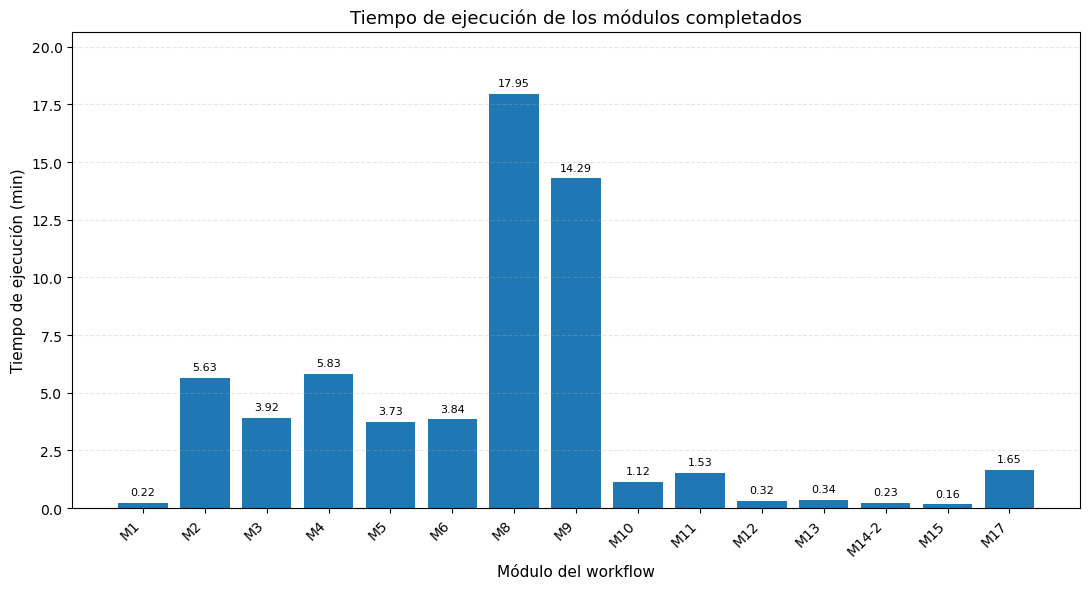

FIGURA 1 - TIEMPO DE EJECUCIÓN

Tiempo total de módulos completados: 60.76 min
Archivo generado:
/home/paula.chaparro/Documentos/tesis_2025/results/figura_tiempo_ejecucion_modulos.png

Distribución del tiempo por módulo:


,modulo,duracion_minutos,porcentaje_tiempo
0,M1,0.22,0.4
1,M2,5.63,9.3
2,M3,3.92,6.5
3,M4,5.83,9.6
4,M5,3.73,6.1
5,M6,3.84,6.3
6,M8,17.95,29.5
7,M9,14.29,23.5
8,M10,1.12,1.8
9,M11,1.53,2.5



MÓDULOS CON MAYOR TIEMPO DE EJECUCIÓN


,modulo,duracion_minutos,porcentaje_tiempo
0,M8,17.95,29.5
1,M9,14.29,23.5
2,M4,5.83,9.6
3,M2,5.63,9.3
4,M3,3.92,6.5



M8 + M9: 32.24 min
Contribución conjunta al tiempo total: 53.1%


In [172]:
# ============================================================
# FIGURA 1. TIEMPO DE EJECUCIÓN POR MÓDULO COMPLETADO
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Rutas
# ------------------------------------------------------------

project_dir = "/home/paula.chaparro/Documentos/tesis_2025"
results_dir = os.path.join(project_dir, "results")

monitor_file = os.path.join(
    results_dir,
    "monitorizacion_recursos_final.csv"
)

figure_file = os.path.join(
    results_dir,
    "figura_tiempo_ejecucion_modulos.png"
)


# ------------------------------------------------------------
# 2. Cargar resultados de monitorización
# ------------------------------------------------------------

if not os.path.exists(monitor_file):
    raise FileNotFoundError(
        f"❌ No se encontró:\n{monitor_file}"
    )

df = pd.read_csv(monitor_file)


# ------------------------------------------------------------
# 3. Seleccionar únicamente módulos completados
# ------------------------------------------------------------

df_time = df[
    df["clasificacion"] == "Completado"
].copy()

if df_time.empty:
    raise ValueError(
        "❌ No se encontraron módulos clasificados "
        "como 'Completado'."
    )


# ------------------------------------------------------------
# 4. Asegurar el orden correcto de los módulos
# ------------------------------------------------------------

orden_modulos = [
    "M1",
    "M2",
    "M3",
    "M4",
    "M5",
    "M6",
    "M8",
    "M9",
    "M10",
    "M11",
    "M12",
    "M13",
    "M14-2",
    "M15",
    "M17",
]

df_time["modulo"] = pd.Categorical(
    df_time["modulo"],
    categories=orden_modulos,
    ordered=True
)

df_time = (
    df_time
    .sort_values("modulo")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 5. Calcular tiempo total y porcentaje por módulo
# ------------------------------------------------------------

tiempo_total_min = df_time[
    "duracion_minutos"
].sum()

df_time["porcentaje_tiempo"] = (
    df_time["duracion_minutos"]
    / tiempo_total_min
    * 100
)


# ------------------------------------------------------------
# 6. Crear figura
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(11, 6)
)

bars = ax.bar(
    df_time["modulo"].astype(str),
    df_time["duracion_minutos"]
)


# ------------------------------------------------------------
# 7. Añadir valor sobre cada barra
# ------------------------------------------------------------

for bar, tiempo in zip(
    bars,
    df_time["duracion_minutos"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.25,
        f"{tiempo:.2f}",
        ha="center",
        va="bottom",
        fontsize=8
    )


# ------------------------------------------------------------
# 8. Formato de la figura
# ------------------------------------------------------------

ax.set_xlabel(
    "Módulo del workflow",
    fontsize=11
)

ax.set_ylabel(
    "Tiempo de ejecución (min)",
    fontsize=11
)

ax.set_title(
    "Tiempo de ejecución de los módulos completados",
    fontsize=13
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

# Dar espacio para las etiquetas superiores
ax.set_ylim(
    0,
    df_time["duracion_minutos"].max() * 1.15
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()


# ------------------------------------------------------------
# 9. Guardar figura
# ------------------------------------------------------------

plt.savefig(
    figure_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 10. Mostrar datos utilizados
# ------------------------------------------------------------

print("==============================================")
print("FIGURA 1 - TIEMPO DE EJECUCIÓN")
print("==============================================")

print(
    f"\nTiempo total de módulos completados: "
    f"{tiempo_total_min:.2f} min"
)

print(
    f"Archivo generado:\n{figure_file}"
)

print("\nDistribución del tiempo por módulo:")

display(
    df_time[
        [
            "modulo",
            "duracion_minutos",
            "porcentaje_tiempo"
        ]
    ]
    .round(
        {
            "duracion_minutos": 2,
            "porcentaje_tiempo": 1
        }
    )
)


# ------------------------------------------------------------
# 11. Identificar módulos de mayor duración
# ------------------------------------------------------------

ranking_tiempo = (
    df_time[
        [
            "modulo",
            "duracion_minutos",
            "porcentaje_tiempo"
        ]
    ]
    .sort_values(
        "duracion_minutos",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n==============================================")
print("MÓDULOS CON MAYOR TIEMPO DE EJECUCIÓN")
print("==============================================")

display(
    ranking_tiempo.head(5).round(
        {
            "duracion_minutos": 2,
            "porcentaje_tiempo": 1
        }
    )
)


# ------------------------------------------------------------
# 12. Contribución conjunta de M8 y M9
# ------------------------------------------------------------

m8_m9 = df_time[
    df_time["modulo"].astype(str).isin(
        ["M8", "M9"]
    )
]

tiempo_m8_m9 = (
    m8_m9["duracion_minutos"].sum()
)

porcentaje_m8_m9 = (
    tiempo_m8_m9
    / tiempo_total_min
    * 100
)

print(
    f"\nM8 + M9: {tiempo_m8_m9:.2f} min"
)

print(
    f"Contribución conjunta al tiempo total: "
    f"{porcentaje_m8_m9:.1f}%"
)

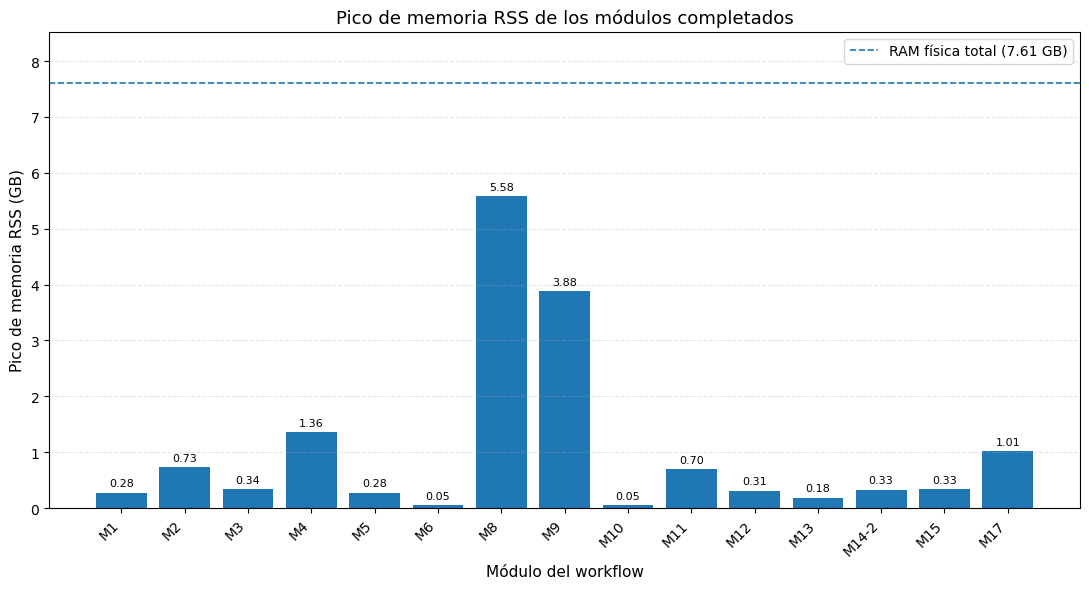

FIGURA 2 - PICO DE MEMORIA RSS

RAM física total registrada: 7.61 GB
Archivo generado:
/home/paula.chaparro/Documentos/tesis_2025/results/figura_pico_memoria_modulos.png

Módulos con mayor pico RSS:


,modulo,pico_RSS_GB,porcentaje_RAM
0,M8,5.580,73.3
1,M9,3.883,51.0
2,M4,1.359,17.9
3,M17,1.014,13.3
4,M2,0.726,9.5
5,M11,0.696,9.1
6,M3,0.339,4.5
7,M15,0.333,4.4
8,M14-2,0.325,4.3
9,M12,0.307,4.0



MÁXIMO CONSUMO DE MEMORIA
Módulo: M8
Pico RSS: 5.580 GB
Equivalente a: 73.3% de la RAM física


In [173]:
# ============================================================
# FIGURA 2. PICO DE MEMORIA RSS POR MÓDULO COMPLETADO
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Rutas
# ------------------------------------------------------------

project_dir = "/home/paula.chaparro/Documentos/tesis_2025"
results_dir = os.path.join(project_dir, "results")

monitor_file = os.path.join(
    results_dir,
    "monitorizacion_recursos_final.csv"
)

figure_file = os.path.join(
    results_dir,
    "figura_pico_memoria_modulos.png"
)


# ------------------------------------------------------------
# 2. Cargar datos
# ------------------------------------------------------------

if not os.path.exists(monitor_file):
    raise FileNotFoundError(
        f"❌ No se encontró:\n{monitor_file}"
    )

df = pd.read_csv(monitor_file)


# ------------------------------------------------------------
# 3. Seleccionar módulos completados
# ------------------------------------------------------------

df_memory = df[
    df["clasificacion"] == "Completado"
].copy()

if df_memory.empty:
    raise ValueError(
        "❌ No se encontraron módulos completados."
    )


# ------------------------------------------------------------
# 4. Orden del workflow
# ------------------------------------------------------------

orden_modulos = [
    "M1",
    "M2",
    "M3",
    "M4",
    "M5",
    "M6",
    "M8",
    "M9",
    "M10",
    "M11",
    "M12",
    "M13",
    "M14-2",
    "M15",
    "M17",
]

df_memory["modulo"] = pd.Categorical(
    df_memory["modulo"],
    categories=orden_modulos,
    ordered=True
)

df_memory = (
    df_memory
    .sort_values("modulo")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 5. RAM física total registrada
# ------------------------------------------------------------

ram_total = df_memory[
    "ram_total_GB"
].median()

# Recalcular el porcentaje directamente
df_memory["porcentaje_RAM"] = (
    df_memory["pico_RSS_GB"]
    / ram_total
    * 100
)


# ------------------------------------------------------------
# 6. Crear figura
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(11, 6)
)

bars = ax.bar(
    df_memory["modulo"].astype(str),
    df_memory["pico_RSS_GB"]
)


# ------------------------------------------------------------
# 7. Añadir valores sobre las barras
# ------------------------------------------------------------

for bar, rss in zip(
    bars,
    df_memory["pico_RSS_GB"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.08,
        f"{rss:.2f}",
        ha="center",
        va="bottom",
        fontsize=8
    )


# ------------------------------------------------------------
# 8. Línea de referencia de RAM física total
# ------------------------------------------------------------

ax.axhline(
    y=ram_total,
    linestyle="--",
    linewidth=1.2,
    label=f"RAM física total ({ram_total:.2f} GB)"
)


# ------------------------------------------------------------
# 9. Formato
# ------------------------------------------------------------

ax.set_xlabel(
    "Módulo del workflow",
    fontsize=11
)

ax.set_ylabel(
    "Pico de memoria RSS (GB)",
    fontsize=11
)

ax.set_title(
    "Pico de memoria RSS de los módulos completados",
    fontsize=13
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.legend(
    loc="upper right"
)

ax.set_ylim(
    0,
    ram_total * 1.12
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()


# ------------------------------------------------------------
# 10. Guardar figura
# ------------------------------------------------------------

plt.savefig(
    figure_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 11. Ranking de consumo de memoria
# ------------------------------------------------------------

ranking_memory = (
    df_memory[
        [
            "modulo",
            "pico_RSS_GB",
            "porcentaje_RAM"
        ]
    ]
    .sort_values(
        "pico_RSS_GB",
        ascending=False
    )
    .reset_index(drop=True)
)


print("==============================================")
print("FIGURA 2 - PICO DE MEMORIA RSS")
print("==============================================")

print(
    f"\nRAM física total registrada: "
    f"{ram_total:.2f} GB"
)

print(
    f"Archivo generado:\n{figure_file}"
)

print("\nMódulos con mayor pico RSS:")

display(
    ranking_memory.head(10).round(
        {
            "pico_RSS_GB": 3,
            "porcentaje_RAM": 1
        }
    )
)


# ------------------------------------------------------------
# 12. Identificar máximo
# ------------------------------------------------------------

max_memory = ranking_memory.iloc[0]

print("\n==============================================")
print("MÁXIMO CONSUMO DE MEMORIA")
print("==============================================")

print(
    f"Módulo: {max_memory['modulo']}"
)

print(
    f"Pico RSS: "
    f"{max_memory['pico_RSS_GB']:.3f} GB"
)

print(
    f"Equivalente a: "
    f"{max_memory['porcentaje_RAM']:.1f}% "
    f"de la RAM física"
)

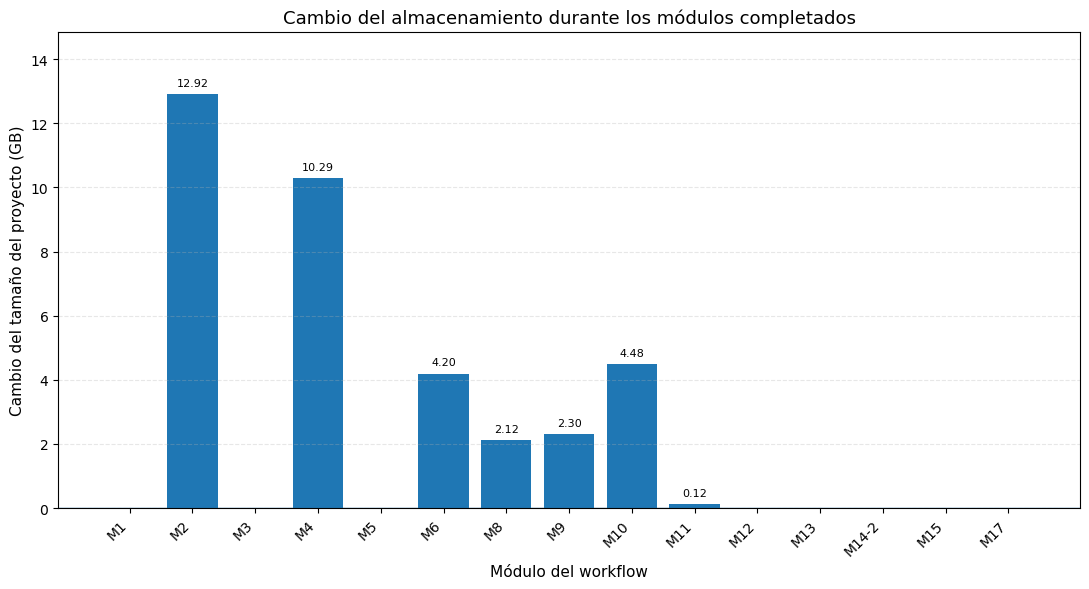

FIGURA 3 - CAMBIO DE ALMACENAMIENTO

Archivo generado:
/home/paula.chaparro/Documentos/tesis_2025/results/figura_cambio_almacenamiento_modulos.png

Módulos con mayor crecimiento del tamaño del proyecto:


,modulo,project_size_inicio_GB,project_size_final_GB,cambio_project_GB,cambio_disco_libre_GB
0,M2,0.000,12.916,12.916,-12.92
1,M4,12.918,23.210,10.292,-10.29
2,M10,18.920,23.399,4.479,-4.48
3,M6,23.212,27.407,4.195,-4.20
4,M9,16.617,18.920,2.303,-2.31
5,M8,14.492,16.617,2.125,-2.12
6,M11,23.399,23.523,0.124,-0.12
7,M3,12.916,12.918,0.002,0.00
8,M5,23.210,23.212,0.002,0.00
9,M12,23.523,23.525,0.002,0.00



MAYOR CRECIMIENTO DEL PROYECTO
Módulo: M2
Tamaño inicial: 0.000 GB
Tamaño final: 12.916 GB
Incremento durante el módulo: 12.916 GB


In [174]:
# ============================================================
# FIGURA 3. CAMBIO DEL TAMAÑO DEL PROYECTO POR MÓDULO
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Rutas
# ------------------------------------------------------------

project_dir = "/home/paula.chaparro/Documentos/tesis_2025"
results_dir = os.path.join(project_dir, "results")

monitor_file = os.path.join(
    results_dir,
    "monitorizacion_recursos_final.csv"
)

figure_file = os.path.join(
    results_dir,
    "figura_cambio_almacenamiento_modulos.png"
)


# ------------------------------------------------------------
# 2. Cargar datos
# ------------------------------------------------------------

if not os.path.exists(monitor_file):
    raise FileNotFoundError(
        f"❌ No se encontró:\n{monitor_file}"
    )

df = pd.read_csv(monitor_file)


# ------------------------------------------------------------
# 3. Seleccionar módulos completados
# ------------------------------------------------------------

df_storage = df[
    df["clasificacion"] == "Completado"
].copy()

if df_storage.empty:
    raise ValueError(
        "❌ No se encontraron módulos completados."
    )


# ------------------------------------------------------------
# 4. Orden lógico del workflow
# ------------------------------------------------------------

orden_modulos = [
    "M1",
    "M2",
    "M3",
    "M4",
    "M5",
    "M6",
    "M8",
    "M9",
    "M10",
    "M11",
    "M12",
    "M13",
    "M14-2",
    "M15",
    "M17",
]

df_storage["modulo"] = pd.Categorical(
    df_storage["modulo"],
    categories=orden_modulos,
    ordered=True
)

df_storage = (
    df_storage
    .sort_values("modulo")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 5. Crear figura
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(11, 6)
)

bars = ax.bar(
    df_storage["modulo"].astype(str),
    df_storage["cambio_project_GB"]
)


# ------------------------------------------------------------
# 6. Añadir valores
#
# Para evitar saturar la figura, se etiquetan únicamente
# cambios >= 0.01 GB.
# ------------------------------------------------------------

for bar, cambio in zip(
    bars,
    df_storage["cambio_project_GB"]
):

    if abs(cambio) >= 0.01:

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.20,
            f"{cambio:.2f}",
            ha="center",
            va="bottom",
            fontsize=8
        )


# ------------------------------------------------------------
# 7. Formato
# ------------------------------------------------------------

ax.set_xlabel(
    "Módulo del workflow",
    fontsize=11
)

ax.set_ylabel(
    "Cambio del tamaño del proyecto (GB)",
    fontsize=11
)

ax.set_title(
    "Cambio del almacenamiento durante los módulos completados",
    fontsize=13
)

ax.axhline(
    y=0,
    linewidth=1
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

valor_maximo = df_storage[
    "cambio_project_GB"
].max()

ax.set_ylim(
    0,
    valor_maximo * 1.15
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()


# ------------------------------------------------------------
# 8. Guardar figura
# ------------------------------------------------------------

plt.savefig(
    figure_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 9. Ranking de crecimiento del proyecto
# ------------------------------------------------------------

ranking_storage = (
    df_storage[
        [
            "modulo",
            "project_size_inicio_GB",
            "project_size_final_GB",
            "cambio_project_GB",
            "cambio_disco_libre_GB"
        ]
    ]
    .sort_values(
        "cambio_project_GB",
        ascending=False
    )
    .reset_index(drop=True)
)


print("==============================================")
print("FIGURA 3 - CAMBIO DE ALMACENAMIENTO")
print("==============================================")

print(
    f"\nArchivo generado:\n{figure_file}"
)

print(
    "\nMódulos con mayor crecimiento "
    "del tamaño del proyecto:"
)

display(
    ranking_storage.head(10).round(
        {
            "project_size_inicio_GB": 3,
            "project_size_final_GB": 3,
            "cambio_project_GB": 3,
            "cambio_disco_libre_GB": 3
        }
    )
)


# ------------------------------------------------------------
# 10. Identificar mayor crecimiento
# ------------------------------------------------------------

max_storage = ranking_storage.iloc[0]

print("\n==============================================")
print("MAYOR CRECIMIENTO DEL PROYECTO")
print("==============================================")

print(
    f"Módulo: {max_storage['modulo']}"
)

print(
    f"Tamaño inicial: "
    f"{max_storage['project_size_inicio_GB']:.3f} GB"
)

print(
    f"Tamaño final: "
    f"{max_storage['project_size_final_GB']:.3f} GB"
)

print(
    f"Incremento durante el módulo: "
    f"{max_storage['cambio_project_GB']:.3f} GB"
)

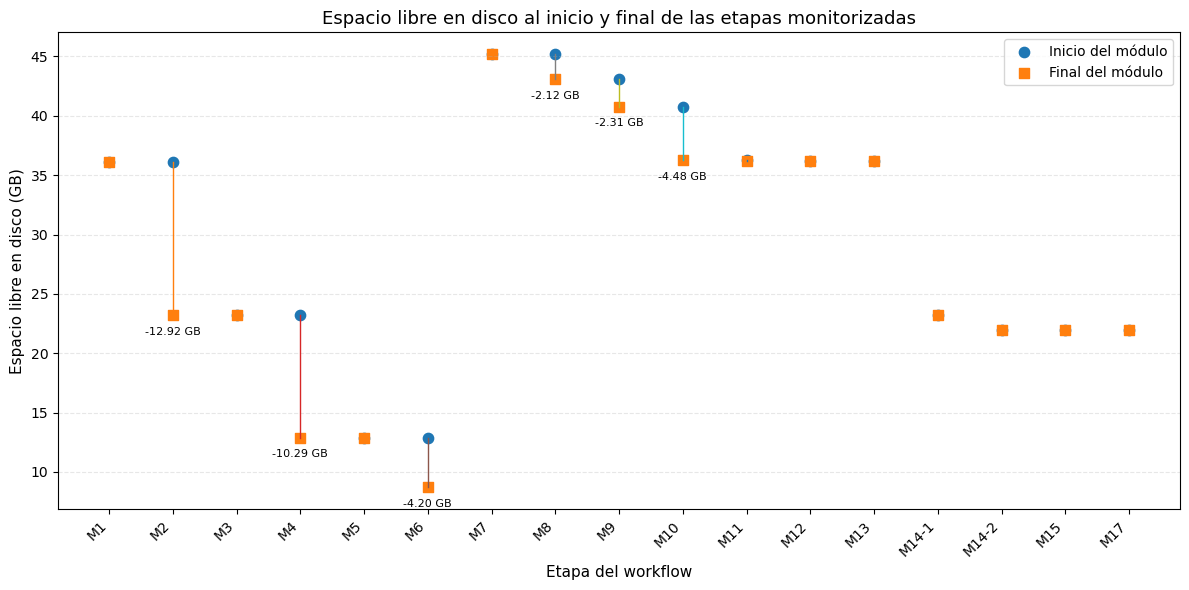

FIGURA 4 - ESPACIO LIBRE EN DISCO

Archivo generado:
/home/paula.chaparro/Documentos/tesis_2025/results/figura_evolucion_espacio_disco.png


,modulo,disco_libre_inicio_GB,disco_libre_final_GB,cambio_disco_libre_GB
0,M1,36.11,36.11,0.00
1,M2,36.11,23.19,-12.92
2,M3,23.19,23.19,0.00
3,M4,23.19,12.90,-10.29
4,M5,12.90,12.90,0.00
5,M6,12.90,8.70,-4.20
6,M7,45.21,45.21,0.00
7,M8,45.21,43.09,-2.12
8,M9,43.09,40.78,-2.31
9,M10,40.78,36.30,-4.48



MAYORES REDUCCIONES DE ESPACIO LIBRE


,modulo,disco_libre_inicio_GB,disco_libre_final_GB,cambio_disco_libre_GB
0,M2,36.11,23.19,-12.92
1,M4,23.19,12.90,-10.29
2,M10,40.78,36.30,-4.48
3,M6,12.90,8.70,-4.20
4,M9,43.09,40.78,-2.31
5,M8,45.21,43.09,-2.12


In [175]:
# ============================================================
# FIGURA 4. EVOLUCIÓN DEL ESPACIO LIBRE EN DISCO
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Rutas
# ------------------------------------------------------------

project_dir = "/home/paula.chaparro/Documentos/tesis_2025"
results_dir = os.path.join(project_dir, "results")

monitor_file = os.path.join(
    results_dir,
    "monitorizacion_recursos_final.csv"
)

figure_file = os.path.join(
    results_dir,
    "figura_evolucion_espacio_disco.png"
)


# ------------------------------------------------------------
# 2. Cargar datos
# ------------------------------------------------------------

if not os.path.exists(monitor_file):
    raise FileNotFoundError(
        f"❌ No se encontró:\n{monitor_file}"
    )

df = pd.read_csv(monitor_file)


# ------------------------------------------------------------
# 3. Seleccionar etapas útiles para la evolución operacional
#
# Se incluyen:
# - módulos completados
# - etapas de preparación
#
# Se excluyen M16 y M18-M23 porque no completaron
# su función principal y no aportaron cambios relevantes
# de almacenamiento.
# ------------------------------------------------------------

clasificaciones_incluir = [
    "Completado",
    "Preparación",
    "Preparación inicial"
]

df_disk = df[
    df["clasificacion"].isin(
        clasificaciones_incluir
    )
].copy()


# ------------------------------------------------------------
# 4. Orden lógico
# ------------------------------------------------------------

orden_modulos = [
    "M1",
    "M2",
    "M3",
    "M4",
    "M5",
    "M6",
    "M7",
    "M8",
    "M9",
    "M10",
    "M11",
    "M12",
    "M13",
    "M14-1",
    "M14-2",
    "M15",
    "M17",
]

df_disk["modulo"] = pd.Categorical(
    df_disk["modulo"],
    categories=orden_modulos,
    ordered=True
)

df_disk = (
    df_disk
    .sort_values("modulo")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 5. Crear posiciones X
# ------------------------------------------------------------

x = range(len(df_disk))


# ------------------------------------------------------------
# 6. Crear figura
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(12, 6)
)


# ------------------------------------------------------------
# 7. Espacio libre al inicio
# ------------------------------------------------------------

ax.scatter(
    x,
    df_disk["disco_libre_inicio_GB"],
    marker="o",
    s=55,
    label="Inicio del módulo"
)


# ------------------------------------------------------------
# 8. Espacio libre al final
# ------------------------------------------------------------

ax.scatter(
    x,
    df_disk["disco_libre_final_GB"],
    marker="s",
    s=55,
    label="Final del módulo"
)


# ------------------------------------------------------------
# 9. Conectar inicio y final DEL MISMO módulo
#
# Estas líneas representan exclusivamente el cambio
# registrado durante cada ejecución.
# ------------------------------------------------------------

for i, row in df_disk.iterrows():

    ax.plot(
        [i, i],
        [
            row["disco_libre_inicio_GB"],
            row["disco_libre_final_GB"]
        ],
        linewidth=1
    )


# ------------------------------------------------------------
# 10. Añadir valores relevantes
#
# Solo se etiquetan cambios >= 1 GB para evitar
# sobrecargar visualmente la figura.
# ------------------------------------------------------------

for i, row in df_disk.iterrows():

    cambio = (
        row["disco_libre_final_GB"]
        - row["disco_libre_inicio_GB"]
    )

    if abs(cambio) >= 1:

        ax.text(
            i,
            min(
                row["disco_libre_inicio_GB"],
                row["disco_libre_final_GB"]
            ) - 1,
            f"{cambio:.2f} GB",
            ha="center",
            va="top",
            fontsize=8
        )


# ------------------------------------------------------------
# 11. Formato
# ------------------------------------------------------------

ax.set_xticks(
    list(x)
)

ax.set_xticklabels(
    df_disk["modulo"].astype(str),
    rotation=45,
    ha="right"
)

ax.set_xlabel(
    "Etapa del workflow",
    fontsize=11
)

ax.set_ylabel(
    "Espacio libre en disco (GB)",
    fontsize=11
)

ax.set_title(
    "Espacio libre en disco al inicio y final de las etapas monitorizadas",
    fontsize=13
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.legend()

plt.tight_layout()


# ------------------------------------------------------------
# 12. Guardar figura
# ------------------------------------------------------------

plt.savefig(
    figure_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 13. Tabla de cambios
# ------------------------------------------------------------

tabla_disk = df_disk[
    [
        "modulo",
        "disco_libre_inicio_GB",
        "disco_libre_final_GB",
        "cambio_disco_libre_GB"
    ]
].copy()

print("==============================================")
print("FIGURA 4 - ESPACIO LIBRE EN DISCO")
print("==============================================")

print(
    f"\nArchivo generado:\n{figure_file}"
)

display(
    tabla_disk.round(2)
)


# ------------------------------------------------------------
# 14. Identificar mayores reducciones durante módulos
# ------------------------------------------------------------

ranking_disk = (
    tabla_disk
    .sort_values(
        "cambio_disco_libre_GB"
    )
    .reset_index(drop=True)
)

print("\n==============================================")
print("MAYORES REDUCCIONES DE ESPACIO LIBRE")
print("==============================================")

display(
    ranking_disk.head(6).round(2)
)

In [176]:
# ============================================================
# TABLA DEFINITIVA DE RENDIMIENTO DEL WORKFLOW
# ============================================================

import os
import pandas as pd


# ------------------------------------------------------------
# 1. Rutas
# ------------------------------------------------------------

project_dir = "/home/paula.chaparro/Documentos/tesis_2025"
results_dir = os.path.join(project_dir, "results")

monitor_file = os.path.join(
    results_dir,
    "monitorizacion_recursos_final.csv"
)

csv_file = os.path.join(
    results_dir,
    "tabla_rendimiento_workflow.csv"
)

excel_file = os.path.join(
    results_dir,
    "tabla_rendimiento_workflow.xlsx"
)


# ------------------------------------------------------------
# 2. Cargar registro depurado
# ------------------------------------------------------------

if not os.path.exists(monitor_file):
    raise FileNotFoundError(
        f"❌ No se encontró:\n{monitor_file}"
    )

df = pd.read_csv(monitor_file)


# ------------------------------------------------------------
# 3. Seleccionar únicamente módulos completados
# ------------------------------------------------------------

tabla = df[
    df["clasificacion"] == "Completado"
].copy()

if tabla.empty:
    raise ValueError(
        "❌ No se encontraron módulos completados."
    )


# ------------------------------------------------------------
# 4. Orden lógico del workflow
# ------------------------------------------------------------

orden_modulos = [
    "M1",
    "M2",
    "M3",
    "M4",
    "M5",
    "M6",
    "M8",
    "M9",
    "M10",
    "M11",
    "M12",
    "M13",
    "M14-2",
    "M15",
    "M17",
]

tabla["modulo"] = pd.Categorical(
    tabla["modulo"],
    categories=orden_modulos,
    ordered=True
)

tabla = (
    tabla
    .sort_values("modulo")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 5. Calcular tiempo directamente desde segundos
#
# Se evita utilizar duracion_minutos porque esa columna
# contiene valores previamente redondeados.
# ------------------------------------------------------------

tabla["tiempo_min"] = (
    tabla["duracion_segundos"] / 60
)


# ------------------------------------------------------------
# 6. Crear nombres abreviados de las etapas
# ------------------------------------------------------------

nombre_etapa = {
    "M1": "Obtención de metadatos",
    "M2": "Descarga y preparación de archivos",
    "M3": "Primer control de calidad",
    "M4": "Trimming y filtrado",
    "M5": "Segundo control de calidad",
    "M6": "Preparación del genoma de referencia",
    "M8": "Alineamiento y ordenamiento",
    "M9": "Marcaje de duplicados",
    "M10": "Preparación de la anotación genómica",
    "M11": "Cuantificación de expresión génica",
    "M12": "Construcción de matriz de conteos",
    "M13": "Filtrado de baja expresión",
    "M14-2": "Preparación de metadatos AD/non-AD",
    "M15": "Preparación para PyDESeq2",
    "M17": "PCA",
}

tabla["Etapa"] = (
    tabla["modulo"]
    .astype(str)
    .map(nombre_etapa)
)


# ------------------------------------------------------------
# 7. Seleccionar variables definitivas
# ------------------------------------------------------------

tabla_final = tabla[
    [
        "modulo",
        "Etapa",
        "tiempo_min",
        "pico_RSS_GB",
        "pico_RSS_porcentaje_RAM",
        "cambio_project_GB",
    ]
].copy()


# ------------------------------------------------------------
# 8. Renombrar columnas para presentación
# ------------------------------------------------------------

tabla_final = tabla_final.rename(
    columns={
        "modulo": "Módulo",
        "tiempo_min": "Tiempo (min)",
        "pico_RSS_GB": "Pico RSS (GB)",
        "pico_RSS_porcentaje_RAM": "RAM física (%)",
        "cambio_project_GB": "Cambio proyecto (GB)",
    }
)


# ------------------------------------------------------------
# 9. Redondear únicamente para presentación
# ------------------------------------------------------------

tabla_final["Tiempo (min)"] = (
    tabla_final["Tiempo (min)"].round(2)
)

tabla_final["Pico RSS (GB)"] = (
    tabla_final["Pico RSS (GB)"].round(3)
)

tabla_final["RAM física (%)"] = (
    tabla_final["RAM física (%)"].round(1)
)

tabla_final["Cambio proyecto (GB)"] = (
    tabla_final["Cambio proyecto (GB)"].round(3)
)


# ------------------------------------------------------------
# 10. Mostrar tabla definitiva
# ------------------------------------------------------------

print("==============================================")
print("TABLA DEFINITIVA DE RENDIMIENTO DEL WORKFLOW")
print("==============================================")

display(tabla_final)


# ------------------------------------------------------------
# 11. Guardar CSV
# ------------------------------------------------------------

tabla_final.to_csv(
    csv_file,
    index=False
)


# ------------------------------------------------------------
# 12. Guardar Excel
# ------------------------------------------------------------

tabla_final.to_excel(
    excel_file,
    index=False
)


# ------------------------------------------------------------
# 13. Verificación
# ------------------------------------------------------------

print("\n==============================================")
print("ARCHIVOS GENERADOS")
print("==============================================")

print(f"\nCSV:\n{csv_file}")
print(f"\nExcel:\n{excel_file}")

print(
    f"\nMódulos incluidos: "
    f"{len(tabla_final)}"
)

print(
    "\n✅ La tabla incluye únicamente "
    "ejecuciones completadas."
)

print(
    "✅ El tiempo fue recalculado desde "
    "duracion_segundos."
)

print(
    "✅ Las ejecuciones parciales no se utilizaron "
    "como métricas de rendimiento completo."
)

TABLA DEFINITIVA DE RENDIMIENTO DEL WORKFLOW


,Módulo,Etapa,Tiempo (min),Pico RSS (GB),RAM física (%),Cambio proyecto (GB)
0,M1,Obtención de metadatos,0.22,0.278,3.7,0.000
1,M2,Descarga y preparación de archivos,5.63,0.726,9.5,12.916
2,M3,Primer control de calidad,3.92,0.339,4.5,0.002
3,M4,Trimming y filtrado,5.83,1.359,17.9,10.292
4,M5,Segundo control de calidad,3.73,0.278,3.7,0.002
5,M6,Preparación del genoma de referencia,3.84,0.050,0.7,4.195
6,M8,Alineamiento y ordenamiento,17.95,5.580,73.3,2.125
7,M9,Marcaje de duplicados,14.29,3.883,51.0,2.303
8,M10,Preparación de la anotación genómica,1.12,0.048,0.6,4.479
9,M11,Cuantificación de expresión génica,1.53,0.696,9.1,0.124



ARCHIVOS GENERADOS

CSV:
/home/paula.chaparro/Documentos/tesis_2025/results/tabla_rendimiento_workflow.csv

Excel:
/home/paula.chaparro/Documentos/tesis_2025/results/tabla_rendimiento_workflow.xlsx

Módulos incluidos: 15

✅ La tabla incluye únicamente ejecuciones completadas.
✅ El tiempo fue recalculado desde duracion_segundos.
✅ Las ejecuciones parciales no se utilizaron como métricas de rendimiento completo.
